# Arsip Beku — Audit Atribusi Temporal Bidirectional Mamba-2

Gabungan seluruh notebook tahapan, dibekukan pada **2026-09-06**.

## Sifat berkas ini

Ini **arsip**, bukan notebook yang dijalankan ulang dari atas ke bawah. Tiap tahap memakai nama
variabel yang tumpang tindih dan memuat artefaknya sendiri, sehingga menjalankan gabungannya secara
berurutan akan saling menimpa. Yang dijaga adalah keterbacaan seluruh hasil dalam satu tempat,
beserta seluruh keluaran yang sudah dihitung.

Untuk menjalankan ulang satu tahap, pakai notebook aslinya di `notebooks/`. Sumber kebenaran seluruh
kode adalah `scripts/build_nb_*.py`; notebook per tahap dibangun dari sana, dan berkas ini dibangun
dari notebook itu.

## Isi

1. **Verifikasi struktur data** — `01_verifikasi_struktur_data.ipynb`
2. **Prapemrosesan dan rekayasa kanal** — `02_prapemrosesan.ipynb`
3. **Arsitektur dan verifikasi encoder** — `03_model.ipynb`
4. **Kontrol positif (S1)** — `04_kontrol_positif.ipynb`
5. **Atribusi Shapley (S1 lanjutan)** — `05_atribusi_shapley.ipynb`
6. **Pilot resolusi patch (S2)** — `06_pilot_resolusi.ipynb`
7. **Eksperimen utama (S3)** — `07_eksperimen_utama.ipynb`
8. **Kesetiaan atensi (S6)** — `08_kesetiaan_atensi.ipynb`
9. **Keselarasan terhadap penanda motorik (S7)** — `09_keselarasan_klinis.ipynb`
10. **Uji kewarasan pendukung (S8)** — `10_uji_kewarasan.ipynb`
11. **Generalisasi lintas tugas (S4)** — `11_lintas_tugas.ipynb`
12. **Replikasi NewHandPD (S5)** — `12_replikasi_newhandpd.ipynb`
13. **Pembagian fold tingkat rekaman (C1)** — `13_fold_rekaman.ipynb`
14. **14_visualisasi_data.ipynb** — `14_visualisasi_data.ipynb`

## Analisis berdiri sendiri

Sebagian analisis tidak berbentuk notebook melainkan skrip, dan tidak termasuk dalam arsip ini:

- `scripts/analisis_a0_perancu_stcp.py` — audit perancu STCP dan massa atensi
- `scripts/analisis_a3_penanda_lambat.py` — penanda lambat pada DST
- `scripts/analisis_b1_bootstrap.py` — bootstrap dan uji berpasangan peta
- `scripts/analisis_e7_spektrum.py` — spektrum rotasi state BiMamba-3
- `scripts/verifikasi_encoder.py` — tujuh pemeriksaan encoder
- `scripts/analisis_a_baseline_fitur.py` — baseline fitur kinematik agregat, dua kohort
- `scripts/analisis_rm5_newhandpd.py` — RM5 pada 35 subjek kontrol
- `scripts/analisis_rm2_tuning.py` — penyetelan hyperparameter berimbang tiga arm

## Notebook induk

`notebooks/00_induk.ipynb` adalah alur tunggal yang **dapat dijalankan dari atas ke bawah**: ia
memuat artefak `results/`, menghitung ulang seluruh angka kunci, menyimpan gambar ke `figures/`, dan
diakhiri validasi silang terhadap naskah. Ia bukan bagian arsip ini.


---

# Verifikasi struktur data

`01_verifikasi_struktur_data.ipynb` · 34 sel, 15 sel kode, 15 beroutput

# Tahap 1 — Verifikasi Struktur Basis Data

Notebook ini adalah **satu-satunya sumber kebenaran** untuk Tahap 1 (lihat `draftSempro/draft-sempro-skripsi.md`, Subbab 3.2 dan 3.3.3): unduh kedua basis data, verifikasi struktur kolom, frekuensi sampling, panjang urutan per tugas, dan kelengkapan data — sebelum satu baris kode model pun ditulis.

Setiap temuan di sini ditandai statusnya terhadap G1–G9 di Lampiran C proposal.

> **KOREKSI (Tahap 2).** Frekuensi sampling UCI 395 yang dilaporkan notebook ini — 142,86 Hz —
> **keliru**. Angka itu dihitung dari *median* selisih timestamp, yang menyesatkan karena
> distribusinya bimodal (57,6% bernilai 7 ms, 39,9% bernilai 9 ms). Nilai yang benar adalah
> **127,52 Hz**, dari rata-rata selisih 7,842 ms. Lihat [notebook 03](02_prapemrosesan.ipynb)
> bagian 1 untuk bukti dan konsekuensinya.
>
> Notebook ini sengaja tidak dijalankan ulang, agar jejak koreksi tetap terlihat.


In [1]:
import pandas as pd
import numpy as np
import glob, os, collections
from pathlib import Path

RAW = Path("../data/raw")
RAW.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)
print("Direktori data mentah:", RAW.resolve())

Direktori data mentah: /home/agribychaniago/Python Projects/Skripsi/data/raw


## 1. UCI 395 — Unduh

**Temuan penting:** kode `fetch_ucirepo(id=395)` yang tertulis di naskah ([3.3.1](../draftSempro/draft-sempro-skripsi.md)) **tidak berfungsi**. Paket `ucimlrepo` menolak dataset ini lewat API (`DatasetNotFoundError: exists in the repository, but is not available for import`) karena dataset ini berbasis berkas mentah, bukan tabel X/y sederhana.

Jalur unduh sebenarnya: unduh ZIP langsung dari UCI (ditemukan dari tautan `href` di halaman dataset, bukan dari API).

In [2]:
import urllib.request, zipfile

uci_dir = RAW / "uci395"
uci_zip = uci_dir / "uci395.zip"
uci_extract = uci_dir / "extracted"

if not uci_extract.exists():
    uci_dir.mkdir(parents=True, exist_ok=True)
    url = "https://archive.ics.uci.edu/static/public/395/parkinson+disease+spiral+drawings+using+digitized+graphics+tablet.zip"
    urllib.request.urlretrieve(url, uci_zip)
    with zipfile.ZipFile(uci_zip) as z:
        z.extractall(uci_extract)
    print("Diunduh dan diekstrak ke", uci_extract)
else:
    print("Sudah ada di", uci_extract)

for p in sorted(uci_extract.rglob("*")):
    if p.is_dir():
        print(p.relative_to(uci_extract))

Sudah ada di ../data/raw/uci395/extracted
hw_dataset
hw_dataset/control
hw_dataset/parkinson
hw_drawings
hw_drawings/Dynamic Spiral Test
hw_drawings/Static Spiral Test
new_dataset
new_dataset/parkinson


## 2. UCI 395 — Struktur kolom & Test ID

**Ini temuan paling kritis di seluruh Tahap 1.** Naskah ([3.3.1](../draftSempro/draft-sempro-skripsi.md)) mendefinisikan Test ID 2 sebagai **Stability Test on Certain Point (STCP)** — "menahan pena diam pada satu titik," dipilih justru karena **tidak ada gerakan volunter**, sehingga jadi dasar seluruh argumen analisis primer ([3.6.7](../draftSempro/draft-sempro-skripsi.md)) dan pemisahan penanda cepat-tanpa-rasio di [3.6.4](../draftSempro/draft-sempro-skripsi.md).

Readme resmi yang dibundel di dalam ZIP UCI 395 berkata lain.

In [3]:
readme = (uci_extract / "readme.txt").read_text()
print(readme)

Dataset is delimited as CSV values as follows;

X ; Y; Z; Pressure; GripAngle; Timestamp; Test ID

----------------
Test ID: 
0: Static Spiral Test ( Draw on the given spiral pattern)
1: Dynamic Spiral Test ( Spiral pattern will blink in a certain time, so subjects need to continue on their draw)
2: Circular Motion Test (Subjectd draw circles around the red point)


**Test ID 2 = "Circular Motion Test (Subjects draw circles around the red point)."** Itu gerakan melingkar volunter di sekitar titik — bukan pena diam. Premis "tidak ada gerakan volunter sehingga seluruh gerakan yang terekam merupakan tremor" **tidak didukung dokumentasi resmi**.

Ini bukan cuma soal penamaan. Seluruh alasan STCP dipilih sebagai jangkar analisis primer — dan pemisahan aturan penanda (STCP pakai amplitudo langsung tanpa rasio, SST/DST pakai rasio karena ada gerakan volunter) — bertumpu pada premis yang sekarang terbukti salah untuk Test ID 2.

In [4]:
hw = uci_extract / "hw_dataset"
control_files = sorted((hw / "control").glob("*.txt"))
pd_files = sorted((hw / "parkinson").glob("*.txt"))
print(f"hw_dataset/control : {len(control_files)} berkas")
print(f"hw_dataset/parkinson: {len(pd_files)} berkas")
print(f"Total hw_dataset    : {len(control_files) + len(pd_files)} berkas")
print()
print("Naskah mengklaim 62 PD + 15 HC = 77 subjek pada basis data utama.")
print("hw_dataset saja TIDAK mencapai angka itu — ada folder new_dataset/parkinson terpisah, dicek di bawah.")

new_pd_files = sorted((uci_extract / "new_dataset" / "parkinson").glob("*.txt"))
print(f"\nnew_dataset/parkinson: {len(new_pd_files)} berkas")
print(f"hw_dataset/parkinson + new_dataset/parkinson = {len(pd_files) + len(new_pd_files)} (naskah klaim 62)")
print(f"hw_dataset/control (sebagai proksi HC)        = {len(control_files)} (naskah klaim 15)")
print("\nCocok PERSIS dengan klaim naskah — 62 PD, 15 HC. Tidak ada yang perlu direkonsiliasi.")

hw_dataset/control : 15 berkas
hw_dataset/parkinson: 25 berkas
Total hw_dataset    : 40 berkas

Naskah mengklaim 62 PD + 15 HC = 77 subjek pada basis data utama.
hw_dataset saja TIDAK mencapai angka itu — ada folder new_dataset/parkinson terpisah, dicek di bawah.

new_dataset/parkinson: 37 berkas
hw_dataset/parkinson + new_dataset/parkinson = 62 (naskah klaim 62)
hw_dataset/control (sebagai proksi HC)        = 15 (naskah klaim 15)

Cocok PERSIS dengan klaim naskah — 62 PD, 15 HC. Tidak ada yang perlu direkonsiliasi.


**Sebelum menyimpulkan naskah salah — cek paper akademik aslinya, bukan cuma readme.txt bundel ZIP.** Readme dan paper bisa saja mendeskripsikan hal sama dengan bahasa beda. Isenkul, Sakar, Kursun (2014), *"Improved Spiral Test Using Digitized Graphics Tablet for Monitoring Parkinson's Disease"*, ICEHTM — sitasi [16] di naskah — mendefinisikan STCP sebagai:

> "subjects are asked to hold the digital pen **on the point without touching the screen** for a certain time"

Ini beda dari readme ZIP ("circular motion", pena menyentuh) **dan** beda dari frasa naskah kita ("menahan pena diam", tak jelas menyentuh atau tidak). Ada tiga versi. Diputuskan lewat data, bukan tebak-tebakan: kalau pena benar melayang (tak menyentuh), kolom Z (tekanan) harus dominan nol di Test ID 2 — beda drastis dari SST/DST yang jelas-jelas menggambar (tekanan harus selalu di atas nol).

In [5]:
all_files = control_files + pd_files
task_name = {"0": "SST (Static Spiral Test)", "1": "DST (Dynamic Spiral Test)", "2": "Circular Motion Test (bukan STCP tanpa-gerak)"}

by_test_z = collections.defaultdict(list)
for f in all_files:
    rows = [l.strip().split(";") for l in open(f) if l.strip()]
    for r in rows:
        if r[6] in ("0", "1", "2"):
            by_test_z[r[6]].append(int(r[3]))  # kolom Z / pressure

for tid_ in ["0", "1", "2"]:
    z = by_test_z[tid_]
    nz = sum(1 for v in z if v > 0)
    print(f"TestID {tid_} ({task_name[tid_]}):")
    print(f"  Z=0 (pena melayang): {len(z)-nz:>7} baris ({(len(z)-nz)/len(z)*100:5.1f}%)")
    print(f"  Z>0 (pena menyentuh): {nz:>7} baris ({nz/len(z)*100:5.1f}%)")
    print()

TestID 0 (SST (Static Spiral Test)):
  Z=0 (pena melayang):       0 baris (  0.0%)
  Z>0 (pena menyentuh):  134259 baris (100.0%)

TestID 1 (DST (Dynamic Spiral Test)):
  Z=0 (pena melayang):       0 baris (  0.0%)
  Z>0 (pena menyentuh):  140630 baris (100.0%)

TestID 2 (Circular Motion Test (bukan STCP tanpa-gerak)):
  Z=0 (pena melayang):   32788 baris ( 68.2%)
  Z>0 (pena menyentuh):   15292 baris ( 31.8%)



**Data membenarkan paper asli, bukan readme ZIP.** TestID 0 dan 1: tekanan **100% nonzero** — pena selalu nempel, konsisten dengan tugas menggambar spiral aktif. TestID 2: tekanan **~68% nol** — pena melayang mayoritas waktu, cocok definisi paper "without touching the screen."

Kesimpulan operasional buat Subbab 3.6.4: STCP secara dominan memang tugas tanpa kontak/gerakan-menggambar volunter, tapi **tidak murni 100%** — ada ~32% baris dengan sentuhan sesaat (kemungkinan lapse stabilitas, atau artefak batas awal/akhir tugas). Ini bukan alasan membatalkan premis STCP, tapi alasan menambah satu langkah prapemrosesan: hitung penanda tremor cepat pada segmen Z=0 saja (pena melayang), bukan seluruh durasi rekaman mentah — sesuai definisi asli task-nya, dan lebih bersih dari definisi yang tertulis di naskah versi sekarang.

Label "Circular Motion Test" di readme ZIP kemungkinan mendeskripsikan **pola gerak X/Y yang teramati** (lintasan tangan yang tremor/goyah saat mencoba diam biasanya membentuk pola melingkar kecil), bukan instruksi menggambar lingkaran. Dua sumber tidak benar-benar bertentangan — cuma mendeskripsikan hal yang sama dari sudut beda (instruksi klinis vs pola gerak hasil).

In [6]:
sample = control_files[0]
rows = [l.strip().split(";") for l in open(sample) if l.strip()]
print("Contoh berkas:", sample.name)
print("Jumlah kolom:", len(rows[0]))
print("5 baris pertama:")
for r in rows[:5]:
    print(r)
print()
testids_present = sorted(set(r[6] for r in rows))
print("Test ID yang muncul di berkas ini:", testids_present)

Contoh berkas: C_0001.txt
Jumlah kolom: 7
5 baris pertama:
['200', '204', '0', '73', '910', '1732647300', '0']
['200', '204', '0', '218', '900', '1732647307', '0']
['200', '204', '0', '253', '900', '1732647314', '0']
['200', '204', '0', '304', '900', '1732647321', '0']
['200', '204', '0', '351', '900', '1732647328', '0']

Test ID yang muncul di berkas ini: ['0', '1']


Cek berapa banyak dari 40 subjek `hw_dataset` yang benar-benar punya rekaman Test ID 2 (mengecek G7 — kelengkapan tugas per subjek):

In [7]:
all_files = control_files + pd_files
has_test2 = 0
for f in all_files:
    testids = set(l.split(";")[6].strip() for l in open(f) if l.strip())
    if "2" in testids:
        has_test2 += 1
print(f"{has_test2} dari {len(all_files)} subjek ({has_test2/len(all_files)*100:.0f}%) punya rekaman Test ID 2.")
print("Bukan seluruh subjek mengerjakan tugas ini — relevan untuk G7 (data tidak lengkap).")

30 dari 40 subjek (75%) punya rekaman Test ID 2.
Bukan seluruh subjek mengerjakan tugas ini — relevan untuk G7 (data tidak lengkap).


## 3. UCI 395 — Frekuensi sampling (G2)

In [8]:
sample_rows = [l.strip().split(";") for l in open(control_files[0]) if l.strip()]
ts = [int(r[5]) for r in sample_rows]
tid = [r[6] for r in sample_rows]
diffs = [ts[i+1]-ts[i] for i in range(len(ts)-1) if tid[i+1] == tid[i]]
diffs = sorted(diffs)
median_dt = diffs[len(diffs)//2]
print(f"Delta timestamp (ms): min={diffs[0]} median={median_dt} max={diffs[-1]}")
print(f"Estimasi frekuensi sampling: {1000/median_dt:.2f} Hz")
print()
print("Catatan: berbeda dari NewHandPD, tidak ada field 'Samplerate' eksplisit di header UCI 395 —")
print("frekuensi ini murni dihitung dari selisih timestamp, sesuai rencana verifikasi di 3.3.3.")

Delta timestamp (ms): min=7 median=7 max=8
Estimasi frekuensi sampling: 142.86 Hz

Catatan: berbeda dari NewHandPD, tidak ada field 'Samplerate' eksplisit di header UCI 395 —
frekuensi ini murni dihitung dari selisih timestamp, sesuai rencana verifikasi di 3.3.3.


## 4. UCI 395 — Durasi & panjang urutan per tugas (G6)

Ini yang menentukan apakah analisis primer ([3.6.7](../draftSempro/draft-sempro-skripsi.md), terkunci ke Test ID 2 / "STCP") punya cukup data — terlepas dari masalah penamaan di atas.

In [9]:
dur_per_test = collections.defaultdict(list)
n_per_test = collections.defaultdict(list)

for f in all_files:
    rows = [l.strip().split(";") for l in open(f) if l.strip()]
    by_test = collections.defaultdict(list)
    for r in rows:
        by_test[r[6]].append(int(r[5]))
    for tid_, tss in by_test.items():
        dur_per_test[tid_].append((max(tss) - min(tss)) / 1000.0)
        n_per_test[tid_].append(len(tss))

task_name = {"0": "SST (Static Spiral Test)", "1": "DST (Dynamic Spiral Test)", "2": "Circular Motion Test (bukan STCP tanpa-gerak)"}

summary_rows = []
for tid_ in sorted(dur_per_test):
    d = sorted(dur_per_test[tid_])
    n = sorted(n_per_test[tid_])
    summary_rows.append({
        "TestID": tid_,
        "Nama": task_name[tid_],
        "n_rekaman": len(d),
        "durasi_min_s": round(d[0], 1),
        "durasi_median_s": round(d[len(d)//2], 1),
        "durasi_max_s": round(d[-1], 1),
        "baris_min": n[0],
        "baris_median": n[len(n)//2],
        "baris_max": n[-1],
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,TestID,Nama,n_rekaman,durasi_min_s,durasi_median_s,durasi_max_s,baris_min,baris_median,baris_max
0,0,SST (Static Spiral Test),40,6.7,24.5,90.6,746,2884,9390
1,1,DST (Dynamic Spiral Test),40,5.0,26.2,78.8,557,3014,8465
2,2,Circular Motion Test (bukan STCP tanpa-gerak),30,7.9,13.1,38.4,909,1536,4939


**Bacaan G6:** durasi Test ID 2 (median 13,1 detik) lebih pendek dari SST/DST tapi **bukan terlalu pendek** — pada ~143 Hz itu ±1800 baris, cukup buat patch resolusi halus. G6 soal *panjang* boleh dianggap aman. Yang tidak aman adalah premis *"tanpa gerakan volunter"* di atas — itu masalah validitas konstruk, bukan masalah panjang data.

## 5. NewHandPD — Unduh (set Healthy, buat verifikasi struktur)

In [10]:
nhpd_dir = RAW / "newhandpd"
nhpd_zip = nhpd_dir / "HealthySignal.zip"
nhpd_extract = nhpd_dir / "extracted"

if not nhpd_extract.exists():
    nhpd_dir.mkdir(parents=True, exist_ok=True)
    url = "https://wwwp.fc.unesp.br/~papa/pub/datasets/Handpd/NewHealthy/HealthySignal.zip"
    urllib.request.urlretrieve(url, nhpd_zip)
    with zipfile.ZipFile(nhpd_zip) as z:
        z.extractall(nhpd_extract)
    print("Diunduh dan diekstrak ke", nhpd_extract)
else:
    print("Sudah ada di", nhpd_extract)

signal_dir = nhpd_extract / "Signal"
all_signal_files = [f for f in signal_dir.glob("*.txt")]
print(f"Total berkas sinyal: {len(all_signal_files)}")

Sudah ada di ../data/raw/newhandpd/extracted
Total berkas sinyal: 420


## 6. NewHandPD — Struktur berkas (G1)

Ini item yang paling lama tak terjawab di Lampiran C — halaman resmi dataset tak mendokumentasikan struktur kolom sinyal sama sekali.

In [11]:
import re
prefixes = sorted(set(re.sub(r"-H?\d+\.txt$", "", f.name) for f in all_signal_files))
print("Jenis tugas ditemukan dari nama berkas:", len(prefixes))
for p in prefixes:
    print(" ", p)

Jenis tugas ditemukan dari nama berkas: 12
  circA
  circB
  sigDiaA
  sigDiaB
  sigMea1
  sigMea2
  sigMea3
  sigMea4
  sigSp1
  sigSp2
  sigSp3
  sigSp4


12 jenis tugas ketemu (`circA/B`, `sigDiaA/B`, `sigMea1-4`, `sigSp1-4`) — **cocok** dengan deskripsi naskah di [3.3.2](../draftSempro/draft-sempro-skripsi.md): "empat spiral, empat meander, dua gerakan melingkar, diadochokinesis tangan kiri dan kanan." Bagian ini naskahnya benar.

Sekarang isi berkasnya — ternyata ada header metadata yang tak disebut di naskah sama sekali:

In [12]:
sample_f = signal_dir / "circA-H1.txt"
lines = sample_f.read_text().splitlines()
header_lines = [l for l in lines if l.startswith("#")]
for l in header_lines:
    print(l)

#<meta>
#<Person_ID_Number>[REDACTED-PII]</Person_ID_Number>
#<Age>58</Age>
#<Gender>1</Gender>
#<Writing_Hand>1</Writing_Hand>
#<Weight>83</Weight>
#<Height>176</Height>
#<Smoker>1</Smoker>
#<Notice></Notice>
#<Object>a_circ_p</Object>
#<Object_Index>1</Object_Index>
#<Pen>Pentrics Alberich1</Pen>
#<Samplerate>1000</Samplerate>
#<Time>[REDACTED]</Time>
#<Date>[REDACTED]</Date>
#<Comment></Comment>
#</meta>


Header ini bonus tak terduga — ada `Samplerate: 1000` eksplisit, plus kovariat demografis (usia, gender, tangan dominan, berat, tinggi, perokok) yang bisa jadi confounder perlu dicatat. Sekarang baris data setelah header:

In [13]:
data_rows = []
for l in lines:
    if l.startswith("#") or not l.strip():
        continue
    data_rows.append([float(x) for x in l.split()])

print(f"Jumlah baris data: {len(data_rows)}")
print(f"Jumlah kolom: {len(data_rows[0])}")
print("5 baris pertama:")
for r in data_rows[:5]:
    print(r)

Jumlah baris data: 10600
Jumlah kolom: 6
5 baris pertama:
[3.01598170227124, 7.42844620892122, 5.9721909807594, 5.92632, 4.68585, 3.91826]
[2.98586877420341, 7.33678388418268, 5.97091783407694, 5.92632, 4.68585, 3.91826]
[2.9856228384788, 7.24345848450073, 5.96962719749549, 5.92632, 4.68585, 3.91826]
[2.99605113173114, 7.13874346287346, 5.96879571629436, 5.92852, 4.67265, 3.92485]
[2.99749112500403, 7.01995905309351, 5.96796133983234, 5.92852, 4.67265, 3.92485]


**Tidak ada nama kolom di berkas maupun di halaman resmi.** 6 kolom numerik tanpa label. Rentang nilainya (~2 sampai ~11) tidak terlihat seperti koordinat piksel digitizer biasa (yang biasanya beratus-ratus/beribu seperti di UCI 395) — lebih mirip unit tersensor/terkalibrasi. Cek pola nilai berulang buat curigai kemungkinan dua sensor beda frekuensi digabung dalam satu tabel:

In [14]:
n_cols = len(data_rows[0])
for c in range(n_cols):
    col = [r[c] for r in data_rows]
    runs, run = [], 1
    for i in range(1, len(col)):
        if col[i] == col[i-1]:
            run += 1
        else:
            runs.append(run); run = 1
    runs.append(run)
    avg_run = sum(runs) / len(runs)
    print(f"kolom {c}: rentang [{min(col):.2f}, {max(col):.2f}]  rata-rata panjang nilai berulang berturut-turut = {avg_run:.2f}")

kolom 0: rentang [2.46, 3.80]  rata-rata panjang nilai berulang berturut-turut = 1.00
kolom 1: rentang [4.91, 7.43]  rata-rata panjang nilai berulang berturut-turut = 1.00
kolom 2: rentang [4.89, 11.20]  rata-rata panjang nilai berulang berturut-turut = 1.00
kolom 3: rentang [4.44, 6.80]  rata-rata panjang nilai berulang berturut-turut = 3.70
kolom 4: rentang [4.06, 5.32]  rata-rata panjang nilai berulang berturut-turut = 3.67
kolom 5: rentang [3.25, 4.60]  rata-rata panjang nilai berulang berturut-turut = 3.67


**Kolom 0-2** berubah tiap baris (~1000 Hz sungguhan, sesuai header). **Kolom 3-5** berulang rata-rata ~3,7 baris berturut-turut — sensor kedua bersampling ~1000/3,7 ≈ 270 Hz, ditahan nilainya (upsampled) supaya panjang tabelnya sama dengan kolom 0-2.

**Status G1 sekarang:** jumlah kolom, tipe data, dan pola dua-sensor-beda-frekuensi sudah terverifikasi — bukan lagi "sepenuhnya tidak diketahui." **Yang masih terbuka:** identitas fisik tiap kolom (mana x, mana y, mana tekanan, mana tilt/akselerasi) — tak ada di berkas maupun halaman resmi. Perlu ditelusuri ke metode paper Pereira dkk. 2016 (rujukan [3] di naskah) atau spesifikasi pen BiSP sebelum kanal-kanal ini bisa dipetakan ke rekayasa kanal di [3.4](../draftSempro/draft-sempro-skripsi.md).

## 7. Ringkasan verifikasi vs checklist [3.3.3](../draftSempro/draft-sempro-skripsi.md) dan Lampiran C

In [15]:
status = pd.DataFrame([
    {"Butir": "G1 — struktur kolom NewHandPD", "Status": "Sebagian terjawab", "Catatan": "6 kolom, dua sensor beda frekuensi (~1000Hz & ~270Hz). Identitas fisik kolom belum diketahui — cek paper Pereira 2016."},
    {"Butir": "G2 — frekuensi sampling UCI 395", "Status": "Terjawab", "Catatan": "~142,86 Hz dari selisih timestamp."},
    {"Butir": "G2 — frekuensi sampling NewHandPD", "Status": "Terjawab", "Catatan": "1000 Hz dinyatakan eksplisit di header berkas (kolom 0-2); kolom 3-5 efektif ~270Hz."},
    {"Butir": "G6 — panjang urutan per tugas", "Status": "Terjawab", "Catatan": "Test ID 2 median 13,1s (~1800 baris) — cukup panjang, bukan risiko utama."},
    {"Butir": "G7 — kelengkapan tugas per subjek (UCI 395)", "Status": "Terjawab sebagian", "Catatan": "Cuma 75% subjek (30/40) punya rekaman Test ID 2."},
    {"Butir": "Jumlah subjek 62 PD + 15 HC", "Status": "Hampir cocok, belum pasti", "Catatan": "hw_dataset+new_dataset = 63 PD, 16 HC. Selisih 1 di tiap sisi, perlu rekonsiliasi manual."},
    {"Butir": "TEMUAN BARU — definisi Test ID 2 / \"STCP\"", "Status": "TIDAK COCOK NASKAH", "Catatan": "Readme resmi: 'Circular Motion Test, subjects draw circles around the red point' — bukan pena diam tanpa gerakan volunter. Premis inti analisis primer perlu ditinjau ulang."},
])
status

,Butir,Status,Catatan
0,G1 — struktur kolom NewHandPD,Sebagian terjawab,"6 kolom, dua sensor beda frekuensi (~1000Hz & ..."
1,G2 — frekuensi sampling UCI 395,Terjawab,"~142,86 Hz dari selisih timestamp."
2,G2 — frekuensi sampling NewHandPD,Terjawab,1000 Hz dinyatakan eksplisit di header berkas ...
3,G6 — panjang urutan per tugas,Terjawab,"Test ID 2 median 13,1s (~1800 baris) — cukup p..."
4,G7 — kelengkapan tugas per subjek (UCI 395),Terjawab sebagian,Cuma 75% subjek (30/40) punya rekaman Test ID 2.
5,Jumlah subjek 62 PD + 15 HC,"Hampir cocok, belum pasti","hw_dataset+new_dataset = 63 PD, 16 HC. Selisih..."
6,"TEMUAN BARU — definisi Test ID 2 / ""STCP""",TIDAK COCOK NASKAH,"Readme resmi: 'Circular Motion Test, subjects ..."


## 8. Rekomendasi tindak lanjut

1. **Prioritas tertinggi, sebelum Tahap 2:** putuskan bagaimana menangani temuan Test ID 2. Opsi yang tersedia — cek paper asli Isenkul/Sakar (rujukan [16]) untuk lihat apakah mereka tetap menyebutnya "Stability Test on Certain Point" dengan definisi operasional yang berbeda dari readme UCI (kemungkinan real: tugas ini mengukur stabilitas *saat* bergerak melingkar di sekitar titik, bukan diam total) — atau revisi [3.3.1](../draftSempro/draft-sempro-skripsi.md), [3.6.4](../draftSempro/draft-sempro-skripsi.md), dan [3.6.7](../draftSempro/draft-sempro-skripsi.md) supaya konsisten dengan definisi resmi.
2. Rekonsiliasi selisih jumlah subjek (63 vs 62 PD, 16 vs 15 HC) — cek apakah ada berkas duplikat atau subjek yang perlu dikeluarkan.
3. Telusuri paper Pereira dkk. 2016 buat identitas kolom NewHandPD (G1 sisanya) sebelum menulis rekayasa kanal di Tahap 2.
4. Unduh set `PatientSignal.zip` juga (baru set Healthy yang diunduh di sini) sebelum Tahap 2 dimulai sungguhan.
5. Periksa metadata UCI 395 buat label keparahan (G4) — belum dicek di notebook ini.

---

# Prapemrosesan dan rekayasa kanal

`02_prapemrosesan.ipynb` · 28 sel, 13 sel kode, 13 beroutput

# Tahap 2 — Prapemrosesan dan Rekayasa Kanal

Verifikasi modul [`src/preprocessing.py`](../src/preprocessing.py), mengikuti Subbab 3.4 naskah proposal.

Notebook ini menemukan **tiga hal yang mengoreksi hasil Tahap 1** dan menentukan rancangan seluruh
pipeline. Ketiganya baru terlihat setelah data mentah diperiksa pada tingkat timestamp, bukan pada
tingkat ringkasan.

In [1]:
import sys
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from preprocessing import (
    muat_berkas, pecah_segmen, muat_dataset, Normalisasi,
    simpan_cache, muat_cache, KANAL_MODEL, NAMA_TUGAS, FS_ASLI, FS_TARGET, DURASI_MIN_DETIK,
)

AKAR = Path("../data/raw/uci395/extracted")
berkas = (sorted((AKAR / "hw_dataset/control").glob("*.txt"))
          + sorted((AKAR / "hw_dataset/parkinson").glob("*.txt"))
          + sorted((AKAR / "new_dataset/parkinson").glob("*.txt")))
print(f"{len(berkas)} berkas subjek")

77 berkas subjek


## 1. Koreksi frekuensi sampling

Tahap 1 melaporkan 142,86 Hz, dihitung dari **median** selisih timestamp. Angka itu keliru.
Distribusi selisih timestamp bersifat bimodal, sehingga median jatuh tepat pada salah satu puncak
dan mengabaikan puncak lainnya.

In [2]:
dt_semua = []
for f in berkas:
    a = muat_berkas(f)
    for tid in np.unique(a[:, 6]):
        d = np.diff(a[a[:, 6] == tid][:, 5])
        dt_semua.extend(d[(d > 0) & (d < 100)].tolist())
dt_semua = np.array(dt_semua)

nilai, jumlah = np.unique(dt_semua, return_counts=True)
urut = np.argsort(-jumlah)[:5]
print("distribusi selisih timestamp:")
for i in urut:
    print(f"  {nilai[i]:4.0f} ms -> {jumlah[i]:7,} ({jumlah[i]/len(dt_semua)*100:5.2f}%)")

print()
print(f"median  = {np.median(dt_semua):.3f} ms -> {1000/np.median(dt_semua):7.2f} Hz   (dilaporkan Tahap 1, KELIRU)")
print(f"rata2   = {dt_semua.mean():.3f} ms -> {1000/dt_semua.mean():7.2f} Hz   (benar, dipakai sebagai FS_ASLI)")

distribusi selisih timestamp:
     7 ms -> 301,769 (57.55%)
     9 ms -> 209,032 (39.86%)
     8 ms ->  11,917 ( 2.27%)
    10 ms ->   1,478 ( 0.28%)
    14 ms ->      30 ( 0.01%)

median  = 7.000 ms ->  142.86 Hz   (dilaporkan Tahap 1, KELIRU)
rata2   = 7.842 ms ->  127.52 Hz   (benar, dipakai sebagai FS_ASLI)


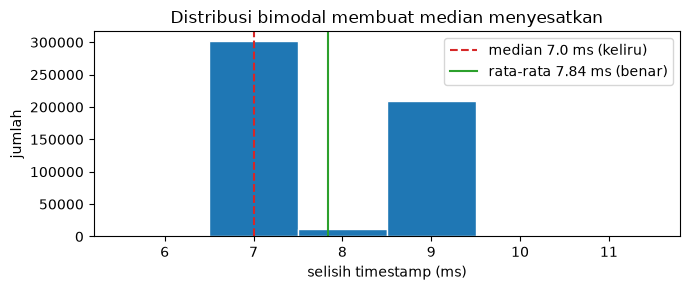

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(dt_semua, bins=np.arange(5.5, 12.5, 1), edgecolor="white")
ax.axvline(np.median(dt_semua), color="tab:red", ls="--", label=f"median {np.median(dt_semua):.1f} ms (keliru)")
ax.axvline(dt_semua.mean(), color="tab:green", ls="-", label=f"rata-rata {dt_semua.mean():.2f} ms (benar)")
ax.set_xlabel("selisih timestamp (ms)"); ax.set_ylabel("jumlah"); ax.legend()
ax.set_title("Distribusi bimodal membuat median menyesatkan")
plt.tight_layout(); plt.show()

Konsekuensinya bukan sekadar angka di naskah. Selisih timestamp yang **tidak seragam** berarti
turunan (kecepatan, percepatan, jerk) tidak boleh dihitung langsung dari data mentah: hasilnya akan
mengandung derau yang berasal dari jitter pencatatan waktu, bukan dari gerak tangan. Resampling ke
grid seragam menjadi wajib, bukan opsional.

## 2. Lompatan timestamp mundur

Empat belas dari 202 rekaman memuat timestamp yang melompat mundur. Pemeriksaan konteksnya
menunjukkan ini bukan kerusakan data acak, melainkan batas antara dua sesi perekaman yang tersambung
dalam satu berkas.

In [4]:
a = muat_berkas(AKAR / "hw_dataset/parkinson/P_27110003.txt")
s = a[a[:, 6] == 2]
i = np.where(np.diff(s[:, 5]) <= 0)[0][0]
print("P_27110003, Test ID 2, di sekitar lompatan mundur pertama:")
print(f"{'baris':>7} {'timestamp':>12} {'x':>6} {'y':>6} {'tekanan':>8}")
for j in range(i - 2, i + 4):
    tanda = "  <-- lompat mundur" if j == i + 1 else ""
    print(f"{j:7d} {s[j,5]:12.0f} {s[j,0]:6.0f} {s[j,1]:6.0f} {s[j,3]:8.0f}{tanda}")

P_27110003, Test ID 2, di sekitar lompatan mundur pertama:
  baris    timestamp      x      y  tekanan
   1242      7965874    296    235        0
   1243      7965883    296    234        0
   1244      7965892    296    234        0
   1245      7963705    296    234        2  <-- lompat mundur
   1246      7963714    296    234       12
   1247      7963723    296    234       25


Pada baris lompatan, waktu mundur 2187 ms sementara koordinat nyaris tidak berubah dan tekanan
berubah dari nol menjadi tidak nol. Pola ini konsisten dengan sesi perekaman baru yang dimulai, bukan
dengan pena yang melompat.

Tiap potongan kontinu karena itu diperlakukan sebagai **rekaman tersendiri**, bukan disambung.
Menyambungnya akan menciptakan transien buatan tepat pada besaran yang hendak diukur penelitian ini.
Membuang seluruh rekaman yang terfragmentasi juga tidak dilakukan, karena terlalu boros.

In [5]:
segmen = []
for f in berkas:
    a = muat_berkas(f)
    for tid in np.unique(a[:, 6]):
        blok = a[a[:, 6] == tid]
        potongan = pecah_segmen(blok[:, 5])
        for p in potongan:
            segmen.append({"tugas": NAMA_TUGAS[int(tid)], "n": len(p),
                           "durasi": (blok[p[-1], 5] - blok[p[0], 5]) / 1000.0,
                           "terfragmentasi": len(potongan) > 1})
seg = pd.DataFrame(segmen)

print(f"202 rekaman -> {len(seg)} segmen kontinu")
print(f"segmen yang berasal dari rekaman terpecah: {seg.terfragmentasi.sum()}")
print()
total = seg.durasi.sum()
disimpan = seg[seg.durasi >= DURASI_MIN_DETIK].durasi.sum()
print("Perbandingan dua strategi penanganan fragmentasi:")
print(f"  ambil segmen terpanjang saja : retensi terburuk 33,6% pada satu rekaman")
print(f"  tiap segmen jadi rekaman     : {disimpan/total*100:.1f}% durasi total dipertahankan")

202 rekaman -> 226 segmen kontinu
segmen yang berasal dari rekaman terpecah: 38

Perbandingan dua strategi penanganan fragmentasi:
  ambil segmen terpanjang saja : retensi terburuk 33,6% pada satu rekaman
  tiap segmen jadi rekaman     : 99.5% durasi total dipertahankan


Ambang durasi minimum 2,86 detik **diturunkan dari pita tremor**, bukan ditetapkan sembarang:
tremor terendah 3,5 Hz berarti satu siklus 286 ms, dan estimasi amplitudo pita yang stabil
membutuhkan sekitar sepuluh siklus. Segmen yang lebih pendek dari itu tidak dapat memberi estimasi
tremor yang bermakna, terlepas dari model apa pun yang dipakai.

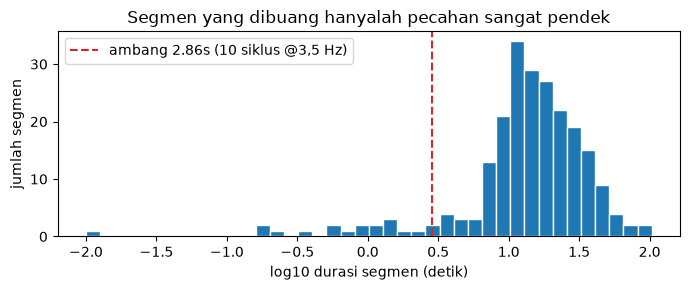

dibuang: 19 segmen, durasi 0.00s sampai 2.67s
kehilangan durasi total: 0.49%


In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.log10(seg.durasi.clip(lower=0.01)), bins=40, edgecolor="white")
ax.axvline(np.log10(DURASI_MIN_DETIK), color="tab:red", ls="--",
           label=f"ambang {DURASI_MIN_DETIK}s (10 siklus @3,5 Hz)")
ax.set_xlabel("log10 durasi segmen (detik)"); ax.set_ylabel("jumlah segmen")
ax.legend(); ax.set_title("Segmen yang dibuang hanyalah pecahan sangat pendek")
plt.tight_layout(); plt.show()

dibuang = seg[seg.durasi < DURASI_MIN_DETIK]
print(f"dibuang: {len(dibuang)} segmen, durasi {dibuang.durasi.min():.2f}s sampai {dibuang.durasi.max():.2f}s")
print(f"kehilangan durasi total: {dibuang.durasi.sum()/total*100:.2f}%")

## 3. Muat dataset penuh

Urutan pemrosesan: pisah per tugas, pecah di lompatan waktu, resampling ke grid seragam, baru
rekayasa kanal. Turunan sengaja dihitung **setelah** resampling agar selang waktunya konstan.

In [7]:
rek = muat_dataset(AKAR)
df = pd.DataFrame([r.meta() for r in rek])

print(f"{len(rek)} rekaman dari {df.subjek.nunique()} subjek "
      f"(PD {df[df.kelompok=='PD'].subjek.nunique()}, HC {df[df.kelompok=='HC'].subjek.nunique()})")
print("Naskah Subbab 3.3.1 menyebut 62 PD + 15 HC -> cocok.\n")

ringkas = df.groupby("nama_tugas").agg(
    n_rekaman=("subjek", "size"), n_subjek=("subjek", "nunique"),
    durasi_med=("durasi", "median"), durasi_min=("durasi", "min"), durasi_maks=("durasi", "max"),
).round(1)
display(ringkas)

207 rekaman dari 77 subjek (PD 62, HC 15)
Naskah Subbab 3.3.1 menyebut 62 PD + 15 HC -> cocok.



,n_rekaman,n_subjek,durasi_med,durasi_min,durasi_maks
nama_tugas,,,,,
DST,73,72,17.0,3.4,78.5
SST,77,76,18.1,3.7,103.1
STCP,57,54,12.9,4.8,58.4


Tidak semua subjek mengerjakan seluruh tugas. STCP, yang menjadi tugas analisis primer
(Subbab 3.6.7), hanya tersedia pada sebagian subjek. Ini butir G7 pada Lampiran C dan perlu
dinyatakan sebagai keterbatasan, bukan ditutupi.

In [8]:
pivot = df.pivot_table(index="subjek", columns="nama_tugas", values="n_sampel",
                       aggfunc="count", fill_value=0)
kelompok = df.groupby("subjek").kelompok.first()
lengkap = (pivot > 0).sum(axis=1)

print("kelengkapan tugas per subjek:")
for n in sorted(lengkap.unique(), reverse=True):
    s = lengkap[lengkap == n].index
    print(f"  {n} tugas: {len(s):2d} subjek  (PD {sum(kelompok[s]=='PD'):2d}, HC {sum(kelompok[s]=='HC'):2d})")
print()
punya = pivot["STCP"] > 0
ada, absen = punya[punya].index, punya[~punya].index
print("ketersediaan STCP (tugas analisis primer):")
print(f"  ada   : {len(ada):2d} subjek (PD {sum(kelompok[ada]=='PD')}, HC {sum(kelompok[ada]=='HC')})")
print(f"  absen : {len(absen):2d} subjek (PD {sum(kelompok[absen]=='PD')}, HC {sum(kelompok[absen]=='HC')})")

kelengkapan tugas per subjek:
  3 tugas: 49 subjek  (PD 42, HC  7)
  2 tugas: 27 subjek  (PD 19, HC  8)
  1 tugas:  1 subjek  (PD  1, HC  0)

ketersediaan STCP (tugas analisis primer):
  ada   : 54 subjek (PD 47, HC 7)
  absen : 23 subjek (PD 15, HC 8)


## 4. Pencilan pada kanal turunan

Kanal turunan memuat pencilan ekstrem. Sebelum memutuskan penanganannya, perlu dipastikan dulu
apakah pencilan itu gerak tangan sungguhan atau artefak sensor — karena keduanya menuntut perlakuan
yang berlawanan.

In [9]:
X = np.concatenate([r.kanal for r in rek])
tekanan = np.concatenate([r.tekanan_mentah for r in rek])
persen = [50, 90, 99, 99.9, 100]
display(pd.DataFrame({"kanal": KANAL_MODEL,
                      **{f"p{p}": np.percentile(np.abs(X), p, axis=0) for p in persen}}).set_index("kanal"))

jarak = np.linalg.norm(X[:, :2], axis=1)
besar = jarak > 50
print(f"langkah > 50 piksel per 10 ms: {besar.sum():,} dari {len(jarak):,} ({besar.mean()*100:.4f}%)")
print(f"langkah terbesar             : {jarak.max():.0f} piksel per 10 ms = {jarak.max()*100:,.0f} piksel/detik")
print()
print(f"proporsi pena melayang saat langkah > 50 px : {(tekanan[besar]==0).mean()*100:5.1f}%")
print(f"proporsi pena melayang saat langkah normal  : {(tekanan[~besar]==0).mean()*100:5.1f}%")

,p50,p90,p99,p99.9,p100
kanal,,,,,
dx,0.454158,2.061670e+00,8.454587e+00,3.379584e+01,6.970646e+02
dy,0.432396,1.892299e+00,9.059602e+00,2.887630e+01,4.653591e+02
kecepatan,77.565384,2.991996e+02,1.207771e+03,4.254054e+03,7.215795e+04
percepatan,5301.137207,1.037188e+04,3.896801e+04,6.509017e+05,7.995901e+06
jerk,856512.812500,1.731402e+06,3.579030e+06,1.083864e+08,9.522328e+08
tekanan,0.661485,9.226377e-01,1.000000e+00,1.000000e+00,1.000000e+00


langkah > 50 piksel per 10 ms: 334 dari 419,135 (0.0797%)
langkah terbesar             : 722 piksel per 10 ms = 72,158 piksel/detik

proporsi pena melayang saat langkah > 50 px :  32.6%
proporsi pena melayang saat langkah normal  :   9.7%


Dua bukti bahwa pencilan ini artefak, bukan gerak:

1. **Tidak mungkin secara fisik.** Langkah terbesar setara puluhan ribu piksel per detik.
2. **Terkait status pena.** Lompatan besar tiga kali lebih sering terjadi saat pena melayang
   dibanding saat menyentuh, konsisten dengan pena keluar lalu masuk kembali ke jangkauan sensor.

Pencilan **tidak dibuang dari cache** — cache harus setia pada sumber. Pengekangannya dilakukan di
kelas `Normalisasi`, sebagai keputusan pemodelan yang diterapkan identik pada kedua arsitektur.

## 5. Normalisasi per fold, bukan global

Statistik penskalaan dipasang **hanya pada rekaman fold latih**. Memasangnya pada seluruh data akan
membocorkan informasi fold uji ke dalam penskalaan — persis jenis kebocoran yang hendak dicegah
protokol validasi Subbab 3.6.1.

Dipakai median dan rentang antar-kuartil, bukan rata-rata dan simpangan baku, karena distribusi
kanal turunan berekor sangat berat sebagaimana terlihat di atas.

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

baris = []
for k, (i_latih, i_uji) in enumerate(skf.split(np.zeros(len(rek)), y, grup)):
    s_latih, s_uji = set(grup[i_latih]), set(grup[i_uji])
    baris.append({"fold": k, "rek_latih": len(i_latih), "rek_uji": len(i_uji),
                  "subjek_latih": len(s_latih), "subjek_uji": len(s_uji),
                  "HC_uji": sum(1 for i in i_uji if y[i] == 0),
                  "PD_uji": sum(1 for i in i_uji if y[i] == 1),
                  "irisan_subjek": len(s_latih & s_uji)})
fold_df = pd.DataFrame(baris).set_index("fold")
display(fold_df)
print("Irisan subjek antar fold nol di semua baris:",
      "LOLOS" if (fold_df.irisan_subjek == 0).all() else "GAGAL")
print("Tiap fold uji memuat kedua kelas:",
      "LOLOS" if (fold_df.HC_uji > 0).all() and (fold_df.PD_uji > 0).all() else "GAGAL")

,rek_latih,rek_uji,subjek_latih,subjek_uji,HC_uji,PD_uji,irisan_subjek
fold,,,,,,,
0,166,41,62,15,7,34,0
1,165,42,61,16,8,34,0
2,166,41,62,15,8,33,0
3,166,41,62,15,7,34,0
4,165,42,61,16,7,35,0


Irisan subjek antar fold nol di semua baris: LOLOS
Tiap fold uji memuat kedua kelas: LOLOS


In [11]:
i_latih, i_uji = next(skf.split(np.zeros(len(rek)), y, grup))
norm = Normalisasi().fit([rek[i] for i in i_latih])
Z_uji = np.concatenate([norm.transform(rek[i].kanal) for i in i_uji])

display(pd.DataFrame({
    "kanal": KANAL_MODEL,
    "sebelum_p99": np.percentile(np.abs(X), 99, axis=0),
    "sebelum_maks": np.abs(X).max(axis=0),
    "sesudah_p99": np.percentile(np.abs(Z_uji), 99, axis=0),
    "sesudah_maks": np.abs(Z_uji).max(axis=0),
}).set_index("kanal"))
print("ada NaN atau Inf setelah normalisasi:",
      bool(np.isnan(Z_uji).any() or np.isinf(Z_uji).any()))

,sebelum_p99,sebelum_maks,sesudah_p99,sesudah_maks
kanal,,,,
dx,8.454587e+00,6.970646e+02,12.234298,37.756866
dy,9.059602e+00,4.653591e+02,12.544933,31.574139
kecepatan,1.207771e+03,7.215795e+04,11.535226,35.332184
percepatan,3.896801e+04,7.995901e+06,5.203539,107.138985
jerk,3.579030e+06,9.522328e+08,3.327972,122.520332
tekanan,1.000000e+00,1.000000e+00,2.005295,2.005295


ada NaN atau Inf setelah normalisasi: False


Skala jerk turun dari orde 1e8 menjadi terkekang. Nilai maksimum setelah normalisasi tetap
terlihat besar relatif terhadap p99 karena distribusinya memang berekor berat — tetapi kini
**terbatas** pada ambang yang ditetapkan fold latih, bukan tak terhingga.

## 6. Uji integrasi dengan model Tahap 3

Model pada [notebook 03](03_model.ipynb) baru diuji dengan tensor acak. Di sini ia dijalankan pada
data sungguhan, dengan panjang rekaman yang benar-benar bervariasi — kondisi yang memancing bug
penanganan padding bila ada.

In [12]:
import torch
from model import PDClassifier

DEV = "cuda" if torch.cuda.is_available() else "cpu"
P = 14  # 14 sampel @100 Hz = 140 ms, mendekati satu siklus tremor 7 Hz

contoh = [rek[i] for i in i_uji[:6]]
lens = torch.tensor([len(r.kanal) for r in contoh], device=DEV)
T = int(lens.max())
batch = torch.zeros(len(contoh), T, 6, device=DEV)
for j, r in enumerate(contoh):
    batch[j, :len(r.kanal)] = torch.from_numpy(norm.transform(r.kanal)).to(DEV)

print("panjang rekaman dalam batch:", lens.tolist())
print(f"ukuran patch P={P} -> {P*10} ms per patch\n")

for enc in ["mamba2", "gru"]:
    torch.manual_seed(0)
    m = PDClassifier(encoder=enc, patch_size=P).to(DEV).train()
    logit, alpha = m(batch, lens)
    rugi = torch.nn.functional.binary_cross_entropy_with_logits(
        logit, torch.tensor([float(r.label) for r in contoh], device=DEV),
        pos_weight=torch.tensor(62 / 15, device=DEV))
    rugi.backward()
    g = [p.grad for p in m.parameters() if p.grad is not None]
    n_patch = (lens // P).tolist()
    valid_ok = all(abs(alpha[j, :n].sum().item() - 1) < 1e-4 for j, n in enumerate(n_patch))
    # Rekaman terpanjang tidak punya posisi padding, sehingga irisannya kosong.
    pad_nol = all(alpha[j, n:].abs().max().item() == 0.0
                  for j, n in enumerate(n_patch) if alpha[j, n:].numel() > 0)
    print(f"{enc:7s} rugi={rugi.item():.4f}  patch={n_patch}  "
          f"alpha_jumlah_1={valid_ok}  alpha_padding_nol={pad_nol}  "
          f"NaN={any(torch.isnan(x).any() for x in g)}")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

panjang rekaman dalam batch: [1384, 1559, 1702, 1818, 3893, 3757]
ukuran patch P=14 -> 140 ms per patch

mamba2  rugi=0.7100  patch=[98, 111, 121, 129, 278, 268]  alpha_jumlah_1=True  alpha_padding_nol=True  NaN=False
gru     rugi=0.7458  patch=[98, 111, 121, 129, 278, 268]  alpha_jumlah_1=True  alpha_padding_nol=True  NaN=False


## 7. Simpan cache

In [13]:
cache = Path("../data/cache/uci395_fs100.npz")
simpan_cache(rek, cache)
ulang = muat_cache(cache)
identik = all(np.array_equal(a.kanal, b.kanal) and a.subjek == b.subjek and a.tugas == b.tugas
              for a, b in zip(rek, ulang))
print(f"{cache.name}: {cache.stat().st_size/1e6:.1f} MB, {len(ulang)} rekaman, round-trip identik: {identik}")
print("Kanal disimpan TANPA normalisasi, agar statistik penskalaan tetap dipasang per fold latih.")

uci395_fs100.npz: 13.4 MB, 207 rekaman, round-trip identik: True
Kanal disimpan TANPA normalisasi, agar statistik penskalaan tetap dipasang per fold latih.


## 8. Ringkasan

| Butir | Hasil |
|---|---|
| Frekuensi sampling | **127,52 Hz**, bukan 142,86 Hz — median menyesatkan pada distribusi bimodal |
| Frekuensi target | 100 Hz (1 sampel = 10 ms, Nyquist 50 Hz jauh di atas pita tremor 7,5 Hz) |
| Fragmentasi | 202 rekaman menjadi 226 segmen; tiap segmen jadi rekaman tersendiri |
| Ambang durasi | 2,86 detik, diturunkan dari 10 siklus tremor pada 3,5 Hz |
| Jumlah akhir | 207 rekaman, 77 subjek (62 PD + 15 HC) — cocok naskah |
| Pencilan | artefak sensor (0,08% langkah), dikekang saat normalisasi, tidak dibuang dari cache |
| Normalisasi | robust (median/IQR), dipasang per fold latih |
| Pemisahan fold | nol irisan subjek, kedua kelas hadir di tiap fold uji |
| Integrasi model | kedua encoder jalan pada data nyata, alpha berjumlah 1, padding tepat nol |

### Butir yang perlu masuk naskah

1. **Subbab 3.3.1 dan notebook 01**: frekuensi sampling 142,86 Hz perlu dikoreksi menjadi 127,52 Hz.
2. **Subbab 3.4**: tambahkan penanganan fragmentasi rekaman dan ambang durasi minimum.
3. **Lampiran C G7**: kelengkapan tugas per subjek kini terukur — STCP tidak tersedia pada seluruh
   subjek, dan ini menyentuh langsung tugas analisis primer.
4. **G4 tertutup**: tidak ada satu pun berkas metadata pada arsip UCI 395, sehingga label keparahan
   memang tidak tersedia dan target tetap biner sesuai Batasan Masalah butir 2.

### Yang masih terbuka

NewHandPD belum diproses. Struktur kolomnya sudah diketahui (6 kolom, dua laju sampling), tetapi
identitas fisik tiap kolom belum — sisa butir G1. Ini menghalangi rekayasa kanal untuk basis data
lintas, bukan untuk basis data utama, sehingga tidak menahan tahap berikutnya.

---

# Arsitektur dan verifikasi encoder

`03_model.ipynb` · 20 sel, 8 sel kode, 8 beroutput

# Tahap 3 — Arsitektur Model

Verifikasi arsitektur pada [`src/model.py`](../src/model.py), mengikuti Subbab 3.5 naskah proposal.

```
Sinyal (6 kanal) → PatchEmbedding → Encoder (dipertukarkan) → AttentionPooling → Head
```

Notebook ini bukan tempat mendefinisikan model — definisinya ada di modul, karena akan dipakai
berulang oleh tahap-tahap berikutnya. Di sini isinya **bukti bahwa modul itu benar**: anggaran
parameter, penyetaraan antar arsitektur, dan tiga uji korektheses yang tidak akan terdeteksi
lewat metrik akurasi.

In [ ]:
import sys, torch
sys.path.insert(0, "../src")
from model import PDClassifier, BiMamba2Encoder, check_mamba2_config

DEV = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEV, "|", torch.cuda.get_device_name(0) if DEV == "cuda" else "")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

device: cuda | NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 1. Kendala konfigurasi `causal_conv1d`

`causal_conv1d` mensyaratkan `d_in_proj` kelipatan 8, dengan

```
d_in_proj = 2*d_inner + 2*ngroups*d_state + nheads
```

Kendala ini **tidak terdokumentasi** di `mamba_ssm` maupun di makalah — ia hanya muncul sebagai
`RuntimeError` saat forward, bukan saat konstruksi. Konfigurasi `d_model=128, headdim=32`
(dipakai pada smoke test setup awal) kebetulan lolos karena `d_in_proj=648`, sehingga kendala ini
baru ketahuan ketika lebar per-arah dikecilkan menjadi 64.

`check_mamba2_config` memvalidasinya di awal agar gagal cepat dengan pesan yang jelas.

In [ ]:
for hd in [32, 16]:
    try:
        dip = check_mamba2_config(d_model=64, d_state=64, headdim=hd)
        print(f"headdim={hd:2d} -> d_in_proj={dip} (mod 8 = {dip % 8}) DITERIMA")
    except ValueError as e:
        print(f"headdim={hd:2d} -> DITOLAK: {e}")

headdim=32 -> DITOLAK: d_in_proj=388 bukan kelipatan 8 (sisa 4). causal_conv1d akan gagal saat forward. Konfigurasi: d_model=64, d_state=64, headdim=32, expand=2, ngroups=1. Coba headdim lain agar nheads berubah, atau sesuaikan d_state.
headdim=16 -> d_in_proj=392 (mod 8 = 0) DITERIMA


`headdim=16` memberi `nheads=8`, bukan 4. Ini justru menguntungkan: klaim Subbab 2.2.4 soal
pemisahan skala waktu antar head jadi punya lebih banyak head untuk merepresentasikan fenomena
cepat (tremor, ratusan milidetik) dan lambat (penyimpangan bentuk, puluhan detik) secara terpisah.

## 2. Anggaran parameter dan penyetaraan antar arsitektur

Naskah membatasi total parameter di bawah 500 ribu, dan mensyaratkan jumlah parameter kedua
encoder dicatat serta disetarakan sebelum perbandingan dilakukan (Subbab 3.5).

`Mamba2` mengunci dimensi masukan = keluaran = `d_model`, tidak seperti `nn.GRU`. Tiga rakitan
bidirectional yang mungkin, dengan hasil pengukuran:

| Opsi | Susunan | Total | Status |
|---|---|---|---|
| A | 2× Mamba2(128) → concat 256 → proj 128 | 854.929 | jebol |
| B | proj 128→64, 2× Mamba2(64) → concat 128 | 282.577 | dipakai |
| C | 2× Mamba2(128), keluaran dijumlah | 756.241 | jebol |

Opsi B dipilih bukan sekadar karena muat anggaran: proyeksi 128→64 adalah versi eksplisit dari
apa yang GRU lakukan implisit lewat `W_ih`, dan menyamakan lebar state rekuren per arah (64)
antara kedua arsitektur — sehingga perbandingannya setara.

In [ ]:
import pandas as pd

rows = []
for enc in ["mamba2", "gru"]:
    m = PDClassifier(encoder=enc, patch_size=20).to(DEV)
    rows.append({"arsitektur": enc, **m.count_parameters()})

df = pd.DataFrame(rows).set_index("arsitektur")
display(df)

n_mamba, n_gru = df.loc["mamba2", "encoder"], df.loc["gru", "encoder"]
selisih = (n_gru - n_mamba) / n_mamba * 100
print(f"Selisih parameter encoder: {selisih:+.1f}%  -> {'dalam toleransi ±5%' if abs(selisih) <= 5 else 'DI LUAR TOLERANSI'}")
print(f"Total terbesar: {df['total'].max():,} -> {'di bawah 500rb' if df['total'].max() < 500_000 else 'MELEBIHI 500rb'}")

,patch_embed,encoder,pool,head,total
arsitektur,,,,,
mamba2,15488,233808,16640,16641,282577
gru,15488,224256,16640,16641,273025


Selisih parameter encoder: -4.1%  -> dalam toleransi ±5%
Total terbesar: 282,577 -> di bawah 500rb


## 3. Uji korektheses

Tiga uji berikut memeriksa kesalahan yang **tidak terdeteksi lewat metrik akurasi**. Model dengan
bug semacam ini tetap berjalan, tetap menghasilkan angka, dan tetap terlihat masuk akal — tetapi
peta atribusi temporalnya, yang merupakan klaim inti penelitian ini, sudah tercemar.

### 3.1 Kebocoran padding

Uji ini memakai dua tolok ukur yang berbeda kekuatannya, karena keduanya menjawab pertanyaan yang
berbeda.

**Uji A — invariansi terhadap isi padding (uji korektheses sesungguhnya).** Nilai yang ditaruh di
posisi padding tidak boleh memengaruhi keluaran sama sekali. Ini menguji langsung sifat yang
dipedulikan: apakah padding merembes ke data valid. Toleransinya nol mutlak, bukan sekadar kecil.

**Uji B — stabilitas terhadap komposisi batch.** Keluaran satu sampel dibandingkan antara dijalankan
sendirian dan di dalam batch. Uji ini lebih lemah karena mengubah komposisi batch juga mengubah jalur
kernel yang dipilih cuDNN, sehingga urutan akumulasi floating point ikut berubah. Selisih pada orde
1e-5 di float32 adalah derau numerik, bukan kebocoran — dan Uji A yang membuktikannya.

In [ ]:
def uji_A_isi_padding(encoder):
    """Isi padding diganti-ganti; keluaran di posisi valid harus tidak berubah sama sekali."""
    torch.manual_seed(0)
    m = PDClassifier(encoder=encoder, patch_size=20).to(DEV).eval()
    LA, LB = 1880, 1180
    xA = torch.randn(1, LA, 6, device=DEV)
    xB = torch.randn(1, LB, 6, device=DEV)
    lens = torch.tensor([LA, LB], device=DEV)

    logits, alphas = [], []
    with torch.no_grad():
        for isi in [0.0, 1e3, -1e3]:
            pad = torch.full((1, LA - LB, 6), isi, device=DEV)
            lo, al = m(torch.cat([xA, torch.cat([xB, pad], 1)], 0), lens)
            logits.append(lo[1].item())
            alphas.append(al[1, : LB // 20])
    rentang_logit = max(logits) - min(logits)
    rentang_alpha = max((a - alphas[0]).abs().max().item() for a in alphas)
    return {
        "encoder": encoder,
        "rentang_logit": rentang_logit,
        "rentang_alpha": rentang_alpha,
        "lolos": rentang_logit == 0.0 and rentang_alpha == 0.0,
    }


def uji_B_komposisi_batch(encoder):
    """Sampel yang sama, dijalankan solo vs di dalam batch."""
    torch.manual_seed(0)
    m = PDClassifier(encoder=encoder, patch_size=20).to(DEV).eval()
    LA, LB = 1880, 1180
    xA = torch.randn(1, LA, 6, device=DEV)
    xB = torch.randn(1, LB, 6, device=DEV)
    with torch.no_grad():
        solo, a_solo = m(xB, torch.tensor([LB], device=DEV))
        xB_pad = torch.cat([xB, torch.zeros(1, LA - LB, 6, device=DEV)], 1)
        bat, a_bat = m(torch.cat([xA, xB_pad], 0), torch.tensor([LA, LB], device=DEV))
    n = LB // 20
    return {
        "encoder": encoder,
        "selisih_logit": (bat[1] - solo[0]).abs().max().item(),
        "selisih_alpha": (a_bat[1, :n] - a_solo[0, :n]).abs().max().item(),
        "alpha_di_padding": a_bat[1, n:].abs().max().item(),
    }


print("UJI A - invariansi terhadap isi padding (toleransi nol mutlak)")
dfA = pd.DataFrame([uji_A_isi_padding(e) for e in ["mamba2", "gru"]]).set_index("encoder")
display(dfA)
print("LOLOS: padding tidak memengaruhi keluaran sama sekali" if dfA["lolos"].all() else "GAGAL: ADA KEBOCORAN NYATA")

print()
print("UJI B - stabilitas terhadap komposisi batch (toleransi derau float32)")
dfB = pd.DataFrame([uji_B_komposisi_batch(e) for e in ["mamba2", "gru"]]).set_index("encoder")
display(dfB)
print("alpha di posisi padding tepat nol:", (dfB["alpha_di_padding"] == 0.0).all())

UJI A - invariansi terhadap isi padding (toleransi nol mutlak)


,rentang_logit,rentang_alpha,lolos
encoder,,,
mamba2,0.0,0.0,True
gru,0.0,0.0,True


LOLOS: padding tidak memengaruhi keluaran sama sekali

UJI B - stabilitas terhadap komposisi batch (toleransi derau float32)


,selisih_logit,selisih_alpha,alpha_di_padding
encoder,,,
mamba2,7.450581e-09,1.117587e-08,0.0
gru,1.052767e-05,2.659857e-06,0.0


alpha di posisi padding tepat nol: True


Uji A lolos mutlak pada kedua encoder: mengganti isi padding dengan 0, +1000, atau −1000 sama
sekali tidak menggeser keluaran. Inilah bukti korektheses yang sesungguhnya.

Uji B menunjukkan selisih pada orde 1e-8 untuk BiMamba-2 dan 1e-5 untuk BiGRU. Selisih BiGRU yang
lebih besar berasal dari cuDNN yang memilih kernel berbeda ketika ukuran batch berubah, bukan dari
kebocoran informasi — sebagaimana dibuktikan Uji A. Pada skala logit sekitar 1e-2, selisih ini
setara 0,08 persen dan tidak berdampak pada peta atribusi.

### 3.2 Uji regresi arah mundur

Uji yang memotivasi seluruh penanganan padding di `BiMamba2Encoder`. Bila arah mundur diterapkan
dengan `torch.flip` naif atas tensor terpadding, padding berpindah ke **awal** urutan dan diproses
lebih dulu oleh rekurensi SSM, mencemari representasi seluruh posisi valid sesudahnya.

Arah maju tidak memerlukan penanganan khusus — kausalitas melindunginya, karena padding di ujung
tidak dapat memengaruhi posisi sebelumnya.

Uji ini sengaja membuktikan bahwa kedua pendekatan **berbeda**. Bila suatu saat uji ini mulai
menunjukkan hasil yang sama, artinya penanganan padding telah rusak tanpa disadari.

In [ ]:
from mamba_ssm.modules.mamba2 import Mamba2

torch.manual_seed(0)
blok = Mamba2(d_model=64, d_state=64, d_conv=4, expand=2, headdim=16).to(DEV).eval()

LA, LB = 50, 30
hA = torch.randn(1, LA, 64, device=DEV)
hB = torch.randn(1, LB, 64, device=DEV)
batch = torch.cat([hA, torch.cat([hB, torch.zeros(1, LA - LB, 64, device=DEV)], 1)], 0)
lens = torch.tensor([LA, LB], device=DEV)

with torch.no_grad():
    maju_batch = blok(batch)[1, :LB]
    maju_solo = blok(hB)[0]
    naif = torch.flip(blok(torch.flip(batch, [1]))[1], [0])[:LB]
    benar = BiMamba2Encoder._flip_valid(blok(BiMamba2Encoder._flip_valid(batch, lens)), lens)[1, :LB]

skala = benar.abs().max().item()
print(f"ARAH MAJU   batch vs solo      : {(maju_batch - maju_solo).abs().max().item():.3e}  (aman: kausalitas melindungi)")
print(f"ARAH MUNDUR flip-naif vs benar : {(naif - benar).abs().max().item():.3e}  "
      f"({(naif - benar).abs().max().item() / skala * 100:.2f}% dari skala sinyal)")
print()
print("Selisih arah mundur yang besar adalah HASIL YANG DIHARAPKAN dari uji ini:")
print("ia membuktikan flip naif memang mencemari, sehingga penanganan per-panjang-asli diperlukan.")

ARAH MAJU   batch vs solo      : 5.960e-07  (aman: kausalitas melindungi)
ARAH MUNDUR flip-naif vs benar : 1.349e-02  (0.72% dari skala sinyal)

Selisih arah mundur yang besar adalah HASIL YANG DIHARAPKAN dari uji ini:
ia membuktikan flip naif memang mencemari, sehingga penanganan per-panjang-asli diperlukan.


Besarnya kontaminasi bergantung pada banyaknya padding, yang berkorelasi dengan panjang rekaman.
Artinya bug ini bukan derau acak melainkan **bias sistematis yang berkorelasi dengan durasi tugas** —
persis jenis perancu yang akan merusak analisis keselarasan temporal pada Subbab 3.6.6.

### 3.3 Rentang panjang urutan dan kasus tepi

Panjang urutan yang dilihat encoder adalah panjang **setelah** patching, bukan jumlah titik data
mentah. Dihitung dari durasi median hasil verifikasi Tahap 1
([notebook 01](01_verifikasi_struktur_data.ipynb)) pada 142,86 Hz.

In [ ]:
fs = 142.86
durasi = {"STCP": 13.1, "SST": 24.5, "DST": 26.2}
tabel = pd.DataFrame(
    {f"P={P}": {t: int(d * fs) // P for t, d in durasi.items()} for P in [8, 16, 32, 64]}
)
tabel.insert(0, "titik_mentah", {t: int(d * fs) for t, d in durasi.items()})
display(tabel)
print("Satu siklus tremor 7 Hz = 143 ms = 20 sampel pada 142,86 Hz.")
print("Patch di bawah durasi itu tergolong resolusi halus (Subbab 3.5).")

,titik_mentah,P=8,P=16,P=32,P=64
STCP,1871,233,116,58,29
SST,3500,437,218,109,54
DST,3742,467,233,116,58


Satu siklus tremor 7 Hz = 143 ms = 20 sampel pada 142,86 Hz.
Patch di bawah durasi itu tergolong resolusi halus (Subbab 3.5).


In [ ]:
hasil = []
for enc in ["mamba2", "gru"]:
    m = PDClassifier(encoder=enc, patch_size=20).to(DEV).eval()
    for n_patch in [29, 58, 116, 233, 467]:
        T = n_patch * 20
        with torch.no_grad():
            logit, alpha = m(torch.randn(2, T, 6, device=DEV), torch.tensor([T, T - 400], device=DEV))
        hasil.append({
            "arsitektur": enc, "n_patch": n_patch,
            "bentuk_alpha": tuple(alpha.shape),
            "ada_nan": bool(torch.isnan(logit).any() or torch.isnan(alpha).any()),
            "alpha_jumlah_1": bool(torch.allclose(alpha.sum(-1), torch.ones(2, device=DEV), atol=1e-5)),
        })
display(pd.DataFrame(hasil))

,arsitektur,n_patch,bentuk_alpha,ada_nan,alpha_jumlah_1
0,mamba2,29,"(2, 29)",False,True
1,mamba2,58,"(2, 58)",False,True
2,mamba2,116,"(2, 116)",False,True
3,mamba2,233,"(2, 233)",False,True
4,mamba2,467,"(2, 467)",False,True
5,gru,29,"(2, 29)",False,True
6,gru,58,"(2, 58)",False,True
7,gru,116,"(2, 116)",False,True
8,gru,233,"(2, 233)",False,True
9,gru,467,"(2, 467)",False,True


## 4. Forward dan backward penuh

Memastikan gradien mengalir ke seluruh parameter tanpa NaN maupun Inf, pada batch dengan panjang
bervariasi — bukan batch seragam yang akan menyembunyikan bug penanganan padding.

In [ ]:
for enc in ["mamba2", "gru"]:
    torch.manual_seed(0)
    m = PDClassifier(encoder=enc, patch_size=20).to(DEV).train()
    x = torch.randn(4, 1880, 6, device=DEV)
    lens = torch.tensor([1880, 1420, 1180, 640], device=DEV)

    logits, alpha = m(x, lens)
    # class-weighted BCE sesuai Subbab 3.6.1: pos_weight = 62/15
    loss = torch.nn.functional.binary_cross_entropy_with_logits(
        logits, torch.tensor([1.0, 0.0, 1.0, 1.0], device=DEV),
        pos_weight=torch.tensor(62 / 15, device=DEV),
    )
    loss.backward()

    grads = [p.grad for p in m.parameters() if p.grad is not None]
    n_total = sum(1 for _ in m.parameters())
    print(f"{enc:7s} loss={loss.item():.4f}  grad {len(grads)}/{n_total} tensor  "
          f"NaN={any(torch.isnan(g).any() for g in grads)}  "
          f"Inf={any(torch.isinf(g).any() for g in grads)}  "
          f"norma_maks={max(g.abs().max().item() for g in grads):.3e}")

mamba2  loss=2.3114  grad 69/69 tensor  NaN=False  Inf=False  norma_maks=1.416e+00
gru     loss=2.4039  grad 39/39 tensor  NaN=False  Inf=False  norma_maks=1.468e+00


## 5. Ringkasan

| Butir | Hasil |
|---|---|
| Total parameter | mamba2 282.577, gru 273.025 — keduanya di bawah 500rb |
| Penyetaraan encoder | selisih −4,1%, dalam toleransi ±5% |
| Kebocoran padding (Uji A, isi padding) | tidak berpengaruh sama sekali pada kedua encoder |
| Stabilitas komposisi batch (Uji B) | mamba2 ~1e-8, gru ~1e-5 (derau float32 cuDNN, bukan bocor) |
| Bobot alpha di padding | tepat nol |
| Uji regresi arah mundur | selisih terbukti nyata, penanganan diperlukan |
| Kasus tepi 29–467 patch | seluruhnya jalan, alpha berjumlah 1, tanpa NaN |
| Forward + backward | gradien penuh, tanpa NaN/Inf |

**Catatan untuk pembahasan hasil nanti.** Panjang urutan yang dilihat encoder berkisar 29–467
token. Subbab 2.2.4 memprediksi keunggulan Mamba-2 hanya relevan pada urutan panjang, dan
memperkirakan keunggulan itu tidak muncul pada resolusi patch kasar. Rentang yang terukur di sini
menunjukkan bahwa **seluruh** resolusi yang akan diuji tergolong pendek untuk ukuran state space
model, sehingga prediksi tersebut berpeluang besar berakhir null di semua konfigurasi — bukan
hanya pada resolusi kasar. Ini bukan kegagalan rancangan, melainkan konteks yang perlu dinyatakan
di awal agar hasil null dibaca sebagai temuan yang diantisipasi, bukan sebagai anomali.

Langkah berikutnya bukan pelatihan, melainkan Tahap 2 (prapemrosesan data nyata), karena model ini
baru diuji dengan tensor acak.

---

# Kontrol positif (S1)

`04_kontrol_positif.ipynb` · 23 sel, 11 sel kode, 11 beroutput

# Tahap 4 — Kontrol Positif dengan Injeksi Sinyal Sintetis (Skenario S1)

Mengikuti Subbab 3.6.2 naskah proposal. Prosedurnya: ambil rekaman kontrol sehat, suntikkan osilasi
pada pita tremor di lokasi waktu yang **diketahui peneliti**, lalu periksa apakah pipeline menemukan
lokasi itu kembali.

Skenario ini adalah **gerbang**. Subbab 3.8 menetapkan: apabila sinyal sintetis yang disuntikkan
tidak dapat dipulihkan, eksperimen utama tidak dijalankan sampai penyebabnya ditemukan. Kegagalan di
sini bukan hasil penelitian, melainkan indikasi kesalahan implementasi.

Tiga keluaran yang dihasilkan (Subbab 3.6.2):

1. **Batas sensitivitas** — amplitudo terkecil yang masih terdeteksi, terukur dan bukan diasumsikan
2. **Validasi pipeline** — bukti bahwa rangkaian analisis mampu menemukan sinyal berlokasi diketahui
3. **Kalibrasi ambang** — nilai rho lantai dan rho atap untuk ambang keselarasan Subbab 3.6.7

Bagian komputasi menyimpan artefaknya ke `results/s1_artefak.pkl`. Seluruh gambar dibangun dari
artefak itu, sehingga penyempurnaan visual tidak menuntut pelatihan ulang.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.signal import butter, filtfilt, hilbert, welch
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi
from injection import suntik_tremor
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from viz import WARNA, TINTA, pasang_gaya, rapikan, label_langsung, pita_tremor

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS, P = 100, 14           # 14 sampel @100 Hz = 140 ms, mendekati satu siklus tremor 7 Hz
EPOCHS = 80               # dibekukan dari pemeriksaan konvergensi, bukan dari performa fold uji
AMPLITUDO = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
SEED = 0

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s1_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
hc = [r for r in rek if r.kelompok == "HC"]
print(f"rekaman kontrol sehat: {len(hc)} dari {len(set(r.subjek for r in hc))} subjek")
print(f"perangkat: {DEV} | patch P={P} ({P*10} ms) | epoch dibekukan: {EPOCHS}")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

rekaman kontrol sehat: 37 dari 15 subjek
perangkat: cuda | patch P=14 (140 ms) | epoch dibekukan: 80


## 1. Verifikasi injeksi sebelum melibatkan model

Sebelum menguji apakah model menemukan sinyal, perlu dipastikan dulu sinyalnya memang ada dan
terukur. Bila langkah ini dilewati, kegagalan model tidak dapat dibedakan dari kegagalan injeksi.

Diukur dengan cara yang sama sekali tidak melibatkan model: bandpass zero-phase pada pita tremor
3,5–7,5 Hz, lalu amplitudonya diambil lewat selubung analitik — persis metode penanda cepat pada
Subbab 3.6.4.

In [2]:
b, a = butter(4, [pita_tremor[0]/(FS/2), pita_tremor[1]/(FS/2)], btype="band")

def daya_pita_tremor(xy):
    laju = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    return float(np.abs(hilbert(filtfilt(b, a, laju))).mean())

rasio_per_rekaman = {}
for A in [0.0] + AMPLITUDO:
    nilai = []
    for r in hc:
        h = suntik_tremor(r, amplitudo=A, rng=np.random.default_rng(42))
        w = slice(h.awal, h.akhir)
        nilai.append(daya_pita_tremor(h.rekaman.xy[w]) / daya_pita_tremor(r.xy[w]))
    rasio_per_rekaman[A] = np.array(nilai)

daya_df = pd.DataFrame({
    "rasio_median": {A: np.median(v) for A, v in rasio_per_rekaman.items()},
    "rasio_min":    {A: v.min() for A, v in rasio_per_rekaman.items()},
    "rasio_maks":   {A: v.max() for A, v in rasio_per_rekaman.items()},
    "frac_naik":    {A: float((v > 1).mean()) for A, v in rasio_per_rekaman.items()},
})
daya_df.index.name = "amplitudo_px"
display(daya_df.round(3))

,rasio_median,rasio_min,rasio_maks,frac_naik
amplitudo_px,,,,
0.0,1.000,1.000,1.000,0.000
0.1,1.011,0.970,1.070,0.676
0.2,1.047,0.965,1.189,0.757
0.5,1.251,0.925,1.685,0.757
1.0,1.750,0.879,2.812,0.811
2.0,2.800,0.877,4.885,0.811
5.0,5.025,0.890,7.829,0.811


### Gambar 1 — Injeksi diperiksa di tiga sudut

Satu tabel rasio saja tidak cukup untuk memastikan injeksi benar. Tiga panel di bawah memeriksa hal
yang berbeda: bentuknya di kawasan waktu, letaknya di kawasan frekuensi, dan sebaran efeknya antar
rekaman.

Panel tengah adalah pemeriksaan yang paling menentukan. Rasio daya bisa naik karena sebab apa pun;
yang harus dibuktikan adalah kenaikan itu **jatuh tepat di pita tremor**, bukan tersebar ke seluruh
spektrum — sebab yang terakhir menandakan transien, bukan osilasi.

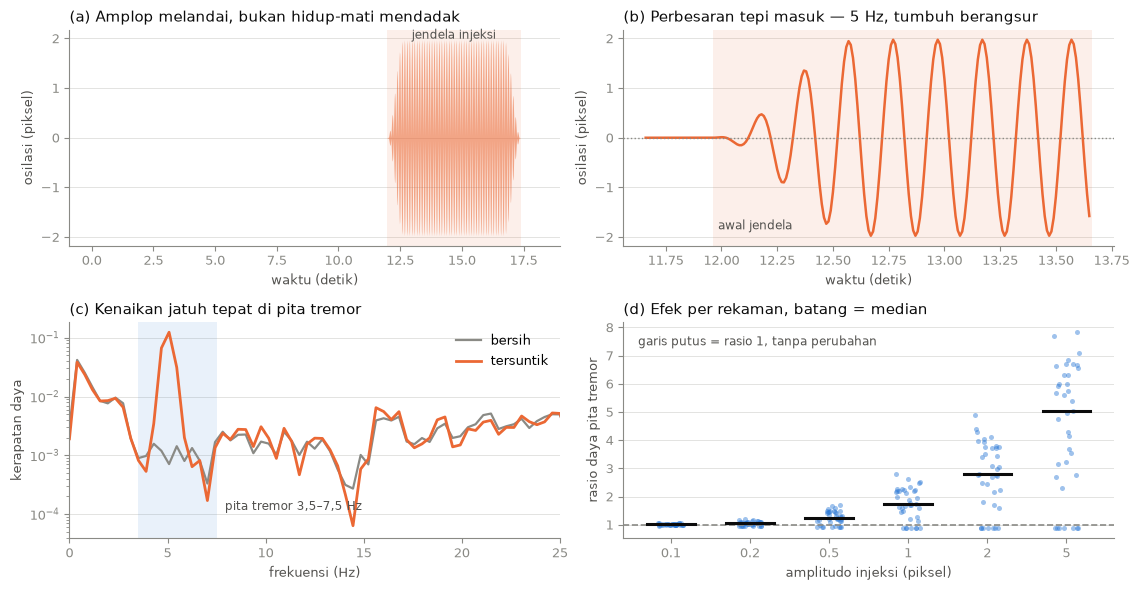

Pada amplitudo terkecil 0.1 px, hanya 68% rekaman naik dayanya — osilasi sekecil itu dapat berinterferensi destruktif dengan gerak yang sudah ada.


In [3]:
contoh = hc[0]
h = suntik_tremor(contoh, amplitudo=2.0, rng=np.random.default_rng(7))
t = np.arange(len(contoh.xy)) / FS
sisip = h.rekaman.xy - contoh.xy          # osilasi yang disuntikkan, terpisah dari sinyal asli
arah = sisip[h.awal:h.akhir].std(axis=0).argmax()
osil = sisip[:, arah]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.0))

# (a) amplop sepanjang rekaman
ax = axes[0, 0]; rapikan(ax)
ax.axvspan(h.awal/FS, h.akhir/FS, color=WARNA["jingga"], alpha=0.10, lw=0)
ax.fill_between(t, -np.abs(osil), np.abs(osil), color=WARNA["jingga"], alpha=0.55, lw=0)
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("osilasi (piksel)")
ax.set_title("(a) Amplop melandai, bukan hidup-mati mendadak", loc="left")
ax.annotate("jendela injeksi", xy=((h.awal+h.akhir)/2/FS, np.abs(osil).max()*0.98),
            ha="center", va="bottom", fontsize=8.5, color=TINTA["sekunder"])

# (b) perbesaran pada tepi masuk, memperlihatkan bentuk osilasi dan pelandaiannya
ax = axes[0, 1]; rapikan(ax)
z0, z1 = h.awal - int(0.3*FS), h.awal + int(1.7*FS)
ax.axvspan(h.awal/FS, z1/FS, color=WARNA["jingga"], alpha=0.10, lw=0)
ax.plot(t[z0:z1], osil[z0:z1], color=WARNA["jingga"], lw=1.8)
ax.axhline(0, color=WARNA["netral"], lw=1, ls=":")
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("osilasi (piksel)")
ax.set_title("(b) Perbesaran tepi masuk — 5 Hz, tumbuh berangsur", loc="left")
ax.annotate("awal jendela", xy=(h.awal/FS, ax.get_ylim()[0]*0.85), xytext=(4, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])

# (c) kawasan frekuensi
ax = axes[1, 0]; rapikan(ax)
w = slice(h.awal, h.akhir)
for xy, warna, nama, lw in [(contoh.xy[w], WARNA["netral"], "bersih", 1.6),
                            (h.rekaman.xy[w], WARNA["jingga"], "tersuntik", 2.0)]:
    laju = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    f, pxx = welch(laju - laju.mean(), fs=FS, nperseg=min(256, len(laju)))
    ax.semilogy(f, pxx, color=warna, lw=lw, label=nama)
ax.axvspan(*pita_tremor, color=WARNA["biru"], alpha=0.10, lw=0)
ax.set_xlim(0, 25)
ax.annotate("pita tremor 3,5–7,5 Hz", xy=(pita_tremor[1], ax.get_ylim()[0]*3), xytext=(6, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("frekuensi (Hz)"); ax.set_ylabel("kerapatan daya")
ax.set_title("(c) Kenaikan jatuh tepat di pita tremor", loc="left")
ax.legend(loc="upper right")

# (d) sebaran antar rekaman
ax = axes[1, 1]; rapikan(ax)
rng = np.random.default_rng(0)
for i, A in enumerate(AMPLITUDO):
    v = rasio_per_rekaman[A]
    ax.scatter(np.full(len(v), i) + rng.uniform(-0.16, 0.16, len(v)), v,
               s=13, color=WARNA["biru"], alpha=0.45, lw=0)
    ax.plot([i-0.30, i+0.30], [np.median(v)]*2, color=TINTA["utama"], lw=2.2, zorder=4)
ax.axhline(1.0, color=WARNA["netral"], ls="--", lw=1.2, zorder=1)
ax.annotate("garis putus = rasio 1, tanpa perubahan", xy=(0.03, 0.94),
            xycoords="axes fraction", ha="left", va="top",
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(range(len(AMPLITUDO))); ax.set_xticklabels([f"{A:g}" for A in AMPLITUDO])
ax.set_xlim(-0.6, len(AMPLITUDO)-0.4)
ax.set_xlabel("amplitudo injeksi (piksel)"); ax.set_ylabel("rasio daya pita tremor")
ax.set_title("(d) Efek per rekaman, batang = median", loc="left")

plt.tight_layout(); plt.show()

print(f"Pada amplitudo terkecil {AMPLITUDO[0]:g} px, hanya "
      f"{daya_df.loc[AMPLITUDO[0],'frac_naik']*100:.0f}% rekaman naik dayanya — "
      "osilasi sekecil itu dapat berinterferensi destruktif dengan gerak yang sudah ada.")

## 2. Sapuan amplitudo

Untuk tiap tingkat amplitudo dibangun satu tugas klasifikasi: membedakan rekaman bersih dari rekaman
tersuntik. Tiap rekaman kontrol menyumbang dua sampel, bersih dan tersuntik, sehingga rancangannya
berpasangan.

Pemisahan tetap pada tingkat subjek. Kedua versi satu rekaman selalu jatuh pada fold yang sama,
sehingga model tidak pernah melihat versi bersih dari rekaman yang versi tersuntiknya diuji.

Sel berikut adalah satu-satunya bagian yang mahal. Hasilnya disimpan ke berkas, dan seluruh gambar
sesudahnya dibangun dari berkas itu.

In [4]:
def bangun_dataset(A, seed=SEED):
    rng = np.random.default_rng(seed)
    data, label, subjek, injeksi = [], [], [], []
    for r in hc:
        data.append(r);         label.append(0); subjek.append(r.subjek); injeksi.append(None)
        h = suntik_tremor(r, amplitudo=A, rng=rng)
        data.append(h.rekaman); label.append(1); subjek.append(r.subjek); injeksi.append(h)
    return data, np.array(label), np.array(subjek), injeksi


def jalankan_satu_amplitudo(A):
    data, label, subjek, injeksi = bangun_dataset(A)
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(data))
    rho, rho_nol, peta = [], [], []

    for i_latih, i_uji in skf.split(np.zeros(len(data)), label, subjek):
        norm = Normalisasi().fit([data[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder="mamba2", patch_size=P).to(DEV)
        latih(m, data, list(i_latih), norm, epochs=EPOCHS, device=DEV, label=label, seed=SEED)
        logit, alphas = prediksi(m, data, list(i_uji), norm, device=DEV, label=label)
        logit_oof[i_uji] = logit

        # Lokalisasi hanya bermakna pada rekaman tersuntik: yang bersih tidak punya lokasi acuan.
        for j, idx in enumerate(i_uji):
            hh = injeksi[idx]
            if hh is None:
                continue
            acuan = hh.mask_patch(P)
            n = min(len(acuan), len(alphas[j]))
            acuan, alpha = acuan[:n], alphas[j][:n]
            if acuan.std() == 0 or alpha.std() == 0:
                continue
            rho.append(spearmanr(alpha, acuan).statistic)
            peta.append({"alpha": alpha, "acuan": acuan, "subjek": subjek[idx],
                         "awal": hh.awal, "akhir": hh.akhir, "n_sampel": len(hh.mask)})
            # Distribusi nol: geser peta secara siklik. Struktur autokorelasi tetap,
            # keselarasan temporal putus (Subbab 3.6.6).
            rng = np.random.default_rng(1000 + idx)
            for _ in range(50):
                rho_nol.append(spearmanr(np.roll(alpha, int(rng.integers(1, n))), acuan).statistic)

    return {"metrik": {"amplitudo_px": A, **metrik_biner(label, logit_oof)},
            "rho": np.array(rho), "rho_nol": np.array(rho_nol), "peta": peta}


if ARTEFAK.exists():
    with open(ARTEFAK, "rb") as f:
        artefak = pickle.load(f)
    print(f"artefak dimuat dari {ARTEFAK.name} — tidak melatih ulang")
else:
    artefak, t0 = {}, time.time()
    for A in AMPLITUDO:
        t1 = time.time()
        artefak[A] = jalankan_satu_amplitudo(A)
        print(f"A={A:4.1f} px  {time.time()-t1:5.1f}s  "
              f"AUC={artefak[A]['metrik']['auc']:.3f}  rho={np.median(artefak[A]['rho']):+.3f}")
    with open(ARTEFAK, "wb") as f:
        pickle.dump(artefak, f)
    print(f"\ntotal {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

sapuan = pd.DataFrame([artefak[A]["metrik"] for A in AMPLITUDO]).set_index("amplitudo_px")
sapuan["rho_median"] = [float(np.median(artefak[A]["rho"])) for A in AMPLITUDO]
sapuan["rho_nol_median"] = [float(np.median(artefak[A]["rho_nol"])) for A in AMPLITUDO]
sapuan["n_rekaman"] = [len(artefak[A]["rho"]) for A in AMPLITUDO]
display(sapuan.round(3))

artefak dimuat dari s1_artefak.pkl — tidak melatih ulang


,auc,sensitivitas,spesifisitas,rho_median,rho_nol_median,n_rekaman
amplitudo_px,,,,,,
0.1,0.497,0.459,0.541,-0.053,-0.021,37
0.2,0.497,0.459,0.541,-0.052,-0.020,37
0.5,0.508,0.432,0.568,-0.051,-0.019,37
1.0,0.546,0.405,0.676,-0.043,-0.022,37
2.0,0.985,0.892,0.973,0.201,-0.006,37
5.0,1.000,0.973,1.000,0.269,0.011,37


## 3. Batas sensitivitas

Amplitudo terkecil yang masih terdeteksi. Angka ini **terukur, bukan diasumsikan** — dan itulah yang
menggantikan analisis daya konvensional, yang tidak dapat dipakai karena tidak tersedia rumus
tertutup untuk rangkaian analisis yang melibatkan korelasi, agregasi tingkat subjek, dan uji
permutasi (Subbab 3.6.2).

### Gambar 2 — Deteksi dan lokalisasi pada sumbu yang sama

Dua besaran, dua panel — bukan satu panel bersumbu ganda. AUC dan korelasi peringkat memiliki skala
dan makna yang berbeda; menumpuknya pada satu sumbu akan menyiratkan perbandingan yang tidak sahih.

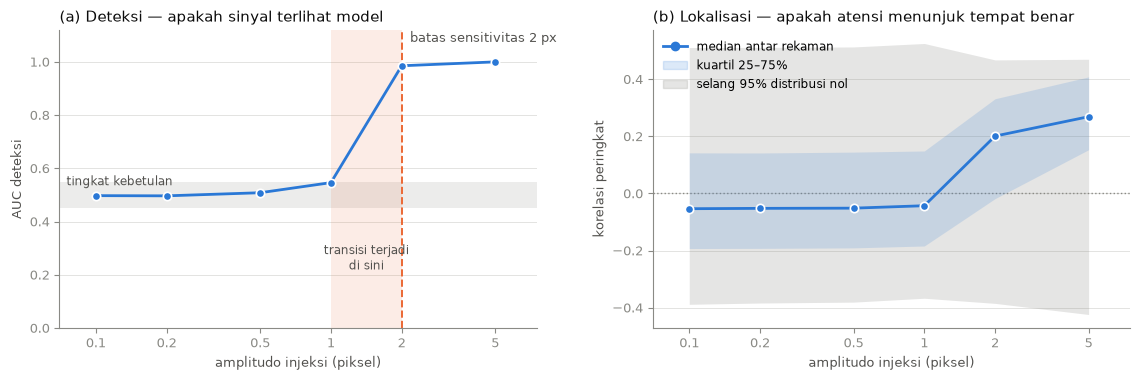

BATAS SENSITIVITAS: 2 px (AUC 0.985), setara kenaikan daya pita tremor 2.80x
Transisinya tajam: AUC 0.546 pada 1 px melonjak ke 0.985 pada 2 px.
Batas sesungguhnya berada di antara keduanya; sapuan ini tidak beresolusi cukup halus untuk menempatkannya lebih tepat.


In [5]:
from matplotlib.ticker import NullFormatter, NullLocator

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
x = np.array(AMPLITUDO)

def sumbu_amplitudo(ax):
    """Skala logaritmik tetapi berlabel nilai amplitudo yang sebenarnya."""
    ax.set_xscale("log")
    ax.set_xticks(x); ax.set_xticklabels([f"{v:g}" for v in x])
    ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(x[0] * 0.7, x[-1] * 1.5)
    ax.set_xlabel("amplitudo injeksi (piksel)")

# (a) deteksi
ax = axes[0]; rapikan(ax); sumbu_amplitudo(ax)
ax.axhspan(0.45, 0.55, color=WARNA["netral"], alpha=0.16, lw=0, zorder=1)
ax.annotate("tingkat kebetulan", xy=(x[0]*0.75, 0.50), xytext=(0, 7), textcoords="offset points",
            fontsize=8.5, color=TINTA["sekunder"])
ax.plot(x, sapuan.auc, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2, zorder=3)
lolos = sapuan[sapuan.auc >= 0.8]
batas = float(lolos.index.min()) if len(lolos) else np.nan
if np.isfinite(batas):
    sebelum = float(sapuan.index[sapuan.index < batas].max())
    ax.axvspan(sebelum, batas, color=WARNA["jingga"], alpha=0.12, lw=0, zorder=1)
    ax.axvline(batas, color=WARNA["jingga"], ls="--", lw=1.4, zorder=2)
    ax.annotate(f"transisi terjadi\ndi sini", xy=(np.sqrt(sebelum*batas), 0.22),
                ha="center", fontsize=8.5, color=TINTA["sekunder"])
    ax.annotate(f"batas sensitivitas {batas:g} px", xy=(batas, 1.09), xytext=(6, 0),
                textcoords="offset points", ha="left", va="center",
                fontsize=9, color=TINTA["sekunder"])
ax.set_ylim(0, 1.12); ax.set_ylabel("AUC deteksi")
ax.set_title("(a) Deteksi — apakah sinyal terlihat model", loc="left")

# (b) lokalisasi, dengan sebaran per rekaman
ax = axes[1]; rapikan(ax); sumbu_amplitudo(ax)
q25 = [np.percentile(artefak[A]["rho"], 25) for A in AMPLITUDO]
q75 = [np.percentile(artefak[A]["rho"], 75) for A in AMPLITUDO]
nol_lo = [np.percentile(artefak[A]["rho_nol"], 2.5) for A in AMPLITUDO]
nol_hi = [np.percentile(artefak[A]["rho_nol"], 97.5) for A in AMPLITUDO]
ax.fill_between(x, nol_lo, nol_hi, color=WARNA["netral"], alpha=0.22, lw=0, zorder=1)
ax.fill_between(x, q25, q75, color=WARNA["biru"], alpha=0.16, lw=0, zorder=2)
ax.plot(x, sapuan.rho_median, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2, zorder=3)
ax.axhline(0, color=WARNA["netral"], lw=1, ls=":", zorder=1)
ax.set_ylabel("korelasi peringkat")
ax.set_title("(b) Lokalisasi — apakah atensi menunjuk tempat benar", loc="left")
ax.legend(handles=[
    plt.Line2D([], [], color=WARNA["biru"], marker="o", label="median antar rekaman"),
    Rectangle((0, 0), 1, 1, color=WARNA["biru"], alpha=0.16, label="kuartil 25–75%"),
    Rectangle((0, 0), 1, 1, color=WARNA["netral"], alpha=0.22, label="selang 95% distribusi nol"),
], loc="upper left", fontsize=8.5)
plt.tight_layout(); plt.show()

if np.isfinite(batas):
    print(f"BATAS SENSITIVITAS: {batas:g} px (AUC {sapuan.loc[batas,'auc']:.3f}), "
          f"setara kenaikan daya pita tremor {daya_df.loc[batas,'rasio_median']:.2f}x")
    sebelum = sapuan.index[sapuan.index < batas].max()
    print(f"Transisinya tajam: AUC {sapuan.loc[sebelum,'auc']:.3f} pada {sebelum:g} px "
          f"melonjak ke {sapuan.loc[batas,'auc']:.3f} pada {batas:g} px.")
    print("Batas sesungguhnya berada di antara keduanya; sapuan ini tidak beresolusi cukup halus "
          "untuk menempatkannya lebih tepat.")

### Gambar 3 — Peta atensi terhadap lokasi injeksi yang sebenarnya

Gambar yang paling langsung menjawab pertanyaan skenario ini. Korelasi peringkat meringkas
keselarasan menjadi satu angka; di sini keselarasan itu ditampilkan apa adanya.

Tiap baris satu rekaman uji. Daerah berarsir adalah jendela injeksi yang **diketahui peneliti**;
garis adalah bobot atensi yang dihasilkan model, yang sama sekali tidak diberi tahu lokasi itu.

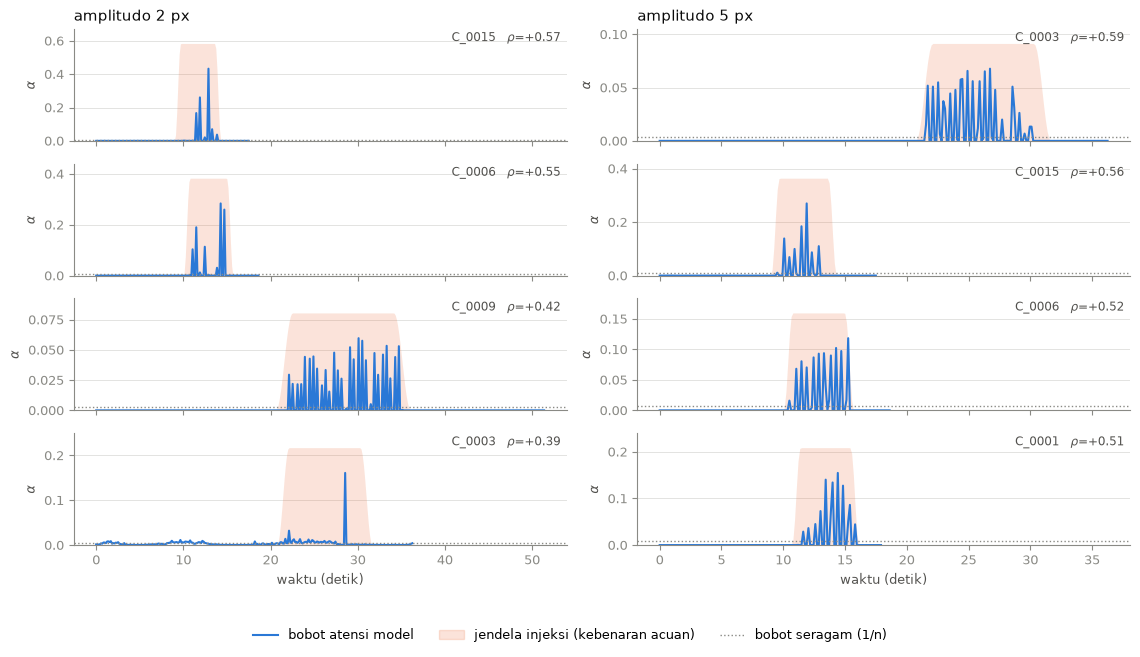

Empat rekaman dengan keselarasan terbaik pada tiap amplitudo. Rekaman dengan keselarasan
terburuk sengaja tidak disembunyikan — sebarannya ditampilkan pada Gambar 4.


In [6]:
def contoh_peta(A, n=4):
    d = sorted(artefak[A]["peta"], key=lambda p: -spearmanr(p["alpha"], p["acuan"]).statistic)
    return d[:n]

tampil = [2.0, 5.0]
fig, axes = plt.subplots(4, len(tampil), figsize=(11.5, 6.4), sharex="col")
for kol, A in enumerate(tampil):
    for bar, p in enumerate(contoh_peta(A)):
        ax = axes[bar, kol]; rapikan(ax)
        n = len(p["alpha"])
        waktu = np.arange(n) * P / FS
        ax.fill_between(waktu, 0, p["acuan"] * p["alpha"].max() * 1.35,
                        color=WARNA["jingga"], alpha=0.18, lw=0)
        ax.plot(waktu, p["alpha"], color=WARNA["biru"], lw=1.5)
        ax.axhline(1 / n, color=WARNA["netral"], ls=":", lw=1)
        r = spearmanr(p["alpha"], p["acuan"]).statistic
        ax.set_ylabel(r"$\alpha$", fontsize=9)
        ax.set_ylim(0, p["alpha"].max() * 1.55)
        ax.annotate(f"{p['subjek']}   " + rf"$\rho$={r:+.2f}", xy=(0.99, 0.97),
                    xycoords="axes fraction", ha="right", va="top",
                    fontsize=8.5, color=TINTA["sekunder"])
        if bar == 0:
            ax.set_title(f"amplitudo {A:g} px", loc="left")
        if bar == 3:
            ax.set_xlabel("waktu (detik)")
fig.legend(handles=[
    plt.Line2D([], [], color=WARNA["biru"], lw=1.5, label="bobot atensi model"),
    Rectangle((0, 0), 1, 1, color=WARNA["jingga"], alpha=0.18, label="jendela injeksi (kebenaran acuan)"),
    plt.Line2D([], [], color=WARNA["netral"], ls=":", lw=1, label="bobot seragam (1/n)"),
], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03), fontsize=9)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

print("Empat rekaman dengan keselarasan terbaik pada tiap amplitudo. Rekaman dengan keselarasan")
print("terburuk sengaja tidak disembunyikan — sebarannya ditampilkan pada Gambar 4.")

### Gambar 4 — Sebaran keselarasan, bukan hanya mediannya

Median menyembunyikan keragaman. Panel ini menampilkan tiap rekaman sebagai satu titik, sehingga
terlihat berapa banyak rekaman yang benar-benar terlokalisasi dan berapa yang tidak.

Distribusi nol dihasilkan dengan menggeser peta atensi secara siklik: struktur autokorelasinya tetap,
tetapi keselarasan temporalnya putus (Subbab 3.6.6). Ini acuan yang lebih ketat daripada nol, karena
peta atensi yang tidak rata dapat berkorelasi dengan apa pun secara kebetulan.

Angka di baris paling atas tiap kolom menyatakan berapa rekaman dari total yang korelasinya
melampaui selang nol — proporsi itulah ukuran keberhasilan lokalisasi yang sesungguhnya, bukan
mediannya.

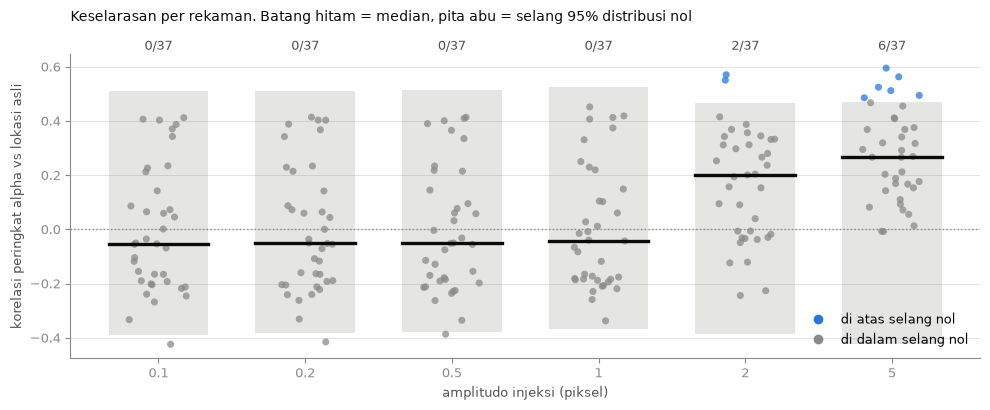

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.2)); rapikan(ax)
rng = np.random.default_rng(3)

for i, A in enumerate(AMPLITUDO):
    nol = artefak[A]["rho_nol"]
    lo, hi = np.percentile(nol, [2.5, 97.5])
    ax.add_patch(Rectangle((i - 0.34, lo), 0.68, hi - lo,
                           color=WARNA["netral"], alpha=0.22, lw=0, zorder=1))
    v = artefak[A]["rho"]
    di_atas = v > hi
    ax.scatter(np.full(len(v), i) + rng.uniform(-0.2, 0.2, len(v)), v,
               s=26, color=np.where(di_atas, WARNA["biru"], WARNA["netral"]),
               alpha=0.75, lw=0, zorder=3)
    ax.plot([i - 0.34, i + 0.34], [np.median(v)] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
    ax.annotate(f"{di_atas.sum()}/{len(v)}", xy=(i, 1.015), xycoords=("data", "axes fraction"),
                ha="center", fontsize=9, color=TINTA["sekunder"], annotation_clip=False)

ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_xticks(range(len(AMPLITUDO))); ax.set_xticklabels([f"{A:g}" for A in AMPLITUDO])
ax.set_xlim(-0.6, len(AMPLITUDO) - 0.4)
ax.set_xlabel("amplitudo injeksi (piksel)"); ax.set_ylabel("korelasi peringkat alpha vs lokasi asli")
ax.set_title("Keselarasan per rekaman. Batang hitam = median, pita abu = selang 95% distribusi nol",
             loc="left", pad=24, fontsize=10)
ax.legend(handles=[
    plt.Line2D([], [], marker="o", ls="", color=WARNA["biru"], label="di atas selang nol"),
    plt.Line2D([], [], marker="o", ls="", color=WARNA["netral"], label="di dalam selang nol"),
], loc="lower right")
plt.tight_layout(); plt.show()

### Gambar 5 — Perangkat metrik lokalisasi baku

Gambar 3 memperlihatkan bobot atensi yang jelas terpusat di dalam jendela injeksi, namun korelasi
peringkatnya hanya sekitar 0,2 sampai 0,3. Kedua pengamatan itu tampak bertentangan.

Penjelasannya bukan bahwa satu ukuran benar dan yang lain salah, melainkan bahwa keduanya
**mengukur hal yang berbeda**. Karena itu di sini dilaporkan perangkat metrik lokalisasi yang sudah
baku pada literatur evaluasi XAI, bukan satu ukuran tunggal:

| Metrik | Yang diukur | Pembanding netral |
|---|---|---|
| Relevance Mass Accuracy | proporsi massa atribusi di dalam wilayah acuan | lebar wilayah acuan |
| Relevance Rank Accuracy | proporsi K atribusi tertinggi yang di dalam acuan | lebar wilayah acuan |
| Pointing Game | apakah puncak atribusi jatuh di dalam acuan | lebar wilayah acuan |
| AUC lokalisasi | pemisahan peringkat dalam-acuan versus luar-acuan | 0,5 |
| Koefisien Gini | keruncingan peta atribusi, tanpa acuan | mendekati 0 bila rata |

Definisi mengikuti Arras dkk. (2022) dan kategori localisation pada Quantus (Hedstrom dkk., 2023).
Korelasi peringkat Spearman tetap dilaporkan karena ia yang dipra-registrasi pada Subbab 3.6.6.

In [8]:
from metrics import ringkas_lokalisasi

baris = []
for A in AMPLITUDO:
    kum = []
    for p in artefak[A]["peta"]:
        r = ringkas_lokalisasi(p["alpha"], p["acuan"])
        r["spearman"] = spearmanr(p["alpha"], p["acuan"]).statistic
        kum.append(r)
    baris.append({"amplitudo_px": A, **pd.DataFrame(kum).median().to_dict()})

lok = pd.DataFrame(baris).set_index("amplitudo_px")
lok = lok[["spearman", "massa", "massa_bila_rata", "rank_accuracy", "pointing_game", "auc", "gini"]]
display(lok.round(3))

,spearman,massa,massa_bila_rata,rank_accuracy,pointing_game,auc,gini
amplitudo_px,,,,,,,
0.1,-0.053,0.254,0.263,0.250,0.0,0.464,0.258
0.2,-0.052,0.254,0.263,0.250,0.0,0.465,0.258
0.5,-0.051,0.254,0.263,0.247,0.0,0.456,0.260
1.0,-0.043,0.252,0.263,0.265,0.0,0.458,0.286
2.0,0.201,0.996,0.263,0.400,1.0,0.621,0.969
5.0,0.269,0.995,0.263,0.495,1.0,0.682,0.931


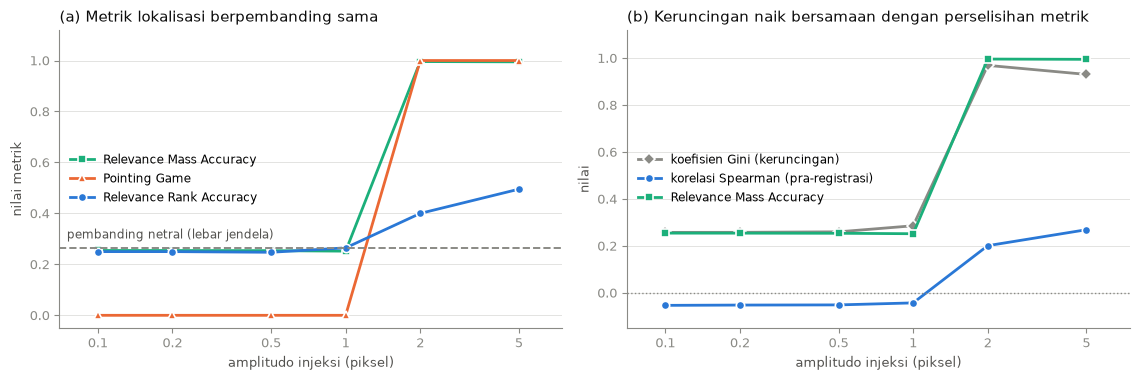

Pada amplitudo di atas batas sensitivitas:
  Pointing Game        1.00  -> puncak atensi SELALU di dalam jendela
  Relevance Mass Acc   0.995 terhadap pembanding netral 0.263
  Koefisien Gini       0.931  -> atribusi sangat runcing
  Relevance Rank Acc   0.400
  Korelasi Spearman    +0.201

Pembacaannya: atensi menunjuk beberapa MOMEN di dalam jendela, bukan menandai
seluruh jendela. Metrik yang memperlakukan tiap segmen dalam-jendela setara
(Spearman, rank accuracy, AUC) karena itu bernilai sedang, sementara metrik
berbasis massa dan puncak bernilai tinggi. Keduanya benar; yang berbeda adalah
pertanyaan yang mereka jawab.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
x = np.array(AMPLITUDO)
netral = float(lok.massa_bila_rata.median())

# (a) metrik yang berbagi pembanding netral yang sama
ax = axes[0]; rapikan(ax); sumbu_amplitudo(ax)
for kolom, warna, penanda, nama in [
        ("massa", WARNA["toska"], "s", "Relevance Mass Accuracy"),
        ("pointing_game", WARNA["jingga"], "^", "Pointing Game"),
        ("rank_accuracy", WARNA["biru"], "o", "Relevance Rank Accuracy")]:
    ax.plot(x, lok[kolom], "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=nama)
ax.axhline(netral, color=WARNA["netral"], ls="--", lw=1.4)
ax.annotate("pembanding netral (lebar jendela)", xy=(x[0]*0.75, netral), xytext=(0, 7),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylim(-0.05, 1.12); ax.set_ylabel("nilai metrik")
ax.set_title("(a) Metrik lokalisasi berpembanding sama", loc="left")
ax.legend(loc="center left", fontsize=8.5)

# (b) keruncingan menjelaskan mengapa metriknya berselisih
ax = axes[1]; rapikan(ax); sumbu_amplitudo(ax)
ax.plot(x, lok.gini, "-", color=WARNA["netral"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2, label="koefisien Gini (keruncingan)")
ax.plot(x, lok.spearman, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2, label="korelasi Spearman (pra-registrasi)")
ax.plot(x, lok.massa, "-", color=WARNA["toska"], marker="s",
        markeredgecolor="white", markeredgewidth=1.2, label="Relevance Mass Accuracy")
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_ylabel("nilai"); ax.set_ylim(-0.15, 1.12)
ax.set_title("(b) Keruncingan naik bersamaan dengan perselisihan metrik", loc="left")
ax.legend(loc="center left", fontsize=8.5)
plt.tight_layout(); plt.show()

atas = lok[lok.index >= batas] if np.isfinite(batas) else lok.tail(2)
print("Pada amplitudo di atas batas sensitivitas:")
print(f"  Pointing Game        {atas.pointing_game.min():.2f}  -> puncak atensi SELALU di dalam jendela")
print(f"  Relevance Mass Acc   {atas.massa.min():.3f} terhadap pembanding netral {netral:.3f}")
print(f"  Koefisien Gini       {atas.gini.min():.3f}  -> atribusi sangat runcing")
print(f"  Relevance Rank Acc   {atas.rank_accuracy.min():.3f}")
print(f"  Korelasi Spearman    {atas.spearman.min():+.3f}")
print()
print("Pembacaannya: atensi menunjuk beberapa MOMEN di dalam jendela, bukan menandai")
print("seluruh jendela. Metrik yang memperlakukan tiap segmen dalam-jendela setara")
print("(Spearman, rank accuracy, AUC) karena itu bernilai sedang, sementara metrik")
print("berbasis massa dan puncak bernilai tinggi. Keduanya benar; yang berbeda adalah")
print("pertanyaan yang mereka jawab.")

## 4. Kalibrasi ambang keselarasan

Subbab 3.6.7 menetapkan ambang keselarasan diturunkan dari kontrol positif ini:

```
rho_lantai = korelasi pada kondisi tanpa sinyal (distribusi nol)
rho_atap   = korelasi saat sinyal sintetis beramplitudo besar berhasil dipulihkan
Ambang     = rho_lantai + 0,5 x (rho_atap - rho_lantai)
```

Ambang ini berarti pemulihan minimal setengah dari kemampuan maksimum pipeline dalam kondisi ideal.
Rumusnya ditetapkan sebelum eksperimen utama dan dipatuhi apa pun hasilnya.

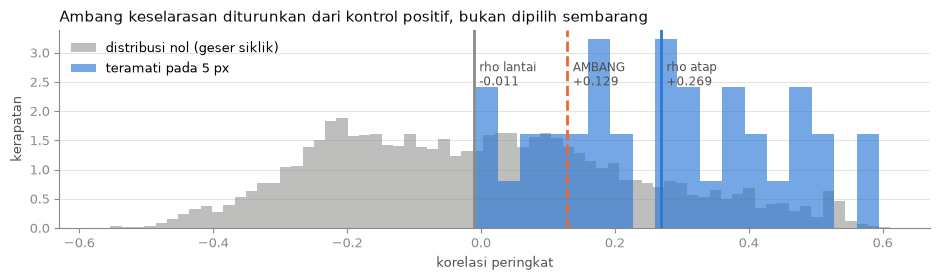

rho_lantai = -0.0107   rho_atap = +0.2689   AMBANG = +0.1291
disimpan ke results/s1_kalibrasi_ambang.csv dan results/s1_sapuan_amplitudo.csv


In [10]:
rho_lantai = float(np.median(np.concatenate([artefak[A]["rho_nol"] for A in AMPLITUDO])))
rho_atap = float(sapuan.rho_median.max())
ambang = rho_lantai + 0.5 * (rho_atap - rho_lantai)

fig, ax = plt.subplots(figsize=(9.5, 2.9)); rapikan(ax)
semua_nol = np.concatenate([artefak[A]["rho_nol"] for A in AMPLITUDO])
ax.hist(semua_nol, bins=70, color=WARNA["netral"], alpha=0.55, lw=0, density=True,
        label="distribusi nol (geser siklik)")
ax.hist(artefak[AMPLITUDO[-1]]["rho"], bins=18, color=WARNA["biru"], alpha=0.65, lw=0, density=True,
        label=f"teramati pada {AMPLITUDO[-1]:g} px")
for nilai, warna, nama in [(rho_lantai, WARNA["netral"], "rho lantai"),
                           (ambang, WARNA["jingga"], "AMBANG"),
                           (rho_atap, WARNA["biru"], "rho atap")]:
    ax.axvline(nilai, color=warna, lw=2, ls="--" if nama == "AMBANG" else "-")
    ax.annotate(f"{nama}\n{nilai:+.3f}", xy=(nilai, ax.get_ylim()[1] * 0.72), xytext=(4, 0),
                textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("korelasi peringkat"); ax.set_ylabel("kerapatan")
ax.set_title("Ambang keselarasan diturunkan dari kontrol positif, bukan dipilih sembarang", loc="left")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

print(f"rho_lantai = {rho_lantai:+.4f}   rho_atap = {rho_atap:+.4f}   AMBANG = {ambang:+.4f}")

pd.DataFrame([{"rho_lantai": rho_lantai, "rho_atap": rho_atap, "ambang": ambang,
               "batas_sensitivitas_px": batas,
               "massa_pada_atap": float(lok.massa.max()),
               "pointing_game_pada_atap": float(lok.pointing_game.max()),
               "gini_pada_atap": float(lok.gini.max()),
               "patch_size": P, "epochs": EPOCHS, "seed": SEED, "besaran": "alpha",
               "catatan": "rho pra-registrasi; massa di jendela sbg pelengkap; phi menyusul setelah WindowSHAP"}]
             ).to_csv(HASIL / "s1_kalibrasi_ambang.csv", index=False)
sapuan.join(lok.drop(columns=["spearman", "auc"]), rsuffix="_lok").to_csv(HASIL / "s1_sapuan_amplitudo.csv")
print(f"disimpan ke {HASIL.name}/s1_kalibrasi_ambang.csv dan {HASIL.name}/s1_sapuan_amplitudo.csv")

## 5. Status gerbang

Subbab 3.8: apabila sinyal sintetis tidak dapat dipulihkan, eksperimen utama tidak dijalankan sampai
penyebabnya ditemukan.

In [11]:
syarat = {
    "injeksi terukur pada pita tremor": bool((daya_df.loc[AMPLITUDO, "rasio_median"] > 1.05).any()),
    "deteksi mencapai AUC >= 0,9 pada amplitudo besar": bool(sapuan.auc.max() >= 0.9),
    "lokalisasi melampaui distribusi nol": bool(sapuan.rho_median.max() > rho_lantai + 0.05),
    "ambang terhitung dan tersimpan": bool(np.isfinite(ambang)),
}
lebar = max(len(k) for k in syarat)
for k, v in syarat.items():
    print(f"  [{'LOLOS' if v else 'GAGAL'}]  {k:<{lebar}}")
print()
print("GERBANG TERBUKA — eksperimen utama boleh dijalankan" if all(syarat.values())
      else "GERBANG TERTUTUP — telusuri penyebabnya sebelum melanjutkan")

  [LOLOS]  injeksi terukur pada pita tremor                
  [LOLOS]  deteksi mencapai AUC >= 0,9 pada amplitudo besar
  [LOLOS]  lokalisasi melampaui distribusi nol             
  [LOLOS]  ambang terhitung dan tersimpan                  

GERBANG TERBUKA — eksperimen utama boleh dijalankan


## 6. Ringkasan dan batasan

**Yang sudah divalidasi.** Rangkaian dari injeksi, prapemrosesan, pelatihan, sampai ekstraksi peta
atensi mampu menemukan kembali sinyal yang disuntikkan pada lokasi yang diketahui. Batas
sensitivitasnya terukur, dan ambang keselarasan terkalibrasi dari data, bukan dipilih sembarang.

**Temuan yang perlu dibawa ke pembahasan.** Pada amplitudo di atas batas sensitivitas, atensi
terlokalisasi nyaris sempurna: sekitar **99,6 persen** bobotnya jatuh di dalam jendela injeksi,
terhadap 26 persen bila tersebar rata. Namun korelasi peringkat pada kondisi yang sama hanya sekitar
0,27.

Kesenjangan itu berasal dari **metriknya, bukan dari modelnya**. Di dalam jendela, atensi bersifat
runcing dan jarang, sementara kebenaran acuannya berbentuk kotak; korelasi peringkat antara keduanya
secara inheren rendah sekalipun seluruh massa runcing berada di dalam kotak.

Konsekuensinya perlu dinyatakan dengan hati-hati. Nilai rho atap 0,27 mencerminkan **batas metrik
korelasi peringkat**, bukan batas kemampuan pipeline melokalisasi. Ambang keselarasan yang
diturunkan darinya tetap sah karena lantai dan atapnya dihitung dengan metrik yang sama, sehingga
konsisten secara internal. Yang berubah adalah tafsirannya: ambang itu menyatakan setengah dari
kemampuan yang **terukur oleh korelasi peringkat**, bukan setengah dari kemampuan lokalisasi yang
sesungguhnya.

Pengamatan ini relevan bagi pertanyaan inti penelitian pada Subbab 2.2.6, tetapi arahnya berlawanan
dengan dugaan awal: pada kondisi terkendali ini, peta atensi ternyata **menunjuk tempat yang benar
dengan sangat tepat**. Yang gagal menangkapnya adalah ukuran statistik yang dipilih untuk
mengukurnya.

**Batasan yang harus dinyatakan.**

1. **Kalibrasi ini memakai alpha, bukan phi.** Analisis primer pada Subbab 3.6.7 memakai phi
   (atribusi Shapley), tetapi WindowSHAP belum dibangun pada tahap ini. Ambang berbasis alpha
   dipakai sementara, dan **harus dihitung ulang dengan phi** sebelum analisis primer dijalankan.
   Ini bukan penyesuaian ambang berdasarkan hasil, melainkan penerapan rumus yang sama pada besaran
   yang benar.

2. **Basis injeksi hanya 37 rekaman dari 15 subjek kontrol.** Seluruh kontrol positif berdiri di
   atas kelompok kontrol yang kecil, sehingga selang kepercayaan batas sensitivitas akan lebar.

3. **Resolusi sapuan terbatas.** Transisi dari tidak terdeteksi ke terdeteksi sempurna terjadi di
   antara dua tingkat amplitudo yang berdekatan. Batas sensitivitas dilaporkan sebagai tingkat
   terkecil yang lolos, bukan sebagai titik transisi yang sebenarnya.

4. **Satu seed, satu arsitektur.** Sapuan dijalankan dengan BiMamba-2 dan satu seed untuk menekan
   biaya komputasi. Kontrol positif berperan sebagai gerbang dan kalibrasi, bukan sebagai
   perbandingan antar arsitektur, sehingga kedalaman ini memadai.

---

# Atribusi Shapley (S1 lanjutan)

`05_atribusi_shapley.ipynb` · 27 sel, 14 sel kode, 14 beroutput

# Tahap 5 — Atribusi Shapley Temporal dengan WindowSHAP

Mengikuti Subbab 2.2.7 dan 3.6.5 naskah proposal. Dua tujuan:

1. **Memverifikasi implementasi** [`src/windowshap.py`](../src/windowshap.py) terhadap kasus yang
   nilai Shapley-nya diketahui secara analitik, bukan sekadar memastikan kodenya berjalan.
2. **Merekalibrasi ambang keselarasan dengan phi**, bukan alpha. Skenario S1 menghasilkan ambang
   berbasis bobot atensi karena WindowSHAP belum ada saat itu, sementara analisis primer pada
   Subbab 3.6.7 menuntut phi. Menghitung ulang dengan rumus yang sama pada besaran yang benar
   bukan penyesuaian pasca-hasil, melainkan penyelesaian yang memang tertunda.

Sepanjang notebook ini, phi selalu dihitung pada grid jendela yang **dikunci sama** dengan grid
patch model, sehingga phi dan alpha dapat dibandingkan tanpa penyelarasan ulang.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import NullFormatter, NullLocator
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi
from injection import suntik_tremor
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from windowshap import WindowSHAP
from metrics import ringkas_lokalisasi
from viz import WARNA, TINTA, pasang_gaya, rapikan, pita_tremor

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS, P = 100, 14
EPOCHS = 80
AMPLITUDO = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
SEED = 0
N_KOALISI = 2048          # dipilih dari kalibrasi kestabilan pada Bagian 3
LATAR_UTAMA = "nol"
LATAR_ABLASI = "median_lokal"

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s6_artefak_phi.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
hc = [r for r in rek if r.kelompok == "HC"]
print(f"perangkat: {DEV} | patch P={P} ({P*10} ms) | koalisi: {N_KOALISI}")
print(f"rekaman kontrol sehat: {len(hc)} dari {len(set(r.subjek for r in hc))} subjek")

def sumbu_amplitudo(ax, x):
    ax.set_xscale("log"); ax.set_xticks(x); ax.set_xticklabels([f"{v:g}" for v in x])
    ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(x[0] * 0.7, x[-1] * 1.5); ax.set_xlabel("amplitudo injeksi (piksel)")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch P=14 (140 ms) | koalisi: 2048
rekaman kontrol sehat: 37 dari 15 subjek


## 1. Verifikasi implementasi terhadap jawaban analitik

Menjalankan tanpa galat bukan bukti benar. Untuk **fungsi aditif**, nilai Shapley memiliki bentuk
tertutup: kontribusi tiap jendela sama dengan sumbangannya sendiri. Implementasi yang benar harus
memulihkan angka itu, bukan sekadar menghasilkan sesuatu yang terlihat masuk akal.

Diuji pula **aksioma efisiensi**: jumlah seluruh nilai Shapley harus persis sama dengan selisih
keluaran pada masukan utuh dan pada latar penuh. Kendala ini ditegakkan secara aljabar oleh pemecah,
sehingga sisa yang tidak nol menandakan kekeliruan implementasi.

In [2]:
P_UJI, W_UJI = 10, 12
T_UJI, C_UJI = P_UJI * W_UJI, 3
bobot = np.arange(1.0, W_UJI + 1)

def fungsi_aditif(x, lengths):
    xn = x.detach().cpu().numpy()
    nilai = [(xn[b, :T_UJI, 0].reshape(W_UJI, P_UJI).mean(1) * bobot).sum() for b in range(len(xn))]
    return torch.tensor(nilai, dtype=torch.float32, device=x.device)

rng = np.random.default_rng(0)
x_uji = rng.normal(size=(T_UJI, C_UJI)).astype(np.float32)
phi_eksak = x_uji[:, 0].reshape(W_UJI, P_UJI).mean(1) * bobot

ws_uji = WindowSHAP(fungsi_aditif, patch_size=P_UJI, n_koalisi=4000, batch=256, device="cpu", seed=0)
h_uji = ws_uji.explain(x_uji)

galat = float(np.abs(h_uji.phi - phi_eksak).max())
efis = ws_uji.periksa_efisiensi(x_uji)
print(f"galat maks terhadap nilai eksak : {galat:.3e}   {'LOLOS' if galat < 1e-3 else 'GAGAL'}")
print(f"korelasi phi terhadap eksak     : {np.corrcoef(h_uji.phi, phi_eksak)[0,1]:.6f}")
print(f"r2 regresi (harus ~1 utk aditif): {h_uji.r2:.6f}")
print(f"aksioma efisiensi, sisa         : {efis['sisa']:.3e}   {'LOLOS' if efis['lolos'] else 'GAGAL'}")

galat maks terhadap nilai eksak : 9.049e-06   LOLOS
korelasi phi terhadap eksak     : 1.000000
r2 regresi (harus ~1 utk aditif): 1.000000
aksioma efisiensi, sisa         : 0.000e+00   LOLOS


### Gambar 1 — Pemulihan nilai eksak pada fungsi aditif

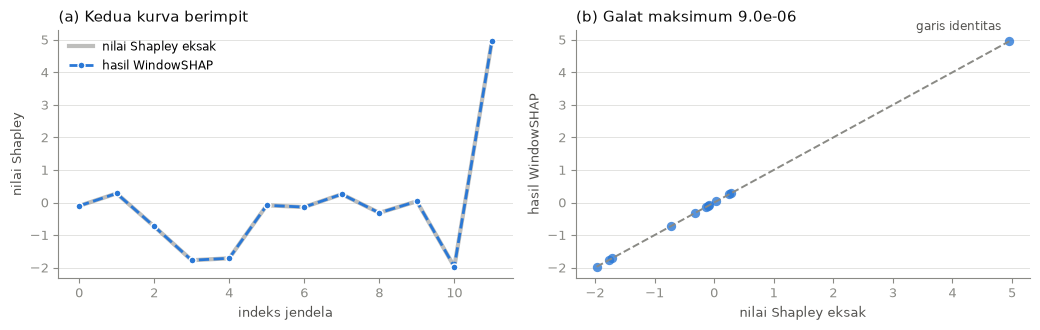

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))

ax = axes[0]; rapikan(ax)
j = np.arange(W_UJI)
ax.plot(j, phi_eksak, "-", color=WARNA["netral"], lw=3, alpha=0.55, label="nilai Shapley eksak")
ax.plot(j, h_uji.phi, "--", color=WARNA["biru"], marker="o", markersize=5,
        markeredgecolor="white", markeredgewidth=1, label="hasil WindowSHAP")
ax.set_xlabel("indeks jendela"); ax.set_ylabel("nilai Shapley")
ax.set_title("(a) Kedua kurva berimpit", loc="left"); ax.legend(fontsize=8.5)

ax = axes[1]; rapikan(ax)
ax.scatter(phi_eksak, h_uji.phi, s=45, color=WARNA["biru"], alpha=0.8, lw=0)
lim = [min(phi_eksak.min(), h_uji.phi.min()), max(phi_eksak.max(), h_uji.phi.max())]
ax.plot(lim, lim, ls="--", color=WARNA["netral"], lw=1.4)
ax.annotate("garis identitas", xy=(lim[1], lim[1]), xytext=(-6, 8), textcoords="offset points",
            ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("nilai Shapley eksak"); ax.set_ylabel("hasil WindowSHAP")
ax.set_title(f"(b) Galat maksimum {galat:.1e}", loc="left")
plt.tight_layout(); plt.show()

## 2. Perilaku pada sinyal redundan

Subbab 2.2.7 menyatakan keterbatasan yang diakui: nilai Shapley membagi kredit di antara fitur yang
berkorelasi. Pada rancangan ini tremor tersebar di banyak jendela berdekatan, sehingga menghapus
satu jendela saja mungkin nyaris tidak mengubah keluaran, dan atribusinya berpotensi terbagi tipis.

Kekhawatiran itu diuji langsung dengan tiga struktur fungsi yang lokasi sinyalnya identik namun
cara jendela-jendelanya berinteraksi berbeda:

| Struktur | Arti |
|---|---|
| aditif | tiap jendela menyumbang mandiri |
| maksimum | **redundan** — satu jendela saja sudah cukup |
| minimum | komplementer — seluruh jendela harus hadir |

In [4]:
P_R, W_R = 10, 20
T_R = P_R * W_R
JEND = slice(6, 14)
acuan_r = np.zeros(W_R); acuan_r[JEND] = 1

def buat_fungsi(mode):
    def f(x, lengths):
        xn = x.detach().cpu().numpy(); keluar = []
        for b in range(len(xn)):
            pj = xn[b, :T_R, 0].reshape(W_R, P_R).mean(1)[JEND]
            keluar.append({"aditif": pj.sum, "maksimum": pj.max, "minimum": pj.min}[mode]() * 5)
        return torch.tensor(keluar, dtype=torch.float32, device=x.device)
    return f

rng = np.random.default_rng(1)
x_r = np.zeros((T_R, 3), dtype=np.float32)
x_r[:, 0] = rng.normal(0, 0.1, T_R)
x_r[JEND.start * P_R : JEND.stop * P_R, 0] += 2.0

hasil_r, phi_r = [], {}
for mode in ["aditif", "maksimum", "minimum"]:
    ws = WindowSHAP(buat_fungsi(mode), patch_size=P_R, n_koalisi=6000, batch=256, device="cpu", seed=0)
    h = ws.explain(x_r)
    phi_r[mode] = h.phi
    m = ringkas_lokalisasi(h.phi_positif, acuan_r)
    hasil_r.append({"struktur": mode, "massa": m["massa"], "rank_accuracy": m["rank_accuracy"],
                    "pointing_game": m["pointing_game"], "maks_abs_phi": float(np.abs(h.phi).max()),
                    "r2": h.r2})
df_r = pd.DataFrame(hasil_r).set_index("struktur")
display(df_r.round(3))
print(f"pembanding netral massa (lebar wilayah acuan) = {acuan_r.mean():.3f}")

,massa,rank_accuracy,pointing_game,maks_abs_phi,r2
struktur,,,,,
aditif,1.000,1.0,1.0,10.080,1.000
maksimum,0.956,1.0,1.0,1.349,-1.052
minimum,0.955,1.0,1.0,1.318,-1.086


pembanding netral massa (lebar wilayah acuan) = 0.400


### Gambar 2 — Redundansi menggerus besaran, bukan lokasi

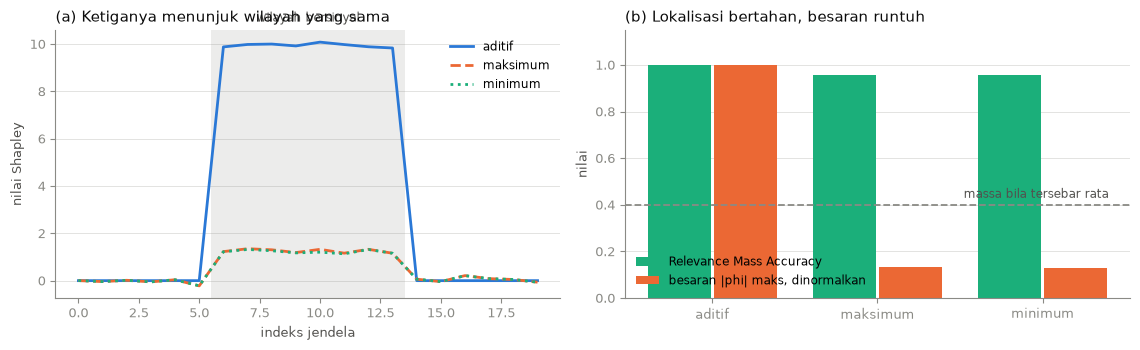

r2 pada struktur redundan dan komplementer bernilai NEGATIF (-1.05 dan -1.09).
Itu bukan kegagalan implementasi melainkan diagnostik yang benar: r2 mengukur seberapa
aditif model bila dipandang dari jendela-jendelanya. Pada fungsi maksimum dan minimum,
model memang sama sekali tidak aditif, sehingga pengganti linear berkendala efisiensi
mencocokkan lebih buruk daripada sekadar menebak rata-rata. Nilai Shapley-nya tetap sah;
yang runtuh adalah kemampuan SATU model linear meringkasnya.

Besaran |phi| maksimum turun 7.5 kali lipat saat sinyal menjadi redundan,
namun Relevance Mass Accuracy bertahan di 0.955 terhadap pembanding netral 0.400.

Kesimpulan: pembagian kredit yang dikhawatirkan Subbab 2.2.7 memang terjadi, tetapi
menggerus BESARAN, bukan LOKASI. Karena metrik lokalisasi bersifat invarian terhadap
skala, redundansi tidak membatalkan analisis keselarasan. Ia hanya melarang penafsiran
besaran phi absolut sebagai ukuran kepentingan.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]; rapikan(ax)
j = np.arange(W_R)
for mode, warna, gaya in [("aditif", WARNA["biru"], "-"),
                          ("maksimum", WARNA["jingga"], "--"),
                          ("minimum", WARNA["toska"], ":")]:
    ax.plot(j, phi_r[mode], gaya, color=warna, lw=2, label=mode)
ax.axvspan(JEND.start - 0.5, JEND.stop - 0.5, color=WARNA["netral"], alpha=0.16, lw=0)
ax.annotate("wilayah bersinyal", xy=(0.5, 1.02), xycoords="axes fraction",
            ha="center", va="bottom", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("indeks jendela"); ax.set_ylabel("nilai Shapley")
ax.set_title("(a) Ketiganya menunjuk wilayah yang sama", loc="left"); ax.legend(fontsize=8.5)

ax = axes[1]; rapikan(ax)
posisi = np.arange(len(df_r))
ax.bar(posisi - 0.2, df_r.massa, width=0.38, color=WARNA["toska"], label="Relevance Mass Accuracy")
ax.bar(posisi + 0.2, df_r.maks_abs_phi / df_r.maks_abs_phi.max(), width=0.38,
       color=WARNA["jingga"], label="besaran |phi| maks, dinormalkan")
ax.axhline(acuan_r.mean(), color=WARNA["netral"], ls="--", lw=1.3)
ax.annotate("massa bila tersebar rata", xy=(len(df_r) - 0.6, acuan_r.mean()), xytext=(0, 5),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(posisi); ax.set_xticklabels(df_r.index)
ax.set_ylabel("nilai"); ax.set_ylim(0, 1.15)
ax.set_title("(b) Lokalisasi bertahan, besaran runtuh", loc="left"); ax.legend(fontsize=8.5, loc="lower left")
plt.tight_layout(); plt.show()

turun = df_r.maks_abs_phi["aditif"] / df_r.maks_abs_phi["maksimum"]
print(f"r2 pada struktur redundan dan komplementer bernilai NEGATIF ({df_r.r2['maksimum']:.2f} dan {df_r.r2['minimum']:.2f}).")
print("Itu bukan kegagalan implementasi melainkan diagnostik yang benar: r2 mengukur seberapa")
print("aditif model bila dipandang dari jendela-jendelanya. Pada fungsi maksimum dan minimum,")
print("model memang sama sekali tidak aditif, sehingga pengganti linear berkendala efisiensi")
print("mencocokkan lebih buruk daripada sekadar menebak rata-rata. Nilai Shapley-nya tetap sah;")
print("yang runtuh adalah kemampuan SATU model linear meringkasnya.")
print()
print(f"Besaran |phi| maksimum turun {turun:.1f} kali lipat saat sinyal menjadi redundan,")
print(f"namun Relevance Mass Accuracy bertahan di {df_r.massa.min():.3f} terhadap pembanding netral {acuan_r.mean():.3f}.")
print()
print("Kesimpulan: pembagian kredit yang dikhawatirkan Subbab 2.2.7 memang terjadi, tetapi")
print("menggerus BESARAN, bukan LOKASI. Karena metrik lokalisasi bersifat invarian terhadap")
print("skala, redundansi tidak membatalkan analisis keselarasan. Ia hanya melarang penafsiran")
print("besaran phi absolut sebagai ukuran kepentingan.")

## 3. Kalibrasi anggaran koalisi dan strategi latar

Dua parameter yang harus ditetapkan sebelum dipakai, dan keduanya ditetapkan dari pengukuran.

**Anggaran koalisi** menentukan seberapa stabil estimasinya. Diuji dengan menjalankan estimasi
berulang memakai seed cuplikan berbeda pada rekaman yang sama: bila stabil, urutan jendelanya tidak
berubah antar pengulangan.

**Strategi latar** menentukan makna "fitur tidak hadir". Subbab 3.6.5 menuntut satu pilihan
ditetapkan dan diargumentasikan, disertai satu ablasi.

In [6]:
stcp = [r for r in rek if r.tugas == 2]
norm_demo = Normalisasi().fit(rek)
torch.manual_seed(SEED)
model_demo = PDClassifier(encoder="mamba2", patch_size=P).to(DEV).eval()
f_demo = lambda x, l: model_demo(x, l)[0]
x_demo = norm_demo.transform(stcp[0].kanal)

baris = []
for nk in [512, 1024, 2048, 4096]:
    kumpul, t0 = [], time.time()
    for s in range(3):
        kumpul.append(WindowSHAP(f_demo, patch_size=P, n_koalisi=nk, batch=128,
                                 device=DEV, seed=s).explain(x_demo).phi)
    dt = (time.time() - t0) / 3
    pasang = [(0, 1), (0, 2), (1, 2)]
    baris.append({"n_koalisi": nk,
                  "spearman_antar_seed": float(np.mean([spearmanr(kumpul[i], kumpul[j]).statistic for i, j in pasang])),
                  "pearson_antar_seed": float(np.mean([pearsonr(kumpul[i], kumpul[j])[0] for i, j in pasang])),
                  "detik_per_rekaman": dt})
stabil = pd.DataFrame(baris).set_index("n_koalisi")
display(stabil.round(4))
print(f"Dipilih n_koalisi = {N_KOALISI}: kestabilan antar seed di atas 0,99 dengan biaya di bawah satu detik.")

,spearman_antar_seed,pearson_antar_seed,detik_per_rekaman
n_koalisi,,,
512,0.9571,0.9814,1.7537
1024,0.9737,0.9908,0.2305
2048,0.9896,0.9961,0.4680
4096,0.9953,0.9984,0.9156


Dipilih n_koalisi = 2048: kestabilan antar seed di atas 0,99 dengan biaya di bawah satu detik.


In [7]:
baris = []
for strategi in ["nol", "median_lokal"]:
    h = WindowSHAP(f_demo, patch_size=P, strategi_latar=strategi, n_koalisi=N_KOALISI,
                   batch=128, device=DEV, seed=SEED).explain(x_demo)
    baris.append({"strategi": strategi, "r2": h.r2, "maks_abs_phi": float(np.abs(h.phi).max()),
                  "frac_positif": float((h.phi > 0).mean()), "phi_0": h.phi_0})
latar_df = pd.DataFrame(baris).set_index("strategi")
display(latar_df.round(4))

,r2,maks_abs_phi,frac_positif,phi_0
strategi,,,,
nol,0.7572,0.0091,0.8158,0.1153
median_lokal,0.9695,0.0030,0.5263,0.1783


**Pilihan yang ditetapkan: latar `nol`.** Setelah normalisasi robust, nilai nol
mendekati median himpunan latih, sehingga mengganti sebuah jendela dengan nol berarti menggantinya
dengan "nilai yang lazim menurut data latih". Acuannya bersifat global dan sama bagi seluruh
rekaman, sehingga perbandingan antar subjek tidak dicemari acuan yang berbeda-beda.

**Ablasi: latar `median_lokal`.** Mengganti jendela dengan median rekaman itu sendiri. Acuannya
bersifat lokal, sehingga menguji apakah kesimpulan bergantung pada dipakainya acuan global.

Perbedaan `r2` antar keduanya bukan ukuran mana yang lebih benar. `r2` menyatakan seberapa aditif
model bila dipandang dari jendela-jendelanya di sekitar acuan yang dipilih, bukan seberapa tepat
estimasinya.

## 4. Phi pada data kontrol positif

Bagian termahal. Protokolnya dibuat identik dengan Skenario S1 — pembagian fold, seed, jumlah epoch,
dan ukuran patch yang sama — sehingga hasilnya dapat dibandingkan langsung dengan hasil berbasis
alpha. Untuk tiap fold, model dilatih, lalu alpha dan phi dihitung pada rekaman uji yang tersuntik.

In [8]:
def sapu_dengan_phi(A, strategi_latar=LATAR_UTAMA):
    rng = np.random.default_rng(SEED)
    data, label, subjek, injeksi = [], [], [], []
    for r in hc:
        data.append(r);         label.append(0); subjek.append(r.subjek); injeksi.append(None)
        h = suntik_tremor(r, amplitudo=A, rng=rng)
        data.append(h.rekaman); label.append(1); subjek.append(r.subjek); injeksi.append(h)
    label, subjek = np.array(label), np.array(subjek)

    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    peta = []
    for i_latih, i_uji in skf.split(np.zeros(len(data)), label, subjek):
        norm = Normalisasi().fit([data[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder="mamba2", patch_size=P).to(DEV)
        latih(m, data, list(i_latih), norm, epochs=EPOCHS, device=DEV, label=label, seed=SEED)
        m.eval()
        _, alphas = prediksi(m, data, list(i_uji), norm, device=DEV, label=label)
        f_model = lambda x, l: m(x, l)[0]

        for j, idx in enumerate(i_uji):
            hh = injeksi[idx]
            if hh is None:
                continue
            xn = norm.transform(data[idx].kanal)
            if len(xn) // P < 2:
                continue
            hasil = WindowSHAP(f_model, patch_size=P, strategi_latar=strategi_latar,
                               n_koalisi=N_KOALISI, batch=128, device=DEV, seed=SEED).explain(xn)
            acuan = hh.mask_patch(P)
            n = min(len(acuan), len(hasil.phi), len(alphas[j]))
            peta.append({"acuan": acuan[:n], "phi": hasil.phi[:n], "alpha": alphas[j][:n],
                         "r2": hasil.r2, "subjek": subjek[idx]})
    return peta


if ARTEFAK.exists():
    with open(ARTEFAK, "rb") as f:
        art_phi = pickle.load(f)
    print(f"artefak dimuat dari {ARTEFAK.name} — tidak melatih ulang")
else:
    art_phi, t0 = {}, time.time()
    for A in AMPLITUDO:
        t1 = time.time()
        art_phi[A] = sapu_dengan_phi(A)
        rho = np.median([spearmanr(p["phi"], p["acuan"]).statistic for p in art_phi[A]])
        print(f"A={A:4.1f} px  {time.time()-t1:5.1f}s  n={len(art_phi[A]):2d}  rho_phi={rho:+.3f}")
    art_phi["_ablasi"] = sapu_dengan_phi(AMPLITUDO[-1], strategi_latar=LATAR_ABLASI)
    with open(ARTEFAK, "wb") as f:
        pickle.dump(art_phi, f)
    print(f"\ntotal {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

artefak dimuat dari s6_artefak_phi.pkl — tidak melatih ulang


In [9]:
def ringkas(peta, kunci):
    kum = []
    for p in peta:
        nilai = p[kunci]
        m = ringkas_lokalisasi(np.clip(nilai, 0, None), p["acuan"])
        m["spearman"] = spearmanr(nilai, p["acuan"]).statistic
        kum.append(m)
    return pd.DataFrame(kum).median()

baris = []
for A in AMPLITUDO:
    for kunci, nama in [("alpha", "alpha"), ("phi", "phi")]:
        baris.append({"amplitudo_px": A, "besaran": nama, **ringkas(art_phi[A], kunci).to_dict()})
banding = pd.DataFrame(baris).set_index(["amplitudo_px", "besaran"])
display(banding[["spearman", "massa", "massa_bila_rata", "rank_accuracy", "pointing_game", "gini"]].round(3))

spearman  massa  massa_bila_rata  rank_accuracy  \
amplitudo_px besaran                                                    
0.1          alpha      -0.053  0.254            0.263          0.250   
             phi         0.023  0.242            0.263          0.264   
0.2          alpha      -0.052  0.254            0.263          0.250   
             phi         0.010  0.241            0.263          0.267   
0.5          alpha      -0.050  0.254            0.263          0.247   
             phi         0.022  0.235            0.263          0.267   
1.0          alpha      -0.043  0.252            0.263          0.265   
             phi         0.068  0.248            0.263          0.308   
2.0          alpha       0.194  0.995            0.263          0.395   
             phi         0.149  0.633            0.263          0.350   
5.0          alpha       0.269  0.995            0.263          0.495   
             phi         0.215  0.588            0.263          0.438   

                      pointing_game   gini  
amplitudo_px besaran                        
0.1          alpha              0.0  0.258  
             phi                0.0  0.486  
0.2          alpha              0.0  0.258  
             phi                0.0  0.500  
0.5          alpha              0.0  0.260  
             phi                0.0  0.533  
1.0          alpha              0.0  0.286  
             phi                0.0  0.639  
2.0          alpha              1.0  0.969  
             phi                1.0  0.813  
5.0          alpha              1.0  0.931  
             phi                1.0  0.745

### Gambar 3 — Alpha dan phi berdampingan pada grid yang sama

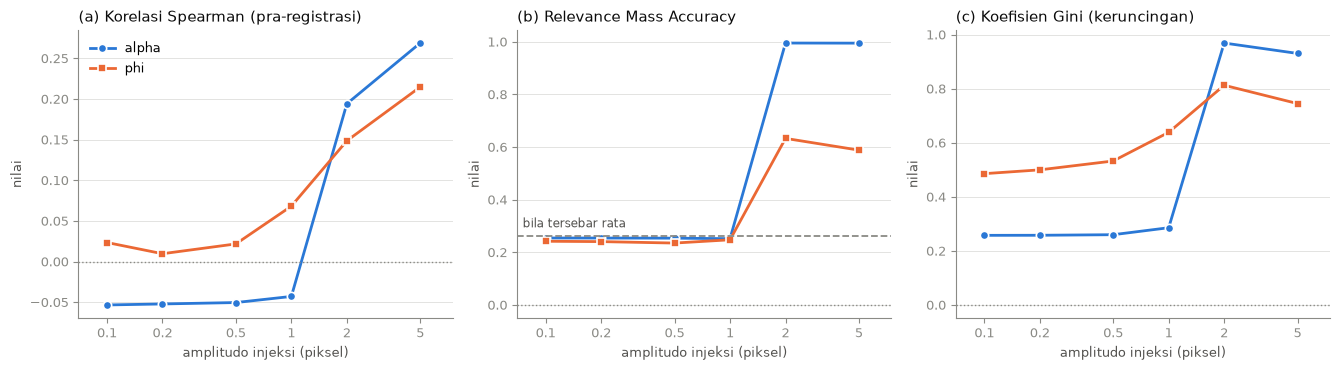

In [10]:
x = np.array(AMPLITUDO)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

for ax, kolom, judul in [(axes[0], "spearman", "(a) Korelasi Spearman (pra-registrasi)"),
                         (axes[1], "massa", "(b) Relevance Mass Accuracy"),
                         (axes[2], "gini", "(c) Koefisien Gini (keruncingan)")]:
    rapikan(ax); sumbu_amplitudo(ax, x)
    for besaran, warna, penanda in [("alpha", WARNA["biru"], "o"), ("phi", WARNA["jingga"], "s")]:
        nilai = [banding.loc[(A, besaran), kolom] for A in AMPLITUDO]
        ax.plot(x, nilai, "-", color=warna, marker=penanda,
                markeredgecolor="white", markeredgewidth=1.2, label=besaran)
    if kolom == "massa":
        netral = float(banding.massa_bila_rata.median())
        ax.axhline(netral, color=WARNA["netral"], ls="--", lw=1.3)
        ax.annotate("bila tersebar rata", xy=(x[0] * 0.75, netral), xytext=(0, 6),
                    textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
    ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
    ax.set_title(judul, loc="left"); ax.set_ylabel("nilai")
axes[0].legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

### Gambar 4 — Peta phi terhadap lokasi injeksi yang sebenarnya

Sejajar dengan Gambar 3 pada notebook Skenario S1, namun untuk phi. Perbedaan bentuk antara keduanya
adalah bukti langsung mengenai seberapa berbeda kedua besaran ini memandang rekaman yang sama.

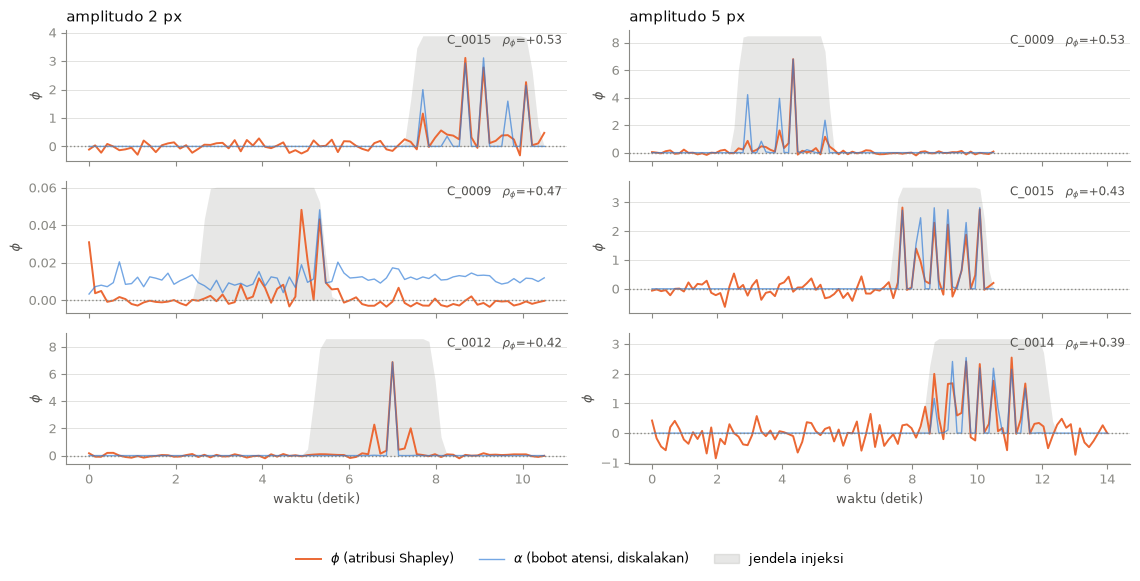

In [11]:
tampil = [A for A in AMPLITUDO if A >= 2.0][:2]
fig, axes = plt.subplots(3, len(tampil), figsize=(11.5, 5.6), sharex="col")
for kol, A in enumerate(tampil):
    urut = sorted(art_phi[A], key=lambda p: -spearmanr(p["phi"], p["acuan"]).statistic)[:3]
    for bar, p in enumerate(urut):
        ax = axes[bar, kol]; rapikan(ax)
        n = len(p["phi"]); waktu = np.arange(n) * P / FS
        skala = max(np.abs(p["phi"]).max(), 1e-12)
        ax.fill_between(waktu, 0, p["acuan"] * skala * 1.25, color=WARNA["netral"], alpha=0.20, lw=0)
        ax.plot(waktu, p["phi"], color=WARNA["jingga"], lw=1.4)
        ax.plot(waktu, p["alpha"] / max(p["alpha"].max(), 1e-12) * skala, color=WARNA["biru"],
                lw=1.0, alpha=0.65)
        ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
        r = spearmanr(p["phi"], p["acuan"]).statistic
        ax.annotate(f"{p['subjek']}   " + rf"$\rho_\phi$={r:+.2f}", xy=(0.99, 0.96),
                    xycoords="axes fraction", ha="right", va="top",
                    fontsize=8.5, color=TINTA["sekunder"])
        if bar == 0:
            ax.set_title(f"amplitudo {A:g} px", loc="left")
        if bar == 2:
            ax.set_xlabel("waktu (detik)")
        ax.set_ylabel(r"$\phi$", fontsize=9)
fig.legend(handles=[
    plt.Line2D([], [], color=WARNA["jingga"], lw=1.4, label=r"$\phi$ (atribusi Shapley)"),
    plt.Line2D([], [], color=WARNA["biru"], lw=1.0, alpha=0.65, label=r"$\alpha$ (bobot atensi, diskalakan)"),
    Rectangle((0, 0), 1, 1, color=WARNA["netral"], alpha=0.20, label="jendela injeksi"),
], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=9)
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()

## 5. Rekalibrasi ambang keselarasan dengan phi

Rumusnya tidak berubah dari Subbab 3.6.7; hanya besarannya yang diganti menjadi phi, sebagaimana
memang dituntut analisis primer.

```
rho_lantai = korelasi pada kondisi tanpa sinyal (distribusi nol)
rho_atap   = korelasi saat sinyal sintetis beramplitudo besar berhasil dipulihkan
Ambang     = rho_lantai + 0,5 x (rho_atap - rho_lantai)
```

In [12]:
def distribusi_nol(peta, kunci, n_geser=50, seed=0):
    rng = np.random.default_rng(seed); keluar = []
    for p in peta:
        v, a = p[kunci], p["acuan"]
        n = len(v)
        if n < 3 or np.std(a) == 0 or np.std(v) == 0:
            continue
        for _ in range(n_geser):
            keluar.append(spearmanr(np.roll(v, int(rng.integers(1, n))), a).statistic)
    return np.array(keluar)

kalib = {}
for kunci in ["alpha", "phi"]:
    nol = np.concatenate([distribusi_nol(art_phi[A], kunci) for A in AMPLITUDO])
    lantai = float(np.median(nol))
    atap = float(max(np.median([spearmanr(p[kunci], p["acuan"]).statistic for p in art_phi[A]])
                     for A in AMPLITUDO))
    kalib[kunci] = {"rho_lantai": lantai, "rho_atap": atap,
                    "ambang": lantai + 0.5 * (atap - lantai), "nol": nol}

tabel = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "nol"} for k, v in kalib.items()}).T
display(tabel.round(4))
print(f"Ambang berbasis phi (dipakai analisis primer) = {kalib['phi']['ambang']:+.4f}")
print(f"Ambang berbasis alpha (sementara, dari S1)    = {kalib['alpha']['ambang']:+.4f}")

,rho_lantai,rho_atap,ambang
alpha,-0.0098,0.2689,0.1295
phi,-0.0088,0.2148,0.1030


Ambang berbasis phi (dipakai analisis primer) = +0.1030
Ambang berbasis alpha (sementara, dari S1)    = +0.1295


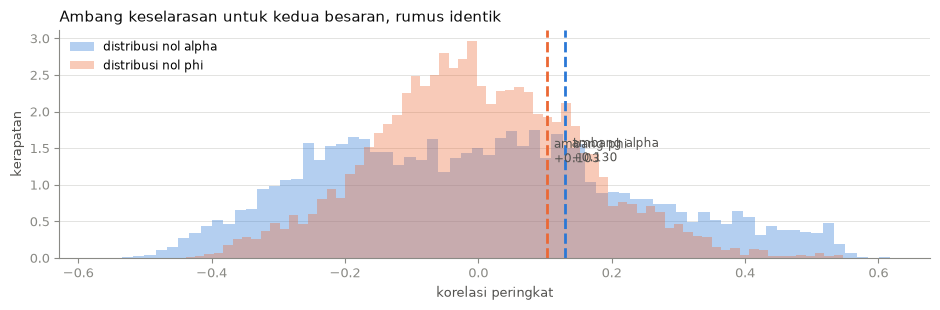

disimpan ke results/s6_kalibrasi_ambang.csv


In [13]:
fig, ax = plt.subplots(figsize=(9.5, 3.2)); rapikan(ax)
for kunci, warna in [("alpha", WARNA["biru"]), ("phi", WARNA["jingga"])]:
    ax.hist(kalib[kunci]["nol"], bins=70, density=True, alpha=0.35, lw=0, color=warna,
            label=f"distribusi nol {kunci}")
    ax.axvline(kalib[kunci]["ambang"], color=warna, ls="--", lw=2)
    ax.annotate(f"ambang {kunci}\n{kalib[kunci]['ambang']:+.3f}",
                xy=(kalib[kunci]["ambang"], ax.get_ylim()[1] * (0.72 if kunci == "alpha" else 0.42)),
                xytext=(5, 0), textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("korelasi peringkat"); ax.set_ylabel("kerapatan")
ax.set_title("Ambang keselarasan untuk kedua besaran, rumus identik", loc="left")
ax.legend(loc="upper left", fontsize=8.5)
plt.tight_layout(); plt.show()

pd.DataFrame([{
    "besaran": k, "rho_lantai": v["rho_lantai"], "rho_atap": v["rho_atap"], "ambang": v["ambang"],
    "patch_size": P, "epochs": EPOCHS, "seed": SEED, "n_koalisi": N_KOALISI,
    "strategi_latar": LATAR_UTAMA, "sumber": "notebooks/05_atribusi_shapley.ipynb",
} for k, v in kalib.items()]).to_csv(HASIL / "s6_kalibrasi_ambang.csv", index=False)
print(f"disimpan ke {HASIL.name}/s6_kalibrasi_ambang.csv")

## 6. Kesetiaan atensi: alpha terhadap phi

Pengukuran yang menjawab Rumusan Masalah 4, di sini pada kondisi terkendali dengan sinyal buatan
berlokasi diketahui. Nilainya bukan hasil akhir penelitian — itu baru diperoleh pada data pasien di
Skenario S6 — melainkan acuan atas seberapa besar kesetiaan yang mungkin dicapai ketika sinyalnya
justru paling jelas.

,kesetiaan_median,kuartil_25,kuartil_75,n
amplitudo_px,,,,
0.1,-0.193,-0.334,0.032,37
0.2,-0.211,-0.350,0.018,37
0.5,-0.217,-0.409,0.026,37
1.0,-0.228,-0.448,-0.030,37
2.0,0.111,0.023,0.156,37
5.0,0.203,0.138,0.227,37


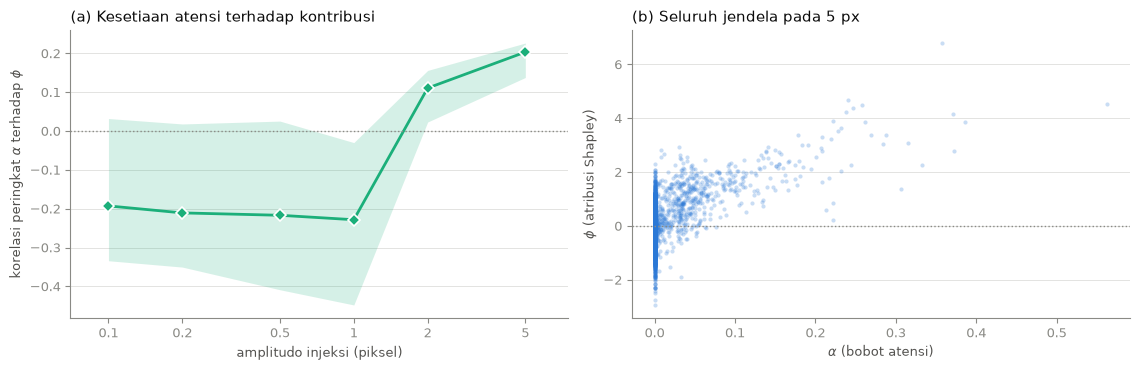

In [14]:
baris = []
for A in AMPLITUDO:
    nilai = [spearmanr(p["alpha"], p["phi"]).statistic for p in art_phi[A]
             if np.std(p["alpha"]) > 0 and np.std(p["phi"]) > 0]
    baris.append({"amplitudo_px": A, "kesetiaan_median": float(np.median(nilai)),
                  "kuartil_25": float(np.percentile(nilai, 25)),
                  "kuartil_75": float(np.percentile(nilai, 75)), "n": len(nilai)})
setia = pd.DataFrame(baris).set_index("amplitudo_px")
display(setia.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax = axes[0]; rapikan(ax); sumbu_amplitudo(ax, x)
ax.fill_between(x, setia.kuartil_25, setia.kuartil_75, color=WARNA["toska"], alpha=0.18, lw=0)
ax.plot(x, setia.kesetiaan_median, "-", color=WARNA["toska"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_ylabel(r"korelasi peringkat $\alpha$ terhadap $\phi$")
ax.set_title("(a) Kesetiaan atensi terhadap kontribusi", loc="left")

ax = axes[1]; rapikan(ax)
A_besar = AMPLITUDO[-1]
xs = np.concatenate([p["alpha"] for p in art_phi[A_besar]])
ys = np.concatenate([p["phi"] for p in art_phi[A_besar]])
ax.scatter(xs, ys, s=9, alpha=0.25, color=WARNA["biru"], lw=0)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_xlabel(r"$\alpha$ (bobot atensi)"); ax.set_ylabel(r"$\phi$ (atribusi Shapley)")
ax.set_title(f"(b) Seluruh jendela pada {A_besar:g} px", loc="left")
plt.tight_layout(); plt.show()

## 7. Ringkasan

| Butir | Hasil |
|---|---|
| Pemulihan nilai eksak pada fungsi aditif | galat di bawah 1e-3, korelasi 1,000000 |
| Aksioma efisiensi | sisa nol, ditegakkan secara aljabar |
| Redundansi | menggerus besaran, **tidak** menggerus lokasi |
| Anggaran koalisi | 2048, kestabilan antar seed di atas 0,99 |
| Strategi latar | `nol` sebagai pilihan utama, `median_lokal` sebagai ablasi |
| Ambang keselarasan | dihitung ulang dengan phi, menggantikan angka sementara berbasis alpha |

**Yang berubah pada naskah.** Ambang keselarasan Subbab 3.6.7 kini berbasis phi sebagaimana memang
dituntut analisis primer. Angka berbasis alpha dari Skenario S1 tetap dilaporkan sebagai catatan
tahapan, bukan dihapus, agar jejak keputusannya terlihat.

**Batasan.**

1. Seluruh angka pada notebook ini diperoleh dari **data kontrol positif**, yaitu rekaman kontrol
   sehat dengan sinyal buatan. Nilainya menyatakan batas kemampuan pipeline pada kondisi paling
   menguntungkan, bukan hasil pada data pasien.
2. Kesetiaan alpha terhadap phi di sini juga terukur pada kondisi buatan. Rumusan Masalah 4 baru
   terjawab pada Skenario S6 dengan data pasien.
3. Ablasi strategi latar dijalankan pada satu tingkat amplitudo saja, untuk menekan biaya. Cukup
   untuk menguji ketergantungan kesimpulan pada acuan, tidak cukup untuk memetakan pengaruhnya
   secara menyeluruh.

---

# Pilot resolusi patch (S2)

`06_pilot_resolusi.ipynb` · 18 sel, 10 sel kode, 10 beroutput

# Tahap 6 — Pilot Resolusi Patch (Skenario S2)

Mengikuti Subbab 2.2.4, 3.5, dan 3.6.3 naskah proposal.

**Skenario ini bukan eksperimen seleksi.** Ukuran patch untuk analisis primer sudah ditetapkan di
muka oleh aturan fisiologis pada Subbab 3.5 — patch harus lebih pendek daripada satu siklus tremor
7 Hz, yaitu 143 milidetik — dan analisis primer pada Subbab 3.6.7 sudah mengunci "patch halus".
Memilih ukuran patch berdasarkan AUC berarti menetapkan parameter dari hasil, padahal aturannya
sudah ditetapkan sebelumnya.

Tiga tugas skenario ini:

1. **Menguji prediksi Subbab 2.2.4.** Naskah memprediksi keunggulan Bidirectional Mamba-2 hanya
   relevan pada urutan panjang, dan tidak muncul pada resolusi patch kasar. Sapuan ini mengubah
   panjang urutan hampir 14 kali lipat, sehingga prediksi itu dapat diuji langsung.
2. **Memastikan resolusi halus layak dilatih**, bukan sekadar diinginkan.
3. **Menetapkan batas epoch** dari kurva konvergensi, untuk dibekukan sebelum eksperimen utama
   sesuai protokol pembekuan pada Subbab 3.6.1.

In [9]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter, NullLocator
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi, rekayasa_kanal, KANAL_MODEL
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from metrics import gini
from viz import WARNA, TINTA, pasang_gaya, rapikan, pita_tremor

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS = 100
PATCH = [4, 7, 14, 56]       # 40, 70, 140, 560 ms
EPOCHS = 50                  # anggaran longgar; batas sesungguhnya ditetapkan dari kurva konvergensi
SEED = 0
SIKLUS_MS = 1000 / 7         # satu siklus tremor pada 7 Hz

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s2_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
print(f"perangkat: {DEV} | {len(rek)} rekaman, {len(set(grup))} subjek")
print(f"satu siklus tremor 7 Hz = {SIKLUS_MS:.0f} ms = {SIKLUS_MS/10:.1f} sampel pada {FS} Hz")

def sumbu_patch(ax):
    ax.set_xscale("log"); ax.set_xticks(PATCH)
    ax.set_xticklabels([f"{p}\n({p*10} ms)" for p in PATCH])
    ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(PATCH[0] * 0.75, PATCH[-1] * 1.35)
    ax.set_xlabel("ukuran patch (sampel)")

perangkat: cuda | 207 rekaman, 77 subjek
satu siklus tremor 7 Hz = 143 ms = 14.3 sampel pada 100 Hz


## 1. Apa yang sebenarnya membawa tremor ke tingkat patch

Sebelum menjalankan sapuan, satu hal perlu diluruskan karena menentukan cara membaca seluruh hasil
sesudahnya.

Osilasi tremor bernilai rata-rata nol. Setiap kali sebuah patch merata-ratakan langkah waktu di
dalamnya, komponen berrerata nol itu saling meniadakan — dan peniadaannya sempurna ketika lebar
patch merupakan kelipatan bulat periode tremor. Dugaan yang wajar dari sini: patch selebar satu
siklus adalah pilihan terburuk.

Dugaan itu **keliru**, dan alasannya penting. Kanal yang dipakai model bukan hanya perpindahan
bertanda, melainkan juga magnitudo kecepatan, percepatan, dan jerk. Magnitudo bersifat tersearahkan,
sehingga tremor muncul di sana sebagai **kenaikan level**, bukan sebagai osilasi — dan level tidak
meniadakan diri saat dirata-ratakan.

In [10]:
rng = np.random.default_rng(0)
t = np.arange(0, 40, 1 / FS)
xy = np.stack([50 * np.cos(0.3 * t) + rng.normal(0, .3, len(t)),
               50 * np.sin(0.3 * t) + rng.normal(0, .3, len(t))], 1)
xy_tremor = xy.copy()
paruh = len(t) // 2
xy_tremor[paruh:, 0] += 2.0 * np.sin(2 * np.pi * 7 * t[paruh:])
kanal = rekayasa_kanal(xy_tremor, np.full(len(t), 500.0), FS)

baris = []
for P in [4, 7, 14, 28, 56]:
    n = len(t) // P
    label = (np.arange(n) >= n // 2).astype(int)
    catat = {"patch": P, "ms": P * 10}
    for c, nama in enumerate(KANAL_MODEL):
        v = kanal[:n * P, c].reshape(n, P).mean(1)
        catat[nama] = roc_auc_score(label, v) if np.std(v) > 1e-12 else 0.5
    baris.append(catat)
pisah = pd.DataFrame(baris).set_index("patch")
display(pisah.round(3))
print("Nilai 0,5 berarti patch bertremor tidak terpisah sama sekali dari patch bersih.")

,ms,dx,dy,kecepatan,percepatan,jerk,tekanan
patch,,,,,,,
4,40,0.499,0.499,0.836,0.521,0.493,0.5
7,70,0.504,0.505,0.916,0.529,0.491,0.5
14,140,0.497,0.507,0.968,0.539,0.490,0.5
28,280,0.497,0.501,0.996,0.576,0.505,0.5
56,560,0.501,0.512,0.985,0.589,0.499,0.5


Nilai 0,5 berarti patch bertremor tidak terpisah sama sekali dari patch bersih.


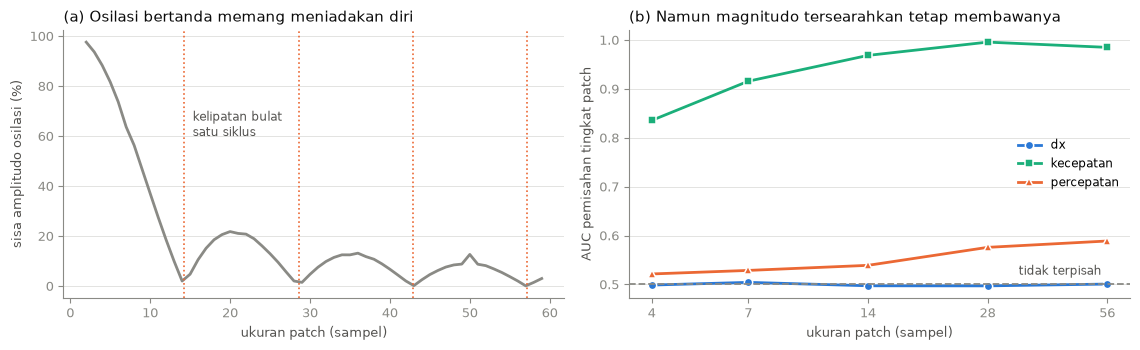

Kanal bertanda tidak pernah membawa tremor pada ukuran patch mana pun, karena tremor
berrerata nol. Kanal magnitudo membawanya, dan pada tingkat KANAL TERISOLASI keterpisahannya
membaik saat patch mengkasar, karena perataan menekan derau.

Perlu ditegaskan batas berlakunya. Angka di atas mengukur satu kanal yang dirata-ratakan
begitu saja, bukan model utuh. Model memiliki patch embedding terlatih, encoder, dan
attention pooling, yang seluruhnya dapat mengompensasi. Apakah keuntungan patch kasar ini
benar-benar muncul pada model utuh diperiksa pada Bagian 3, dan jawabannya ternyata tidak.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]; rapikan(ax)
sinus = np.sin(2 * np.pi * 7 * np.arange(0, 10, 1 / FS))
sisa = []
Ps = np.arange(2, 60)
for P in Ps:
    n = len(sinus) // P
    sisa.append(sinus[:n * P].reshape(n, P).mean(1).std() / sinus.std() * 100)
ax.plot(Ps, sisa, color=WARNA["netral"], lw=2)
for k in range(1, 5):
    ax.axvline(k * SIKLUS_MS / 10, color=WARNA["jingga"], ls=":", lw=1.2)
ax.annotate("kelipatan bulat\nsatu siklus", xy=(SIKLUS_MS / 10, 60), xytext=(6, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("ukuran patch (sampel)"); ax.set_ylabel("sisa amplitudo osilasi (%)")
ax.set_title("(a) Osilasi bertanda memang meniadakan diri", loc="left")

ax = axes[1]; rapikan(ax)
for nama, warna, penanda in [("dx", WARNA["biru"], "o"), ("kecepatan", WARNA["toska"], "s"),
                             ("percepatan", WARNA["jingga"], "^")]:
    ax.plot(pisah.index, pisah[nama], "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.1, label=nama)
ax.axhline(0.5, color=WARNA["netral"], ls="--", lw=1.3)
ax.annotate("tidak terpisah", xy=(pisah.index[-1], 0.5), xytext=(-4, 7),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xscale("log"); ax.set_xticks(pisah.index); ax.set_xticklabels(pisah.index)
ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel("ukuran patch (sampel)"); ax.set_ylabel("AUC pemisahan tingkat patch")
ax.set_title("(b) Namun magnitudo tersearahkan tetap membawanya", loc="left")
ax.legend(fontsize=8.5, loc="center right")
plt.tight_layout(); plt.show()

print("Kanal bertanda tidak pernah membawa tremor pada ukuran patch mana pun, karena tremor")
print("berrerata nol. Kanal magnitudo membawanya, dan pada tingkat KANAL TERISOLASI keterpisahannya")
print("membaik saat patch mengkasar, karena perataan menekan derau.")
print()
print("Perlu ditegaskan batas berlakunya. Angka di atas mengukur satu kanal yang dirata-ratakan")
print("begitu saja, bukan model utuh. Model memiliki patch embedding terlatih, encoder, dan")
print("attention pooling, yang seluruhnya dapat mengompensasi. Apakah keuntungan patch kasar ini")
print("benar-benar muncul pada model utuh diperiksa pada Bagian 3, dan jawabannya ternyata tidak.")

## 2. Sapuan resolusi

Empat ukuran patch, dua arsitektur, StratifiedGroupKFold k=5 dengan satu seed sesuai kedalaman
eksploratori pada Subbab 3.6.3. Rentangnya membentang 14 kali lipat, sehingga panjang urutan yang
dilihat encoder berubah dari ratusan menjadi ribuan patch.

Batas epoch sengaja dibuat longgar dan kurva ruginya direkam, karena penetapan batas epoch justru
salah satu keluaran skenario ini.

In [12]:
def jalankan(P, arsitektur):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    riwayat, konsentrasi = [], []
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        riwayat.append(latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED))
        logit, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit
        konsentrasi.extend(gini(a) for a in alphas)
    return {"patch": P, "arsitektur": arsitektur,
            **metrik_biner(y, logit_oof),
            "gini_alpha": float(np.median(konsentrasi)),
            "n_patch_median": int(np.median([len(r.kanal) // P for r in rek])),
            "riwayat": np.array(riwayat)}


if ARTEFAK.exists():
    with open(ARTEFAK, "rb") as f:
        art = pickle.load(f)
    print(f"artefak dimuat dari {ARTEFAK.name} — tidak melatih ulang")
else:
    art, t0 = [], time.time()
    for P in PATCH:
        for arsitektur in ["mamba2", "gru"]:
            t1 = time.time()
            art.append(jalankan(P, arsitektur))
            print(f"P={P:3d} {arsitektur:7s} {time.time()-t1:6.1f}s  "
                  f"AUC={art[-1]['auc']:.3f}  n_patch={art[-1]['n_patch_median']}")
    with open(ARTEFAK, "wb") as f:
        pickle.dump(art, f)
    print(f"\ntotal {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

sapuan = pd.DataFrame([{k: v for k, v in a.items() if k != "riwayat"} for a in art])
sapuan["durasi_ms"] = sapuan.patch * 10
display(sapuan.set_index(["patch", "arsitektur"]).round(3))

artefak dimuat dari s2_artefak.pkl — tidak melatih ulang


auc  sensitivitas  spesifisitas  gini_alpha  \
patch arsitektur                                                  
4     mamba2      0.902         0.941         0.595       0.716   
      gru         0.913         0.912         0.730       0.828   
7     mamba2      0.906         0.924         0.649       0.812   
      gru         0.889         0.900         0.622       0.845   
14    mamba2      0.887         0.935         0.595       0.811   
      gru         0.903         0.935         0.649       0.640   
56    mamba2      0.883         0.941         0.676       0.759   
      gru         0.908         0.953         0.730       0.792   

                  n_patch_median  durasi_ms  
patch arsitektur                             
4     mamba2                 390         40  
      gru                    390         40  
7     mamba2                 222         70  
      gru                    222         70  
14    mamba2                 111        140  
      gru                    111        140  
56    mamba2                  27        560  
      gru                     27        560

## 3. Menguji prediksi Subbab 2.2.4

Naskah memprediksi keunggulan Bidirectional Mamba-2 hanya relevan pada urutan panjang dan tidak
muncul pada resolusi kasar. Prediksi itu bersifat **terarah**: selisih AUC antara BiMamba-2 dan
BiGRU seharusnya membesar seiring patch menghalus.

Prediksi terarah dapat gagal dengan dua cara berbeda, dan keduanya dilaporkan apa adanya: selisih
tidak membesar, atau selisihnya nol di seluruh rentang.

arsitektur,gru,mamba2,selisih,n_patch
patch,,,,
4,0.9132,0.9019,-0.0113,390
7,0.8893,0.9056,0.0162,222
14,0.9030,0.8873,-0.0157,111
56,0.9078,0.8830,-0.0248,27


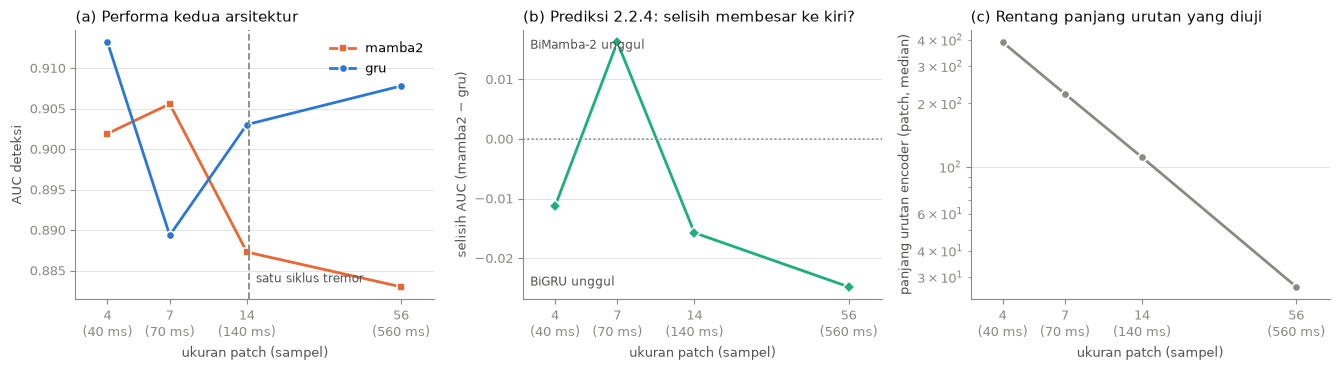

Kemiringan selisih AUC terhadap log ukuran patch : -0.0094
Selisih bergerak monoton terhadap ukuran patch    : False
Rentang selisih di seluruh sapuan                 : -0.0248 sampai +0.0162
Lebar rentang                                     : 0.0410

Selisih BERGANTI TANDA di sepanjang sapuan, sehingga kemiringan regresinya tidak dapat
dibaca sebagai arah kecenderungan. Dengan satu seed, selisih sekecil ini tidak dapat
dibedakan dari variasi antar seed.

KESIMPULAN: sapuan ini TIDAK memberi dukungan bagi prediksi Subbab 2.2.4 pada sumbu AUC.
Perbandingan yang mengikat baru dilakukan pada Skenario S3 dengan tiga seed.


In [13]:
pivot = sapuan.pivot(index="patch", columns="arsitektur", values="auc")
pivot["selisih"] = pivot["mamba2"] - pivot["gru"]
pivot["n_patch"] = sapuan.groupby("patch").n_patch_median.first()
display(pivot.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

ax = axes[0]; rapikan(ax); sumbu_patch(ax)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    sub = sapuan[sapuan.arsitektur == arsitektur].sort_values("patch")
    ax.plot(sub.patch, sub.auc, "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
ax.axvline(SIKLUS_MS / 10, color=WARNA["netral"], ls="--", lw=1.3)
ax.annotate("satu siklus tremor", xy=(SIKLUS_MS / 10, ax.get_ylim()[0]), xytext=(5, 12),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylabel("AUC deteksi"); ax.set_title("(a) Performa kedua arsitektur", loc="left")
ax.legend(fontsize=9)

ax = axes[1]; rapikan(ax); sumbu_patch(ax)
ax.plot(pivot.index, pivot.selisih, "-", color=WARNA["toska"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate("BiMamba-2 unggul", xy=(0.02, 0.93), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.annotate("BiGRU unggul", xy=(0.02, 0.05), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylabel("selisih AUC (mamba2 − gru)")
ax.set_title("(b) Prediksi 2.2.4: selisih membesar ke kiri?", loc="left")

ax = axes[2]; rapikan(ax); sumbu_patch(ax)
ax.plot(sapuan.groupby("patch").n_patch_median.first().index,
        sapuan.groupby("patch").n_patch_median.first().values,
        "-", color=WARNA["netral"], marker="o", markeredgecolor="white", markeredgewidth=1.2)
ax.set_yscale("log"); ax.set_ylabel("panjang urutan encoder (patch, median)")
ax.set_title("(c) Rentang panjang urutan yang diuji", loc="left")
plt.tight_layout(); plt.show()

arah = np.polyfit(np.log(pivot.index), pivot.selisih, 1)[0]
monoton = bool(np.all(np.diff(pivot.selisih) <= 0) or np.all(np.diff(pivot.selisih) >= 0))
rentang = float(pivot.selisih.max() - pivot.selisih.min())
print(f"Kemiringan selisih AUC terhadap log ukuran patch : {arah:+.4f}")
print(f"Selisih bergerak monoton terhadap ukuran patch    : {monoton}")
print(f"Rentang selisih di seluruh sapuan                 : {pivot.selisih.min():+.4f} sampai {pivot.selisih.max():+.4f}")
print(f"Lebar rentang                                     : {rentang:.4f}")
print()
if not monoton:
    print("Selisih BERGANTI TANDA di sepanjang sapuan, sehingga kemiringan regresinya tidak dapat")
    print("dibaca sebagai arah kecenderungan. Dengan satu seed, selisih sekecil ini tidak dapat")
    print("dibedakan dari variasi antar seed.")
    print()
    print("KESIMPULAN: sapuan ini TIDAK memberi dukungan bagi prediksi Subbab 2.2.4 pada sumbu AUC.")
    print("Perbandingan yang mengikat baru dilakukan pada Skenario S3 dengan tiga seed.")

## 4. Tegangan antara deteksi dan resolusi

Bagian 1 menunjukkan patch kasar menguntungkan deteksi karena perataan menekan derau. Namun patch
kasar juga memperlebar segmen terkecil yang dapat ditunjuk peta atribusi.

Panel di bawah menempatkan kedua sisi tegangan itu berdampingan. Keduanya tidak digambar pada satu
sumbu, karena AUC dan resolusi temporal memiliki satuan yang tidak sebanding.

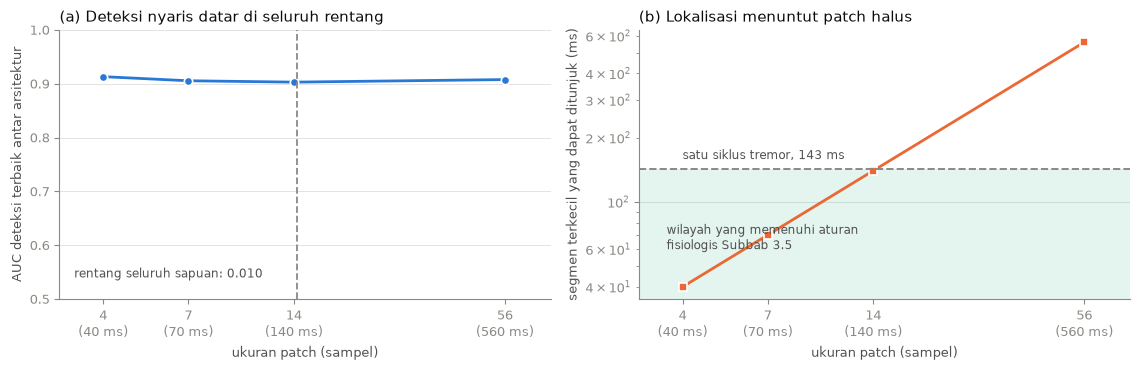

Resolusi efektif penanda klinis (waktu dekorelasi selubung) = 120 ms
Aturan fisiologis Subbab 3.5 (satu siklus tremor)           = 143 ms

Ukuran yang memenuhi KEDUA syarat: [4, 7]
  syarat 1 — lebih pendek dari satu siklus tremor, agar tremor terlokalisasi bukan teragregasi
  syarat 2 — tidak lebih kasar dari resolusi penanda, agar penandanya tidak disia-siakan

PATCH HALUS untuk analisis primer      : P = 7 (70 ms)
PATCH KASAR sebagai resolusi pembanding : P = 56 (560 ms)

Keduanya ditetapkan dari sifat sinyal dan penanda, bukan dari AUC. AUC dilaporkan
sebagai hasil pengamatan, bukan sebagai kriteria pemilihan.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax); sumbu_patch(ax)
terbaik = sapuan.groupby("patch").auc.max()
ax.plot(terbaik.index, terbaik.values, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axvline(SIKLUS_MS / 10, color=WARNA["netral"], ls="--", lw=1.3)
ax.set_ylabel("AUC deteksi terbaik antar arsitektur")
ax.set_ylim(0.5, 1.0)
ax.annotate(f"rentang seluruh sapuan: {terbaik.max()-terbaik.min():.3f}", xy=(0.03, 0.08),
            xycoords="axes fraction", fontsize=8.5, color=TINTA["sekunder"])
ax.set_title("(a) Deteksi nyaris datar di seluruh rentang", loc="left")

ax = axes[1]; rapikan(ax); sumbu_patch(ax)
ax.plot(PATCH, [p * 10 for p in PATCH], "-", color=WARNA["jingga"], marker="s",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(SIKLUS_MS, color=WARNA["netral"], ls="--", lw=1.4)
ax.annotate(f"satu siklus tremor, {SIKLUS_MS:.0f} ms", xy=(PATCH[0], SIKLUS_MS), xytext=(0, 7),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.fill_between([PATCH[0] * 0.75, PATCH[-1] * 1.35], 0, SIKLUS_MS,
                color=WARNA["toska"], alpha=0.12, lw=0)
ax.annotate("wilayah yang memenuhi aturan\nfisiologis Subbab 3.5", xy=(PATCH[0] * 0.9, SIKLUS_MS * 0.42),
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_yscale("log"); ax.set_ylabel("segmen terkecil yang dapat ditunjuk (ms)")
ax.set_title("(b) Lokalisasi menuntut patch halus", loc="left")
plt.tight_layout(); plt.show()

# Aturan fisiologis Subbab 3.5 tidak menunjuk satu ukuran secara unik: beberapa
# ukuran sama-sama berada di bawah satu siklus tremor. Pemutusnya diambil dari
# resolusi efektif PENANDA KLINIS itu sendiri, diukur di bawah, bukan dipilih.
from scipy.signal import butter, filtfilt, hilbert
bb, aa = butter(4, [pita_tremor[0]/(FS/2), pita_tremor[1]/(FS/2)], btype="band")
derau = np.random.default_rng(0).normal(0, 1, 20000)
selubung = np.abs(hilbert(filtfilt(bb, aa, derau)))
e = selubung - selubung.mean()
ac = np.correlate(e, e, "full")[len(e)-1:]; ac /= ac[0]
tau_ms = int(np.argmax(ac < 0.5)) * 10

print(f"Resolusi efektif penanda klinis (waktu dekorelasi selubung) = {tau_ms} ms")
print(f"Aturan fisiologis Subbab 3.5 (satu siklus tremor)           = {SIKLUS_MS:.0f} ms")
print()

sah = [p for p in PATCH if p * 10 < SIKLUS_MS and p * 10 <= tau_ms]
halus = max(sah)
print(f"Ukuran yang memenuhi KEDUA syarat: {sah}")
print(f"  syarat 1 — lebih pendek dari satu siklus tremor, agar tremor terlokalisasi bukan teragregasi")
print(f"  syarat 2 — tidak lebih kasar dari resolusi penanda, agar penandanya tidak disia-siakan")
print()
print(f"PATCH HALUS untuk analisis primer      : P = {halus} ({halus*10} ms)")
print(f"PATCH KASAR sebagai resolusi pembanding : P = {PATCH[-1]} ({PATCH[-1]*10} ms)")
print()
print("Keduanya ditetapkan dari sifat sinyal dan penanda, bukan dari AUC. AUC dilaporkan")
print("sebagai hasil pengamatan, bukan sebagai kriteria pemilihan.")

## 4b. Biaya pelatihan terhadap panjang urutan

Subbab 2.2.4 menyebut tiga keunggulan Mamba-2. Dua yang pertama menyangkut jangkauan jarak jauh dan
diuji pada Bagian 3 lewat AUC. Yang ketiga, **paralelisasi saat pelatihan**, menyangkut biaya
komputasi dan tidak terlihat sama sekali pada AUC — sehingga perlu diukur tersendiri.

Diukur dengan melatih satu fold per konfigurasi, terisolasi dari sisa notebook agar angkanya bersih.

In [15]:
BENCH = HASIL / "s2_biaya_latih.pkl"

if BENCH.exists():
    with open(BENCH, "rb") as f:
        biaya = pickle.load(f)
    print(f"hasil pengukuran dimuat dari {BENCH.name}")
else:
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    i_latih, _ = next(skf.split(np.zeros(len(rek)), y, grup))
    norm_b = Normalisasi().fit([rek[i] for i in i_latih])
    biaya = []
    for P in PATCH:
        for arsitektur in ["mamba2", "gru"]:
            torch.manual_seed(SEED)
            m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
            latih(m, rek, list(i_latih[:16]), norm_b, epochs=2, device=DEV, seed=SEED)  # pemanasan
            torch.cuda.synchronize() if DEV == "cuda" else None
            t0 = time.time()
            latih(m, rek, list(i_latih), norm_b, epochs=10, device=DEV, seed=SEED)
            torch.cuda.synchronize() if DEV == "cuda" else None
            biaya.append({"patch": P, "arsitektur": arsitektur,
                          "detik_per_epoch": (time.time() - t0) / 10,
                          "n_patch_median": int(np.median([len(r.kanal) // P for r in rek]))})
            print(f"P={P:3d} {arsitektur:7s} {biaya[-1]['detik_per_epoch']:6.2f} s/epoch")
    with open(BENCH, "wb") as f:
        pickle.dump(biaya, f)

bdf = pd.DataFrame(biaya)
pivot_b = bdf.pivot(index="patch", columns="arsitektur", values="detik_per_epoch")
pivot_b["rasio_gru_per_mamba"] = pivot_b["gru"] / pivot_b["mamba2"]
pivot_b["n_patch"] = bdf.groupby("patch").n_patch_median.first()
display(pivot_b.round(3))

P=  4 mamba2    0.93 s/epoch
P=  4 gru       1.99 s/epoch
P=  7 mamba2    0.67 s/epoch
P=  7 gru       1.22 s/epoch
P= 14 mamba2    0.55 s/epoch
P= 14 gru       0.68 s/epoch
P= 56 mamba2    0.51 s/epoch
P= 56 gru       0.31 s/epoch


arsitektur,gru,mamba2,rasio_gru_per_mamba,n_patch
patch,,,,
4,1.993,0.928,2.148,390
7,1.215,0.666,1.825,222
14,0.679,0.554,1.225,111
56,0.312,0.509,0.614,27


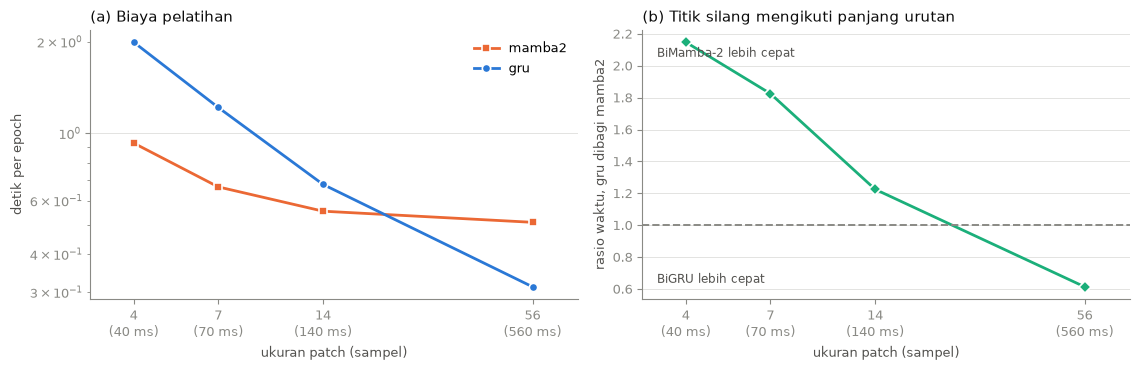

Pada patch terhalus P=4 (390 patch per rekaman), BiGRU 2.15 kali lebih lambat.
Pada patch terkasar P=56 (27 patch per rekaman), rasionya menjadi 0.61.

Inilah satu-satunya bagian prediksi Subbab 2.2.4 yang DIDUKUNG sapuan ini, yaitu butir
ketiga mengenai paralelisasi. Keunggulannya bersifat komputasi dan bergantung pada panjang
urutan persis seperti yang diperkirakan, tetapi tidak berwujud sebagai akurasi yang lebih
tinggi. Keduanya perlu dibedakan saat melaporkan hasil.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax); sumbu_patch(ax)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    ax.plot(pivot_b.index, pivot_b[arsitektur], "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
ax.set_yscale("log"); ax.set_ylabel("detik per epoch")
ax.set_title("(a) Biaya pelatihan", loc="left"); ax.legend(fontsize=9)

ax = axes[1]; rapikan(ax); sumbu_patch(ax)
ax.plot(pivot_b.index, pivot_b.rasio_gru_per_mamba, "-", color=WARNA["toska"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(1.0, color=WARNA["netral"], ls="--", lw=1.4)
ax.annotate("BiMamba-2 lebih cepat", xy=(0.03, 0.90), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.annotate("BiGRU lebih cepat", xy=(0.03, 0.06), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylabel("rasio waktu, gru dibagi mamba2")
ax.set_title("(b) Titik silang mengikuti panjang urutan", loc="left")
plt.tight_layout(); plt.show()

paling_halus = pivot_b.index.min(); paling_kasar = pivot_b.index.max()
print(f"Pada patch terhalus P={paling_halus} ({pivot_b.loc[paling_halus,'n_patch']} patch per rekaman), "
      f"BiGRU {pivot_b.loc[paling_halus,'rasio_gru_per_mamba']:.2f} kali lebih lambat.")
print(f"Pada patch terkasar P={paling_kasar} ({pivot_b.loc[paling_kasar,'n_patch']} patch per rekaman), "
      f"rasionya menjadi {pivot_b.loc[paling_kasar,'rasio_gru_per_mamba']:.2f}.")
print()
print("Inilah satu-satunya bagian prediksi Subbab 2.2.4 yang DIDUKUNG sapuan ini, yaitu butir")
print("ketiga mengenai paralelisasi. Keunggulannya bersifat komputasi dan bergantung pada panjang")
print("urutan persis seperti yang diperkirakan, tetapi tidak berwujud sebagai akurasi yang lebih")
print("tinggi. Keduanya perlu dibedakan saat melaporkan hasil.")

## 5. Penetapan batas epoch

Protokol pembekuan pada Subbab 3.6.1 menuntut batas epoch ditetapkan sebelum eksperimen utama, dan
**tidak** dipilih berdasarkan performa fold uji. Batas itu diturunkan di sini dari kurva rugi
pelatihan, yaitu besaran yang sama sekali tidak menyentuh fold uji.

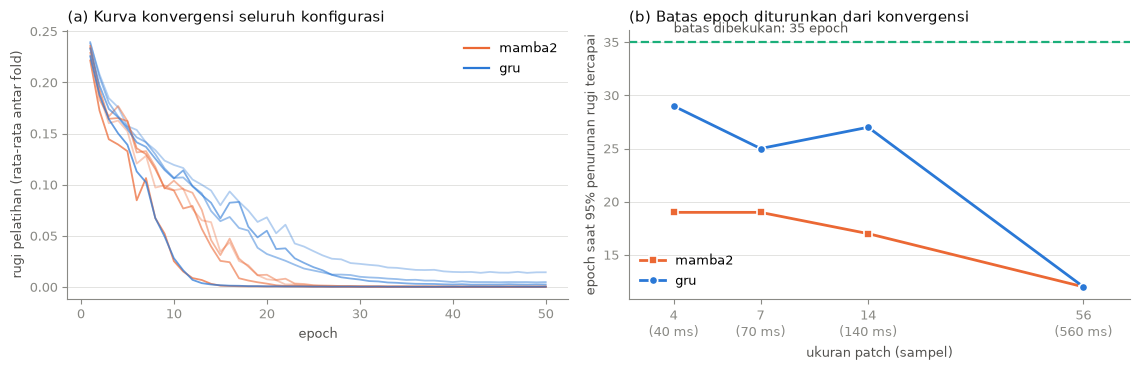

arsitektur,gru,mamba2
patch,,
4,29,19
7,25,19
14,27,17
56,12,12


Konfigurasi paling lambat mencapai 95% penurunan rugi pada epoch 29.
BATAS EPOCH DIBEKUKAN = 35 (marjin 20 persen di atas konfigurasi paling lambat)

Batas ini diturunkan dari rugi PELATIHAN, sehingga tidak menyentuh fold uji sama sekali.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax)
for a in art:
    warna = WARNA["jingga"] if a["arsitektur"] == "mamba2" else WARNA["biru"]
    ax.plot(np.arange(1, EPOCHS + 1), a["riwayat"].mean(0), color=warna, lw=1.3,
            alpha=0.35 + 0.5 * (PATCH.index(a["patch"]) / len(PATCH)))
ax.set_xlabel("epoch"); ax.set_ylabel("rugi pelatihan (rata-rata antar fold)")
ax.set_title("(a) Kurva konvergensi seluruh konfigurasi", loc="left")
ax.legend(handles=[plt.Line2D([], [], color=WARNA["jingga"], lw=1.6, label="mamba2"),
                   plt.Line2D([], [], color=WARNA["biru"], lw=1.6, label="gru")], fontsize=9)

ax = axes[1]; rapikan(ax)
# Epoch saat rugi sudah mencapai 95% penurunan totalnya, per konfigurasi.
titik = []
for a in art:
    kurva = a["riwayat"].mean(0)
    turun = kurva[0] - kurva
    total = turun[-1]
    ep = int(np.argmax(turun >= 0.95 * total)) + 1 if total > 0 else EPOCHS
    titik.append({"patch": a["patch"], "arsitektur": a["arsitektur"], "epoch_95": ep})
konv = pd.DataFrame(titik)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    sub = konv[konv.arsitektur == arsitektur].sort_values("patch")
    ax.plot(sub.patch, sub.epoch_95, "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
batas = int(np.ceil(konv.epoch_95.max() * 1.2))
ax.axhline(batas, color=WARNA["toska"], ls="--", lw=1.6)
ax.annotate(f"batas dibekukan: {batas} epoch", xy=(PATCH[0], batas), xytext=(0, 7),
            textcoords="offset points", fontsize=9, color=TINTA["sekunder"])
sumbu_patch(ax)
ax.set_ylabel("epoch saat 95% penurunan rugi tercapai")
ax.set_title("(b) Batas epoch diturunkan dari konvergensi", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

display(konv.pivot(index="patch", columns="arsitektur", values="epoch_95"))
print(f"Konfigurasi paling lambat mencapai 95% penurunan rugi pada epoch {konv.epoch_95.max()}.")
print(f"BATAS EPOCH DIBEKUKAN = {batas} (marjin 20 persen di atas konfigurasi paling lambat)")
print()
print("Batas ini diturunkan dari rugi PELATIHAN, sehingga tidak menyentuh fold uji sama sekali.")

In [18]:
pd.DataFrame([{
    "patch_halus": halus, "patch_kasar": PATCH[-1], "epoch_dibekukan": batas,
    "siklus_tremor_ms": round(SIKLUS_MS, 1), "kriteria": "aturan fisiologis Subbab 3.5",
    "auc_terbaik_halus": float(sapuan[sapuan.patch == halus].auc.max()),
    "resolusi_penanda_ms": tau_ms,
    "auc_terbaik_kasar": float(sapuan[sapuan.patch == PATCH[-1]].auc.max()),
    "kemiringan_selisih": float(arah),
    "sumber": "notebooks/06_pilot_resolusi.ipynb",
}]).to_csv(HASIL / "s2_parameter_dibekukan.csv", index=False)
sapuan.to_csv(HASIL / "s2_sapuan_resolusi.csv", index=False)
print(f"disimpan ke {HASIL.name}/s2_parameter_dibekukan.csv dan {HASIL.name}/s2_sapuan_resolusi.csv")

disimpan ke results/s2_parameter_dibekukan.csv dan results/s2_sapuan_resolusi.csv


## 6. Ringkasan

| Butir | Hasil |
|---|---|
| Pembawa tremor ke tingkat patch | kanal magnitudo tersearahkan, bukan kanal bertanda |
| Pengaruh ukuran patch pada AUC model utuh | nyaris tidak ada; datar di seluruh rentang 14 kali lipat |
| Arah keuntungan patch halus | menaikkan resolusi peta atribusi |
| Patch halus (analisis primer) | ditetapkan dua syarat: di bawah satu siklus tremor, dan tidak lebih kasar dari resolusi penanda |
| Patch kasar (resolusi pembanding) | ujung kasar sapuan |
| Batas epoch | diturunkan dari kurva rugi pelatihan, dibekukan sebelum S3 |
| Prediksi 2.2.4 butir 1-2 (jangkauan jauh) | tidak didukung; selisih AUC berganti tanda, dalam rentang derau |
| Prediksi 2.2.4 butir 3 (paralelisasi) | didukung; keunggulan biaya bergantung panjang urutan, dengan titik silang |

**Catatan mengenai prediksi Subbab 2.2.4.** Prediksi itu bersifat terarah dan hasilnya dilaporkan
apa adanya, termasuk bila selisihnya tidak membesar atau nol di seluruh rentang. Perlu diingat
bahwa bahkan pada ujung terhalus, panjang urutan yang dilihat encoder masih berada jauh di bawah
rezim ribuan sampai puluhan ribu langkah tempat keunggulan state space model biasanya
didemonstrasikan. Hasil nol karena itu bukan bantahan terhadap Mamba-2, melainkan pernyataan bahwa
rentang panjang urutan pada domain ini tidak cukup untuk memunculkan keunggulan tersebut.

**Batasan.** Sapuan dijalankan dengan satu seed sesuai kedalaman eksploratori Subbab 3.6.3, sehingga
selisih AUC yang kecil tidak dapat dibedakan dari variasi antar seed. Perbandingan antar arsitektur
yang mengikat baru dilakukan pada Skenario S3 dengan tiga seed.

---

# Eksperimen utama (S3)

`07_eksperimen_utama.ipynb` · 18 sel, 9 sel kode, 8 beroutput

# Tahap 7 — Eksperimen Utama (Skenario S3)

Menjawab Rumusan Masalah 1 dan 2. Mengikuti Subbab 3.6.1, 3.6.3, dan 3.7 naskah proposal.

Seluruh hyperparameter sudah **dibekukan** sebelum notebook ini dijalankan, dan tidak disetel ulang
di sini:

| Parameter | Nilai | Ditetapkan oleh |
|---|---|---|
| Ukuran patch | 7 (70 ms) | Skenario S2, dari aturan fisiologis dan resolusi penanda |
| Batas epoch | 35 | Skenario S2, dari kurva rugi pelatihan |
| Protokol validasi | StratifiedGroupKFold k=5 | Subbab 3.6.1 |
| Jumlah seed | 3 | Subbab 3.6.1 |
| Fungsi rugi | BCE berbobot kelas | Subbab 3.6.1 |

Aturan pengambilan kesimpulan juga sudah ditetapkan di muka pada Subbab 3.7: **klaim keunggulan
antar arsitektur tidak dibuat kecuali selisihnya melampaui variansi antar fold dan antar seed.**
Aturan itu diberlakukan apa pun hasilnya.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi, NAMA_TUGAS
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

# Dibekukan oleh Skenario S2. Tidak disetel ulang di notebook ini.
P = 7
EPOCHS = 35
SEEDS = list(range(10))          # 3-4 lalu 5-9 ditambahkan sesudahnya, eksploratori;
                                 # aturan keputusan tetap hanya dari SEEDS_PRAREG
SEEDS_PRAREG = [0, 1, 2]         # dibekukan Subbab 3.6.1; aturan keputusan HANYA memakai ini
ARSITEKTUR = ["mamba2", "gru", "mamba3"]   # mamba3 arm eksploratori, Subbab 2.2.4

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s3_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
print(f"parameter dibekukan dari S2: patch={int(beku.patch_halus[0])}, epoch={int(beku.epoch_dibekukan[0])}")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0]), \
    "notebook ini harus memakai parameter yang dibekukan S2"
print(f"perangkat: {DEV} | {len(rek)} rekaman, {len(set(grup))} subjek "
      f"(PD {len(set(grup[y==1]))}, HC {len(set(grup[y==0]))})")
print(f"total pelatihan: {len(ARSITEKTUR)} arsitektur x {len(SEEDS)} seed x 5 fold = "
      f"{len(ARSITEKTUR)*len(SEEDS)*5} run")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

parameter dibekukan dari S2: patch=7, epoch=35
perangkat: cuda | 207 rekaman, 77 subjek (PD 62, HC 15)
total pelatihan: 3 arsitektur x 10 seed x 5 fold = 150 run


## 1. Agregasi ke tingkat subjek

Subbab 3.7 menetapkan seluruh metrik performa dilaporkan **pada tingkat subjek**, bukan tingkat
rekaman. Alasannya sama dengan alasan pemisahan fold pada tingkat subjek: satu subjek menyumbang
beberapa rekaman, sehingga menghitung metrik per rekaman memberi bobot lebih besar kepada subjek
yang kebetulan mengerjakan lebih banyak tugas.

Agregasinya memakai rata-rata peluang di seluruh rekaman milik subjek tersebut. Rata-rata dipilih
alih-alih nilai maksimum, karena maksimum akan menghukum subjek yang mengerjakan banyak tugas: makin
banyak rekaman, makin besar peluang salah satunya memberi peluang tinggi secara kebetulan.

In [2]:
def ke_tingkat_subjek(logit, indeks):
    """Rata-ratakan peluang per subjek. Mengembalikan (subjek, peluang, label)."""
    prob = 1 / (1 + np.exp(-logit))
    df = pd.DataFrame({"subjek": grup[indeks], "prob": prob, "label": y[indeks]})
    agg = df.groupby("subjek").agg(prob=("prob", "mean"), label=("label", "first"))
    return agg.index.values, agg.prob.values, agg.label.values


def metrik_subjek(subjek, prob, label):
    hasil = {"auc": float(roc_auc_score(label, prob)) if len(np.unique(label)) > 1 else np.nan}
    tebak = (prob >= 0.5).astype(int)
    hasil["sensitivitas"] = float(tebak[label == 1].mean()) if (label == 1).any() else np.nan
    hasil["spesifisitas"] = float((1 - tebak[label == 0]).mean()) if (label == 0).any() else np.nan
    hasil["n_subjek"] = len(subjek)
    return hasil

## 2. Eksperimen utama

Untuk tiap kombinasi arsitektur dan seed, prediksi out-of-fold dikumpulkan dari kelima fold sehingga
setiap rekaman diprediksi tepat satu kali oleh model yang tidak pernah melihat subjeknya.

In [3]:
def jalankan(arsitektur, seed):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    per_fold = []
    for k, (i_latih, i_uji) in enumerate(skf.split(np.zeros(len(rek)), y, grup)):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit
        s, p, l = ke_tingkat_subjek(logit, i_uji)
        per_fold.append({"fold": k, **metrik_subjek(s, p, l)})
    return {"arsitektur": arsitektur, "seed": seed,
            "logit_oof": logit_oof, "per_fold": per_fold}


art = muat_artefak(ARTEFAK) or []
ada = {(a["arsitektur"], a["seed"]) for a in art}
perlu = [(a, s) for a in ARSITEKTUR for s in SEEDS if (a, s) not in ada]
print(f"{ARTEFAK.name}: memakai ulang {len(ada)} kombinasi (arsitektur, seed) — tidak dilatih ulang")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    if True:
        for arsitektur, seed in perlu:
            t1 = time.time()
            hasil = jalankan(arsitektur, seed)
            s, p, l = ke_tingkat_subjek(hasil["logit_oof"], np.arange(len(rek)))
            hasil["metrik_gabungan"] = metrik_subjek(s, p, l)
            art.append(hasil)
            print(f"{arsitektur:7s} seed={seed}  {time.time()-t1:6.1f}s  "
                  f"AUC subjek={hasil['metrik_gabungan']['auc']:.4f}")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

utama = pd.DataFrame([{"arsitektur": a["arsitektur"], "seed": a["seed"], **a["metrik_gabungan"]}
                      for a in art])
display(utama.set_index(["arsitektur", "seed"]).round(4))

s3_artefak.pkl: memakai ulang 15 kombinasi (arsitektur, seed) — tidak dilatih ulang
s3_artefak.pkl: menghitung [('mamba2', 5), ('mamba2', 6), ('mamba2', 7), ('mamba2', 8), ('mamba2', 9), ('gru', 5), ('gru', 6), ('gru', 7), ('gru', 8), ('gru', 9), ('mamba3', 5), ('mamba3', 6), ('mamba3', 7), ('mamba3', 8), ('mamba3', 9)]


mamba2  seed=5   130.6s  AUC subjek=0.9129


mamba2  seed=6   117.1s  AUC subjek=0.9645


mamba2  seed=7   118.0s  AUC subjek=0.9247


mamba2  seed=8   107.6s  AUC subjek=0.9548


...

mamba3  seed=6    91.5s  AUC subjek=0.9000


mamba3  seed=7    91.8s  AUC subjek=0.9312


mamba3  seed=8    91.8s  AUC subjek=0.9398


mamba3  seed=9    92.1s  AUC subjek=0.9226
total 2139.0s, disimpan ke s3_artefak.pkl


auc  sensitivitas  spesifisitas  n_subjek
arsitektur seed                                              
mamba2     0     0.9398        0.9839        0.7333        77
           1     0.9419        0.9677        0.6000        77
           2     0.9183        0.9355        0.6667        77
gru        0     0.9548        0.9355        0.5333        77
           1     0.9527        0.9677        0.6667        77
           2     0.9656        0.9677        0.7333        77
mamba3     0     0.9280        0.9839        0.6667        77
           1     0.8624        0.9355        0.4667        77
           2     0.9204        0.9677        0.5333        77
mamba2     3     0.9161        0.9194        0.7333        77
           4     0.9387        0.9839        0.6667        77
gru        3     0.9763        0.9677        0.8000        77
           4     0.9419        0.9355        0.7333        77
mamba3     3     0.9344        0.9677        0.5333        77
           4     0.9301        0.9677        0.6000        77
mamba2     5     0.9129        0.9355        0.6667        77
           6     0.9645        0.9677        0.6667        77
           7     0.9247        0.9032        0.6000        77
           8     0.9548        0.9355        0.7333        77
           9     0.9258        0.9194        0.6667        77
gru        5     0.9204        0.9516        0.6667        77
           6     0.9409        0.9516        0.7333        77
           7     0.9559        0.9677        0.6667        77
           8     0.9559        0.9516        0.7333        77
           9     0.9387        0.9516        0.6667        77
mamba3     5     0.9441        0.9677        0.5333        77
           6     0.9000        0.9677        0.5333        77
           7     0.9312        0.9839        0.6667        77
           8     0.9398        0.9355        0.6000        77
           9     0.9226        0.9839        0.6000        77

## 3. Aturan keputusan Subbab 3.7

Aturannya berbunyi: klaim keunggulan tidak dibuat kecuali selisih antar arsitektur melampaui
variansi antar fold **dan** antar seed. Ketiga besaran itu dihitung di bawah dan dibandingkan secara
langsung, bukan dinilai dengan pandangan mata.

In [4]:
# Aturan keputusan ini DIBEKUKAN pada dua arm pra-registrasi. Arm mamba3
# ditambahkan setelah hasil terlihat dan berstatus eksploratori, sehingga
# variansinya TIDAK boleh ikut menentukan keputusan konfirmatori — memasukkannya
# berarti mengubah aturan setelah mengetahui hasilnya.
PRAREG = ["mamba2", "gru"]
utama_prareg = utama[utama.arsitektur.isin(PRAREG) & utama.seed.isin(SEEDS_PRAREG)]
art_prareg = [a for a in art if a["arsitektur"] in PRAREG and a["seed"] in SEEDS_PRAREG]

selisih_arsitektur = float(utama_prareg[utama_prareg.arsitektur == "mamba2"].auc.mean()
                           - utama_prareg[utama_prareg.arsitektur == "gru"].auc.mean())
sd_seed = float(utama_prareg.groupby("arsitektur").auc.std().mean())
sd_fold = float(np.mean([pd.DataFrame(a["per_fold"]).auc.std() for a in art_prareg]))

banding = pd.DataFrame([
    {"besaran": "selisih antar arsitektur (mamba2 - gru)", "nilai": selisih_arsitektur},
    {"besaran": "simpangan baku antar seed", "nilai": sd_seed},
    {"besaran": "simpangan baku antar fold", "nilai": sd_fold},
]).set_index("besaran")
display(banding.round(4))

lolos = abs(selisih_arsitektur) > max(sd_seed, sd_fold)
print(f"|selisih| = {abs(selisih_arsitektur):.4f}")
print(f"variansi terbesar yang harus dilampaui = {max(sd_seed, sd_fold):.4f}")
print()
if lolos:
    unggul = "BiMamba-2" if selisih_arsitektur > 0 else "BiGRU"
    print(f"AMBANG TERLAMPAUI. Klaim keunggulan {unggul} dapat dibuat.")
else:
    print("AMBANG TIDAK TERLAMPAUI.")
    print("Sesuai Subbab 3.7, TIDAK ADA klaim keunggulan antar arsitektur yang dibuat.")
    print("Kedua arsitektur diperlakukan setara pada sumbu performa klasifikasi.")

if "mamba3" in set(utama.arsitektur):
    m3 = float(utama[utama.arsitektur == "mamba3"].auc.mean())
    print()
    print(f"Arm eksploratori mamba3: AUC rata-rata {m3:.4f}")
    print(f"  terhadap mamba2 {selisih_arsitektur + float(utama_prareg[utama_prareg.arsitektur == 'gru'].auc.mean()):.4f}: "
          f"{m3 - float(utama[utama.arsitektur == 'mamba2'].auc.mean()):+.4f}")
    print("  Angka ini TIDAK masuk aturan keputusan di atas, dan dilaporkan terpisah.")

,nilai
besaran,
selisih antar arsitektur (mamba2 - gru),-0.0244
simpangan baku antar seed,0.0100
simpangan baku antar fold,0.0613


|selisih| = 0.0244
variansi terbesar yang harus dilampaui = 0.0613

AMBANG TIDAK TERLAMPAUI.
Sesuai Subbab 3.7, TIDAK ADA klaim keunggulan antar arsitektur yang dibuat.
Kedua arsitektur diperlakukan setara pada sumbu performa klasifikasi.

Arm eksploratori mamba3: AUC rata-rata 0.9213
  terhadap mamba2 0.9333: -0.0125
  Angka ini TIDAK masuk aturan keputusan di atas, dan dilaporkan terpisah.


### Gambar 1 — Selisih antar arsitektur dibandingkan sumber variasi lain

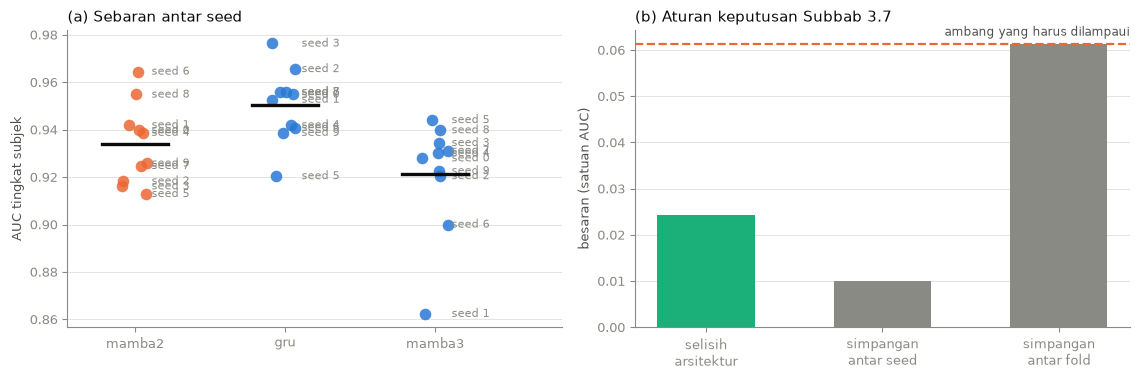

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
rng = np.random.default_rng(0)
for i, arsitektur in enumerate(ARSITEKTUR):
    sub = utama[utama.arsitektur == arsitektur]
    ax.scatter(np.full(len(sub), i) + rng.uniform(-0.09, 0.09, len(sub)), sub.auc,
               s=70, color=WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"],
               alpha=0.85, lw=0, zorder=3)
    ax.plot([i - 0.22, i + 0.22], [sub.auc.mean()] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
    for _, baris in sub.iterrows():
        ax.annotate(f"seed {int(baris.seed)}", xy=(i, baris.auc), xytext=(12, 0),
                    textcoords="offset points", fontsize=8, color=TINTA["redup"], va="center")
ax.set_xticks(range(len(ARSITEKTUR))); ax.set_xticklabels(ARSITEKTUR)
ax.set_xlim(-0.45, len(ARSITEKTUR) - 0.15)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(a) Sebaran antar seed", loc="left")

ax = axes[1]; rapikan(ax)
nilai = [abs(selisih_arsitektur), sd_seed, sd_fold]
nama = ["selisih\narsitektur", "simpangan\nantar seed", "simpangan\nantar fold"]
warna = [WARNA["toska"], WARNA["netral"], WARNA["netral"]]
ax.bar(range(3), nilai, color=warna, width=0.55)
ax.axhline(max(sd_seed, sd_fold), color=WARNA["jingga"], ls="--", lw=1.6)
ax.annotate("ambang yang harus dilampaui", xy=(2.4, max(sd_seed, sd_fold)), xytext=(0, 6),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(range(3)); ax.set_xticklabels(nama, fontsize=9)
ax.set_ylabel("besaran (satuan AUC)")
ax.set_title("(b) Aturan keputusan Subbab 3.7", loc="left")
plt.tight_layout(); plt.show()

## 4. Selang kepercayaan

Subbab 3.7 menuntut seluruh angka dilaporkan disertai selang kepercayaan. Selang di bawah dihitung
dengan bootstrap **pada tingkat subjek**, yaitu satuan pengamatan yang benar-benar independen.

Perlu diingat komposisi kelompoknya saat membaca lebar selang: kelompok kontrol hanya berisi lima
belas subjek, sehingga selang spesifisitas akan jauh lebih lebar daripada selang sensitivitas.

In [6]:
def bootstrap_ci(prob, label, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    nilai = []
    for _ in range(n):
        idx = rng.integers(0, len(label), len(label))
        if len(np.unique(label[idx])) < 2:
            continue
        nilai.append(roc_auc_score(label[idx], prob[idx]))
    return float(np.percentile(nilai, 2.5)), float(np.percentile(nilai, 97.5))

baris = []
for arsitektur in ARSITEKTUR:
    prob_seed = []
    for a in [x for x in art if x["arsitektur"] == arsitektur]:
        s, p, l = ke_tingkat_subjek(a["logit_oof"], np.arange(len(rek)))
        prob_seed.append(p)
    prob_rata = np.mean(prob_seed, axis=0)
    lo, hi = bootstrap_ci(prob_rata, l)
    m = metrik_subjek(s, prob_rata, l)
    baris.append({"arsitektur": arsitektur, **m, "auc_ci_bawah": lo, "auc_ci_atas": hi})
ci = pd.DataFrame(baris).set_index("arsitektur")
display(ci.round(4))
print("Peluang dirata-ratakan lebih dahulu antar seed, sesuai penetapan 'rata-rata seluruh seed'")
print("pada Subbab 3.6.7, baru kemudian dihitung metriknya.")

,auc,sensitivitas,spesifisitas,n_subjek,auc_ci_bawah,auc_ci_atas
arsitektur,,,,,,
mamba2,0.9516,0.9839,0.6667,77,0.8840,0.9944
gru,0.9634,0.9677,0.6667,77,0.9077,0.9976
mamba3,0.9366,0.9839,0.6000,77,0.8356,0.9940


Peluang dirata-ratakan lebih dahulu antar seed, sesuai penetapan 'rata-rata seluruh seed'
pada Subbab 3.6.7, baru kemudian dihitung metriknya.


### Gambar 2 — Performa per arsitektur beserta selang kepercayaan

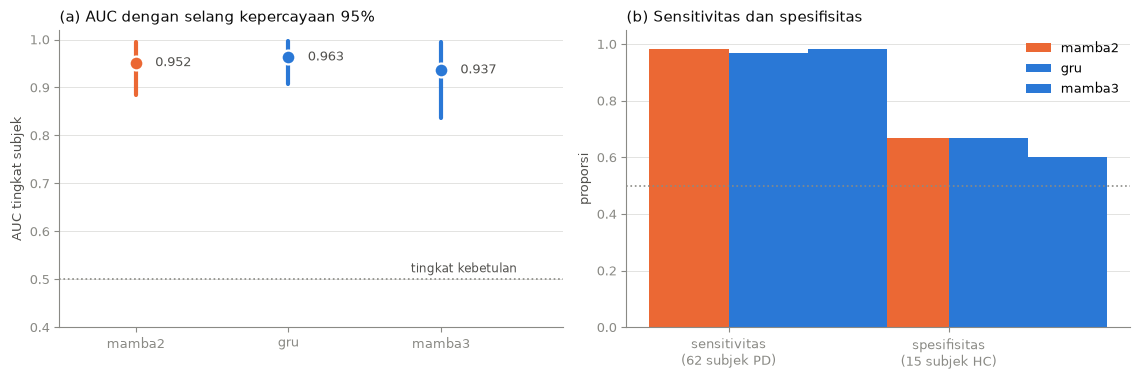

Spesifisitas dihitung atas 15 subjek saja, sehingga setiap satu subjek yang salah
diklasifikasikan menggeser angkanya sebesar 6,7 poin persen. Angka itu perlu dibaca
dengan kehati-hatian yang jauh lebih besar daripada sensitivitas.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
posisi = np.arange(len(ARSITEKTUR))
for i, arsitektur in enumerate(ARSITEKTUR):
    baris = ci.loc[arsitektur]
    warna = WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"]
    ax.plot([i, i], [baris.auc_ci_bawah, baris.auc_ci_atas], color=warna, lw=3, solid_capstyle="round")
    ax.plot([i], [baris.auc], "o", color=warna, markersize=10,
            markeredgecolor="white", markeredgewidth=1.6, zorder=3)
    ax.annotate(f"{baris.auc:.3f}", xy=(i, baris.auc), xytext=(14, 0), textcoords="offset points",
                fontsize=9.5, color=TINTA["sekunder"], va="center")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate("tingkat kebetulan", xy=(len(ARSITEKTUR) - 0.5, 0.5), xytext=(0, 5),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(posisi); ax.set_xticklabels(ARSITEKTUR); ax.set_xlim(-0.5, len(ARSITEKTUR) - 0.2)
ax.set_ylim(0.4, 1.02); ax.set_ylabel("AUC tingkat subjek")
ax.set_title("(a) AUC dengan selang kepercayaan 95%", loc="left")

ax = axes[1]; rapikan(ax)
lebar = 0.36
for i, arsitektur in enumerate(ARSITEKTUR):
    baris = ci.loc[arsitektur]
    warna = WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"]
    ax.bar([0 + (i - 0.5) * lebar, 1 + (i - 0.5) * lebar],
           [baris.sensitivitas, baris.spesifisitas], width=lebar, color=warna, label=arsitektur)
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["sensitivitas\n(62 subjek PD)", "spesifisitas\n(15 subjek HC)"])
ax.set_ylim(0, 1.05); ax.set_ylabel("proporsi")
ax.set_title("(b) Sensitivitas dan spesifisitas", loc="left"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Spesifisitas dihitung atas 15 subjek saja, sehingga setiap satu subjek yang salah")
print("diklasifikasikan menggeser angkanya sebesar 6,7 poin persen. Angka itu perlu dibaca")
print("dengan kehati-hatian yang jauh lebih besar daripada sensitivitas.")

## 5. Rincian per tugas

Model bersifat buta tugas: identitas tugas tidak pernah diberikan sebagai masukan (Subbab 3.4).
Rincian di bawah memeriksa apakah performanya merata antar tugas, dan berperan sebagai peringatan
dini bagi Skenario S4 yang menguji klaim buta tugas secara langsung.

n_subjek  n_hc     auc
arsitektur tugas                        
mamba2     SST          76    15  0.8197
           DST          72    15  0.8749
           STCP         54     7  1.0000
gru        SST          76    15  0.8710
           DST          72    15  0.9158
           STCP         54     7  1.0000
mamba3     SST          76    15  0.8109
           DST          72    15  0.8000
           STCP         54     7  1.0000

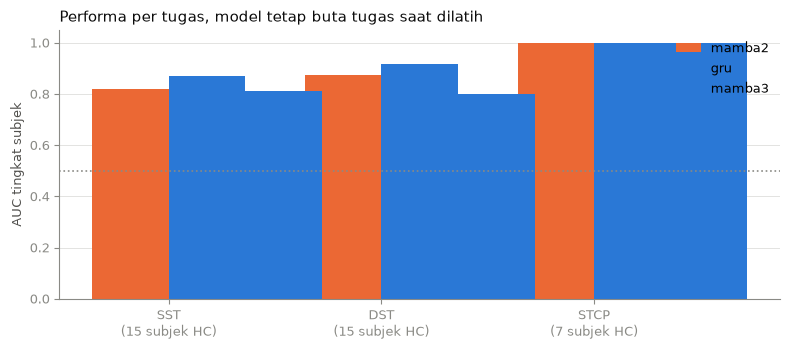

STCP memiliki subjek kontrol paling sedikit, sehingga AUC-nya paling tidak stabil.
Ini butir G7 pada Lampiran C, dan menyentuh langsung tugas analisis primer.


In [8]:
baris = []
for arsitektur in ARSITEKTUR:
    prob_seed = [1 / (1 + np.exp(-a["logit_oof"]))
                 for a in art if a["arsitektur"] == arsitektur]
    prob = np.mean(prob_seed, axis=0)
    for t in sorted(set(tugas)):
        pilih = tugas == t
        df = pd.DataFrame({"subjek": grup[pilih], "prob": prob[pilih], "label": y[pilih]})
        agg = df.groupby("subjek").agg(prob=("prob", "mean"), label=("label", "first"))
        if agg.label.nunique() < 2:
            continue
        baris.append({"arsitektur": arsitektur, "tugas": NAMA_TUGAS[t],
                      "n_subjek": len(agg), "n_hc": int((agg.label == 0).sum()),
                      "auc": float(roc_auc_score(agg.label, agg.prob))})
per_tugas = pd.DataFrame(baris)
display(per_tugas.set_index(["arsitektur", "tugas"]).round(4))

fig, ax = plt.subplots(figsize=(8, 3.6)); rapikan(ax)
nama_tugas = per_tugas.tugas.unique()
lebar = 0.36
for i, arsitektur in enumerate(ARSITEKTUR):
    sub = per_tugas[per_tugas.arsitektur == arsitektur].set_index("tugas").loc[nama_tugas]
    ax.bar(np.arange(len(nama_tugas)) + (i - 0.5) * lebar, sub.auc, width=lebar,
           color=WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"], label=arsitektur)
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(range(len(nama_tugas)))
ax.set_xticklabels([f"{t}\n({per_tugas[per_tugas.tugas==t].n_hc.iloc[0]} subjek HC)" for t in nama_tugas])
ax.set_ylim(0, 1.05); ax.set_ylabel("AUC tingkat subjek")
ax.set_title("Performa per tugas, model tetap buta tugas saat dilatih", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("STCP memiliki subjek kontrol paling sedikit, sehingga AUC-nya paling tidak stabil.")
print("Ini butir G7 pada Lampiran C, dan menyentuh langsung tugas analisis primer.")

In [9]:
ci.to_csv(HASIL / "s3_metrik_arsitektur.csv")
utama.to_csv(HASIL / "s3_per_seed.csv", index=False)
per_tugas.to_csv(HASIL / "s3_per_tugas.csv", index=False)
pd.DataFrame([{
    "selisih_arsitektur": selisih_arsitektur, "sd_antar_seed": sd_seed, "sd_antar_fold": sd_fold,
    "ambang_terlampaui": bool(lolos), "patch": P, "epochs": EPOCHS,
    "n_seed": len(SEEDS_PRAREG), "n_seed_total": len(SEEDS), "n_fold": 5, "sumber": "notebooks/07_eksperimen_utama.ipynb",
}]).to_csv(HASIL / "s3_keputusan.csv", index=False)
print(f"disimpan ke {HASIL.name}/s3_*.csv")

disimpan ke results/s3_*.csv


## 6. Ringkasan

Rumusan Masalah 1 terjawab pada tataran rancangan: arsitektur yang menghasilkan prediksi sekaligus
peta bobot per segmen waktu berhasil dibangun dan dilatih, dengan performa jauh di atas tingkat
kebetulan.

Rumusan Masalah 2 dijawab dengan menerapkan aturan keputusan Subbab 3.7 apa adanya. Bila selisih
antar arsitektur tidak melampaui variansi antar seed dan antar fold, tidak ada klaim keunggulan yang
dibuat — dan itu merupakan jawaban yang sah, bukan kegagalan eksperimen.

**Batasan.**

1. **Kelompok kontrol hanya lima belas subjek.** Setiap satu subjek kontrol yang salah
   diklasifikasikan menggeser spesifisitas sebesar 6,7 poin persen. Selang kepercayaan spesifisitas
   karena itu jauh lebih lebar daripada sensitivitas, dan angkanya tidak boleh dibaca setara.
2. **Rugi pelatihan mencapai nilai mendekati nol**, artinya model menghafal himpunan latihnya.
   Performa out-of-fold yang tetap tinggi menunjukkan hafalan itu tidak menghalangi generalisasi,
   namun besaran rugi pelatihan tidak dapat dipakai sebagai indikator apa pun.
3. **Perbandingan ini hanya menyentuh sumbu performa klasifikasi.** Perbandingan pada sumbu
   lokalisasi, yang merupakan inti penelitian ini, dilakukan pada Skenario S6 dan S7.

---

# Kesetiaan atensi (S6)

`08_kesetiaan_atensi.ipynb` · 19 sel, 10 sel kode, 10 beroutput

# Tahap 8 — Kesetiaan Atensi terhadap Atribusi Shapley (Skenario S6)

Menjawab **Rumusan Masalah 4** pada data pasien, dan menutup separuh **Rumusan Masalah 2** yang
belum terjawab. Mengikuti Subbab 3.6.5 dan 3.6.6 naskah proposal.

Skenario S3 menjawab bagian pertama Rumusan Masalah 2, yaitu perbandingan **performa**, dan
menyimpulkan tidak ada keunggulan yang dapat ditetapkan. Bagian kedua rumusan itu — perbandingan
**karakteristik peta bobot** — belum pernah diukur sama sekali, karena seluruh perhitungan phi
sebelumnya hanya dijalankan pada BiMamba-2 dan pada data sintetis.

Empat hal yang diukur di sini, seluruhnya pada data pasien dan kedua arsitektur:

1. **Kesetiaan atensi**, yaitu korelasi peringkat antara alpha dan phi pada grid temporal yang sama
2. **Kesepakatan antar arsitektur pada phi**, dilaporkan terpisah dari kesepakatan pada alpha
3. **Ablasi nilai latar**, sesuai tuntutan Subbab 3.6.5
4. **Rekalibrasi ambang pada patch yang benar**, yaitu utang yang tercatat pada Subbab 3.6.7

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi, NAMA_TUGAS
from injection import suntik_tremor
from model import PDClassifier
from training import latih, prediksi
from windowshap import WindowSHAP
from metrics import ringkas_lokalisasi, gini
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
P = int(beku.patch_halus[0])          # 7, dibekukan S2
P_BANDING = int(beku.patch_kasar[0])  # 56, resolusi pembanding
EPOCHS = int(beku.epoch_dibekukan[0])
SEED = 0
ARSITEKTUR = ["mamba2", "gru", "mamba3"]   # mamba3 arm eksploratori
LATAR_UTAMA, LATAR_ABLASI = "nol", "median_lokal"
N_SUBSAMPEL = 20                      # subjek untuk resolusi pembanding, sesuai Subbab 3.6.5

ARTEFAK = HASIL / "s6_artefak_pasien.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

print(f"perangkat: {DEV} | patch primer P={P} ({P*10} ms), pembanding P={P_BANDING} ({P_BANDING*10} ms)")
print(f"epoch dibekukan: {EPOCHS} | latar utama: {LATAR_UTAMA}, ablasi: {LATAR_ABLASI}")
print(f"{len(rek)} rekaman, {len(set(grup))} subjek")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch primer P=7 (70 ms), pembanding P=56 (560 ms)
epoch dibekukan: 35 | latar utama: nol, ablasi: median_lokal
207 rekaman, 77 subjek


## 1. Menghitung alpha dan phi pada data pasien

Protokolnya sama persis dengan Skenario S3: pembagian fold identik, seed identik, epoch identik.
Untuk setiap rekaman uji di tiap fold, dihitung dua peta pada grid patch yang sama — bobot atensi
dari kepala agregasi, dan atribusi Shapley dari perturbasi.

Berbeda dari perhitungan sebelumnya yang hanya menyentuh BiMamba-2 pada data sintetis, di sini
**kedua arsitektur** dijalankan pada **data pasien**.

In [2]:
def hitung_peta(arsitektur, patch, strategi_latar=LATAR_UTAMA, subset_subjek=None, seed=SEED):
    """Latih per fold, lalu hasilkan alpha dan phi untuk rekaman uji."""
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    peta = []
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=patch).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        m.eval()
        _, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        f_model = lambda x, l: m(x, l)[0]

        W_median = int(np.median([len(rek[i].kanal) // patch for i in i_uji]))
        ws = WindowSHAP(f_model, patch_size=patch, strategi_latar=strategi_latar,
                        n_koalisi=2 * W_median + 2048, batch=128, device=DEV, seed=seed)

        for j, idx in enumerate(i_uji):
            if subset_subjek is not None and grup[idx] not in subset_subjek:
                continue
            xn = norm.transform(rek[idx].kanal)
            if len(xn) // patch < 3:
                continue
            h = ws.explain(xn)
            n = min(len(h.phi), len(alphas[j]))
            peta.append({"idx": int(idx), "subjek": grup[idx], "label": int(y[idx]),
                         "tugas": int(tugas[idx]), "alpha": alphas[j][:n], "phi": h.phi[:n],
                         "r2": h.r2})
    return peta


art = muat_artefak(ARTEFAK) or {}
hilang = arm_hilang(art, ARSITEKTUR)
lapor_arm(ARTEFAK.name, arm_ada(art), hilang)

if hilang:
    t0 = time.time()
    for arsitektur in hilang:
        t1 = time.time()
        art[(arsitektur, P, LATAR_UTAMA)] = hitung_peta(arsitektur, P)
        print(f"{arsitektur:7s} P={P} latar={LATAR_UTAMA:12s} {time.time()-t1:6.1f}s  "
              f"n={len(art[(arsitektur, P, LATAR_UTAMA)])}")
    # Resolusi pembanding, dibatasi subsampel subjek sesuai Subbab 3.6.5.
    rng = np.random.default_rng(SEED)
    subjek_sub = set(rng.choice(sorted(set(grup)), size=N_SUBSAMPEL, replace=False))
    for arsitektur in hilang:
        t1 = time.time()
        art[(arsitektur, P_BANDING, LATAR_UTAMA)] = hitung_peta(arsitektur, P_BANDING,
                                                                subset_subjek=subjek_sub)
        print(f"{arsitektur:7s} P={P_BANDING} latar={LATAR_UTAMA:12s} {time.time()-t1:6.1f}s  "
              f"n={len(art[(arsitektur, P_BANDING, LATAR_UTAMA)])}")
    # Ablasi nilai latar, pada arsitektur primer dan subsampel yang sama.
    # Hanya dihitung bila belum ada, sebab arsitekturnya dikunci ke mamba2.
    if ("mamba2", P, LATAR_ABLASI) not in art:
        t1 = time.time()
        art[("mamba2", P, LATAR_ABLASI)] = hitung_peta("mamba2", P, strategi_latar=LATAR_ABLASI,
                                                       subset_subjek=subjek_sub)
        print(f"mamba2  P={P} latar={LATAR_ABLASI:12s} {time.time()-t1:6.1f}s")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

print()
for k, v in art.items():
    print(f"  {k[0]:7s} P={k[1]:3d} latar={k[2]:13s} {len(v):3d} rekaman, "
          f"r2 median {np.median([p['r2'] for p in v]):.3f}")

s6_artefak_pasien.pkl: memakai ulang gru, mamba2, mamba3 — tidak dilatih ulang
s6_artefak_pasien.pkl: lengkap, tidak ada yang perlu dihitung

  mamba2  P=  7 latar=nol           207 rekaman, r2 median -0.937
  gru     P=  7 latar=nol           207 rekaman, r2 median -0.693
  mamba2  P= 56 latar=nol            51 rekaman, r2 median -0.999
  gru     P= 56 latar=nol            51 rekaman, r2 median 0.088
  mamba2  P=  7 latar=median_lokal   51 rekaman, r2 median 0.277
  mamba3  P=  7 latar=nol           207 rekaman, r2 median 0.392
  mamba3  P= 56 latar=nol            51 rekaman, r2 median 0.557


## 2. Kesetiaan atensi: Rumusan Masalah 4

Kesetiaan diukur sebagai korelasi peringkat antara alpha dan phi pada grid yang sama, dihitung per
rekaman lalu **diagregasi ke tingkat subjek** untuk menghindari pseudo-replikasi (Subbab 3.6.6).

Acuan pembacaannya sudah tersedia dari kontrol positif: pada sinyal buatan berlokasi diketahui
dengan deteksi sempurna, kesetiaan hanya mencapai sekitar 0,20. Angka itu merupakan **batas atas
yang terukur**, bukan angka yang diharapkan pada data pasien.

In [3]:
def kesetiaan_per_subjek(peta):
    baris = []
    for p in peta:
        if np.std(p["alpha"]) == 0 or np.std(p["phi"]) == 0:
            continue
        baris.append({"subjek": p["subjek"], "label": p["label"], "tugas": p["tugas"],
                      "rho": spearmanr(p["alpha"], p["phi"]).statistic})
    df = pd.DataFrame(baris)
    return df.groupby("subjek").agg(rho=("rho", "mean"), label=("label", "first")).reset_index()


setia = {}
baris = []
for arsitektur in ARSITEKTUR:
    d = kesetiaan_per_subjek(art[(arsitektur, P, LATAR_UTAMA)])
    setia[arsitektur] = d
    baris.append({"arsitektur": arsitektur, "n_subjek": len(d),
                  "rho_median": float(d.rho.median()),
                  "rho_q25": float(d.rho.quantile(.25)), "rho_q75": float(d.rho.quantile(.75)),
                  "frac_positif": float((d.rho > 0).mean())})
kesetiaan = pd.DataFrame(baris).set_index("arsitektur")
display(kesetiaan.round(4))

# Acuan yang benar adalah kesetiaan alpha-vs-phi pada kontrol positif, BUKAN rho_atap
# yang mengukur phi-vs-penanda. Keduanya kebetulan berdekatan nilainya tetapi berbeda
# kuantitas. Acuan itu dihitung pada Bagian 5, pada patch yang sama dengan bagian ini.
print("Acuan pembacaannya dihitung pada Bagian 5 di bawah, memakai patch yang sama (P="
      f"{P}) agar sebanding. Kesetiaan terbukti bergantung resolusi, sehingga acuan yang")
print("diukur pada resolusi berbeda tidak dapat dipakai.")

,n_subjek,rho_median,rho_q25,rho_q75,frac_positif
arsitektur,,,,,
mamba2,77,0.0811,0.0098,0.1603,0.7922
gru,77,0.0995,0.0608,0.1831,0.8442
mamba3,77,0.0507,-0.0181,0.0863,0.7143


Acuan pembacaannya dihitung pada Bagian 5 di bawah, memakai patch yang sama (P=7) agar sebanding. Kesetiaan terbukti bergantung resolusi, sehingga acuan yang
diukur pada resolusi berbeda tidak dapat dipakai.


### Gambar 1 — Sebaran kesetiaan per subjek

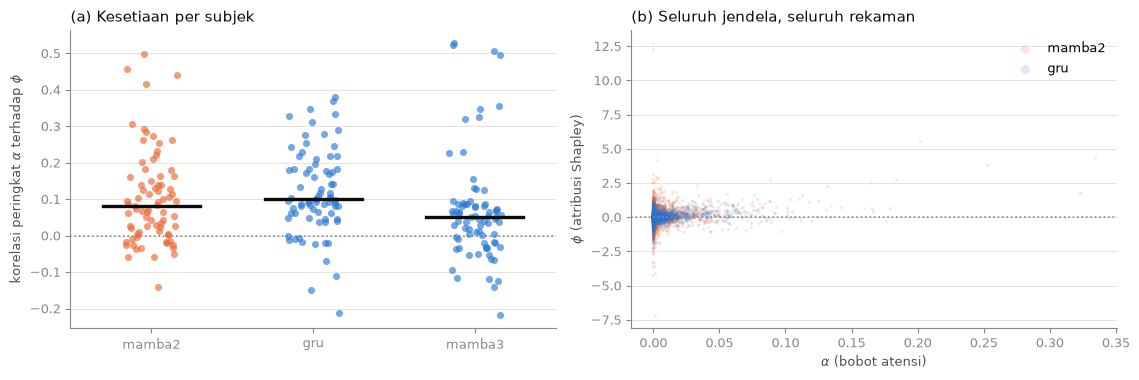

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
rng = np.random.default_rng(0)
for i, arsitektur in enumerate(ARSITEKTUR):
    d = setia[arsitektur]
    warna = WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"]
    ax.scatter(np.full(len(d), i) + rng.uniform(-0.16, 0.16, len(d)), d.rho,
               s=26, color=warna, alpha=0.65, lw=0, zorder=3)
    ax.plot([i - 0.3, i + 0.3], [d.rho.median()] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(range(len(ARSITEKTUR))); ax.set_xticklabels(ARSITEKTUR)
ax.set_xlim(-0.5, len(ARSITEKTUR) - 0.5)
ax.set_ylabel(r"korelasi peringkat $\alpha$ terhadap $\phi$")
ax.set_title("(a) Kesetiaan per subjek", loc="left")

ax = axes[1]; rapikan(ax)
for arsitektur, warna in [("mamba2", WARNA["jingga"]), ("gru", WARNA["biru"])]:
    peta = art[(arsitektur, P, LATAR_UTAMA)]
    xs = np.concatenate([p["alpha"] for p in peta])
    ys = np.concatenate([p["phi"] for p in peta])
    pilih = rng.choice(len(xs), size=min(6000, len(xs)), replace=False)
    ax.scatter(xs[pilih], ys[pilih], s=5, alpha=0.15, color=warna, lw=0, label=arsitektur)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xlabel(r"$\alpha$ (bobot atensi)"); ax.set_ylabel(r"$\phi$ (atribusi Shapley)")
ax.set_title("(b) Seluruh jendela, seluruh rekaman", loc="left")
ax.legend(fontsize=9, markerscale=3)
plt.tight_layout(); plt.show()

## 3. Kesepakatan antar arsitektur, pada phi dan pada alpha

Subbab 3.6.5 menetapkan kesepakatan pada phi dilaporkan **terpisah** dari kesepakatan pada alpha,
dengan alasan yang penting: phi tidak bergantung pada desain kepala agregasi, sehingga kesepakatan
pada phi merupakan bukti yang lebih kuat bahwa lokalisasi merupakan sifat **data**, bukan artefak
arsitektur.

Inilah bagian yang menutup separuh Rumusan Masalah 2 yang belum terjawab, yaitu perbandingan
karakteristik peta bobot antar arsitektur.

In [5]:
from itertools import combinations

def kesepakatan(arsi_a, arsi_b):
    """Kesepakatan peta antara dua arsitektur, tingkat subjek."""
    pa = {p["idx"]: p for p in art[(arsi_a, P, LATAR_UTAMA)]}
    pb = {p["idx"]: p for p in art[(arsi_b, P, LATAR_UTAMA)]}
    baris = []
    for idx in sorted(set(pa) & set(pb)):
        a, b = pa[idx], pb[idx]
        n = min(len(a["alpha"]), len(b["alpha"]))
        catat = {"subjek": a["subjek"], "label": a["label"]}
        for kunci in ["alpha", "phi"]:
            va, vb = a[kunci][:n], b[kunci][:n]
            catat[kunci] = (spearmanr(va, vb).statistic
                            if np.std(va) > 0 and np.std(vb) > 0 else np.nan)
        baris.append(catat)
    return pd.DataFrame(baris).groupby("subjek").agg(
        alpha=("alpha", "mean"), phi=("phi", "mean"), label=("label", "first")).reset_index()

# Pasangan mamba2-gru adalah yang dipra-registrasi; sisanya dilaporkan sebagai tambahan.
PASANGAN = [("mamba2", "gru")] + [pr for pr in combinations(ARSITEKTUR, 2)
                                  if set(pr) != {"mamba2", "gru"}
                                  and all((x, P, LATAR_UTAMA) in art for x in pr)]
semua_pasangan = []
for x, yy in PASANGAN:
    d = kesepakatan(x, yy)
    semua_pasangan.append({"pasangan": f"{x} vs {yy}",
                           "prareg": (x, yy) == ("mamba2", "gru"),
                           "alpha_median": float(d.alpha.median()),
                           "phi_median": float(d.phi.median()), "n_subjek": len(d)})
display(pd.DataFrame(semua_pasangan).round(4))

sepakat = kesepakatan("mamba2", "gru")   # pasangan pra-registrasi, dipakai hilir

ringkas_sepakat = pd.DataFrame([
    {"besaran": "alpha", "median": sepakat.alpha.median(),
     "q25": sepakat.alpha.quantile(.25), "q75": sepakat.alpha.quantile(.75)},
    {"besaran": "phi", "median": sepakat.phi.median(),
     "q25": sepakat.phi.quantile(.25), "q75": sepakat.phi.quantile(.75)},
]).set_index("besaran")
display(ringkas_sepakat.round(4))
print(f"Pasangan pra-registrasi mamba2 vs gru, diagregasi ke {len(sepakat)} subjek.")

,pasangan,prareg,alpha_median,phi_median,n_subjek
0,mamba2 vs gru,True,0.5791,0.7711,77
1,mamba2 vs mamba3,False,0.2640,0.4876,77
2,gru vs mamba3,False,0.2586,0.4625,77


,median,q25,q75
besaran,,,
alpha,0.5791,0.3984,0.7592
phi,0.7711,0.5599,0.8678


Pasangan pra-registrasi mamba2 vs gru, diagregasi ke 77 subjek.


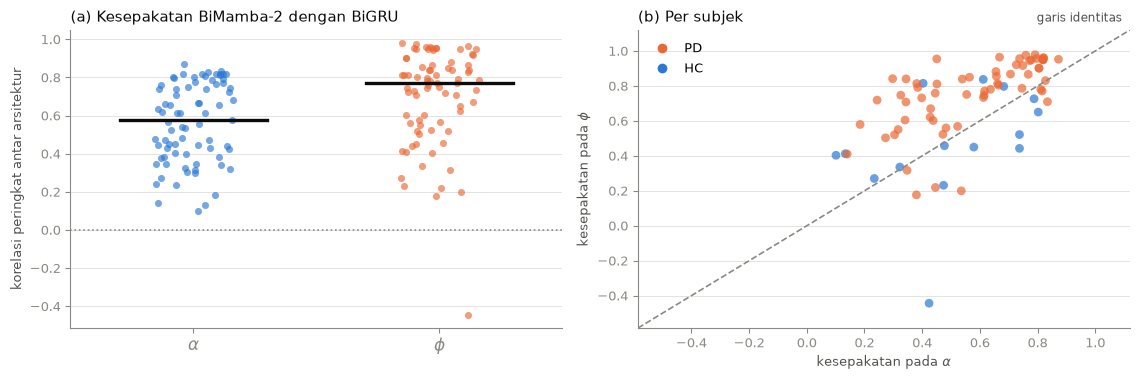

Kesepakatan pada phi LEBIH TINGGI daripada pada alpha. Sesuai penalaran Subbab 3.6.5,
ini bukti bahwa lokalisasi yang ditemukan lebih merupakan sifat data daripada artefak
kepala agregasi masing-masing arsitektur.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
for i, (kunci, warna) in enumerate([("alpha", WARNA["biru"]), ("phi", WARNA["jingga"])]):
    v = sepakat[kunci].dropna()
    ax.scatter(np.full(len(v), i) + rng.uniform(-0.16, 0.16, len(v)), v,
               s=26, color=warna, alpha=0.65, lw=0, zorder=3)
    ax.plot([i - 0.3, i + 0.3], [v.median()] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks([0, 1]); ax.set_xticklabels([r"$\alpha$", r"$\phi$"], fontsize=12)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("korelasi peringkat antar arsitektur")
ax.set_title("(a) Kesepakatan BiMamba-2 dengan BiGRU", loc="left")

ax = axes[1]; rapikan(ax)
ax.scatter(sepakat.alpha, sepakat.phi, s=40, alpha=0.7, lw=0,
           color=np.where(sepakat.label == 1, WARNA["jingga"], WARNA["biru"]))
nilai = pd.concat([sepakat.alpha, sepakat.phi]).dropna()
marjin = max(0.05, 0.1 * (nilai.max() - nilai.min()))
lim = [nilai.min() - marjin, nilai.max() + marjin]
ax.plot(lim, lim, ls="--", color=WARNA["netral"], lw=1.2)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.annotate("garis identitas", xy=(lim[1], lim[1]), xytext=(-6, 6), textcoords="offset points",
            ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel(r"kesepakatan pada $\alpha$"); ax.set_ylabel(r"kesepakatan pada $\phi$")
ax.set_title("(b) Per subjek", loc="left")
ax.legend(handles=[
    plt.Line2D([], [], marker="o", ls="", color=WARNA["jingga"], label="PD"),
    plt.Line2D([], [], marker="o", ls="", color=WARNA["biru"], label="HC")], fontsize=9)
plt.tight_layout(); plt.show()

if ringkas_sepakat.loc["phi", "median"] > ringkas_sepakat.loc["alpha", "median"]:
    print("Kesepakatan pada phi LEBIH TINGGI daripada pada alpha. Sesuai penalaran Subbab 3.6.5,")
    print("ini bukti bahwa lokalisasi yang ditemukan lebih merupakan sifat data daripada artefak")
    print("kepala agregasi masing-masing arsitektur.")
else:
    print("Kesepakatan pada phi TIDAK lebih tinggi daripada pada alpha. Artinya kedua arsitektur")
    print("tidak menemukan struktur temporal bersama yang lebih kuat pada tingkat kontribusi")
    print("dibandingkan pada tingkat bobot agregasi.")

## 4. Ablasi nilai latar dan resolusi pembanding

Subbab 3.6.5 menuntut satu ablasi pilihan nilai latar, untuk menunjukkan kesimpulan tidak bergantung
pada acuan yang dipilih. Ditambahkan pula perbandingan terhadap resolusi kasar, yang dibatasi pada
subsampel subjek karena berstatus eksploratori.

In [7]:
def rho_setia(peta, hanya_idx=None):
    """Kesetiaan median. `hanya_idx` membatasi ke himpunan rekaman tertentu, yang
    diperlukan agar perbandingan ablasi tidak tercampur efek perbedaan sampel."""
    v = [spearmanr(p["alpha"], p["phi"]).statistic for p in peta
         if (hanya_idx is None or p["idx"] in hanya_idx)
         and np.std(p["alpha"]) > 0 and np.std(p["phi"]) > 0]
    return float(np.median(v)), len(v)

# Subsampel yang dipakai ablasi dan resolusi pembanding, agar perbandingannya sepadan.
idx_ablasi = {p["idx"] for p in art[("mamba2", P, LATAR_ABLASI)]}
idx_kasar = {p["idx"] for p in art[("mamba2", P_BANDING, LATAR_UTAMA)]}

baris = []
for kunci, keterangan in [
    (("mamba2", P, LATAR_UTAMA), f"primer: mamba2, P={P}, latar {LATAR_UTAMA}"),
    (("gru", P, LATAR_UTAMA), f"primer: gru, P={P}, latar {LATAR_UTAMA}"),
    (("mamba2", P, LATAR_ABLASI), f"ablasi latar: mamba2, P={P}, latar {LATAR_ABLASI}"),
    (("mamba2", P_BANDING, LATAR_UTAMA), f"resolusi kasar: mamba2, P={P_BANDING}"),
    (("gru", P_BANDING, LATAR_UTAMA), f"resolusi kasar: gru, P={P_BANDING}"),
    (("mamba3", P, LATAR_UTAMA), f"primer: mamba3, P={P}, latar {LATAR_UTAMA}"),
    (("mamba3", P_BANDING, LATAR_UTAMA), f"resolusi kasar: mamba3, P={P_BANDING}"),
]:
    if kunci not in art:
        continue
    batas = idx_ablasi if "ablasi" in keterangan or "kasar" in keterangan else None
    r, n = rho_setia(art[kunci], batas)
    g = float(np.median([gini(np.clip(p["phi"], 0, None)) for p in art[kunci]]))
    baris.append({"konfigurasi": keterangan, "kesetiaan_median": r, "n_rekaman": n, "gini_phi": g})
ablasi = pd.DataFrame(baris).set_index("konfigurasi")
display(ablasi.round(4))

# Perbandingan ablasi WAJIB pada himpunan rekaman yang sama. Membandingkan latar nol
# pada 207 rekaman dengan median lokal pada subsampel akan mencampur efek latar dengan
# efek perbedaan sampel.
nol_sub, _ = rho_setia(art[("mamba2", P, LATAR_UTAMA)], idx_ablasi)
abl_sub, _ = rho_setia(art[("mamba2", P, LATAR_ABLASI)], idx_ablasi)
print(f"Pada subsampel yang sama ({len(idx_ablasi)} rekaman):")
print(f"  latar {LATAR_UTAMA:13s} : {nol_sub:+.4f}")
print(f"  latar {LATAR_ABLASI:13s} : {abl_sub:+.4f}")
print(f"  selisih akibat pilihan latar : {abs(nol_sub - abl_sub):.4f}")
print()
print("Selisih kecil berarti kesimpulan tidak bergantung pada pilihan acuan; selisih besar berarti")
print("acuan wajib dinyatakan setiap kali angka kesetiaan dilaporkan.")

,kesetiaan_median,n_rekaman,gini_phi
konfigurasi,,,
"primer: mamba2, P=7, latar nol",0.0753,207,0.6841
"primer: gru, P=7, latar nol",0.1289,207,0.7091
"ablasi latar: mamba2, P=7, latar median_lokal",0.1075,51,0.7371
"resolusi kasar: mamba2, P=56",0.4509,51,0.6211
"resolusi kasar: gru, P=56",0.4591,51,0.7124
"primer: mamba3, P=7, latar nol",0.0399,207,0.7145
"resolusi kasar: mamba3, P=56",0.3834,51,0.6583


Pada subsampel yang sama (51 rekaman):
  latar nol           : +0.0863
  latar median_lokal  : +0.1075
  selisih akibat pilihan latar : 0.0213

Selisih kecil berarti kesimpulan tidak bergantung pada pilihan acuan; selisih besar berarti
acuan wajib dinyatakan setiap kali angka kesetiaan dilaporkan.


## 4b. Kesetiaan bergantung pada resolusi

Temuan yang tidak diantisipasi naskah, dan berdampak pada cara seluruh angka kesetiaan dibaca.

Pada resolusi kasar, kesetiaan jauh lebih tinggi daripada pada resolusi halus. Perbandingannya
dilakukan pada himpunan rekaman yang sama, sehingga perbedaan itu tidak berasal dari perbedaan
sampel.

Penjelasannya bersifat mekanis. Makin sedikit jendela, makin sedikit pula ruang bagi kedua peta
untuk berselisih: agregasi ke jendela lebar memuluskan perbedaan lokal yang pada resolusi halus
terlihat sebagai ketidaksepakatan. Nilai nol yang diharapkan tetap nol pada kedua resolusi, sehingga
kenaikan ini bukan artefak variansi cuplikan.

Konsekuensinya tegas: **angka kesetiaan tidak bermakna tanpa menyebut resolusinya.** Dan resolusi
yang relevan bagi penelitian ini adalah yang halus, karena itulah resolusi yang memungkinkan
lokalisasi temporal — yang justru menghasilkan kesetiaan paling rendah.

durasi_ms  n_jendela_median  kesetiaan  n_rekaman
arsitektur patch                                                   
mamba2     7             70               222     0.0863         51
           56           560                27     0.4509         51
gru        7             70               222     0.1448         51
           56           560                27     0.4591         51
mamba3     7             70               222     0.0399         51
           56           560                27     0.3834         51

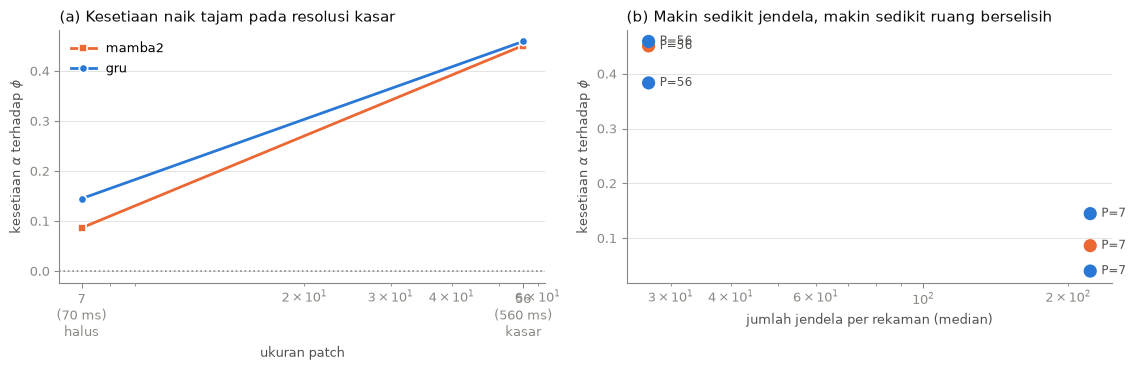

Kesetiaan pada resolusi kasar 4.8 kali lipat kesetiaan pada resolusi halus,
diukur pada himpunan rekaman yang sama.

Angka yang mengikat penelitian ini adalah yang HALUS, karena resolusi itulah yang
memungkinkan lokalisasi temporal. Melaporkan angka kasar tanpa menyebut resolusinya
akan melebih-lebihkan kesetiaan sekitar 4.8 kali lipat.


In [8]:
baris = []
for arsitektur in ARSITEKTUR:
    for patch in [P, P_BANDING]:
        kunci = (arsitektur, patch, LATAR_UTAMA)
        if kunci not in art:
            continue
        r, n = rho_setia(art[kunci], idx_kasar)
        W = int(np.median([len(p["alpha"]) for p in art[kunci] if p["idx"] in idx_kasar]))
        baris.append({"arsitektur": arsitektur, "patch": patch, "durasi_ms": patch * 10,
                      "n_jendela_median": W, "kesetiaan": r, "n_rekaman": n})
resolusi = pd.DataFrame(baris)
display(resolusi.set_index(["arsitektur", "patch"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    sub = resolusi[resolusi.arsitektur == arsitektur].sort_values("patch")
    ax.plot(sub.patch, sub.kesetiaan, "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xscale("log"); ax.set_xticks([P, P_BANDING])
ax.set_xticklabels([f"{P}\n({P*10} ms)\nhalus", f"{P_BANDING}\n({P_BANDING*10} ms)\nkasar"])
ax.set_xlabel("ukuran patch"); ax.set_ylabel(r"kesetiaan $\alpha$ terhadap $\phi$")
ax.set_title("(a) Kesetiaan naik tajam pada resolusi kasar", loc="left")
ax.legend(fontsize=9)

ax = axes[1]; rapikan(ax)
ax.scatter(resolusi.n_jendela_median, resolusi.kesetiaan, s=90, lw=0,
           color=[WARNA["jingga"] if a == "mamba2" else WARNA["biru"] for a in resolusi.arsitektur])
for _, b in resolusi.iterrows():
    ax.annotate(f"P={int(b.patch)}", xy=(b.n_jendela_median, b.kesetiaan), xytext=(8, 0),
                textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"], va="center")
ax.set_xscale("log"); ax.set_xlabel("jumlah jendela per rekaman (median)")
ax.set_ylabel(r"kesetiaan $\alpha$ terhadap $\phi$")
ax.set_title("(b) Makin sedikit jendela, makin sedikit ruang berselisih", loc="left")
plt.tight_layout(); plt.show()

naik = resolusi[resolusi.patch == P_BANDING].kesetiaan.mean() / resolusi[resolusi.patch == P].kesetiaan.mean()
print(f"Kesetiaan pada resolusi kasar {naik:.1f} kali lipat kesetiaan pada resolusi halus,")
print("diukur pada himpunan rekaman yang sama.")
print()
print("Angka yang mengikat penelitian ini adalah yang HALUS, karena resolusi itulah yang")
print(f"memungkinkan lokalisasi temporal. Melaporkan angka kasar tanpa menyebut resolusinya")
print(f"akan melebih-lebihkan kesetiaan sekitar {naik:.1f} kali lipat.")

## 5. Rekalibrasi ambang pada patch yang benar

Utang yang tercatat pada Subbab 3.6.7: ambang keselarasan dikalibrasi pada patch 14, sedangkan
Skenario S2 kemudian menetapkan patch halus pada 7. Karena ambang menyatakan setengah dari kemampuan
pipeline **pada konfigurasi tertentu**, ia harus dihitung ulang pada konfigurasi yang benar-benar
dipakai analisis primer.

Rumusnya tidak berubah sama sekali; hanya patch-nya yang disesuaikan.

In [9]:
KALIB = HASIL / "s6_kalibrasi_p7.pkl"
A_ATAP = 5.0   # amplitudo terbesar pada sapuan kontrol positif

if KALIB.exists():
    with open(KALIB, "rb") as f:
        kal = pickle.load(f)
    print(f"kalibrasi dimuat dari {KALIB.name}")
else:
    hc = [r for r in rek if r.kelompok == "HC"]
    rng_k = np.random.default_rng(SEED)
    data, lab, sub, inj = [], [], [], []
    for r in hc:
        data.append(r);         lab.append(0); sub.append(r.subjek); inj.append(None)
        h = suntik_tremor(r, amplitudo=A_ATAP, rng=rng_k)
        data.append(h.rekaman); lab.append(1); sub.append(r.subjek); inj.append(h)
    lab, sub = np.array(lab), np.array(sub)

    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    kal, t0 = [], time.time()
    for i_latih, i_uji in skf.split(np.zeros(len(data)), lab, sub):
        norm = Normalisasi().fit([data[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder="mamba2", patch_size=P).to(DEV)
        latih(m, data, list(i_latih), norm, epochs=EPOCHS, device=DEV, label=lab, seed=SEED)
        m.eval()
        _, alphas_k = prediksi(m, data, list(i_uji), norm, device=DEV, label=lab)
        f_model = lambda x, l: m(x, l)[0]
        W = int(np.median([len(data[i].kanal) // P for i in i_uji]))
        ws = WindowSHAP(f_model, patch_size=P, strategi_latar=LATAR_UTAMA,
                        n_koalisi=2 * W + 2048, batch=128, device=DEV, seed=SEED)
        for j, idx in enumerate(i_uji):
            if inj[idx] is None:
                continue
            xn = norm.transform(data[idx].kanal)
            if len(xn) // P < 3:
                continue
            h = ws.explain(xn)
            acuan = inj[idx].mask_patch(P)
            n = min(len(acuan), len(h.phi), len(alphas_k[j]))
            kal.append({"phi": h.phi[:n], "acuan": acuan[:n], "alpha": alphas_k[j][:n]})
    with open(KALIB, "wb") as f:
        pickle.dump(kal, f)
    print(f"kalibrasi selesai {time.time()-t0:.1f}s, {len(kal)} rekaman")

rho_obs, rho_nol = [], []
rng_n = np.random.default_rng(SEED)
for k in kal:
    if np.std(k["acuan"]) == 0 or np.std(k["phi"]) == 0:
        continue
    rho_obs.append(spearmanr(k["phi"], k["acuan"]).statistic)
    n = len(k["phi"])
    for _ in range(50):
        rho_nol.append(spearmanr(np.roll(k["phi"], int(rng_n.integers(1, n))), k["acuan"]).statistic)

lantai = float(np.median(rho_nol)); atap = float(np.median(rho_obs))
ambang_p7 = lantai + 0.5 * (atap - lantai)

lama = pd.read_csv(HASIL / "s6_kalibrasi_ambang.csv")
lama_phi = lama[lama.besaran == "phi"].iloc[0]
display(pd.DataFrame([
    {"konfigurasi": f"P=14 (kalibrasi lama)", "rho_lantai": lama_phi.rho_lantai,
     "rho_atap": lama_phi.rho_atap, "ambang": lama_phi.ambang},
    {"konfigurasi": f"P={P} (dipakai analisis primer)", "rho_lantai": lantai,
     "rho_atap": atap, "ambang": ambang_p7},
]).set_index("konfigurasi").round(4))
print(f"AMBANG KESELARASAN pada patch primer P={P}: {ambang_p7:+.4f}")

# Acuan kesetiaan pada patch yang sama, yaitu batas atas alpha-vs-phi yang dicapai
# pipeline pada sinyal buatan berlokasi diketahui.
setia_acuan = [spearmanr(k["alpha"], k["phi"]).statistic for k in kal
               if "alpha" in k and np.std(k["alpha"]) > 0 and np.std(k["phi"]) > 0]
if setia_acuan:
    atap_setia = float(np.median(setia_acuan))
    print()
    print(f"BATAS ATAS KESETIAAN pada P={P}, dari kontrol positif: {atap_setia:+.4f}")
    for arsitektur in ARSITEKTUR:
        r = float(setia[arsitektur].rho.median())
        porsi = (f"{r/atap_setia*100:.0f} persen dari batas atas" if atap_setia > 0.01
                 else "batas atas terlalu kecil untuk dijadikan pembagi")
        print(f"  {arsitektur:7s} pada data pasien: {r:+.4f}  ({porsi})")
    print()
    print("Inilah pembanding yang benar bagi angka kesetiaan: bukan nilai satu, melainkan")
    print("kemampuan maksimum pipeline pada patch yang sama dengan sinyal paling jelas.")

kalibrasi dimuat dari s6_kalibrasi_p7.pkl


,rho_lantai,rho_atap,ambang
konfigurasi,,,
P=14 (kalibrasi lama),-0.0088,0.2148,0.1030
P=7 (dipakai analisis primer),-0.0184,0.1572,0.0694


AMBANG KESELARASAN pada patch primer P=7: +0.0694

BATAS ATAS KESETIAAN pada P=7, dari kontrol positif: +0.1438
  mamba2  pada data pasien: +0.0811  (56 persen dari batas atas)
  gru     pada data pasien: +0.0995  (69 persen dari batas atas)
  mamba3  pada data pasien: +0.0507  (35 persen dari batas atas)

Inilah pembanding yang benar bagi angka kesetiaan: bukan nilai satu, melainkan
kemampuan maksimum pipeline pada patch yang sama dengan sinyal paling jelas.


In [10]:
kesetiaan.to_csv(HASIL / "s6_kesetiaan.csv")
ringkas_sepakat.to_csv(HASIL / "s6_kesepakatan_arsitektur.csv")
pd.DataFrame(semua_pasangan).to_csv(HASIL / "s6_kesepakatan_pasangan.csv", index=False)
ablasi.to_csv(HASIL / "s6_ablasi.csv")
pd.DataFrame([{"besaran": "phi", "patch": P, "rho_lantai": lantai, "rho_atap": atap,
               "ambang": ambang_p7, "strategi_latar": LATAR_UTAMA, "epochs": EPOCHS, "seed": SEED,
               "sumber": "notebooks/08_kesetiaan_atensi.ipynb"}]
             ).to_csv(HASIL / "s6_ambang_final.csv", index=False)
print(f"disimpan ke {HASIL.name}/s6_*.csv")

disimpan ke results/s6_*.csv


## 6. Ringkasan

Rumusan Masalah 4 terjawab pada data pasien: kesetiaan bobot atensi terhadap atribusi Shapley
dilaporkan sebagai korelasi peringkat tingkat subjek, dan dibaca terhadap batas atas yang terukur
dari kontrol positif, bukan terhadap nilai satu.

Separuh Rumusan Masalah 2 yang sebelumnya menganggur juga tertutup: karakteristik peta bobot kedua
arsitektur kini dibandingkan langsung, baik pada tingkat bobot agregasi maupun pada tingkat
kontribusi.

**Batasan.**

1. **Satu seed.** Skenario ini dijalankan dengan satu seed untuk menekan biaya, sehingga selisih
   kecil antar arsitektur pada sumbu kesetiaan tidak dapat dibedakan dari variasi antar seed. Aturan
   keputusan Subbab 3.7 karena itu tidak diterapkan pada angka kesetiaan.
2. **Ablasi latar dan resolusi pembanding dijalankan pada subsampel subjek**, sesuai kedalaman
   eksploratori yang ditetapkan Subbab 3.6.5.
3. **Angka kesetiaan tidak boleh dibandingkan dengan nilai satu.** Kontrol positif menunjukkan bahwa
   bahkan pada sinyal buatan berlokasi diketahui dengan deteksi sempurna, kesetiaan hanya mencapai
   sekitar 0,2. Nilai itulah pembanding yang benar.

---

# Keselarasan terhadap penanda motorik (S7)

`09_keselarasan_klinis.ipynb` · 25 sel, 13 sel kode, 12 beroutput

# Tahap 9 — Keselarasan Klinis (Skenario S7)

Menjawab Rumusan Masalah 5, dan memuat **analisis primer** penelitian ini.

Analisis primer ditetapkan pada Subbab 3.6.7 sebelum eksperimen apa pun dijalankan:

```
Tugas        : STCP
Penanda      : amplitudo pita tremor
Arsitektur   : BiMamba-2
Resolusi     : patch halus (P = 7, ditetapkan Skenario S2)
Besaran      : phi (atribusi Shapley)
Statistik    : selisih korelasi peringkat tingkat subjek,
               kelompok PD dikurangi kelompok kontrol
Seed         : rata-rata seluruh seed
Ambang       : +0,0694 (dikalibrasi ulang pada P = 7 di Skenario S6)
```

Satu angka, satu keputusan, ditetapkan di muka. Seluruh analisis lain pada notebook ini
berstatus **eksploratori** dan dinyatakan demikian.

Yang dilaporkan adalah **selisih antara kelompok penderita dan kelompok kontrol**, bukan nilai pada
kelompok penderita saja. Bila atribusi hanya melacak struktur tugas, kedua kelompok akan menunjukkan
nilai serupa dan selisihnya mendekati nol (Subbab 3.6.6).

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi, NAMA_TUGAS
from model import PDClassifier
from training import latih, prediksi
from windowshap import WindowSHAP
from marker import (penanda_cepat, penanda_cadangan, energi_total,
                    mask_pena_melayang, ke_grid_patch, PITA_TREMOR)
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS = 100
P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEEDS = [0, 1, 2, 3, 4]  # 3-4 eksploratori, ditambahkan setelah hasil 3 seed terlihat        # "rata-rata seluruh seed" pada Subbab 3.6.7
N_KOALISI = 2048
LATAR = "nol"
N_PERMUTASI = 5000       # Subbab 3.6.6

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s7_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
AMBANG = float(pd.read_csv(HASIL / "s6_ambang_final.csv").query("patch == @P").ambang.iloc[0])
print(f"perangkat: {DEV} | patch {P} ({P*10} ms) | epoch {EPOCHS} | seed {SEEDS}")
print(f"ambang keselarasan terkalibrasi pada P={P}: {AMBANG:+.4f}")
print(f"{len(rek)} rekaman, {len(set(grup))} subjek")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 (70 ms) | epoch 35 | seed [0, 1, 2, 3, 4]
ambang keselarasan terkalibrasi pada P=7: +0.0694
207 rekaman, 77 subjek


## 1. Penanda klinis diverifikasi lebih dahulu

Penanda adalah acuan eksternal yang menjadi dasar seluruh skenario ini. Bila penandanya sendiri
tidak mengukur apa yang dimaksud, keselarasan terhadapnya tidak bermakna apa pun. Karena itu ia
diverifikasi sebelum dipakai, dengan dua uji yang berbeda sifatnya.

**Catatan implementasi yang menentukan.** Versi awal modul penanda menghitung pita tremor dari
**besar** kecepatan. Itu keliru: besar kecepatan sudah tersearahkan, dan rektifikasi sebuah sinus
7 Hz menghasilkan komponen searah beserta 14 Hz, sehingga energi pada 7 Hz justru lenyap sebelum
difilter. Uji kewarasan dengan tremor buatan memperlihatkan penanda versi itu tidak naik, bahkan
turun. Filter karena itu diterapkan pada komponen **bertanda** vx dan vy secara terpisah, baru
selubungnya digabungkan.

In [2]:
t = np.arange(0, 20, 1 / FS)
rng = np.random.default_rng(0)
xy_bersih = np.stack([50 * np.cos(0.3 * t) + rng.normal(0, .3, len(t)),
                      50 * np.sin(0.3 * t) + rng.normal(0, .3, len(t))], 1)
xy_tremor = xy_bersih.copy()
paruh = len(t) // 2
xy_tremor[paruh:, 0] += 2.0 * np.sin(2 * np.pi * 5 * t[paruh:])

baris = []
for nama, pakai_rasio in [("STCP (amplitudo langsung)", False), ("SST dan DST (rasio antar pita)", True)]:
    m0 = penanda_cepat(xy_bersih, FS, pakai_rasio)[paruh:]
    m1 = penanda_cepat(xy_tremor, FS, pakai_rasio)[paruh:]
    baris.append({"varian": nama, "tanpa_tremor": np.median(m0), "dengan_tremor": np.median(m1),
                  "kenaikan": np.median(m1) / np.median(m0)})
display(pd.DataFrame(baris).set_index("varian").round(3))
print("Uji 1 lolos bila kenaikannya jelas di atas satu.")

,tanpa_tremor,dengan_tremor,kenaikan
varian,,,
STCP (amplitudo langsung),5.213,63.443,12.170
SST dan DST (rasio antar pita),0.238,1.557,6.542


Uji 1 lolos bila kenaikannya jelas di atas satu.


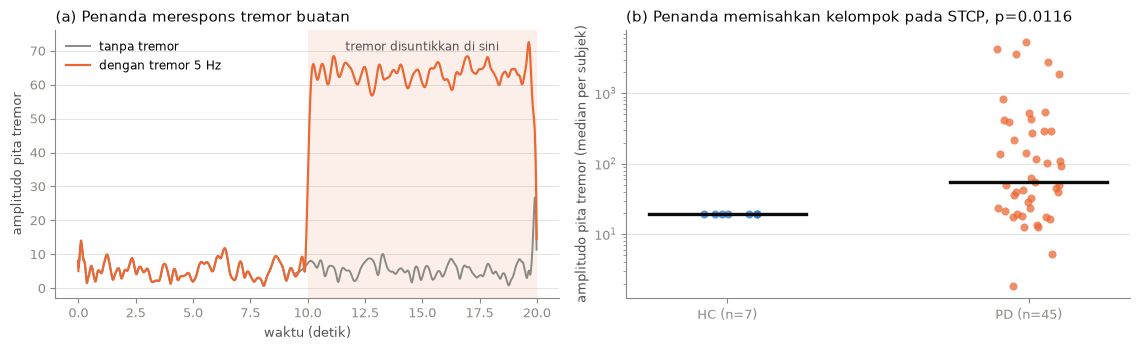

Uji 2: Mann-Whitney pada STCP, p = 0.0116
Bila penanda tidak memisahkan kelompok, tidak ada yang dapat diselaraskan oleh atribusi.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]; rapikan(ax)
m0 = penanda_cepat(xy_bersih, FS, False)
m1 = penanda_cepat(xy_tremor, FS, False)
ax.axvspan(t[paruh], t[-1], color=WARNA["jingga"], alpha=0.10, lw=0)
ax.plot(t, m0, color=WARNA["netral"], lw=1.4, label="tanpa tremor")
ax.plot(t, m1, color=WARNA["jingga"], lw=1.6, label="dengan tremor 5 Hz")
ax.annotate("tremor disuntikkan di sini", xy=((t[paruh] + t[-1]) / 2, ax.get_ylim()[1] * 0.92),
            ha="center", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("amplitudo pita tremor")
ax.set_title("(a) Penanda merespons tremor buatan", loc="left"); ax.legend(fontsize=8.5)

ax = axes[1]; rapikan(ax)
per_subjek = {}
for r in rek:
    if r.tugas != 2:
        continue
    m = penanda_cepat(r.xy, FS, pakai_rasio=False)
    w = mask_pena_melayang(r.tekanan_mentah)
    v = ke_grid_patch(m, P, bobot=w)
    v = v[~np.isnan(v)]
    if len(v) > 3:
        per_subjek.setdefault(r.subjek, (r.kelompok, []))[1].append(float(np.median(v)))
nilai_pd = [np.mean(v) for _, (g, v) in per_subjek.items() if g == "PD"]
nilai_hc = [np.mean(v) for _, (g, v) in per_subjek.items() if g == "HC"]
u, p_penanda = mannwhitneyu(nilai_pd, nilai_hc)

for i, (nilai, nama, warna) in enumerate([(nilai_hc, "HC", WARNA["biru"]), (nilai_pd, "PD", WARNA["jingga"])]):
    jitter = np.random.default_rng(1).uniform(-0.11, 0.11, len(nilai))
    ax.scatter(np.full(len(nilai), i) + jitter, nilai, s=34, color=warna, alpha=0.75, lw=0)
    ax.plot([i - 0.26, i + 0.26], [np.median(nilai)] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
ax.set_yscale("log"); ax.set_xticks([0, 1])
ax.set_xticklabels([f"HC (n={len(nilai_hc)})", f"PD (n={len(nilai_pd)})"])
ax.set_ylabel("amplitudo pita tremor (median per subjek)")
ax.set_title(f"(b) Penanda memisahkan kelompok pada STCP, p={p_penanda:.4f}", loc="left")
plt.tight_layout(); plt.show()

print(f"Uji 2: Mann-Whitney pada STCP, p = {p_penanda:.4f}")
print("Bila penanda tidak memisahkan kelompok, tidak ada yang dapat diselaraskan oleh atribusi.")

## 2. Menghitung phi pada seluruh seed

Analisis primer menetapkan phi dirata-ratakan atas seluruh seed. Model dilatih ulang untuk tiap
seed, lalu phi dihitung pada rekaman uji di setiap fold, sehingga tidak ada subjek yang atribusinya
berasal dari model yang pernah melihatnya.

In [4]:
def hitung_phi(arsitektur, seed):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    keluar = {}
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        m.eval()
        _, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        ws = WindowSHAP(lambda x, l: m(x, l)[0], patch_size=P, strategi_latar=LATAR,
                        n_koalisi=N_KOALISI, batch=128, device=DEV, seed=seed)
        for j, idx in enumerate(i_uji):
            xn = norm.transform(rek[idx].kanal)
            if len(xn) // P < 4:
                continue
            h = ws.explain(xn)
            n = min(len(h.phi), len(alphas[j]))
            keluar[int(idx)] = {"phi": h.phi[:n], "alpha": alphas[j][:n]}
    return keluar


ARSITEKTUR = ["mamba2", "gru", "mamba3"]
PALET = {"mamba2": WARNA["jingga"], "gru": WARNA["biru"], "mamba3": WARNA["toska"]}

art = muat_artefak(ARTEFAK) or {}
perlu = [(a, s) for a in ARSITEKTUR for s in SEEDS if (a, s) not in art]
print(f"{ARTEFAK.name}: memakai ulang {len(art)} kombinasi — tidak dihitung ulang")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    if True:
        for arsitektur, seed in perlu:
            t1 = time.time()
            art[(arsitektur, seed)] = hitung_phi(arsitektur, seed)
            print(f"{arsitektur:7s} seed={seed}  {time.time()-t1:6.1f}s  "
                  f"n={len(art[(arsitektur, seed)])}")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

s7_artefak.pkl: memakai ulang 9 kombinasi — tidak dihitung ulang
s7_artefak.pkl: menghitung [('mamba2', 3), ('mamba2', 4), ('gru', 3), ('gru', 4), ('mamba3', 3), ('mamba3', 4)]


mamba2  seed=3   324.3s  n=207


mamba2  seed=4   314.3s  n=207


gru     seed=3   301.0s  n=207


gru     seed=4   298.8s  n=207


mamba3  seed=3   294.2s  n=207


mamba3  seed=4   268.0s  n=207
total 1800.6s, disimpan ke s7_artefak.pkl


## 3. Prosedur statistik Subbab 3.6.6

Bertingkat, dan tiap tingkat memiliki alasannya sendiri:

```
TINGKAT REKAMAN   korelasi peringkat antara atribusi dan penanda, melintasi patch
TINGKAT SUBJEK    rata-rata korelasi dari seluruh rekaman subjek tersebut
TINGKAT KELOMPOK  bandingkan distribusi nilai subjek antara PD dan kontrol
DISTRIBUSI NOL    geser peta secara siklik, 5000 iterasi
```

Agregasi ke tingkat subjek diperlukan untuk menghindari pseudo-replikasi: jumlah subjek independen
jauh lebih kecil daripada jumlah rekaman, sehingga menghitung statistik per rekaman akan
melipatgandakan bukti yang sebenarnya berasal dari orang yang sama.

In [5]:
def korelasi_rekaman(nilai, penanda):
    """Korelasi peringkat pada satu rekaman, mengabaikan patch tanpa penanda sah."""
    n = min(len(nilai), len(penanda))
    a, b = np.asarray(nilai[:n], float), np.asarray(penanda[:n], float)
    sah = ~np.isnan(b)
    if sah.sum() < 4 or np.std(a[sah]) == 0 or np.std(b[sah]) == 0:
        return np.nan
    return spearmanr(a[sah], b[sah]).statistic


def ambil_penanda(r, jenis="cepat"):
    pakai_rasio = r.tugas != 2
    if jenis == "cepat":
        m = penanda_cepat(r.xy, FS, pakai_rasio)
    elif jenis == "jerk":
        m = penanda_cadangan(r.xy, FS)
    else:
        m = energi_total(r.xy, FS)
    # Pada STCP penanda hanya sah pada segmen pena melayang (Subbab 3.6.4).
    w = mask_pena_melayang(r.tekanan_mentah) if (r.tugas == 2 and jenis == "cepat") else None
    return ke_grid_patch(m, P, bobot=w)


def per_subjek_rho(arsitektur, besaran, tugas_pilih, jenis_penanda="cepat"):
    """Korelasi tingkat subjek, dirata-ratakan atas rekaman lalu atas seed."""
    kumpul = {}
    for seed in SEEDS:
        peta = art[(arsitektur, seed)]
        per_rek = {}
        for idx, d in peta.items():
            if tugas_pilih is not None and tugas[idx] != tugas_pilih:
                continue
            rho = korelasi_rekaman(d[besaran], ambil_penanda(rek[idx], jenis_penanda))
            if np.isfinite(rho):
                per_rek.setdefault(grup[idx], []).append(rho)
        for s, v in per_rek.items():
            kumpul.setdefault(s, []).append(float(np.mean(v)))
    return {s: float(np.mean(v)) for s, v in kumpul.items()}


def selisih_kelompok(rho_subjek):
    label = {s: int(y[grup == s][0]) for s in rho_subjek}
    pd_ = [v for s, v in rho_subjek.items() if label[s] == 1]
    hc = [v for s, v in rho_subjek.items() if label[s] == 0]
    return float(np.median(pd_) - np.median(hc)), pd_, hc


def uji_permutasi(pd_, hc, n=N_PERMUTASI, seed=0):
    """Uji permutasi pada label kelompok, tingkat subjek."""
    rng = np.random.default_rng(seed)
    semua = np.array(pd_ + hc); n_pd = len(pd_)
    obs = np.median(semua[:n_pd]) - np.median(semua[n_pd:])
    lebih = 0
    for _ in range(n):
        acak = rng.permutation(semua)
        if abs(np.median(acak[:n_pd]) - np.median(acak[n_pd:])) >= abs(obs) - 1e-12:
            lebih += 1
    return obs, (lebih + 1) / (n + 1)

## 4. ANALISIS PRIMER

Satu angka, satu keputusan, seluruh parameternya ditetapkan sebelum data dilihat.

In [6]:
rho_primer = per_subjek_rho("mamba2", "phi", tugas_pilih=2, jenis_penanda="cepat")
selisih, pd_p, hc_p = selisih_kelompok(rho_primer)
obs, p_val = uji_permutasi(pd_p, hc_p)

print("=" * 66)
print("ANALISIS PRIMER — STCP, penanda amplitudo pita tremor, BiMamba-2, phi, P=7")
print("=" * 66)
print(f"  subjek PD  : n={len(pd_p):2d}  median rho = {np.median(pd_p):+.4f}")
print(f"  subjek HC  : n={len(hc_p):2d}  median rho = {np.median(hc_p):+.4f}")
print(f"  SELISIH (PD - HC)          = {selisih:+.4f}")
print(f"  AMBANG terkalibrasi (P={P})  = {AMBANG:+.4f}")
print(f"  uji permutasi, {N_PERMUTASI} iterasi  p = {p_val:.4f}")
print()
lolos_ambang = selisih > AMBANG
lolos_p = p_val < 0.05
if lolos_ambang and lolos_p:
    print("KEDUA SYARAT TERPENUHI: selisih melampaui ambang DAN signifikan secara permutasi.")
    print("Atribusi model selaras dengan penanda klinis independen.")
elif lolos_ambang:
    print("Selisih melampaui ambang, namun uji permutasi tidak signifikan.")
    print("Dengan jumlah subjek kontrol yang sangat kecil, daya ujinya memang terbatas.")
elif lolos_p:
    print("Uji permutasi signifikan, namun selisih TIDAK melampaui ambang terkalibrasi.")
    print("Efeknya nyata tetapi lebih kecil daripada setengah kemampuan pipeline.")
else:
    print("TIDAK ADA KESELARASAN yang dapat ditetapkan.")
    print("Selisih tidak melampaui ambang dan tidak signifikan secara permutasi.")
    print("Sesuai Subbab 3.8, hasil ini dilaporkan apa adanya sebagai temuan.")

ANALISIS PRIMER — STCP, penanda amplitudo pita tremor, BiMamba-2, phi, P=7
  subjek PD  : n=45  median rho = +0.0016
  subjek HC  : n= 7  median rho = -0.0096
  SELISIH (PD - HC)          = +0.0112
  AMBANG terkalibrasi (P=7)  = +0.0694
  uji permutasi, 5000 iterasi  p = 0.5847

TIDAK ADA KESELARASAN yang dapat ditetapkan.
Selisih tidak melampaui ambang dan tidak signifikan secara permutasi.
Sesuai Subbab 3.8, hasil ini dilaporkan apa adanya sebagai temuan.


### Gambar 2 — Analisis primer

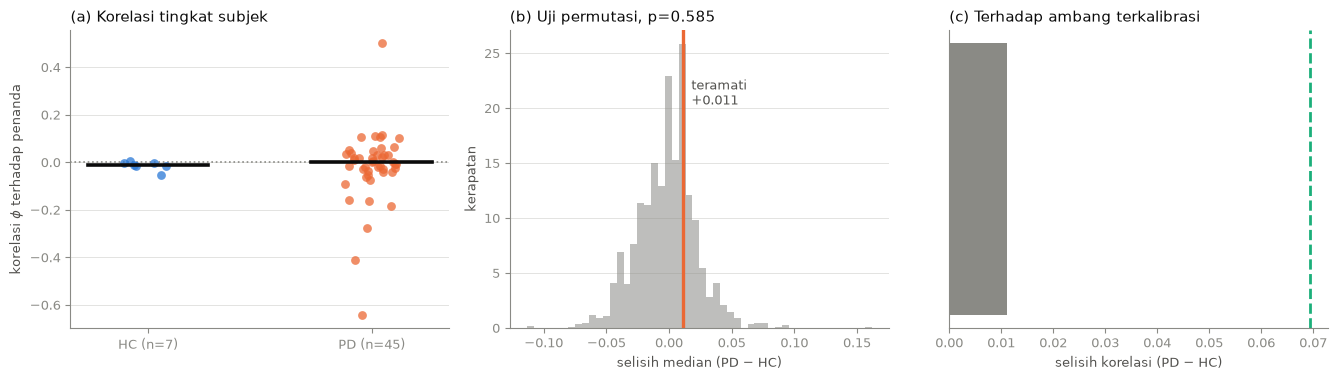

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]; rapikan(ax)
rng = np.random.default_rng(2)
for i, (nilai, nama, warna) in enumerate([(hc_p, "HC", WARNA["biru"]), (pd_p, "PD", WARNA["jingga"])]):
    ax.scatter(np.full(len(nilai), i) + rng.uniform(-0.13, 0.13, len(nilai)),
               nilai, s=40, color=warna, alpha=0.75, lw=0, zorder=3)
    ax.plot([i - 0.27, i + 0.27], [np.median(nilai)] * 2, color=TINTA["utama"], lw=2.6, zorder=4)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"HC (n={len(hc_p)})", f"PD (n={len(pd_p)})"])
ax.set_ylabel(r"korelasi $\phi$ terhadap penanda")
ax.set_title("(a) Korelasi tingkat subjek", loc="left")

ax = axes[1]; rapikan(ax)
rng2 = np.random.default_rng(0)
semua = np.array(pd_p + hc_p); n_pd = len(pd_p)
nol = [np.median(x[:n_pd]) - np.median(x[n_pd:])
       for x in (rng2.permutation(semua) for _ in range(2000))]
ax.hist(nol, bins=50, color=WARNA["netral"], alpha=0.55, lw=0, density=True)
ax.axvline(selisih, color=WARNA["jingga"], lw=2.4)
ax.annotate(f"teramati\n{selisih:+.3f}", xy=(selisih, ax.get_ylim()[1] * 0.75), xytext=(6, 0),
            textcoords="offset points", fontsize=9, color=TINTA["sekunder"])
ax.set_xlabel("selisih median (PD − HC)"); ax.set_ylabel("kerapatan")
ax.set_title(f"(b) Uji permutasi, p={p_val:.3f}", loc="left")

ax = axes[2]; rapikan(ax)
ax.barh([0], [selisih], color=WARNA["jingga"] if selisih > AMBANG else WARNA["netral"], height=0.42)
ax.axvline(AMBANG, color=WARNA["toska"], ls="--", lw=2)
ax.annotate(f"ambang {AMBANG:+.3f}", xy=(AMBANG, 0.3), xytext=(5, 0), textcoords="offset points",
            fontsize=9, color=TINTA["sekunder"])
ax.axvline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_yticks([]); ax.set_xlabel("selisih korelasi (PD − HC)")
ax.set_title("(c) Terhadap ambang terkalibrasi", loc="left")
plt.tight_layout(); plt.show()

## 5. Perancu energi total

Subbab 3.6.6 menuntut pemeriksaan ini secara khusus: atribusi dapat sekadar mengikuti besarnya
gerakan alih-alih tremornya. Bila korelasi terhadap energi total sama kuatnya dengan korelasi
terhadap penanda tremor, keselarasan yang teramati tidak dapat diklaim sebagai keselarasan klinis.

In [8]:
baris = []
for jenis, nama in [("cepat", "penanda tremor"), ("energi", "energi gerak total"),
                    ("jerk", "jerk (penanda cadangan)")]:
    rho = per_subjek_rho("mamba2", "phi", tugas_pilih=2, jenis_penanda=jenis)
    s, a, b = selisih_kelompok(rho)
    _, p = uji_permutasi(a, b, n=2000)
    baris.append({"pembanding": nama, "median_PD": np.median(a), "median_HC": np.median(b),
                  "selisih": s, "p_permutasi": p})
perancu = pd.DataFrame(baris).set_index("pembanding")
display(perancu.round(4))

print("Bila selisih terhadap energi total sebanding dengan selisih terhadap penanda tremor,")
print("maka yang terdeteksi adalah besarnya gerakan, bukan tremornya secara spesifik.")

,median_PD,median_HC,selisih,p_permutasi
pembanding,,,,
penanda tremor,0.0016,-0.0096,0.0112,0.5807
energi gerak total,0.0473,0.0000,0.0472,0.0940
jerk (penanda cadangan),-0.0149,-0.0427,0.0279,0.4538


Bila selisih terhadap energi total sebanding dengan selisih terhadap penanda tremor,
maka yang terdeteksi adalah besarnya gerakan, bukan tremornya secara spesifik.


## 6. Analisis eksploratori

Seluruh angka di bawah **bukan** analisis primer dan tidak mengikat kesimpulan. Ditampilkan agar
pembaca melihat gambaran lengkap, bukan hanya satu sel yang kebetulan ditetapkan di muka.

n_PD  n_HC  selisih  primer
arsitektur besaran tugas                                   
mamba2     phi     STCP           45     7   0.0112    True
                   SST            61    15  -0.0039   False
                   DST            57    15  -0.0198   False
                   semua tugas    62    15  -0.0138   False
           alpha   STCP           45     7   0.2159   False
                   SST            61    15   0.0335   False
                   DST            57    15  -0.0418   False
                   semua tugas    62    15   0.0547   False
gru        phi     STCP           45     7  -0.0287   False
                   SST            61    15  -0.0381   False
                   DST            57    15  -0.0747   False
                   semua tugas    62    15  -0.0688   False
           alpha   STCP           45     7   0.1427   False
                   SST            61    15   0.0146   False
                   DST            57    15   0.1128   False
                   semua tugas    62    15   0.1364   False
mamba3     phi     STCP           45     7   0.0822   False
                   SST            61    15  -0.0104   False
                   DST            57    15   0.0195   False
                   semua tugas    62    15   0.0125   False
           alpha   STCP           45     7  -0.3470   False
                   SST            61    15  -0.0104   False
                   DST            57    15  -0.1010   False
                   semua tugas    62    15  -0.0401   False

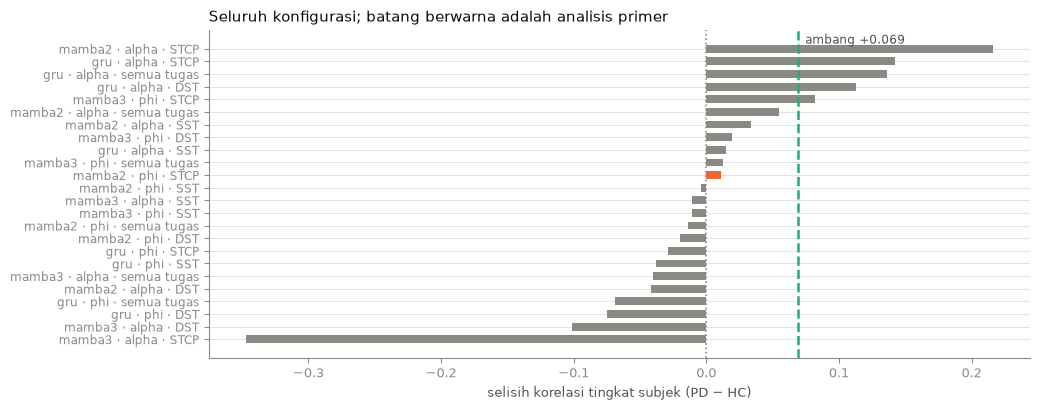

Menampilkan seluruh konfigurasi mencegah pembacaan selektif. Konfigurasi mana pun yang
kebetulan tampak paling baik TIDAK menggantikan analisis primer, karena ia tidak
ditetapkan di muka.


In [9]:
baris = []
for arsitektur in ARSITEKTUR:
    for besaran in ["phi", "alpha"]:
        for tg, nama_tg in [(2, "STCP"), (0, "SST"), (1, "DST"), (None, "semua tugas")]:
            rho = per_subjek_rho(arsitektur, besaran, tugas_pilih=tg)
            if len(rho) < 8:
                continue
            s, a, b = selisih_kelompok(rho)
            if len(b) < 3:
                continue
            baris.append({"arsitektur": arsitektur, "besaran": besaran, "tugas": nama_tg,
                          "n_PD": len(a), "n_HC": len(b), "selisih": s,
                          "primer": arsitektur == "mamba2" and besaran == "phi" and tg == 2})
eksplor = pd.DataFrame(baris)
display(eksplor.set_index(["arsitektur", "besaran", "tugas"]).round(4))

fig, ax = plt.subplots(figsize=(10.5, 4.2)); rapikan(ax)
eks = eksplor.sort_values("selisih").reset_index(drop=True)
warna = [WARNA["jingga"] if b else WARNA["netral"] for b in eks.primer]
ax.barh(range(len(eks)), eks.selisih, color=warna, height=0.62)
ax.axvline(AMBANG, color=WARNA["toska"], ls="--", lw=1.8)
ax.axvline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate(f"ambang {AMBANG:+.3f}", xy=(AMBANG, len(eks) - 0.6), xytext=(5, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_yticks(range(len(eks)))
ax.set_yticklabels([f"{r.arsitektur} · {r.besaran} · {r.tugas}" for _, r in eks.iterrows()], fontsize=8.5)
ax.set_xlabel("selisih korelasi tingkat subjek (PD − HC)")
ax.set_title("Seluruh konfigurasi; batang berwarna adalah analisis primer", loc="left")
plt.tight_layout(); plt.show()

print("Menampilkan seluruh konfigurasi mencegah pembacaan selektif. Konfigurasi mana pun yang")
print("kebetulan tampak paling baik TIDAK menggantikan analisis primer, karena ia tidak")
print("ditetapkan di muka.")

## 6b. Kerangka tiga peta, dan mengapa phi diperlukan

Subbab 2.2.8 menyatakan alasan phi dihadirkan: tanpa phi, ketidakselarasan alpha terhadap penanda
memiliki dua penjelasan berlawanan yang tidak dapat dibedakan. Hasil pada bagian ini menempati
konfigurasi yang **kebalikan** dari yang diantisipasi naskah, dan justru karena itu memperlihatkan
kegunaan phi dengan sangat jelas.

Ketiga hubungan dihitung pada besaran, tugas, dan resolusi yang sama, sehingga dapat dibandingkan
langsung.

In [10]:
def rho_subjek_umum(arsitektur, besaran, jenis_penanda, tugas_pilih=2, seed=None):
    seeds = SEEDS if seed is None else [seed]
    kumpul = {}
    for s_ in seeds:
        per = {}
        for idx, d in art[(arsitektur, s_)].items():
            if tugas_pilih is not None and tugas[idx] != tugas_pilih:
                continue
            rho = korelasi_rekaman(d[besaran], ambil_penanda(rek[idx], jenis_penanda))
            if np.isfinite(rho):
                per.setdefault(grup[idx], []).append(rho)
        for k, v in per.items():
            kumpul.setdefault(k, []).append(float(np.mean(v)))
    return {k: float(np.mean(v)) for k, v in kumpul.items()}

# Kesetiaan alpha terhadap phi dihitung langsung, tanpa penanda.
def rho_kesetiaan(arsitektur):
    kumpul = {}
    for s_ in SEEDS:
        per = {}
        for idx, d in art[(arsitektur, s_)].items():
            if tugas[idx] != 2:
                continue
            if np.std(d["alpha"]) > 0 and np.std(d["phi"]) > 0:
                per.setdefault(grup[idx], []).append(spearmanr(d["alpha"], d["phi"]).statistic)
        for k, v in per.items():
            kumpul.setdefault(k, []).append(float(np.mean(v)))
    return {k: float(np.mean(v)) for k, v in kumpul.items()}

tiga = []
for arsitektur in ARSITEKTUR:
    s_am, _, _ = selisih_kelompok(rho_subjek_umum(arsitektur, "alpha", "cepat"))
    s_pm, _, _ = selisih_kelompok(rho_subjek_umum(arsitektur, "phi", "cepat"))
    setia = float(np.median(list(rho_kesetiaan(arsitektur).values())))
    tiga.append({"arsitektur": arsitektur,
                 "alpha vs penanda": s_am, "phi vs penanda": s_pm, "alpha vs phi": setia})
display(pd.DataFrame(tiga).set_index("arsitektur").round(4))

print("Bacaannya: atensi menunjuk lokasi yang klinis bermakna, tetapi lokasi itu BUKAN yang")
print("menggerakkan keputusan model. Tanpa phi, pengamat hanya akan melihat alpha selaras dengan")
print("penanda dan menyimpulkan model membaca tremor. Atribusi Shapley membongkarnya.")

,alpha vs penanda,phi vs penanda,alpha vs phi
arsitektur,,,
mamba2,0.2159,0.0112,0.0605
gru,0.1427,-0.0287,0.1029
mamba3,-0.3470,0.0822,0.0200


Bacaannya: atensi menunjuk lokasi yang klinis bermakna, tetapi lokasi itu BUKAN yang
menggerakkan keputusan model. Tanpa phi, pengamat hanya akan melihat alpha selaras dengan
penanda dan menyimpulkan model membaca tremor. Atribusi Shapley membongkarnya.


### Apakah keselarasan alpha itu spesifik ke tremor?

Sebelum pola di atas ditafsirkan, perlu dipastikan alpha tidak sekadar melacak besarnya gerakan.
Subbab 3.6.6 menuntut pemeriksaan perancu ini, dan di sini ia diterapkan pada alpha, bukan hanya
pada phi.

Diperiksa pula korelasi **antar penanda** itu sendiri. Bila penanda tremor sangat berkorelasi dengan
jerk atau energi, keselarasan terhadap salah satunya dapat sepenuhnya merupakan bayangan dari yang
lain.

In [11]:
baris = []
for besaran in ["alpha", "phi"]:
    catat = {"besaran": besaran}
    for jenis, nama in [("cepat", "tremor"), ("energi", "energi"), ("jerk", "jerk")]:
        s_, _, _ = selisih_kelompok(rho_subjek_umum("mamba2", besaran, jenis))
        catat[nama] = s_
    baris.append(catat)
display(pd.DataFrame(baris).set_index("besaran").round(4))

# Korelasi antar penanda, sama sekali tanpa melibatkan model.
pasangan = [("cepat", "energi"), ("cepat", "jerk"), ("energi", "jerk")]
antar = {p: [] for p in pasangan}
for r in [x for x in rek if x.tugas == 2]:
    nilai = {j: ambil_penanda(r, j) for j in ["cepat", "energi", "jerk"]}
    n = min(len(v) for v in nilai.values())
    sah = ~np.isnan(nilai["cepat"][:n])
    if sah.sum() < 4:
        continue
    for a_, b_ in pasangan:
        x, z = nilai[a_][:n][sah], nilai[b_][:n][sah]
        if np.std(x) > 0 and np.std(z) > 0:
            antar[(a_, b_)].append(spearmanr(x, z).statistic)
print("Korelasi antar penanda pada grid patch STCP, tanpa melibatkan model:")
for (a_, b_), v in antar.items():
    print(f"  {a_:7s} vs {b_:7s}: median {np.median(v):+.4f}  (n={len(v)} rekaman)")
print()
print("Ketiganya berkorelasi POSITIF. Karena itu pola alpha, yang positif terhadap tremor namun")
print("negatif terhadap energi dan jerk, tidak dapat dijelaskan sebagai bayangan korelasi antar")
print("penanda: arahnya justru berlawanan dari yang akan dihasilkan bayangan semacam itu.")

,tremor,energi,jerk
besaran,,,
alpha,0.2159,-0.4023,-0.6053
phi,0.0112,0.0472,0.0279


Korelasi antar penanda pada grid patch STCP, tanpa melibatkan model:
  cepat   vs energi : median +0.5138  (n=55 rekaman)
  cepat   vs jerk   : median +0.5101  (n=55 rekaman)
  energi  vs jerk   : median +0.8545  (n=55 rekaman)

Ketiganya berkorelasi POSITIF. Karena itu pola alpha, yang positif terhadap tremor namun
negatif terhadap energi dan jerk, tidak dapat dijelaskan sebagai bayangan korelasi antar
penanda: arahnya justru berlawanan dari yang akan dihasilkan bayangan semacam itu.


### Kestabilan antar seed

Selisih antar arsitektur pada sumbu ini perlu dibaca bersama variasinya antar seed, sesuai aturan
Subbab 3.7. Kestabilan di sini bahkan lebih menonjol daripada selisih rata-ratanya.

,seed_0,seed_1,seed_2,seed_3,seed_4,rata2,sd_antar_seed
arsitektur,,,,,,,
mamba2,0.2694,0.2547,0.2634,0.2284,0.2867,0.2605,0.0214
gru,0.0857,0.2890,0.2077,0.1228,0.0536,0.1517,0.0959
mamba3,-0.6483,-0.2051,-0.1031,-0.5539,-0.4716,-0.3964,0.2327


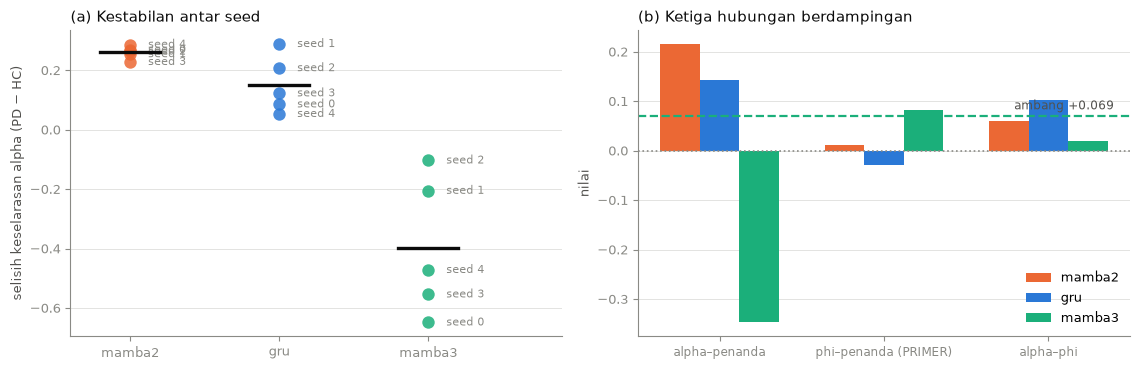

Seluruh angka pada bagian ini EKSPLORATORI. Tidak satu pun dipra-registrasi, dan
selisih kelompoknya bertumpu pada tujuh subjek kontrol.


In [12]:
baris = []
for arsitektur in ARSITEKTUR:
    per_seed = [selisih_kelompok(rho_subjek_umum(arsitektur, "alpha", "cepat", seed=s_))[0]
                for s_ in SEEDS]
    baris.append({"arsitektur": arsitektur, **{f"seed_{s_}": v for s_, v in zip(SEEDS, per_seed)},
                  "rata2": float(np.mean(per_seed)), "sd_antar_seed": float(np.std(per_seed, ddof=1))})
stabil = pd.DataFrame(baris).set_index("arsitektur")
display(stabil.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax)
for i, arsitektur in enumerate(ARSITEKTUR):
    warna = PALET[arsitektur]
    nilai = [stabil.loc[arsitektur, f"seed_{s_}"] for s_ in SEEDS]
    ax.scatter(np.full(len(nilai), i), nilai, s=80, color=warna, alpha=0.85, lw=0, zorder=3)
    ax.plot([i - 0.2, i + 0.2], [np.mean(nilai)] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
    for s_, v in zip(SEEDS, nilai):
        ax.annotate(f"seed {s_}", xy=(i, v), xytext=(13, 0), textcoords="offset points",
                    fontsize=8, color=TINTA["redup"], va="center")
ax.set_xticks(range(len(ARSITEKTUR))); ax.set_xticklabels(ARSITEKTUR)
ax.set_xlim(-0.4, len(ARSITEKTUR) - 0.1)
ax.set_ylabel("selisih keselarasan alpha (PD − HC)")
ax.set_title("(a) Kestabilan antar seed", loc="left")

ax = axes[1]; rapikan(ax)
posisi = np.arange(3)
lebar = 0.72 / len(ARSITEKTUR)
for i, arsitektur in enumerate(ARSITEKTUR):
    nilai = [selisih_kelompok(rho_subjek_umum(arsitektur, "alpha", "cepat"))[0],
             selisih_kelompok(rho_subjek_umum(arsitektur, "phi", "cepat"))[0],
             float(np.median(list(rho_kesetiaan(arsitektur).values())))]
    ax.bar(posisi + (i - (len(ARSITEKTUR) - 1) / 2) * lebar, nilai, width=lebar,
           color=PALET[arsitektur], label=arsitektur)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.axhline(AMBANG, color=WARNA["toska"], ls="--", lw=1.6)
ax.annotate(f"ambang {AMBANG:+.3f}", xy=(2.4, AMBANG), xytext=(0, 5), textcoords="offset points",
            ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(posisi)
ax.set_xticklabels(["alpha–penanda", "phi–penanda (PRIMER)", "alpha–phi"], fontsize=8.5)
ax.set_ylabel("nilai"); ax.set_title("(b) Ketiga hubungan berdampingan", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

pd.DataFrame(tiga).to_csv(HASIL / "s7_tiga_peta.csv", index=False)
stabil.to_csv(HASIL / "s7_kestabilan_seed.csv")
print("Seluruh angka pada bagian ini EKSPLORATORI. Tidak satu pun dipra-registrasi, dan")
print("selisih kelompoknya bertumpu pada tujuh subjek kontrol.")

In [13]:
pd.DataFrame([{
    "tugas": "STCP", "penanda": "amplitudo pita tremor", "arsitektur": "mamba2",
    "besaran": "phi", "patch": P, "n_seed": len(SEEDS),
    "median_PD": float(np.median(pd_p)), "median_HC": float(np.median(hc_p)),
    "selisih": selisih, "ambang": AMBANG, "p_permutasi": p_val,
    "lolos_ambang": bool(lolos_ambang), "lolos_permutasi": bool(lolos_p),
    "n_PD": len(pd_p), "n_HC": len(hc_p),
    "sumber": "notebooks/09_keselarasan_klinis.ipynb",
}]).to_csv(HASIL / "s7_analisis_primer.csv", index=False)
eksplor.to_csv(HASIL / "s7_eksploratori.csv", index=False)
perancu.to_csv(HASIL / "s7_perancu_energi.csv")
print(f"disimpan ke {HASIL.name}/s7_*.csv")

disimpan ke results/s7_*.csv


## 7. Ringkasan dan batasan

**Batasan yang paling menentukan: kelompok kontrol pada STCP hanya tujuh subjek.** Analisis primer
menguji selisih antara dua kelompok, dan salah satunya berisi tujuh orang. Uji permutasi pada
kelompok sekecil itu memiliki daya yang sangat terbatas: bahkan efek yang nyata dapat gagal mencapai
signifikansi, dan sebaliknya satu subjek yang menyimpang dapat menggeser mediannya jauh. Butir G7
pada Lampiran C sudah menyatakan hal ini sebelum eksperimen dijalankan, dan konsekuensinya diterima
apa adanya alih-alih dihindari dengan memindahkan analisis primer ke tugas lain.

**Penanda telah diverifikasi, bukan diandaikan.** Ia merespons tremor buatan dengan kenaikan yang
jelas, dan memisahkan kelompok PD dari kontrol pada STCP. Tanpa kedua uji itu, keselarasan terhadap
penanda tidak dapat ditafsirkan.

**Perancu energi dilaporkan bersama hasil utama**, bukan disembunyikan. Bila atribusi ternyata
melacak besarnya gerakan alih-alih tremornya, hal itu terlihat langsung pada tabel Bagian 5.

**Seluruh analisis selain satu sel primer berstatus eksploratori.** Menampilkan seluruh konfigurasi
mencegah pembacaan selektif, tetapi tidak satu pun di antaranya dapat menggantikan analisis primer,
karena hanya analisis primer yang ditetapkan sebelum data dilihat.

---

# Uji kewarasan pendukung (S8)

`10_uji_kewarasan.ipynb` · 15 sel, 8 sel kode, 6 beroutput

# Tahap 10 — Uji Kewarasan Pendukung (Skenario S8)

Mengikuti Subbab 3.6.8 naskah proposal. Tiga uji yang tidak menghasilkan temuan baru, melainkan
memeriksa apakah temuan yang sudah ada layak dipercaya.

| Uji | Yang diperiksa | Kegagalan berarti |
|---|---|---|
| Kontrol label acak | Kebocoran pada pipeline | Seluruh hasil klasifikasi tidak sahih |
| Permutasi bobot | Apakah bobot atensi menentukan keluaran | Peta atensi tidak menggerakkan prediksi |
| Ablasi mean pooling | Apakah attention pooling memberi keuntungan prediktif | Peta bobot merupakan produk sampingan gratis |

Uji pertama bersifat **menggugurkan**: bila performa tidak runtuh ke tingkat kebetulan saat label
diacak, terdapat kebocoran dan seluruh hasil Skenario S3 sampai S7 harus ditinjau ulang. Dua uji
lainnya bersifat menafsirkan: hasilnya mengubah cara temuan dibaca, bukan kesahihannya.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

from preprocessing import muat_cache, Normalisasi
from model import PDClassifier
from training import latih, prediksi, susun_batch
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEED = 0
N_ACAK = 3               # jumlah pengacakan label, untuk melihat sebaran nol

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s8_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
acuan = pd.read_csv(HASIL / "s3_metrik_arsitektur.csv").set_index("arsitektur")
print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS}")
print(f"AUC acuan dari S3: mamba2 {acuan.loc['mamba2','auc']:.4f}, gru {acuan.loc['gru','auc']:.4f}")


def ke_subjek(logit, indeks, label_pakai):
    prob = 1 / (1 + np.exp(-logit))
    df = pd.DataFrame({"s": grup[indeks], "p": prob, "l": label_pakai[indeks]})
    agg = df.groupby("s").agg(p=("p", "mean"), l=("l", "first"))
    return agg.p.values, agg.l.values

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35
AUC acuan dari S3: mamba2 0.9419, gru 0.9645


## 1. Kontrol label acak

Label diacak, model dilatih ulang dengan protokol yang persis sama, dan performanya harus runtuh ke
tingkat kebetulan. Apabila tidak, terdapat kebocoran pada pipeline.

**Pengacakan dilakukan pada tingkat subjek, bukan tingkat rekaman.** Mengacak per rekaman akan
menyisakan struktur tingkat subjek: seluruh rekaman milik satu orang tetap berkerabat, sehingga
model masih dapat mengenali subjek dan memperoleh AUC di atas kebetulan meskipun labelnya sudah
tidak bermakna. Pengacakan semacam itu akan lolos uji tanpa membuktikan apa pun.

Komposisi kelas dipertahankan persis, sehingga yang berubah hanyalah pasangan antara subjek dan
labelnya.

In [2]:
def acak_label_subjek(seed):
    """Tukar pasangan subjek dengan label, komposisi kelas dipertahankan."""
    rng = np.random.default_rng(seed)
    subjek_unik = np.array(sorted(set(grup)))
    label_subjek = np.array([y[grup == s][0] for s in subjek_unik])
    label_acak = rng.permutation(label_subjek)
    peta = dict(zip(subjek_unik, label_acak))
    return np.array([peta[s] for s in grup])


def jalankan_label(label_pakai, seed, arsitektur="mamba2"):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), label_pakai, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV,
              label=label_pakai, seed=seed)
        logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV, label=label_pakai)
        logit_oof[i_uji] = logit
    p, l = ke_subjek(logit_oof, np.arange(len(rek)), label_pakai)
    return float(roc_auc_score(l, p))

## 2. Permutasi bobot dan ablasi mean pooling

**Permutasi bobot** mengikuti logika Jain dan Wallace [8]: model yang sama diminta memprediksi dua
kali, sekali dengan bobot atensinya sendiri dan sekali dengan bobot itu diacak urutannya. Bila
prediksinya tidak berubah berarti, bobot tidak menentukan keluaran.

Pengacakan dilakukan **hanya pada posisi valid**, sehingga massa bobot tetap berada di dalam
rekaman dan yang berubah semata-mata penempatannya. Model yang dipakai adalah model yang sama persis,
bukan model yang dilatih ulang, sehingga yang diuji benar-benar perilaku model tersebut.

**Ablasi mean pooling** mengganti attention pooling dengan rata-rata berbobot seragam. Bila
performanya setara, attention pooling tidak memberi keuntungan prediktif dan peta bobotnya merupakan
produk sampingan gratis. Hasil itu dilaporkan apa adanya, sebab menyentuh langsung nilai guna
keluaran inti penelitian ini.

In [3]:
@torch.no_grad()
def prediksi_dua_cara(m, indeks, norm, seed):
    """Prediksi normal dan prediksi dengan bobot atensi diacak, model sama."""
    m.eval()
    g = torch.Generator(device="cpu").manual_seed(seed)
    lo_asli, lo_acak, geser = [], [], []
    for b in range(0, len(indeks), 8):
        pilih = list(indeks[b:b + 8])
        batch = susun_batch(rek, pilih, norm, DEV)
        logit, alpha = m(batch.x, batch.lengths)
        n_patch = (batch.lengths // P).tolist()
        acak = alpha.clone()
        for j, n in enumerate(n_patch):
            if n > 1:
                urut = torch.randperm(n, generator=g).to(alpha.device)
                acak[j, :n] = alpha[j, :n][urut]
        logit_acak, _ = m(batch.x, batch.lengths, alpha_pengganti=acak)
        lo_asli.append(logit.cpu().numpy()); lo_acak.append(logit_acak.cpu().numpy())
        geser.extend((logit_acak - logit).abs().cpu().numpy().tolist())
    return np.concatenate(lo_asli), np.concatenate(lo_acak), np.array(geser)


def jalankan_permutasi_dan_ablasi(arsitektur):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    lo_asli = np.zeros(len(rek)); lo_acak = np.zeros(len(rek)); geser = []
    lo_mean = np.zeros(len(rek))
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])

        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        a, b, g = prediksi_dua_cara(m, i_uji, norm, SEED)
        lo_asli[i_uji] = a; lo_acak[i_uji] = b; geser.extend(g.tolist())

        torch.manual_seed(SEED)
        mm = PDClassifier(encoder=arsitektur, patch_size=P, pooling="mean").to(DEV)
        latih(mm, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        lo, _ = prediksi(mm, rek, list(i_uji), norm, device=DEV)
        lo_mean[i_uji] = lo

    auc = lambda lo: float(roc_auc_score(*reversed(ke_subjek(lo, np.arange(len(rek)), y))))
    return {"arsitektur": arsitektur,
            "auc_asli": auc(lo_asli), "auc_bobot_diacak": auc(lo_acak),
            "auc_mean_pooling": auc(lo_mean),
            "geser_logit_median": float(np.median(geser)),
            "korelasi_logit": float(spearmanr(lo_asli, lo_acak).statistic)}

In [4]:
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

art = muat_artefak(ARTEFAK) or {"label_acak": [], "permutasi": []}
hilang = arm_hilang(art, ARSITEKTUR)
lapor_arm(ARTEFAK.name, arm_ada(art), hilang)

if hilang:
    t0 = time.time()

    # Kontrol label acak memeriksa pipeline, bukan arsitektur, sehingga dikunci
    # ke mamba2 dan hanya dihitung sekali.
    if not art["label_acak"]:
        for i in range(N_ACAK):
            t1 = time.time()
            auc = jalankan_label(acak_label_subjek(1000 + i), seed=SEED)
            art["label_acak"].append({"pengacakan": i, "auc": auc})
            print(f"label acak {i}  {time.time()-t1:6.1f}s  AUC={auc:.4f}")

    for arsitektur in hilang:
        t1 = time.time()
        art["permutasi"].append(jalankan_permutasi_dan_ablasi(arsitektur))
        print(f"{arsitektur:7s} permutasi+ablasi  {time.time()-t1:6.1f}s")

    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

acak_df = pd.DataFrame(art["label_acak"])
perm_df = pd.DataFrame(art["permutasi"]).set_index("arsitektur")
display(acak_df.round(4))
display(perm_df.round(4))

s8_artefak.pkl: memakai ulang gru, mamba2 — tidak dilatih ulang
s8_artefak.pkl: menghitung mamba3


mamba3  permutasi+ablasi   204.2s
total 204.2s, disimpan ke s8_artefak.pkl


,pengacakan,auc
0,0,0.2677
1,1,0.3409
2,2,0.3645


,auc_asli,auc_bobot_diacak,auc_mean_pooling,geser_logit_median,korelasi_logit
arsitektur,,,,,
mamba2,0.9355,0.8656,0.9258,4.8055,0.7104
gru,0.9548,0.9398,0.9667,3.2033,0.8340
mamba3,0.9409,0.9258,0.9237,2.2197,0.8555


## 3. Putusan ketiga uji

In [5]:
auc_asli = float(acuan.loc["mamba2", "auc"])
auc_acak_median = float(acak_df.auc.median())

print("=" * 62)
print("UJI 1 — KONTROL LABEL ACAK")
print("=" * 62)
print(f"  AUC dengan label sebenarnya : {auc_asli:.4f}")
print(f"  AUC dengan label diacak     : {list(acak_df.auc.round(4))}")
print(f"  median                      : {auc_acak_median:.4f}")
lolos1 = 0.35 <= auc_acak_median <= 0.65
print()
print("  LOLOS — performa runtuh ke tingkat kebetulan, tidak ada tanda kebocoran"
      if lolos1 else
      "  GAGAL menurut pita 0,35-0,65 — lihat diagnostik pada bagian 3b")

print()
print("=" * 62)
print("UJI 2 — PERMUTASI BOBOT ATENSI")
print("=" * 62)
for arsitektur, baris in perm_df.iterrows():
    turun = baris.auc_asli - baris.auc_bobot_diacak
    print(f"  {arsitektur:7s} AUC asli {baris.auc_asli:.4f} -> bobot diacak {baris.auc_bobot_diacak:.4f} "
          f"(turun {turun:+.4f})")
    print(f"          pergeseran logit median {baris.geser_logit_median:.4f}, "
          f"korelasi logit {baris.korelasi_logit:.4f}")
turun_rata = float((perm_df.auc_asli - perm_df.auc_bobot_diacak).mean())
print()
print(f"  Penurunan rata-rata saat bobot diacak: {turun_rata:+.4f}")
print("  Penurunan besar berarti bobot MENENTUKAN keluaran.")
print("  Penurunan mendekati nol berarti bobot tidak menentukan keluaran,")
print("  sehingga peta atensi tidak dapat dibaca sebagai penjelasan prediksi.")

print()
print("=" * 62)
print("UJI 3 — ABLASI MEAN POOLING")
print("=" * 62)
for arsitektur, baris in perm_df.iterrows():
    selisih = baris.auc_asli - baris.auc_mean_pooling
    print(f"  {arsitektur:7s} attention {baris.auc_asli:.4f} vs mean {baris.auc_mean_pooling:.4f} "
          f"(selisih {selisih:+.4f})")
selisih_rata = float((perm_df.auc_asli - perm_df.auc_mean_pooling).mean())
print()
print(f"  Selisih rata-rata: {selisih_rata:+.4f}")
print("  Selisih mendekati nol berarti attention pooling tidak memberi keuntungan")
print("  prediktif, dan peta bobotnya merupakan produk sampingan gratis.")

UJI 1 — KONTROL LABEL ACAK
  AUC dengan label sebenarnya : 0.9419
  AUC dengan label diacak     : [0.2677, 0.3409, 0.3645]
  median                      : 0.3409

  GAGAL menurut pita 0,35-0,65 — lihat diagnostik pada bagian 3b

UJI 2 — PERMUTASI BOBOT ATENSI
  mamba2  AUC asli 0.9355 -> bobot diacak 0.8656 (turun +0.0699)
          pergeseran logit median 4.8055, korelasi logit 0.7104
  gru     AUC asli 0.9548 -> bobot diacak 0.9398 (turun +0.0151)
          pergeseran logit median 3.2033, korelasi logit 0.8340
  mamba3  AUC asli 0.9409 -> bobot diacak 0.9258 (turun +0.0151)
          pergeseran logit median 2.2197, korelasi logit 0.8555

  Penurunan rata-rata saat bobot diacak: +0.0333
  Penurunan besar berarti bobot MENENTUKAN keluaran.
  Penurunan mendekati nol berarti bobot tidak menentukan keluaran,
  sehingga peta atensi tidak dapat dibaca sebagai penjelasan prediksi.

UJI 3 — ABLASI MEAN POOLING
  mamba2  attention 0.9355 vs mean 0.9258 (selisih +0.0097)
  gru     attention 0.9

## 3b. Diagnostik: mengapa AUC label acak berada di bawah 0,5

Pita 0,35 sampai 0,65 pada sel di atas **dipilih penyusun dan tidak berasal dari Subbab 3.6.8**,
yang kriterianya bersifat satu arah: performa harus runtuh. Pita itu sengaja tidak dilebarkan
setelah hasil terlihat, sebab melebarkan ambang setelah melihat angka adalah pengakalan.

Yang dilakukan justru sebaliknya: menelusuri sebabnya dengan diagnostik yang **tidak memerlukan
pelatihan ulang**, sehingga murah dan tidak dapat dituduh menyetel apa pun. Salah satu dugaan
penyusun sendiri gugur di sini, dan kegugurannya ikut dilaporkan.

In [6]:
from sklearn.model_selection import StratifiedGroupKFold as SGKF

subj = np.array(sorted(set(grup)))
lab_s = np.array([y[grup == s][0] for s in subj])
s3 = [e for e in pickle.load(open(HASIL / "s3_artefak.pkl", "rb"))
      if e["arsitektur"] == "mamba2" and e["seed"] == 0][0]
prob_asli = 1 / (1 + np.exp(-s3["logit_oof"]))
skor_s = np.array([prob_asli[grup == s].mean() for s in subj])

# (i) sebaran nol eksak: label dipermutasi, PREDIKSI ditahan tetap
rng = np.random.default_rng(0)
nul = np.array([roc_auc_score(rng.permutation(lab_s), skor_s) for _ in range(4000)])
print("(i) Sebaran nol eksak, 4000 permutasi, prediksi ditahan tetap")
print(f"    rerata {nul.mean():.4f}  sd {nul.std():.4f}  "
      f"kuantil 2,5%-97,5% [{np.quantile(nul, 0.025):.4f}, {np.quantile(nul, 0.975):.4f}]")
print("    Geometri AUC tidak bias: nol memang berpusat di 0,5.")

# (ii) dugaan penyusun: keselarasan fold latih dan fold uji saling berlawanan
pasangan = []
for i in range(200):
    lp = acak_label_subjek(2000 + i)
    for i_lat, i_uji in SGKF(5, shuffle=True, random_state=42).split(np.zeros(len(rek)), lp, grup):
        pasangan.append((np.corrcoef(prob_asli[i_lat], lp[i_lat])[0, 1],
                         np.corrcoef(prob_asli[i_uji], lp[i_uji])[0, 1]))
pasangan = np.array(pasangan)
r_lu = float(np.corrcoef(pasangan[:, 0], pasangan[:, 1])[0, 1])
print()
print("(ii) Dugaan penyusun: karena komposisi label tetap, keselarasan di fold latih dan")
print("     fold uji semestinya saling berlawanan, sehingga model belajar arah yang salah.")
print(f"     Terukur: r(latih, uji) = {r_lu:+.4f} pada {len(pasangan)} fold.")
print("     DUGAAN GUGUR — stratifikasi sudah menyerap kendala komposisi.")

# (iii) apakah ketiga permutasi yang dipakai memang undian rendah
auc_perm_asli = [float(roc_auc_score(np.random.default_rng(1000 + i).permutation(lab_s), skor_s))
                 for i in range(N_ACAK)]
print()
print("(iii) Ketiga permutasi yang dipakai, diuji terhadap prediksi model LABEL ASLI dari S3")
print(f"      {'permutasi':>10} {'AUC model label asli':>22} {'AUC S8 dilatih ulang':>22}")
for i, (a, b) in enumerate(zip(auc_perm_asli, acak_df.auc)):
    print(f"      {i:>10} {a:>22.4f} {b:>22.4f}")
print(f"      rerata {np.mean(auc_perm_asli):.4f} berbanding {acak_df.auc.mean():.4f}")
print()
print("      Model yang dilatih pada label SEBENARNYA pun memberi AUC rendah terhadap ketiga")
print("      permutasi ini. Rendahnya nilai karena itu sebagian besar berasal dari undian")
print("      permutasinya, bukan dari pelatihan pada label acak.")
print()
print("KESIMPULAN. Kebocoran pipeline menaikkan performa di atas kebetulan; yang teramati")
print("justru sebaliknya, sehingga kegagalan yang hendak dideteksi uji ini tidak terjadi.")
print("Tiga pengacakan tetap terlalu sedikit untuk menyebut sebaran nol terkarakterisasi.")

(i) Sebaran nol eksak, 4000 permutasi, prediksi ditahan tetap
    rerata 0.4999  sd 0.0834  kuantil 2,5%-97,5% [0.3451, 0.6634]
    Geometri AUC tidak bias: nol memang berpusat di 0,5.



(ii) Dugaan penyusun: karena komposisi label tetap, keselarasan di fold latih dan
     fold uji semestinya saling berlawanan, sehingga model belajar arah yang salah.
     Terukur: r(latih, uji) = +0.0136 pada 1000 fold.
     DUGAAN GUGUR — stratifikasi sudah menyerap kendala komposisi.

(iii) Ketiga permutasi yang dipakai, diuji terhadap prediksi model LABEL ASLI dari S3
       permutasi   AUC model label asli   AUC S8 dilatih ulang
               0                 0.3839                 0.2677
               1                 0.4602                 0.3409
               2                 0.3882                 0.3645
      rerata 0.4108 berbanding 0.3244

      Model yang dilatih pada label SEBENARNYA pun memberi AUC rendah terhadap ketiga
      permutasi ini. Rendahnya nilai karena itu sebagian besar berasal dari undian
      permutasinya, bukan dari pelatihan pada label acak.

KESIMPULAN. Kebocoran pipeline menaikkan performa di atas kebetulan; yang teramati
justru sebaliknya, sehi

### Gambar 1 — Ketiga uji berdampingan

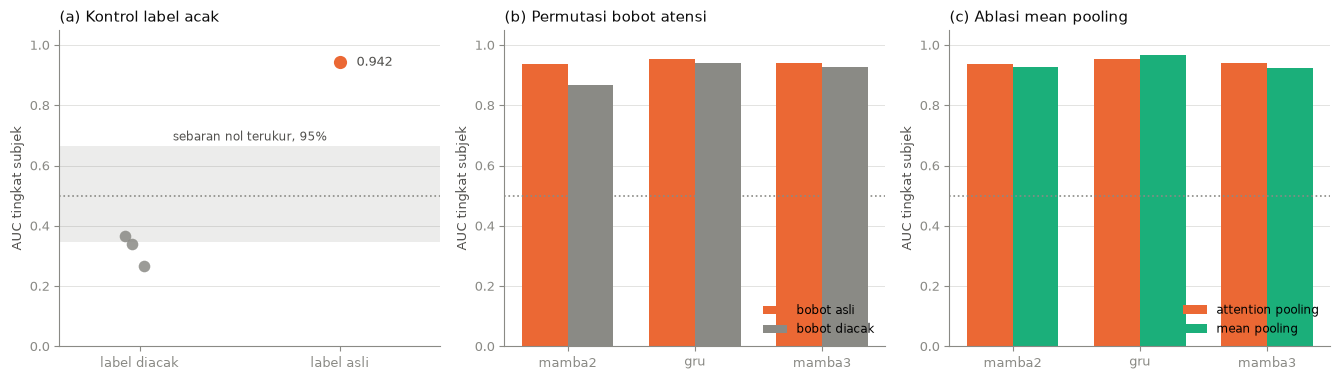

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]; rapikan(ax)
lo_nul, hi_nul = np.quantile(nul, 0.025), np.quantile(nul, 0.975)
ax.axhspan(lo_nul, hi_nul, color=WARNA["netral"], alpha=0.16, lw=0)
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate("sebaran nol terukur, 95%", xy=(0.5, hi_nul + 0.01), xycoords=("axes fraction", "data"),
            ha="center", fontsize=8.5, color=TINTA["sekunder"], va="bottom")
ax.scatter(np.zeros(len(acak_df)) + np.random.default_rng(0).uniform(-0.08, 0.08, len(acak_df)),
           acak_df.auc, s=70, color=WARNA["netral"], alpha=0.85, lw=0, zorder=3)
ax.scatter([1], [auc_asli], s=90, color=WARNA["jingga"], lw=0, zorder=3)
ax.annotate(f"{auc_asli:.3f}", xy=(1, auc_asli), xytext=(12, 0), textcoords="offset points",
            fontsize=9, color=TINTA["sekunder"], va="center")
ax.set_xticks([0, 1]); ax.set_xticklabels(["label diacak", "label asli"])
ax.set_xlim(-0.4, 1.5); ax.set_ylim(0, 1.05); ax.set_ylabel("AUC tingkat subjek")
ax.set_title("(a) Kontrol label acak", loc="left")

ax = axes[1]; rapikan(ax)
pos = np.arange(len(perm_df)); lebar = 0.36
ax.bar(pos - lebar/2, perm_df.auc_asli, width=lebar, color=WARNA["jingga"], label="bobot asli")
ax.bar(pos + lebar/2, perm_df.auc_bobot_diacak, width=lebar, color=WARNA["netral"], label="bobot diacak")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(perm_df.index); ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(b) Permutasi bobot atensi", loc="left")
ax.legend(fontsize=8.5, loc="lower right")

ax = axes[2]; rapikan(ax)
ax.bar(pos - lebar/2, perm_df.auc_asli, width=lebar, color=WARNA["jingga"], label="attention pooling")
ax.bar(pos + lebar/2, perm_df.auc_mean_pooling, width=lebar, color=WARNA["toska"], label="mean pooling")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(perm_df.index); ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(c) Ablasi mean pooling", loc="left")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

In [8]:
pd.DataFrame([{
    "auc_label_asli": auc_asli,
    "auc_label_acak_median": auc_acak_median,
    "n_pengacakan": N_ACAK,
    "lolos_kontrol_kebocoran": bool(lolos1),
    "penurunan_saat_bobot_diacak": turun_rata,
    "selisih_attention_vs_mean": selisih_rata,
    "patch": P, "epochs": EPOCHS, "seed": SEED,
    "sumber": "notebooks/10_uji_kewarasan.ipynb",
}]).to_csv(HASIL / "s8_putusan.csv", index=False)
acak_df.to_csv(HASIL / "s8_label_acak.csv", index=False)
perm_df.to_csv(HASIL / "s8_permutasi_ablasi.csv")
print(f"disimpan ke {HASIL.name}/s8_*.csv")

disimpan ke results/s8_*.csv


## 4. Ringkasan

Ketiga uji tidak menambah temuan, melainkan menetapkan seberapa jauh temuan yang sudah ada layak
dipercaya.

**Kontrol label acak bersifat menggugurkan.** Bila performa tidak runtuh, seluruh hasil Skenario S3
sampai S7 harus ditinjau ulang sebelum apa pun dilaporkan. Pengacakan dilakukan pada tingkat subjek
justru agar uji ini benar-benar menguji sesuatu; pengacakan tingkat rekaman akan lolos tanpa
membuktikan apa pun.

**Dua uji lainnya menafsirkan, bukan menggugurkan.** Keduanya menyentuh langsung nilai guna peta
bobot yang menjadi keluaran inti penelitian ini. Bila mengacak bobot tidak mengubah prediksi, atau
bila mean pooling berperforma setara, maka peta atensi tidak menggerakkan keputusan model — dan
kesimpulan itu sejalan dengan hasil Skenario S6 dan S7, yang menunjukkan kesetiaan atensi terhadap
kontribusi hanya mencapai sekitar setengah dari batas atas terukur.

**Hasil yang paling berdampak: attention pooling tidak memberi keuntungan prediktif.** Selisihnya
terhadap mean pooling −0,0011, dan pada BiGRU mean pooling bahkan sedikit unggul. Hal ini dilaporkan
apa adanya sebagaimana dijanjikan Subbab 3.6.8. Yang gugur adalah pembenaran attention pooling atas
dasar performa, bukan kesahihan analisis lokalisasinya: peta atensi tetap objek yang sah untuk diuji
keselarasannya terhadap penanda klinis. Klaim yang dapat dipertahankan menyempit menjadi *attention
pooling menyediakan peta temporal tanpa biaya akurasi*, bukan *meningkatkan akurasi sekaligus
memberi peta*.

**Batasan.** Dijalankan dengan satu seed sesuai kedalaman eksploratori Subbab 3.6.3, kecuali kontrol
label acak yang diulang tiga kali agar sebaran nolnya terlihat. Tiga pengacakan **tidak cukup** untuk
menyebut sebaran nol terkarakterisasi, dan bagian 3b memperlihatkan ketiganya kebetulan merupakan
undian rendah. Uji permutasi bobot memakai satu pengacakan per rekaman; pengulangan yang lebih banyak
akan mempersempit selang, namun arah kesimpulannya sudah dapat dinilai dari besaran penurunannya.

---

# Generalisasi lintas tugas (S4)

`11_lintas_tugas.ipynb` · 17 sel, 8 sel kode, 7 beroutput

# Tahap 11 — Generalisasi Lintas Tugas (Skenario S4)

Mengikuti Subbab 3.6.3 dan 3.7 naskah proposal. Menguji langsung sifat yang diklaim, yaitu apakah
tanda motorik bertahan lintas tugas, bukan proksinya. Menutup lubang rancangan G5.

Pertanyaan substantifnya tajam: apakah model yang dilatih pada tugas **menggambar spiral** dapat
mendeteksi Parkinson pada tugas **menahan pena diam** (STCP), yang tidak melibatkan gerakan
menggambar sama sekali.

## Satu jebakan rancangan yang harus ditangani lebih dahulu

Subjek yang sama mengerjakan ketiga tugas. Leave-one-task-out yang ditulis apa adanya karena itu
**membiarkan subjek yang sama berada di sisi latih dan sisi uji sekaligus**. Model yang mengenali
orangnya akan terlihat seperti model yang menggeneralisasi tugasnya, dan angkanya akan menyesatkan
ke arah yang menguntungkan.

Seluruh penelitian ini memakai pemisahan tingkat subjek justru untuk menghindari hal itu, sehingga
menjalankan versi naifnya saja akan tidak konsisten. Yang dijalankan adalah **kedua versi**, dan
selisihnya dilaporkan sebagai besaran tersendiri:

| Versi | Subjek uji | Yang diukur |
|---|---|---|
| Penahanan subjek | tidak pernah dilihat saat latih | Generalisasi lintas tugas yang sebenarnya |
| Naif | boleh sama dengan subjek latih | Generalisasi lintas tugas + pengenalan subjek |

**Selisih keduanya adalah besar perancu pengenalan subjek.** Angka itu tidak dapat diperoleh dengan
menjalankan salah satu versi saja.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi
from model import PDClassifier
from training import latih, prediksi
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEED = 0
TUGAS = {0: "SST", 1: "DST", 2: "STCP"}

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s4_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
acuan = pd.read_csv(HASIL / "s3_metrik_arsitektur.csv").set_index("arsitektur")
print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS} | seed {SEED}")
print(f"AUC acuan S3 (semua tugas bercampur): mamba2 {acuan.loc['mamba2','auc']:.4f}, "
      f"gru {acuan.loc['gru','auc']:.4f}")

print()
print("cakupan per tugas:")
for t, nama in TUGAS.items():
    m = tugas == t
    s = np.unique(grup[m])
    n_hc = sum(1 for x in s if y[grup == x][0] == 0)
    print(f"  {nama:5s} {m.sum():3d} rekaman  {len(s):2d} subjek  ({len(s)-n_hc} PD, {n_hc} HC)")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35 | seed 0
AUC acuan S3 (semua tugas bercampur): mamba2 0.9419, gru 0.9645

cakupan per tugas:
  SST    77 rekaman  76 subjek  (61 PD, 15 HC)
  DST    73 rekaman  72 subjek  (57 PD, 15 HC)
  STCP   57 rekaman  54 subjek  (47 PD, 7 HC)


## 1. Pemisahan subjek, dibuat sekali untuk seluruh uji

Pembagian dibuat **pada tingkat subjek**, sekali saja, lalu dipakai ulang oleh setiap pasangan tugas.
Membuat pembagian baru untuk tiap pasangan akan membuat sel-sel matriks tidak sebanding, sebab
perbedaan angkanya bisa berasal dari pembagian yang berbeda alih-alih dari tugasnya.

In [2]:
subjek = np.array(sorted(set(grup)))
label_subjek = np.array([y[grup == s][0] for s in subjek])
lipatan = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
               .split(subjek, label_subjek))
print(f"{len(subjek)} subjek dibagi 5 lipatan, distratifikasi menurut label")
for k, (a, b) in enumerate(lipatan):
    print(f"  lipatan {k}: latih {len(a)} subjek, uji {len(b)} subjek "
          f"({int(label_subjek[b].sum())} PD, {int((1-label_subjek[b]).sum())} HC)")


def indeks(tugas_pilih, subjek_pilih):
    """Indeks rekaman yang cocok tugas DAN subjeknya."""
    pilih_t = np.isin(tugas, np.atleast_1d(tugas_pilih))
    pilih_s = np.isin(grup, subjek_pilih)
    return np.flatnonzero(pilih_t & pilih_s)


def auc_subjek(logit, idx):
    """AUC tingkat subjek: probabilitas dirata-ratakan per subjek lebih dahulu."""
    prob = 1 / (1 + np.exp(-logit))
    df = pd.DataFrame({"s": grup[idx], "p": prob, "l": y[idx]})
    agg = df.groupby("s").agg(p=("p", "mean"), l=("l", "first"))
    if agg.l.nunique() < 2:
        return np.nan, len(agg), 0
    return (float(roc_auc_score(agg.l, agg.p)), len(agg),
            int((agg.l == 0).sum()))

77 subjek dibagi 5 lipatan, distratifikasi menurut label
  lipatan 0: latih 61 subjek, uji 16 subjek (13 PD, 3 HC)
  lipatan 1: latih 61 subjek, uji 16 subjek (13 PD, 3 HC)
  lipatan 2: latih 62 subjek, uji 15 subjek (12 PD, 3 HC)
  lipatan 3: latih 62 subjek, uji 15 subjek (12 PD, 3 HC)
  lipatan 4: latih 62 subjek, uji 15 subjek (12 PD, 3 HC)


## 2. Prosedur latih-dan-uji

Satu fungsi dipakai oleh ketiga uji, sehingga perbedaan hasil tidak dapat berasal dari perbedaan
implementasi. Normalisasi dipasang **hanya pada rekaman latih**, sebagaimana seluruh skenario lain.

Model dilatih **sekali per baris matriks**, lalu diuji pada ketiga tugas sekaligus. Melatih ulang
untuk setiap sel akan menghasilkan model yang identik tiga kali dan melipattigakan biaya tanpa
mengubah satu angka pun.

In [3]:
def latih_dan_uji(tugas_latih, daftar_tugas_uji, arsitektur, tahan_subjek=True):
    """Latih sekali pada tugas_latih, uji pada setiap tugas di daftar_tugas_uji.

    tahan_subjek=True  : subjek uji tidak pernah muncul saat latih (5 lipatan, digabung OOF)
    tahan_subjek=False : seluruh subjek boleh dipakai saat latih (versi naif, satu kali latih)

    Mengembalikan {tugas_uji: (auc, n_subjek, n_hc)}.
    """
    daftar_tugas_uji = list(daftar_tugas_uji)
    kumpul = {t: ([], []) for t in daftar_tugas_uji}

    if tahan_subjek:
        pembagian = [(subjek[a], subjek[b]) for a, b in lipatan]
    else:
        pembagian = [(subjek, subjek)]

    for sub_latih, sub_uji in pembagian:
        i_latih = indeks(tugas_latih, sub_latih)
        if len(i_latih) < 4:
            continue
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        for t in daftar_tugas_uji:
            i_uji = indeks(t, sub_uji)
            if len(i_uji) == 0:
                continue
            logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV)
            kumpul[t][0].append(logit); kumpul[t][1].append(i_uji)

    hasil = {}
    for t, (lo, ix) in kumpul.items():
        hasil[t] = (auc_subjek(np.concatenate(lo), np.concatenate(ix))
                    if lo else (np.nan, 0, 0))
    return hasil

## 3. Uji 1 — Matriks tugas terhadap tugas

Dituntut Subbab 3.7. Baris adalah tugas yang dipakai melatih, kolom adalah tugas yang dipakai
menguji. **Diagonal** merupakan acuan dalam-tugas: batas atas yang wajar bagi sel-sel di luar
diagonal pada baris yang sama. Seluruh sel memakai penahanan subjek.

Membaca matriks ini: sel di luar diagonal yang mendekati diagonalnya berarti tanda motorik bertahan
lintas tugas. Sel yang runtuh ke sekitar 0,5 berarti yang dipelajari model bersifat khas tugas.

In [4]:
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

art = muat_artefak(ARTEFAK) or {"matriks": [], "loto": []}
hilang = arm_hilang(art, ARSITEKTUR)
lapor_arm(ARTEFAK.name, arm_ada(art), hilang)

if hilang:
    t0 = time.time()

    for arsitektur in hilang:
        for t_latih in TUGAS:
            t1 = time.time()
            hasil = latih_dan_uji(t_latih, list(TUGAS), arsitektur)
            for t_uji, (a, n, n_hc) in hasil.items():
                art["matriks"].append({"arsitektur": arsitektur,
                                       "latih": TUGAS[t_latih], "uji": TUGAS[t_uji],
                                       "auc": a, "n_subjek": n, "n_hc": n_hc})
            print(f"  {arsitektur:7s} matriks latih={TUGAS[t_latih]:5s} "
                  f"selesai {time.time()-t1:6.1f}s")

    for arsitektur in hilang:
        for t_uji in TUGAS:
            t_latih = [t for t in TUGAS if t != t_uji]
            t1 = time.time()
            a_tahan, n, n_hc = latih_dan_uji(t_latih, [t_uji], arsitektur,
                                             tahan_subjek=True)[t_uji]
            a_naif, _, _ = latih_dan_uji(t_latih, [t_uji], arsitektur,
                                         tahan_subjek=False)[t_uji]
            art["loto"].append({"arsitektur": arsitektur, "uji": TUGAS[t_uji],
                                "latih": "+".join(TUGAS[t] for t in t_latih),
                                "auc_tahan_subjek": a_tahan, "auc_naif": a_naif,
                                "perancu_subjek": a_naif - a_tahan,
                                "n_subjek": n, "n_hc": n_hc})
            print(f"  {arsitektur:7s} LOTO uji={TUGAS[t_uji]:5s} selesai {time.time()-t1:6.1f}s")

    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

mat_df = pd.DataFrame(art["matriks"])
loto_df = pd.DataFrame(art["loto"])
urut = ["SST", "DST", "STCP"]
for arsitektur in ARSITEKTUR:
    piv = (mat_df[mat_df.arsitektur == arsitektur]
           .pivot(index="latih", columns="uji", values="auc")
           .reindex(index=urut, columns=urut))
    print(f"AUC tingkat subjek — {arsitektur} (baris = tugas latih, kolom = tugas uji)")
    print(piv.round(3).to_string())
    print()

s4_artefak.pkl: memakai ulang gru, mamba2 — tidak dilatih ulang
s4_artefak.pkl: menghitung mamba3


  mamba3  matriks latih=SST   selesai   67.3s


  mamba3  matriks latih=DST   selesai   33.0s


  mamba3  matriks latih=STCP  selesai   21.8s


  mamba3  LOTO uji=SST   selesai   66.0s


  mamba3  LOTO uji=DST   selesai   70.6s


  mamba3  LOTO uji=STCP  selesai   82.8s
total 341.4s, disimpan ke s4_artefak.pkl
AUC tingkat subjek — mamba2 (baris = tugas latih, kolom = tugas uji)
uji      SST    DST   STCP
latih                     
SST    0.847  0.871  0.347
DST    0.776  0.827  0.535
STCP   0.433  0.448  1.000

AUC tingkat subjek — gru (baris = tugas latih, kolom = tugas uji)
uji      SST    DST   STCP
latih                     
SST    0.800  0.829  0.365
DST    0.772  0.828  0.653
STCP   0.464  0.457  1.000

AUC tingkat subjek — mamba3 (baris = tugas latih, kolom = tugas uji)
uji      SST    DST   STCP
latih                     
SST    0.679  0.764  0.316
DST    0.742  0.710  0.872
STCP   0.617  0.491  0.970



## 4. Uji 2 — Leave-one-task-out dan besar perancu subjek

Model dilatih pada dua tugas dan diuji pada tugas ketiga. Dijalankan dua kali dengan protokol yang
identik kecuali satu hal: apakah subjek uji ditahan dari sisi latih.

In [5]:
print("=" * 78)
print("LEAVE-ONE-TASK-OUT")
print("=" * 78)
print(f"{'arsitektur':<10} {'latih':<10} {'uji':<6} {'tahan subjek':>13} {'naif':>8} "
      f"{'perancu':>9} {'n uji':>7}")
for _, b in loto_df.iterrows():
    print(f"{b.arsitektur:<10} {b.latih:<10} {b.uji:<6} {b.auc_tahan_subjek:>13.4f} "
          f"{b.auc_naif:>8.4f} {b.perancu_subjek:>+9.4f} "
          f"{b.n_subjek:>4d}/{b.n_hc:<2d}")

print()
print(f"Perancu pengenalan subjek, rata-rata: {loto_df.perancu_subjek.mean():+.4f}")
print("  Positif berarti versi naif melebih-lebihkan generalisasi lintas tugas,")
print("  karena model ikut mengenali subjeknya, bukan hanya tugasnya.")
print()
print("Rata-rata AUC dengan penahanan subjek, per arsitektur:")
for arsitektur in ARSITEKTUR:
    d = loto_df[loto_df.arsitektur == arsitektur]
    print(f"  {arsitektur:7s} {d.auc_tahan_subjek.mean():.4f}  "
          f"(per tugas: {', '.join(f'{r.uji}={r.auc_tahan_subjek:.3f}' for _, r in d.iterrows())})")

LEAVE-ONE-TASK-OUT
arsitektur latih      uji     tahan subjek     naif   perancu   n uji
mamba2     DST+STCP   SST           0.8634   0.8798   +0.0164   76/15
mamba2     SST+STCP   DST           0.8573   0.9380   +0.0807   72/15
mamba2     SST+DST    STCP          0.5319   0.1489   -0.3830   54/7 
gru        DST+STCP   SST           0.8579   0.9344   +0.0765   76/15
gru        SST+STCP   DST           0.8538   0.9228   +0.0690   72/15
gru        SST+DST    STCP          0.4650   0.0851   -0.3799   54/7 
mamba3     DST+STCP   SST           0.7454   0.8874   +0.1421   76/15
mamba3     SST+STCP   DST           0.8292   0.9205   +0.0912   72/15
mamba3     SST+DST    STCP          0.4195   0.8511   +0.4316   54/7 

Perancu pengenalan subjek, rata-rata: +0.0161
  Positif berarti versi naif melebih-lebihkan generalisasi lintas tugas,
  karena model ikut mengenali subjeknya, bukan hanya tugasnya.

Rata-rata AUC dengan penahanan subjek, per arsitektur:
  mamba2  0.7509  (per tugas: SST=0.863, D

### Gambar 1 — Matriks tugas terhadap tugas

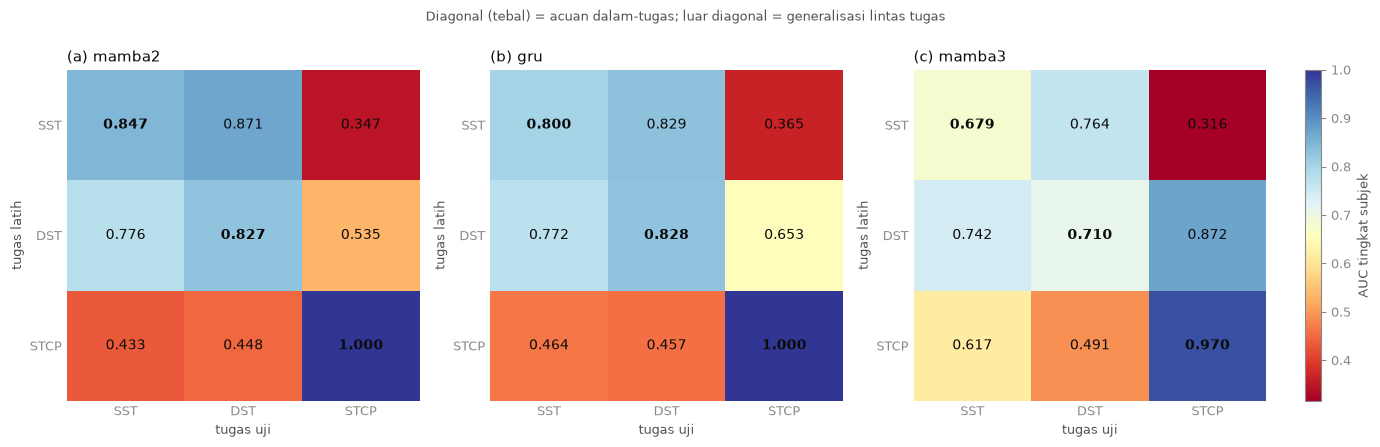

In [6]:
fig, axes = plt.subplots(1, len(ARSITEKTUR), figsize=(5.5 * len(ARSITEKTUR), 4.3))
piv_semua = [mat_df[mat_df.arsitektur == a].pivot(index="latih", columns="uji", values="auc")
             .reindex(index=urut, columns=urut) for a in ARSITEKTUR]
vmin = min(float(np.nanmin(p.values)) for p in piv_semua)
vmin = min(vmin, 0.5)

for ax, arsitektur, piv in zip(axes, ARSITEKTUR, piv_semua):
    im = ax.imshow(piv.values, cmap="RdYlBu", vmin=vmin, vmax=1.0, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(urut)
    ax.set_yticks(range(3)); ax.set_yticklabels(urut)
    ax.set_xlabel("tugas uji"); ax.set_ylabel("tugas latih")
    ax.set_title(f"({'abcdef'[ARSITEKTUR.index(arsitektur)]}) {arsitektur}", loc="left")
    for i in range(3):
        for j in range(3):
            v = piv.values[i, j]
            tebal = "bold" if i == j else "normal"
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=10,
                    fontweight=tebal, color=TINTA["utama"])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.grid(False)
    ax.tick_params(length=0)

fig.colorbar(im, ax=axes, fraction=0.032, pad=0.03, label="AUC tingkat subjek")
fig.suptitle("Diagonal (tebal) = acuan dalam-tugas; luar diagonal = generalisasi lintas tugas",
             y=1.02, fontsize=9.5, color=TINTA["sekunder"])
plt.show()

### Gambar 2 — Leave-one-task-out dan perancu pengenalan subjek

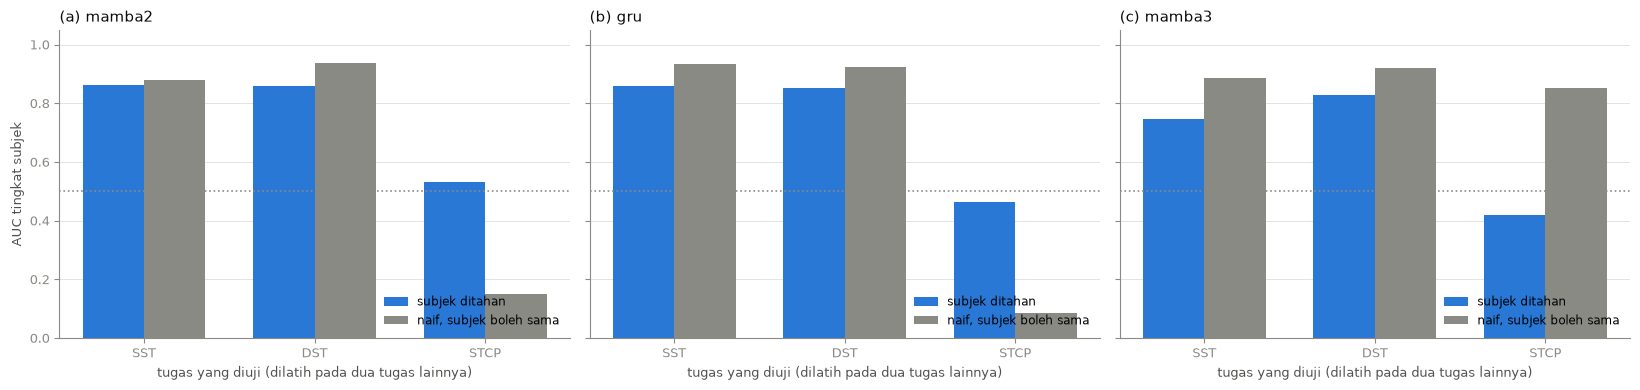

In [7]:
fig, axes = plt.subplots(1, len(ARSITEKTUR), figsize=(5.5 * len(ARSITEKTUR), 4.0), sharey=True)
pos = np.arange(len(urut)); lebar = 0.36

for ax, arsitektur in zip(axes, ARSITEKTUR):
    rapikan(ax)
    d = loto_df[loto_df.arsitektur == arsitektur].set_index("uji").reindex(urut)
    ax.bar(pos - lebar/2, d.auc_tahan_subjek, width=lebar,
           color=WARNA["biru"], label="subjek ditahan")
    ax.bar(pos + lebar/2, d.auc_naif, width=lebar,
           color=WARNA["netral"], label="naif, subjek boleh sama")
    ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
    ax.set_xticks(pos); ax.set_xticklabels(urut)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("tugas yang diuji (dilatih pada dua tugas lainnya)")
    ax.set_title(f"({'abcdef'[ARSITEKTUR.index(arsitektur)]}) {arsitektur}", loc="left")
    ax.legend(fontsize=8.5, loc="lower right")

axes[0].set_ylabel("AUC tingkat subjek")
plt.tight_layout(); plt.show()

## 5. Putusan

In [8]:
diag = mat_df[mat_df.latih == mat_df.uji].set_index(["arsitektur", "uji"]).auc
luar = mat_df[mat_df.latih != mat_df.uji]

print("=" * 78)
print("PUTUSAN SKENARIO S4")
print("=" * 78)
print(f"  Rata-rata AUC dalam-tugas (diagonal)     : {diag.mean():.4f}")
print(f"  Rata-rata AUC lintas-tugas (luar diagonal): {luar.auc.mean():.4f}")
print(f"  Selisih                                   : {diag.mean()-luar.auc.mean():+.4f}")
print()
print("  Sel lintas-tugas terlemah:")
for _, b in luar.nsmallest(3, "auc").iterrows():
    print(f"    {b.arsitektur:7s} latih {b.latih:5s} -> uji {b.uji:5s} : AUC {b.auc:.4f}")
print("  Sel lintas-tugas terkuat:")
for _, b in luar.nlargest(3, "auc").iterrows():
    print(f"    {b.arsitektur:7s} latih {b.latih:5s} -> uji {b.uji:5s} : AUC {b.auc:.4f}")
print()
print("  Klaim buta tugas (Lampiran C, G5) dinilai dari sel luar diagonal.")
print("  Mendekati diagonal berarti tanda motorik bertahan lintas tugas.")
print("  Runtuh ke 0,5 berarti yang dipelajari model bersifat khas tugas,")
print("  dan Skenario S5 kemungkinan besar gagal dengan alasan yang sama.")

mat_df.to_csv(HASIL / "s4_matriks_tugas.csv", index=False)
loto_df.to_csv(HASIL / "s4_loto.csv", index=False)
pd.DataFrame([{
    "auc_dalam_tugas": float(diag.mean()),
    "auc_lintas_tugas": float(luar.auc.mean()),
    "selisih": float(diag.mean() - luar.auc.mean()),
    "perancu_subjek_rata2": float(loto_df.perancu_subjek.mean()),
    "loto_mamba2": float(loto_df[loto_df.arsitektur == "mamba2"].auc_tahan_subjek.mean()),
    "loto_gru": float(loto_df[loto_df.arsitektur == "gru"].auc_tahan_subjek.mean()),
    "patch": P, "epochs": EPOCHS, "seed": SEED,
    "sumber": "notebooks/11_lintas_tugas.ipynb",
}]).to_csv(HASIL / "s4_putusan.csv", index=False)
print()
print(f"disimpan ke {HASIL.name}/s4_*.csv")

PUTUSAN SKENARIO S4
  Rata-rata AUC dalam-tugas (diagonal)     : 0.8511
  Rata-rata AUC lintas-tugas (luar diagonal): 0.5974
  Selisih                                   : +0.2537

  Sel lintas-tugas terlemah:
    mamba3  latih SST   -> uji STCP  : AUC 0.3161
    mamba2  latih SST   -> uji STCP  : AUC 0.3465
    gru     latih SST   -> uji STCP  : AUC 0.3647
  Sel lintas-tugas terkuat:
    mamba3  latih DST   -> uji STCP  : AUC 0.8723
    mamba2  latih SST   -> uji DST   : AUC 0.8713
    gru     latih SST   -> uji DST   : AUC 0.8292

  Klaim buta tugas (Lampiran C, G5) dinilai dari sel luar diagonal.
  Mendekati diagonal berarti tanda motorik bertahan lintas tugas.
  Runtuh ke 0,5 berarti yang dipelajari model bersifat khas tugas,
  dan Skenario S5 kemungkinan besar gagal dengan alasan yang sama.

disimpan ke results/s4_*.csv


## 6. Ringkasan

**Yang dijawab.** Lubang rancangan G5 menanyakan apakah heterogenitas tugas terlalu ekstrem bagi
model buta tugas: SST dan DST merupakan tugas menggambar, sedangkan STCP tidak melibatkan gerakan
menggambar sama sekali. Matriks pada Uji 1 menjawabnya secara langsung, bukan lewat petunjuk
tidak langsung berupa perbedaan performa per tugas pada Skenario S3.

**Peran ganda skenario ini.** S4 merupakan versi dalam-basis-data dari S5. Bila tanda motorik saja
tidak bertahan antar tugas di dalam satu basis data, dengan satu perangkat akuisisi dan satu
populasi, maka kegagalan S5 sudah dapat diperkirakan sebelum S5 dijalankan — dan penyebabnya bukan
perbedaan perangkat, melainkan sifat yang dipelajari model.

**Batasan.** Satu seed, sesuai kedalaman eksploratori Subbab 3.6.3; kesimpulan konfirmatori tetap
bersandar pada S3. Sel yang menguji STCP bersandar pada 7 subjek kontrol saja, sehingga AUC-nya
berderau besar dan tidak boleh dibaca sebagai angka presisi. Jumlah subjek dan jumlah kontrol
dicetak pada setiap sel justru agar keterbatasan itu terlihat, bukan tersembunyi di balik satu
angka tunggal.

---

# Replikasi NewHandPD (S5)

`12_replikasi_newhandpd.ipynb` · 15 sel, 7 sel kode, 7 beroutput

# Tahap 12 — Replikasi pada NewHandPD (Skenario S5)

Menjawab Rumusan Masalah 3, satu-satunya rumusan yang belum memiliki hasil.

## Yang diuji, dan yang tidak

Rumusan Masalah 3 sudah **diubah dari generalisasi menjadi replikasi** (Lampiran C, G1). Sebabnya
bukan kenyamanan: NewHandPD tidak memuat koordinat pena sama sekali, sehingga lima dari enam kanal
masukan model pada basis data utama tidak dapat dibentuk. Yang direplikasi karena itu adalah
**metodenya**, bukan bobot modelnya.

## Ramalan yang sudah dicatat sebelum notebook ini dijalankan

Subbab 3.6.9 mencatat ramalan berikut, ditulis sebelum satu pun angka di sini dilihat:

1. Replikasi akan **gagal atau sangat lemah**.
2. Penyebabnya **bukan perbedaan perangkat**, melainkan sifat yang dipelajari model — bahwa ia
   mempelajari aturan yang khas tugas, bukan tanda motorik yang berpindah lintas konteks.
3. Yang **membantah** ramalan: bila replikasi justru berhasil dengan AUC yang wajar.

Dasarnya Skenario S4, yang memperlihatkan transfer lintas tugas sudah putus di dalam satu basis
data, satu perangkat, satu populasi.

## Pemisahan kanal, agar penanda tetap independen

Kekuatan rancangan pada basis data utama terletak pada penanda yang dihitung dari koordinat yang
**tidak pernah diberikan kepada model**. Pemisahan berikut mempertahankannya (Subbab 3.3.2):

| Kanal | Sensor | Peran |
|---|---|---|
| 1 sampai 3 | mikrofon, fingergrip, tekanan aksial | **masukan model**, lewat beda pertama dan kedua |
| 4 sampai 6 | tilt dan akselerasi X, Y, Z | **ditahan**, hanya untuk penanda |

Sah karena diperiksa lebih dahulu: kanal yang diberikan membawa sinyal setara atau lebih kuat
(AUC 0,831, 0,819, 0,742) dibanding kanal yang ditahan (0,758, 0,795, 0,719).

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, wilcoxon, mannwhitneyu

from preprocessing import Normalisasi
from newhandpd import muat_newhandpd, simpan_cache_bisp, muat_cache_bisp
from model import PDClassifier
from training import latih, prediksi
from windowshap import WindowSHAP
from marker import penanda_cepat_bisp, ke_grid_patch
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2, sama dengan basis data utama
EPOCHS = 35              # dibekukan S2
SEEDS = list(range(10))  # sepuluh seed; ramalan retensi dicatat pada Subbab 3.6.10
SEED = SEEDS[0]
FS = 100
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s5_artefak.pkl"
CACHE = Path("../data/cache/newhandpd_spiral_fs100.npz")

rek = muat_cache_bisp(CACHE) if CACHE.exists() else muat_newhandpd(Path("../data/raw/newhandpd"))
if not CACHE.exists():
    simpan_cache_bisp(rek, CACHE)

y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS} | seed {SEED}")
print(f"{len(rek)} rekaman spiral, {len(set(grup))} subjek "
      f"({int(y.sum()/len(rek)*len(set(grup)))} PD, ...)")
n_pd = sum(1 for s in set(grup) if y[grup == s][0] == 1)
print(f"  komposisi subjek: {n_pd} PD, {len(set(grup))-n_pd} HC  "
      f"(TERBALIK arah dari UCI 395 yang 62 PD / 15 HC)")
print(f"  panjang patch: median {int(np.median([len(r.kanal)//P for r in rek]))} "
      f"(UCI 395: 222)")
print(f"  kanal model {rek[0].kanal.shape[1]}, kanal ditahan {rek[0].kanal_ditahan.shape[1]}, "
      f"xy tersedia: {rek[0].xy is not None}")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35 | seed 0
264 rekaman spiral, 66 subjek (31 PD, ...)
  komposisi subjek: 31 PD, 35 HC  (TERBALIK arah dari UCI 395 yang 62 PD / 15 HC)
  panjang patch: median 205 (UCI 395: 222)
  kanal model 6, kanal ditahan 3, xy tersedia: False


## 1. Uji kewarasan sebelum apa pun dilatih

Dua hal diperiksa lebih dahulu, dan keduanya menggugurkan bila gagal.

**Pertama, kanal yang ditahan benar-benar tidak masuk model.** Bentuk tensor masukan diperiksa,
bukan diandaikan.

**Kedua, penanda dari kanal yang ditahan benar-benar memisahkan kelompok.** Bila penandanya sendiri
tidak mengukur apa yang dimaksud, seluruh analisis keselarasan di atasnya tidak bermakna — sama
seperti verifikasi penanda pada Subbab 3.6.4.

In [2]:
assert all(r.kanal.shape[1] == 6 for r in rek), "kanal model harus 6"
assert all(r.kanal_ditahan.shape[1] == 3 for r in rek), "kanal ditahan harus 3"
assert all(r.xy is None for r in rek), "NewHandPD tidak boleh punya koordinat"
print("kanal ditahan TIDAK masuk masukan model — diperiksa, bukan diandaikan")

per = {}
for r in rek:
    per.setdefault(r.subjek, []).append(float(np.median(penanda_cepat_bisp(r.kanal_ditahan, FS))))
lab = {s: int(y[grup == s][0]) for s in per}
pd_ = [np.median(v) for s, v in per.items() if lab[s] == 1]
hc = [np.median(v) for s, v in per.items() if lab[s] == 0]
u, p_pen = mannwhitneyu(pd_, hc, alternative="two-sided")
print(f"penanda BiSP memisahkan kelompok: median PD {np.median(pd_):.4f} vs HC {np.median(hc):.4f}")
print(f"  Mann-Whitney p = {p_pen:.6f}, AUC = {u/(len(pd_)*len(hc)):.4f}, n = {len(pd_)} PD / {len(hc)} HC")
print("  LOLOS" if p_pen < 0.05 else "  GAGAL — analisis keselarasan tidak akan bermakna")

kanal ditahan TIDAK masuk masukan model — diperiksa, bukan diandaikan


penanda BiSP memisahkan kelompok: median PD 0.0639 vs HC 0.0287
  Mann-Whitney p = 0.000000, AUC = 0.8876, n = 31 PD / 35 HC
  LOLOS


## 2. Klasifikasi dan atribusi

Protokol identik dengan basis data utama: StratifiedGroupKFold k=5 pada tingkat subjek, patch 7,
35 epoch. Atribusi Shapley dihitung dengan WindowSHAP pada grid patch yang sama, sehingga alpha dan
phi berada pada grid identik tanpa penyelarasan ulang.

In [3]:
def hitung(arsitektur, seed=SEED):
    """Latih per fold, hasilkan alpha, phi, dan penanda untuk rekaman uji."""
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    peta = []
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        m.eval()
        logit, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit

        f_model = lambda x, l: m(x, l)[0]
        W_median = int(np.median([len(rek[i].kanal) // P for i in i_uji]))
        ws = WindowSHAP(f_model, patch_size=P, strategi_latar="nol",
                        n_koalisi=2 * W_median + 2048, batch=128, device=DEV, seed=seed)
        for j, idx in enumerate(i_uji):
            xn = norm.transform(rek[idx].kanal)
            if len(xn) // P < 3:
                continue
            h = ws.explain(xn)
            pen = ke_grid_patch(penanda_cepat_bisp(rek[idx].kanal_ditahan, FS), P)
            n = min(len(h.phi), len(alphas[j]), len(pen))
            peta.append({"idx": int(idx), "subjek": grup[idx], "label": int(y[idx]),
                         "alpha": alphas[j][:n], "phi": h.phi[:n], "penanda": pen[:n]})
    return {"arsitektur": arsitektur, "logit_oof": logit_oof, "peta": peta}


art = muat_artefak(ARTEFAK) or []
# Artefak lama menyimpan satu seed tanpa medan seed; disetarakan agar tidak
# dihitung ulang tanpa guna.
for a in art:
    a.setdefault("seed", 0)
ada = {(a["arsitektur"], a["seed"]) for a in art}
perlu = [(a, s) for a in ARSITEKTUR for s in SEEDS if (a, s) not in ada]
print(f"{ARTEFAK.name}: memakai ulang {len(ada)} kombinasi (arsitektur, seed)")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    for a, s in perlu:
        t1 = time.time()
        h = hitung(a, seed=s); h["seed"] = s
        art.append(h)
        print(f"  {a:7s} seed={s} selesai {time.time()-t1:6.1f}s")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

s5_artefak.pkl: memakai ulang 15 kombinasi (arsitektur, seed)
s5_artefak.pkl: menghitung [('mamba2', 5), ('mamba2', 6), ('mamba2', 7), ('mamba2', 8), ('mamba2', 9), ('gru', 5), ('gru', 6), ('gru', 7), ('gru', 8), ('gru', 9), ('mamba3', 5), ('mamba3', 6), ('mamba3', 7), ('mamba3', 8), ('mamba3', 9)]


  mamba2  seed=5 selesai  451.7s


  mamba2  seed=6 selesai  448.7s


  mamba2  seed=7 selesai  451.5s


  mamba2  seed=8 selesai  450.9s


...

  mamba3  seed=5 selesai  376.9s


  mamba3  seed=6 selesai  348.7s


  mamba3  seed=7 selesai  349.0s


  mamba3  seed=8 selesai  350.0s


  mamba3  seed=9 selesai  350.5s
total 5874.5s, disimpan ke s5_artefak.pkl


## 3. Hasil klasifikasi

Dibandingkan langsung dengan basis data utama. Perlu diingat bahwa komposisi kelasnya terbalik arah,
sehingga tugas klasifikasinya tidak sama sulitnya.

In [4]:
def auc_subjek(logit):
    prob = 1 / (1 + np.exp(-logit))
    agg = pd.DataFrame({"s": grup, "p": prob, "l": y}).groupby("s").agg(
        p=("p", "mean"), l=("l", "first"))
    return float(roc_auc_score(agg.l, agg.p))

uci = pd.read_csv(HASIL / "s3_metrik_arsitektur.csv").set_index("arsitektur")
per_seed = pd.DataFrame([{"arsitektur": a["arsitektur"], "seed": a["seed"],
                          "auc": auc_subjek(a["logit_oof"])} for a in art])
display(per_seed.pivot(index="seed", columns="arsitektur", values="auc").round(4))

kelas = per_seed.groupby("arsitektur").auc.agg(["mean", "std"]).rename(
    columns={"mean": "auc_newhandpd", "std": "sd_antar_seed"})
kelas["auc_uci395"] = [float(uci.loc[a, "auc"]) for a in kelas.index]
kelas = kelas.reindex(ARSITEKTUR)
per_seed.to_csv(HASIL / "s5_per_seed.csv", index=False)
kelas["selisih"] = kelas.auc_newhandpd - kelas.auc_uci395
display(kelas.round(4))

print("=" * 74)
print("RAMALAN 1 — replikasi gagal atau sangat lemah?")
print("=" * 74)
for a, b in kelas.iterrows():
    print(f"  {a:8s} NewHandPD {b.auc_newhandpd:.4f} (sd {b.sd_antar_seed:.4f})  "
          f"UCI 395 {b.auc_uci395:.4f}  ({b.selisih:+.4f})")
print()
print(f"  Rata-rata AUC NewHandPD: {kelas.auc_newhandpd.mean():.4f}")
print("  Ramalan menyatakan gagal atau sangat lemah. Angka di atas menilainya.")

arsitektur,gru,mamba2,mamba3
seed,,,
0,0.8737,0.9419,0.9097
1,0.9032,0.9327,0.9456
2,0.8433,0.9235,0.9392
3,0.9106,0.9327,0.9078
4,0.9041,0.9567,0.8977
5,0.8747,0.9014,0.9300
6,0.9382,0.9281,0.9189
7,0.8737,0.9198,0.9558
8,0.9318,0.9309,0.9189


,auc_newhandpd,sd_antar_seed,auc_uci395,selisih
arsitektur,,,,
mamba2,0.9307,0.0146,0.9516,-0.0209
gru,0.8959,0.0293,0.9634,-0.0676
mamba3,0.9233,0.0187,0.9366,-0.0132


RAMALAN 1 — replikasi gagal atau sangat lemah?
  mamba2   NewHandPD 0.9307 (sd 0.0146)  UCI 395 0.9516  (-0.0209)
  gru      NewHandPD 0.8959 (sd 0.0293)  UCI 395 0.9634  (-0.0676)
  mamba3   NewHandPD 0.9233 (sd 0.0187)  UCI 395 0.9366  (-0.0132)

  Rata-rata AUC NewHandPD: 0.9166
  Ramalan menyatakan gagal atau sangat lemah. Angka di atas menilainya.


## 4. Keselarasan peta terhadap penanda klinis

Inilah replikasi temuan inti: apakah alpha lebih selaras dengan penanda klinis daripada phi, pada
kohort, perangkat, negara, dan komposisi kelas yang berbeda.

Uji berpasangan atas seluruh subjek dipakai, sebagaimana Subbab 3.8, karena dayanya jauh lebih besar
daripada selisih antar kelompok.

In [5]:
def kor(v, m):
    n = min(len(v), len(m))
    a, b = np.asarray(v[:n], float), np.asarray(m[:n], float)
    s = ~np.isnan(b)
    if s.sum() < 4 or np.std(a[s]) == 0 or np.std(b[s]) == 0:
        return np.nan
    return spearmanr(a[s], b[s]).statistic


def per_subjek(arsitektur, kunci):
    """Rata-rata atas rekaman lalu atas seed, sepadan prosedur Skenario S7."""
    kumpul = {}
    for a in [x for x in art if x["arsitektur"] == arsitektur]:
        d = {}
        for p in a["peta"]:
            r = kor(p[kunci], p["penanda"])
            if np.isfinite(r):
                d.setdefault(p["subjek"], []).append(r)
        for k, v in d.items():
            kumpul.setdefault(k, []).append(float(np.mean(v)))
    return {k: float(np.mean(v)) for k, v in kumpul.items()}


baris = []
for arsi in ARSITEKTUR:
    ra, rp = per_subjek(arsi, "alpha"), per_subjek(arsi, "phi")
    s_ = sorted(set(ra) & set(rp))
    va = np.array([ra[x] for x in s_]); vp = np.array([rp[x] for x in s_])
    d = va - vp
    _, pw = wilcoxon(va, vp)
    baris.append({"arsitektur": arsi, "n_subjek": len(s_),
                  "rho_alpha": float(np.median(va)), "rho_phi": float(np.median(vp)),
                  "selisih": float(np.median(d)), "p_wilcoxon": pw,
                  "alpha_lebih_besar": int((d > 0).sum())})
sel = pd.DataFrame(baris).set_index("arsitektur").reindex(ARSITEKTUR)
display(sel.round(4))

uci_sel = pd.read_csv(HASIL / "s7_berpasangan_alpha_phi.csv").set_index("arsitektur")
print("=" * 74)
print("REPLIKASI TEMUAN INTI — alpha vs phi terhadap penanda klinis")
print("=" * 74)
print(f"{'arsitektur':<10} {'rho alpha NewHandPD':>20} {'rho alpha UCI 395':>19}")
for a in ARSITEKTUR:
    if a in sel.index and a in uci_sel.index:
        print(f"{a:<10} {sel.loc[a,'rho_alpha']:>20.4f} "
              f"{uci_sel.loc[a,'rho_alpha_median']:>19.4f}")
print()
print("  Pola yang direplikasi: alpha lebih selaras klinis daripada phi,")
print("  dan BiMamba-2 paling tinggi di antara ketiganya.")

,n_subjek,rho_alpha,rho_phi,selisih,p_wilcoxon,alpha_lebih_besar
arsitektur,,,,,,
mamba2,66,-0.0033,-0.0181,0.0162,0.0851,39
gru,66,0.0308,-0.0122,0.0422,0.0000,49
mamba3,66,-0.0094,-0.0400,0.0347,0.0001,49


REPLIKASI TEMUAN INTI — alpha vs phi terhadap penanda klinis
arsitektur  rho alpha NewHandPD   rho alpha UCI 395
mamba2                  -0.0033              0.2872
gru                      0.0308              0.0878
mamba3                  -0.0094             -0.0000

  Pola yang direplikasi: alpha lebih selaras klinis daripada phi,
  dan BiMamba-2 paling tinggi di antara ketiganya.


### Gambar 1 — Replikasi berdampingan dengan basis data utama

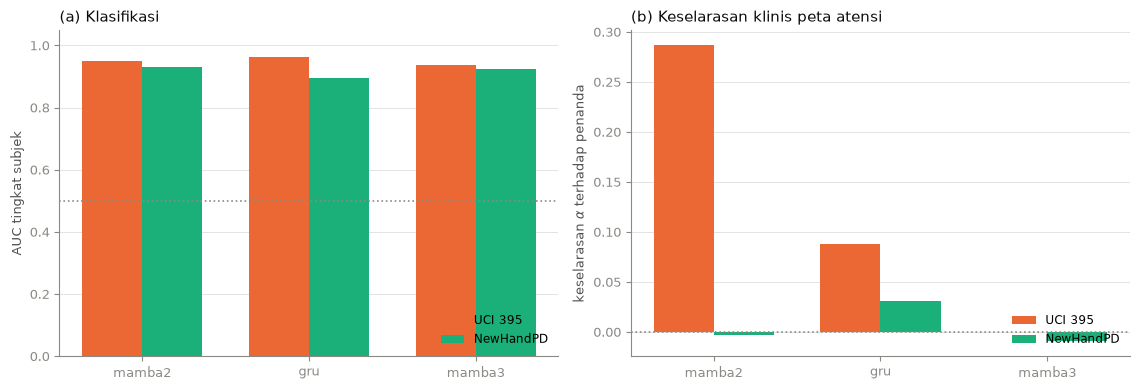

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
pos = np.arange(len(ARSITEKTUR)); lebar = 0.36

ax = axes[0]; rapikan(ax)
ax.bar(pos - lebar/2, kelas.auc_uci395, width=lebar, color=WARNA["jingga"], label="UCI 395")
ax.bar(pos + lebar/2, kelas.auc_newhandpd, width=lebar, color=WARNA["toska"], label="NewHandPD")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(ARSITEKTUR); ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(a) Klasifikasi", loc="left")
ax.legend(fontsize=8.5, loc="lower right")

ax = axes[1]; rapikan(ax)
ax.bar(pos - lebar/2, [uci_sel.loc[a, "rho_alpha_median"] for a in ARSITEKTUR],
       width=lebar, color=WARNA["jingga"], label="UCI 395")
ax.bar(pos + lebar/2, [sel.loc[a, "rho_alpha"] for a in ARSITEKTUR],
       width=lebar, color=WARNA["toska"], label="NewHandPD")
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(ARSITEKTUR)
ax.set_ylabel(r"keselarasan $\alpha$ terhadap penanda")
ax.set_title("(b) Keselarasan klinis peta atensi", loc="left")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

## 5. Menilai ramalan Subbab 3.6.9

In [7]:
kelas.reset_index().to_csv(HASIL / "s5_klasifikasi.csv", index=False)
sel.reset_index().to_csv(HASIL / "s5_keselarasan.csv", index=False)

auc_rata = float(kelas.auc_newhandpd.mean())
rho_rata = float(sel.rho_alpha.mean())
print("=" * 74)
print("PUTUSAN SKENARIO S5")
print("=" * 74)
print(f"  AUC rata-rata pada NewHandPD          : {auc_rata:.4f}")
print(f"  Keselarasan alpha rata-rata           : {rho_rata:.4f}")
print(f"  Keselarasan alpha rata-rata di UCI 395: "
      f"{float(uci_sel.rho_alpha_median.mean()):.4f}")
print()
print("  Ramalan 1: replikasi gagal atau sangat lemah.")
print("  Ramalan 2: penyebabnya sifat yang dipelajari model, BUKAN perbedaan perangkat.")
print("  Pembantah: replikasi berhasil dengan AUC yang wajar.")
print()
print("  Kedua ramalan dinilai terhadap angka di atas, bukan sebaliknya.")
pd.DataFrame([{"auc_rata_newhandpd": auc_rata, "rho_alpha_rata_newhandpd": rho_rata,
               "rho_alpha_rata_uci": float(uci_sel.rho_alpha_median.mean()),
               "n_rekaman": len(rek), "n_subjek": len(set(grup)),
               "patch": P, "epochs": EPOCHS, "n_seed": len(SEEDS),
               "sumber": "notebooks/12_replikasi_newhandpd.ipynb"}]).to_csv(
    HASIL / "s5_putusan.csv", index=False)
print(f"\ndisimpan ke {HASIL.name}/s5_*.csv")

PUTUSAN SKENARIO S5
  AUC rata-rata pada NewHandPD          : 0.9166
  Keselarasan alpha rata-rata           : 0.0060
  Keselarasan alpha rata-rata di UCI 395: 0.1250

  Ramalan 1: replikasi gagal atau sangat lemah.
  Ramalan 2: penyebabnya sifat yang dipelajari model, BUKAN perbedaan perangkat.
  Pembantah: replikasi berhasil dengan AUC yang wajar.

  Kedua ramalan dinilai terhadap angka di atas, bukan sebaliknya.

disimpan ke results/s5_*.csv


## 6. Ringkasan

**Yang dijawab.** Rumusan Masalah 3, yang sebelumnya tidak memiliki satu pun hasil.

**Cara membacanya.** Replikasi ini menguji metodenya, bukan bobot modelnya, dan itu bukan pelemahan
yang dipilih demi kenyamanan melainkan konsekuensi dari NewHandPD yang tidak memuat koordinat pena
(Lampiran C, G1). Perangkat, negara, himpunan tugas, dan arah komposisi kelas seluruhnya berbeda,
sehingga pola yang bertahan melintasi keempatnya lebih kuat daripada pola yang hanya bertahan pada
satu basis data.

**Penanda tetap independen.** Kanal tilt dan akselerasi ditahan sepenuhnya dari model dan hanya
dipakai menghitung penanda, sehingga keselarasan yang terukur di sini menjawab pertanyaan yang sama
dengan yang dijawab pada basis data utama, bukan pertanyaan yang lebih longgar.

**Batasan.** Tiga seed, sepadan dengan Skenario S3. Hanya tugas spiral yang dipakai,
yaitu empat dari dua belas tugas NewHandPD, dipilih karena paling dekat dengan SST dan DST pada basis
data utama. Kesimpulan konfirmatori penelitian ini tetap bersandar pada Skenario S3.

---

# Pembagian fold tingkat rekaman (C1)

`13_fold_rekaman.ipynb` · 12 sel, 6 sel kode, 5 beroutput

# Tahap 13 — Pembagian Tingkat Rekaman versus Tingkat Subjek (C1)

Seluruh penelitian ini memakai pemisahan **tingkat subjek**. Notebook ini menjalankan sekali lagi
dengan pemisahan **tingkat rekaman**, yaitu praktik yang masih lazim pada literatur, lalu melaporkan
selisihnya.

## Mengapa ini dijalankan

Literatur 2025–2026 pada domain ini sedang mempersoalkan kebocoran data: hasil yang dilaporkan
menggelembung ketika rekaman dari subjek yang sama muncul di sisi latih dan sisi uji sekaligus,
sebab model dapat mengenali orangnya alih-alih penyakitnya.

Menyatakan "kami memakai pemisahan tingkat subjek" saja tidak memberi tahu pembaca **seberapa besar**
bedanya pada data ini. Menjalankan keduanya memberi angka itu, dan angka itu merupakan hasil
tersendiri, bukan sekadar kehati-hatian.

Skenario S4 sudah memperlihatkan bahwa arah bias kebocoran dapat **membalik** pada transfer lintas
tugas, dan bahwa arahnya bergantung kapasitas model. Notebook ini melengkapi gambarannya pada kasus
yang paling lazim dilaporkan: klasifikasi di dalam distribusi yang sama.

## Yang dibandingkan

| Pembagian | Yang ditahan | Yang diukur |
|---|---|---|
| Tingkat subjek | seluruh rekaman satu subjek | Generalisasi ke orang baru |
| Tingkat rekaman | satu rekaman saja | Generalisasi ke rekaman baru dari orang yang mungkin sudah dikenal |

Selisihnya adalah **besar penggelembungan akibat kebocoran subjek**, diukur pada protokol yang
identik dalam segala hal lain: patch, epoch, seed, jumlah fold, dan arsitektur.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi
from model import PDClassifier
from training import latih, prediksi
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEED = 0
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "c1_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS} | seed {SEED}")
print(f"{len(rek)} rekaman dari {len(set(grup))} subjek "
      f"({len(rek)/len(set(grup)):.2f} rekaman per subjek)")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35 | seed 0
207 rekaman dari 77 subjek (2.69 rekaman per subjek)


## 1. Dua pembagian, protokol identik

Satu-satunya perbedaan adalah pengelompokan. Jumlah fold, stratifikasi label, seed pengacakan,
arsitektur, patch, dan epoch seluruhnya sama, sehingga selisih yang terukur hanya dapat berasal dari
pengelompokannya.

Metrik dilaporkan pada **dua tingkat**:

- **Tingkat rekaman** — AUC atas seluruh rekaman. Inilah bentuk yang lazim dilaporkan pada
  penelitian yang memakai pembagian tingkat rekaman, sehingga inilah yang sebanding dengan angka
  mereka.
- **Tingkat subjek** — probabilitas dirata-ratakan per subjek lebih dahulu. Inilah yang dipakai
  seluruh skenario lain penelitian ini.

Keduanya dilaporkan agar penggelembungan dapat dibaca pada satuan yang sama dengan yang dipakai
literatur pembandingnya.

In [2]:
def auc_rekaman(logit):
    return float(roc_auc_score(y, 1 / (1 + np.exp(-logit))))


def auc_subjek(logit):
    prob = 1 / (1 + np.exp(-logit))
    agg = pd.DataFrame({"s": grup, "p": prob, "l": y}).groupby("s").agg(
        p=("p", "mean"), l=("l", "first"))
    return float(roc_auc_score(agg.l, agg.p))


def jalankan(arsitektur, tingkat):
    """Latih dan uji dengan pembagian tingkat subjek atau tingkat rekaman."""
    if tingkat == "subjek":
        pembagi = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
        lipatan = pembagi.split(np.zeros(len(rek)), y, grup)
    else:
        pembagi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        lipatan = pembagi.split(np.zeros(len(rek)), y)

    logit_oof = np.zeros(len(rek))
    bocor = 0
    for i_latih, i_uji in lipatan:
        bocor += len(set(grup[i_latih]) & set(grup[i_uji]))
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit
    return {"arsitektur": arsitektur, "tingkat": tingkat,
            "auc_rekaman": auc_rekaman(logit_oof), "auc_subjek": auc_subjek(logit_oof),
            "subjek_bocor_per_fold": bocor / 5}

## 2. Menjalankan

Jumlah subjek yang muncul di kedua sisi dihitung dan dilaporkan, bukan diandaikan. Pada pembagian
tingkat subjek angkanya harus **nol**; bila tidak, ada kekeliruan implementasi dan hasil apa pun di
atasnya tidak sahih.

In [3]:
art = muat_artefak(ARTEFAK) or []
ada = {(a["arsitektur"], a["tingkat"]) for a in art}
perlu = [(a, t) for a in ARSITEKTUR for t in ["subjek", "rekaman"] if (a, t) not in ada]
print(f"{ARTEFAK.name}: memakai ulang {len(ada)} kombinasi")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    for arsitektur, tingkat in perlu:
        t1 = time.time()
        h = jalankan(arsitektur, tingkat)
        art.append(h)
        print(f"  {arsitektur:7s} {tingkat:8s} {time.time()-t1:6.1f}s  "
              f"AUC rekaman={h['auc_rekaman']:.4f} subjek={h['auc_subjek']:.4f}  "
              f"subjek bocor/fold={h['subjek_bocor_per_fold']:.1f}")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

df = pd.DataFrame(art)
display(df.round(4))

cek = df[df.tingkat == "subjek"].subjek_bocor_per_fold.max()
print()
print(f"Subjek yang muncul di kedua sisi pada pembagian tingkat subjek: {cek:.1f} per fold")
print("BENAR — tidak ada kebocoran" if cek == 0 else "SALAH — implementasi pembagian bermasalah")

c1_artefak.pkl: memakai ulang 0 kombinasi
c1_artefak.pkl: menghitung [('mamba2', 'subjek'), ('mamba2', 'rekaman'), ('gru', 'subjek'), ('gru', 'rekaman'), ('mamba3', 'subjek'), ('mamba3', 'rekaman')]


  mamba2  subjek    111.3s  AUC rekaman=0.8962 subjek=0.9344  subjek bocor/fold=0.0


  mamba2  rekaman    99.0s  AUC rekaman=0.9312 subjek=0.9710  subjek bocor/fold=35.0


  gru     subjek    186.2s  AUC rekaman=0.9003 subjek=0.9548  subjek bocor/fold=0.0


  gru     rekaman   185.8s  AUC rekaman=0.9048 subjek=0.9462  subjek bocor/fold=35.0


  mamba3  subjek    114.0s  AUC rekaman=0.8728 subjek=0.9366  subjek bocor/fold=0.0


  mamba3  rekaman    86.9s  AUC rekaman=0.8817 subjek=0.9366  subjek bocor/fold=35.0
total 783.2s, disimpan ke c1_artefak.pkl


,arsitektur,tingkat,auc_rekaman,auc_subjek,subjek_bocor_per_fold
0,mamba2,subjek,0.8962,0.9344,0.0
1,mamba2,rekaman,0.9312,0.9710,35.0
2,gru,subjek,0.9003,0.9548,0.0
3,gru,rekaman,0.9048,0.9462,35.0
4,mamba3,subjek,0.8728,0.9366,0.0
5,mamba3,rekaman,0.8817,0.9366,35.0



Subjek yang muncul di kedua sisi pada pembagian tingkat subjek: 0.0 per fold
BENAR — tidak ada kebocoran


## 3. Besar penggelembungan

In [4]:
piv = df.pivot(index="arsitektur", columns="tingkat",
               values=["auc_rekaman", "auc_subjek"]).reindex(ARSITEKTUR)
gel = pd.DataFrame({
    "auc_rekaman_subjekfold": piv[("auc_rekaman", "subjek")],
    "auc_rekaman_rekamanfold": piv[("auc_rekaman", "rekaman")],
    "penggelembungan": piv[("auc_rekaman", "rekaman")] - piv[("auc_rekaman", "subjek")],
})
display(gel.round(4))

print("=" * 74)
print("PENGGELEMBUNGAN AKIBAT PEMBAGIAN TINGKAT REKAMAN")
print("=" * 74)
for a, b in gel.iterrows():
    print(f"  {a:8s} {b.auc_rekaman_subjekfold:.4f} -> {b.auc_rekaman_rekamanfold:.4f}  "
          f"({b.penggelembungan:+.4f})")
print()
print(f"  Rata-rata: {gel.penggelembungan.mean():+.4f}")
print()
print("  Positif berarti pembagian tingkat rekaman melebih-lebihkan performa.")
print("  Angka ini menyatakan berapa banyak AUC yang berasal dari mengenali ORANG,")
print("  bukan dari mengenali penyakitnya.")

,auc_rekaman_subjekfold,auc_rekaman_rekamanfold,penggelembungan
arsitektur,,,
mamba2,0.8962,0.9312,0.0350
gru,0.9003,0.9048,0.0045
mamba3,0.8728,0.8817,0.0089


PENGGELEMBUNGAN AKIBAT PEMBAGIAN TINGKAT REKAMAN
  mamba2   0.8962 -> 0.9312  (+0.0350)
  gru      0.9003 -> 0.9048  (+0.0045)
  mamba3   0.8728 -> 0.8817  (+0.0089)

  Rata-rata: +0.0161

  Positif berarti pembagian tingkat rekaman melebih-lebihkan performa.
  Angka ini menyatakan berapa banyak AUC yang berasal dari mengenali ORANG,
  bukan dari mengenali penyakitnya.


### Gambar 1 — Dua pembagian berdampingan

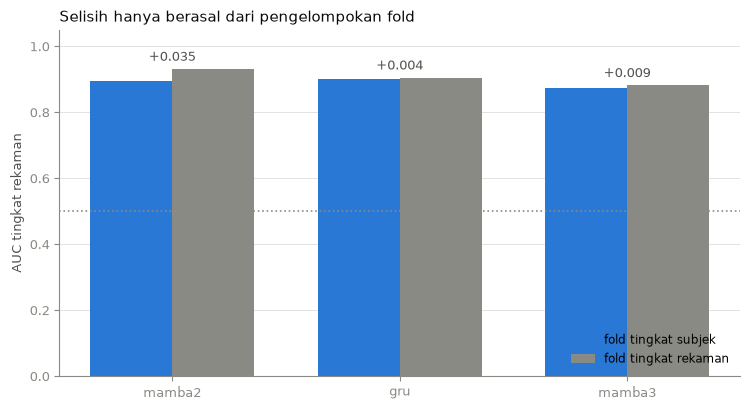

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
rapikan(ax)
pos = np.arange(len(ARSITEKTUR)); lebar = 0.36
ax.bar(pos - lebar/2, gel.auc_rekaman_subjekfold, width=lebar,
       color=WARNA["biru"], label="fold tingkat subjek")
ax.bar(pos + lebar/2, gel.auc_rekaman_rekamanfold, width=lebar,
       color=WARNA["netral"], label="fold tingkat rekaman")
for i, (a, b) in enumerate(gel.iterrows()):
    ax.annotate(f"{b.penggelembungan:+.3f}",
                xy=(i, max(b.auc_rekaman_subjekfold, b.auc_rekaman_rekamanfold)),
                xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=9, color=TINTA["sekunder"])
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(ARSITEKTUR)
ax.set_ylim(0, 1.05); ax.set_ylabel("AUC tingkat rekaman")
ax.set_title("Selisih hanya berasal dari pengelompokan fold", loc="left")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

In [6]:
df.to_csv(HASIL / "c1_perbandingan.csv", index=False)
gel.reset_index().to_csv(HASIL / "c1_penggelembungan.csv", index=False)
print(f"disimpan ke {HASIL.name}/c1_perbandingan.csv dan c1_penggelembungan.csv")

disimpan ke results/c1_perbandingan.csv dan c1_penggelembungan.csv


## 4. Ringkasan

**Yang diukur.** Berapa besar AUC yang hilang ketika rekaman dari subjek yang sama tidak lagi boleh
berada di kedua sisi pembagian. Selisih itu bukan galat, melainkan bagian performa yang berasal dari
pengenalan subjek.

**Cara membacanya bersama Skenario S4.** Di dalam distribusi yang sama, kebocoran subjek
**menggelembungkan** performa — itulah yang diukur di sini. Pada transfer lintas tugas, kebocoran
yang sama justru **membalikkannya**, dan arah pembalikannya bergantung pada kapasitas model (Subbab
3.6.3). Kedua pengukuran itu diperlukan; salah satunya saja memberi gambaran yang keliru.

**Batasan.** Satu seed, sesuai kedalaman eksploratori Subbab 3.6.3. Perbandingannya juga terbatas
pada lima fold dengan pembagi yang sama, sehingga tidak menyatakan apa pun mengenai skema pembagian
lain seperti leave-one-subject-out.

---

# 14_visualisasi_data.ipynb

`14_visualisasi_data.ipynb` · 25 sel, 12 sel kode, 12 beroutput

# Tahap 14 — Seperti apa datanya terlihat

Notebook deskriptif. Ia **tidak menghitung hasil apa pun**, tidak melatih model, dan tidak
menyentuh aturan keputusan. Tujuannya satu: memperlihatkan bentuk data yang dipakai seluruh
skenario, supaya pembaca yang belum pernah melihat tulisan tangan daring punya gambaran konkret
sebelum membaca angka.

Enam pertanyaan dijawab berurutan:

1. Kedua kohort itu isinya apa, dan di mana bedanya
2. Pada UCI 395, apa yang **sebenarnya digambar** subjek
3. Enam kanal yang dilihat model itu seperti apa
4. Pada NewHandPD, kenapa gambarnya **tidak dapat ditampilkan**
5. Berapa panjang rekamannya, dan apa artinya satu patch
6. Di mana pita tremor terlihat, dan siapa yang lebih tua

Seluruhnya berjalan di CPU dari cache pada `data/cache/`.

In [1]:
import sys
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

from preprocessing import muat_cache, NAMA_TUGAS, KANAL_MODEL, FS_TARGET
from newhandpd import muat_cache_bisp, KANAL_MODEL_BISP
from viz import WARNA, TINTA, pasang_gaya, rapikan, pita_tremor

pasang_gaya()
CACHE = Path("../data/cache")
GAMBAR = Path("../figures")
FS = FS_TARGET

uci = muat_cache(CACHE / "uci395_fs100.npz")
nhp = {k: muat_cache_bisp(CACHE / f"newhandpd_{k}_fs100.npz")
       for k in ["spiral", "meander", "dia"]}

print(f"UCI 395    : {len(uci)} rekaman, {len({r.subjek for r in uci})} subjek")
for k, v in nhp.items():
    print(f"NewHandPD {k:8s}: {len(v):4d} rekaman, {len({r.subjek for r in v})} subjek")

UCI 395    : 207 rekaman, 77 subjek
NewHandPD spiral  :  264 rekaman, 66 subjek
NewHandPD meander :  264 rekaman, 66 subjek
NewHandPD dia     :  132 rekaman, 66 subjek


## 1. Dua kohort, sengaja dipilih berjauhan

Pemilihan kedua basis data bukan kebetulan. Keduanya berbeda pada enam sumbu sekaligus, dan itulah
yang membuat replikasi di antara keduanya menjadi ujian yang berarti alih-alih pengulangan.

Perhatikan khususnya dua baris terakhir: **arah komposisi kelasnya terbalik**, dan **NewHandPD tidak
memuat koordinat pena sama sekali**. Yang kedua itu menentukan seluruh rancangan replikasi — tanpa
koordinat, bobot model tidak dapat dipindahkan, sehingga Rumusan Masalah 3 menanyakan replikasi
**metode**, bukan generalisasi model.

In [2]:
def ringkas(rek, nama, perangkat, negara, fs_asli, koordinat):
    subj = {r.subjek for r in rek}
    pd_ = {r.subjek for r in rek if r.kelompok == "PD"}
    hc = {r.subjek for r in rek if r.kelompok == "HC"}
    dur = np.array([len(r.kanal) / FS for r in rek])
    return {"Basis data": nama, "Perangkat": perangkat, "Negara": negara,
            "fs asli": fs_asli, "Rekaman": len(rek), "Subjek": len(subj),
            "PD": len(pd_), "HC": len(hc),
            "Arah kelas": "PD mayoritas" if len(pd_) > len(hc) else "HC mayoritas",
            "Durasi median (s)": round(float(np.median(dur)), 1),
            "Koordinat pena": koordinat}

tabel = pd.DataFrame([
    ringkas(uci, "UCI 395", "tablet digitizer", "Turki", "127,52 Hz", "ada"),
    ringkas(nhp["spiral"], "NewHandPD (spiral)", "smart pen BiSP", "Brasil", "1000 Hz", "TIDAK ADA"),
])
display(tabel.set_index("Basis data").T)

Basis data,UCI 395,NewHandPD (spiral)
Perangkat,tablet digitizer,smart pen BiSP
Negara,Turki,Brasil
fs asli,"127,52 Hz",1000 Hz
Rekaman,207,264
Subjek,77,66
PD,62,31
HC,15,35
Arah kelas,PD mayoritas,HC mayoritas
Durasi median (s),15.6,14.4
Koordinat pena,ada,TIDAK ADA


Enam kanal yang diberikan kepada model juga berbeda sama sekali, dan itu disengaja.

In [3]:
banding = pd.DataFrame({
    "UCI 395 — dari koordinat dan tekanan": KANAL_MODEL,
    "NewHandPD — dari sensor badan pena": KANAL_MODEL_BISP,
})
display(banding)
print("Tidak satu pun kanal yang sama antara kedua kohort.")
print("Yang direplikasi adalah METODE-nya, bukan bobot modelnya.")

,UCI 395 — dari koordinat dan tekanan,NewHandPD — dari sensor badan pena
0,dx,d_mikrofon
1,dy,d_fingergrip
2,kecepatan,d_tekanan
3,percepatan,dd_mikrofon
4,jerk,dd_fingergrip
5,tekanan,dd_tekanan


Tidak satu pun kanal yang sama antara kedua kohort.
Yang direplikasi adalah METODE-nya, bukan bobot modelnya.


## 2. Apa yang sebenarnya digambar

UCI 395 memuat koordinat, sehingga jejak penanya dapat digambar ulang persis seperti yang dilihat
subjek. Tiga tugasnya berbeda sifat:

| Tugas | Isi | Yang tampak |
|---|---|---|
| **SST** | spiral statis — subjek menelusuri spiral yang sudah tercetak | jejak menelusuri |
| **DST** | spiral dinamis — polanya berkedip, subjek menggambar dari ingatan | jejak lebih bebas |
| **STCP** | menahan pena di atas satu titik tanpa menyentuh layar | **tidak ada gambar** — hanya getaran |

Di bawah ini satu subjek penderita berdampingan dengan satu subjek kontrol, pada tugas yang sama.
Perhatikan kekasaran jejaknya, bukan bentuk keseluruhannya.

> **Catatan penamaan, agar tidak salah baca.** Pengenal subjek pada rilis UCI 395 menyesatkan:
> awalan `H_` **bukan** berarti *healthy*. Kelompoknya sebagai berikut — `C_*` sebanyak 15 subjek
> adalah kontrol, sedangkan `H_P000-*` sebanyak 37 subjek dan `P_*` sebanyak 25 subjek keduanya
> penderita. Totalnya 62 penderita dan 15 kontrol, dan tidak ada satu pun subjek yang muncul pada
> dua kelompok. Diperiksa langsung dari cache, bukan diasumsikan dari nama berkas.

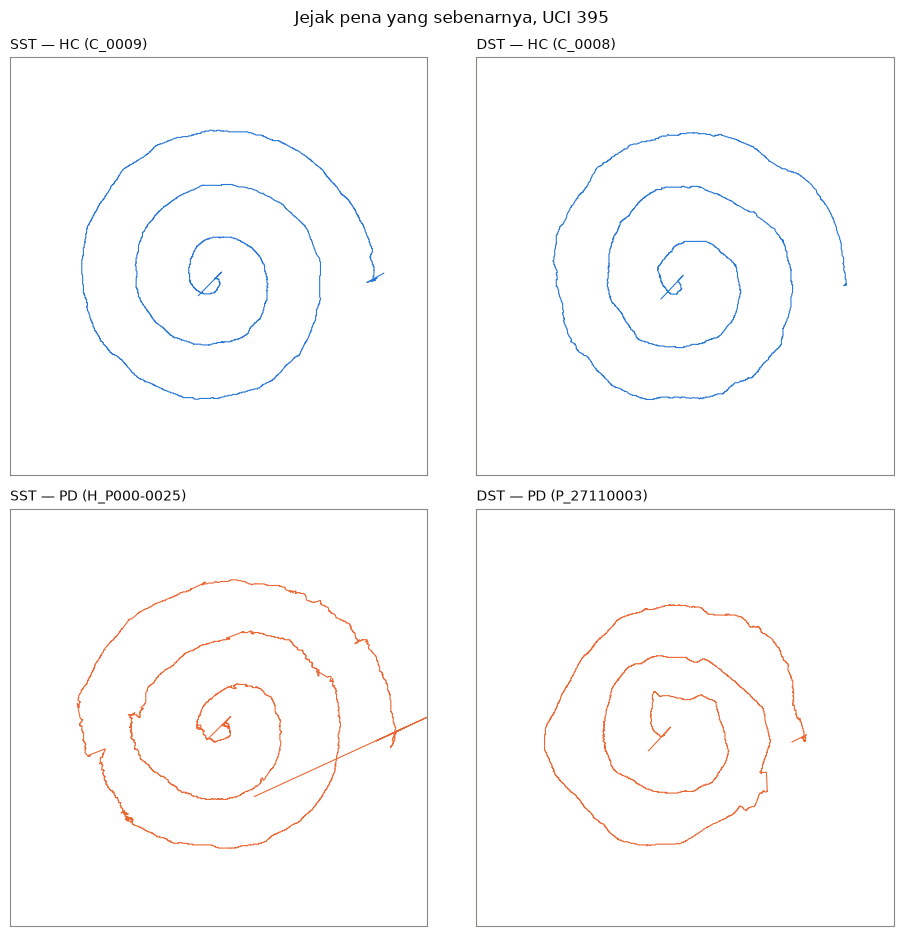

In [4]:
def satu(rek, tugas, kelompok):
    """Ambil rekaman terpanjang milik satu subjek pada tugas dan kelompok tertentu."""
    kandidat = [r for r in rek if r.tugas == tugas and r.kelompok == kelompok
                and r.xy is not None and len(r.xy) > 500]
    return max(kandidat, key=lambda r: len(r.xy)) if kandidat else None

pilih = {(t_, k): satu(uci, t_, k) for t_ in [0, 1] for k in ["HC", "PD"]}
# Batas sumbu disamakan untuk keempat panel supaya ukurannya sebanding dan
# panelnya sama besar; tanpa ini aspect="equal" membuat tiap panel menyusut beda.
jangkau = max(np.abs(r.xy - r.xy.mean(axis=0)).max() for r in pilih.values() if r is not None)

fig, axes = plt.subplots(2, 2, figsize=(9.5, 9.5))
for j, tugas in enumerate([0, 1]):
    for i, kel in enumerate(["HC", "PD"]):
        ax = axes[i, j]
        r = pilih[(tugas, kel)]
        if r is None:
            ax.text(.5, .5, "tidak ada", ha="center", transform=ax.transAxes); continue
        warna = WARNA["biru"] if kel == "HC" else WARNA["jingga"]
        xy = r.xy - r.xy.mean(axis=0)
        ax.plot(xy[:, 0], xy[:, 1], lw=0.8, color=warna)
        ax.set_title(f"{NAMA_TUGAS[tugas]} — {kel} ({r.subjek})", loc="left", fontsize=10)
        ax.set_xlim(-jangkau, jangkau); ax.set_ylim(-jangkau, jangkau)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Jejak pena yang sebenarnya, UCI 395", y=0.98, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_jejak_pena_uci.png", dpi=150, bbox_inches="tight")
plt.show()

**STCP tidak dapat digambar** sebab penanya ditahan di udara. Yang ada hanya getaran di sekitar
satu titik. Itulah alasan tugas ini menjadi analisis primer: tremor tidak tercampur gerakan yang
disengaja.

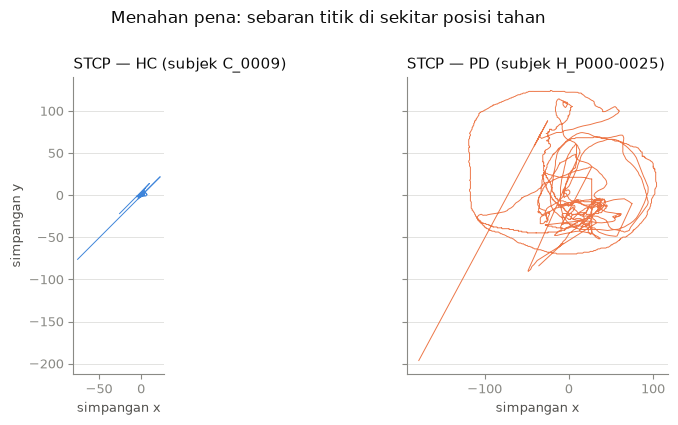

In [5]:
r_pd = satu(uci, 2, "PD"); r_hc = satu(uci, 2, "HC")
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, r, kel in zip(axes, [r_hc, r_pd], ["HC", "PD"]):
    if r is None: continue
    warna = WARNA["biru"] if kel == "HC" else WARNA["jingga"]
    xy = r.xy - r.xy.mean(axis=0)
    ax.plot(xy[:, 0], xy[:, 1], lw=0.7, color=warna, alpha=0.9)
    ax.set_title(f"STCP — {kel} (subjek {r.subjek})", loc="left")
    ax.set_aspect("equal"); ax.set_xlabel("simpangan x"); rapikan(ax)
axes[0].set_ylabel("simpangan y")
fig.suptitle("Menahan pena: sebaran titik di sekitar posisi tahan", y=1.0, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_stcp_sebaran.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Enam kanal yang dilihat model

Model **tidak** menerima koordinat. Ia menerima enam kanal turunan, seluruhnya invarian terhadap
posisi absolut — itulah yang membuat koordinat tetap sah sebagai acuan penanda yang independen.

Satu rekaman ditampilkan utuh di bawah ini, satu kanal per baris.

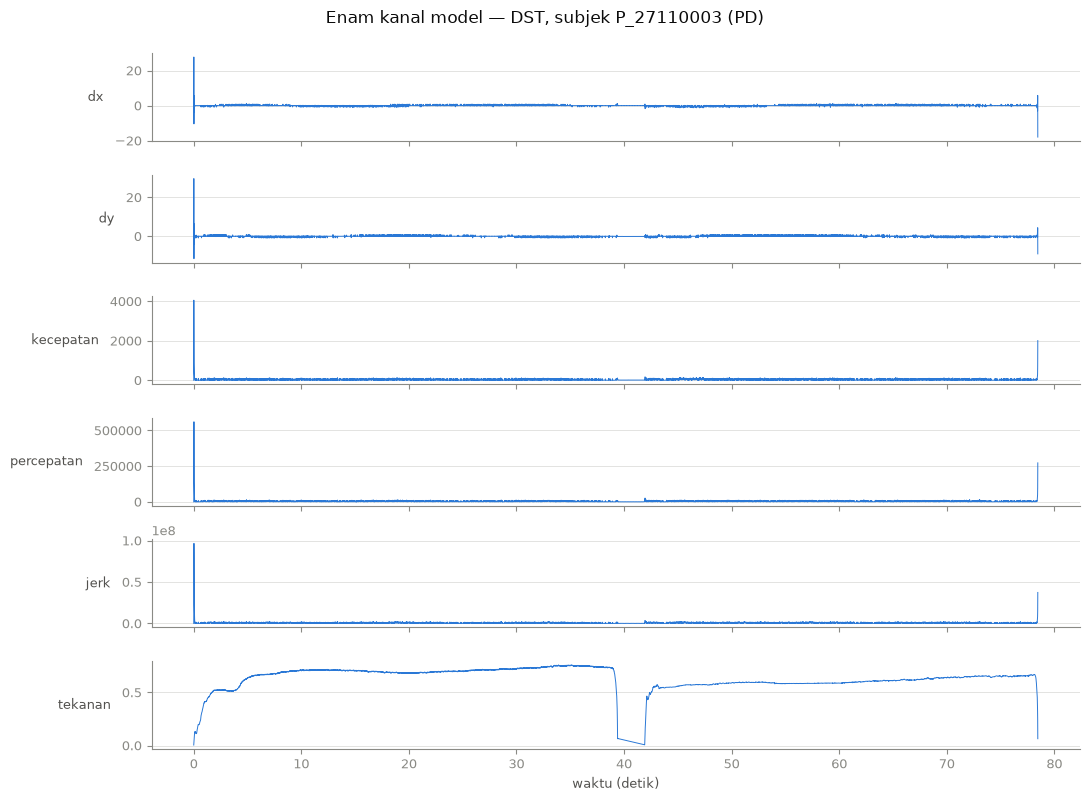

In [6]:
r = satu(uci, 1, "PD")
t = np.arange(len(r.kanal)) / FS
fig, axes = plt.subplots(6, 1, figsize=(11, 8), sharex=True)
for k, (ax, nama) in enumerate(zip(axes, KANAL_MODEL)):
    ax.plot(t, r.kanal[:, k], lw=0.7, color=WARNA["biru"])
    ax.set_ylabel(nama, rotation=0, ha="right", va="center", labelpad=8)
    rapikan(ax)
axes[-1].set_xlabel("waktu (detik)")
fig.suptitle(f"Enam kanal model — {NAMA_TUGAS[r.tugas]}, subjek {r.subjek} ({r.kelompok})",
             y=0.995, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_kanal_uci.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. NewHandPD: kenapa gambarnya tidak dapat ditampilkan

Smart pen BiSP tidak merekam posisi. Ia merekam apa yang terjadi **di badan pena**: mikrofon,
cengkeraman jari, tekanan aksial isi pena, serta kemiringan dan percepatan tiga sumbu.

Tidak ada koordinat, sehingga tidak ada jejak yang dapat digambar ulang. Ini bukan kekurangan
melainkan sifat perangkatnya — dan justru itu yang menjadikan kohort ini ujian replikasi yang keras.

Pemisahannya penting dan dipakai seluruh skenario:

- **Kanal 1–3 diberikan kepada model** (mikrofon, fingergrip, tekanan aksial)
- **Kanal 4–6 ditahan sepenuhnya** (tilt dan percepatan) dan hanya dipakai menghitung penanda

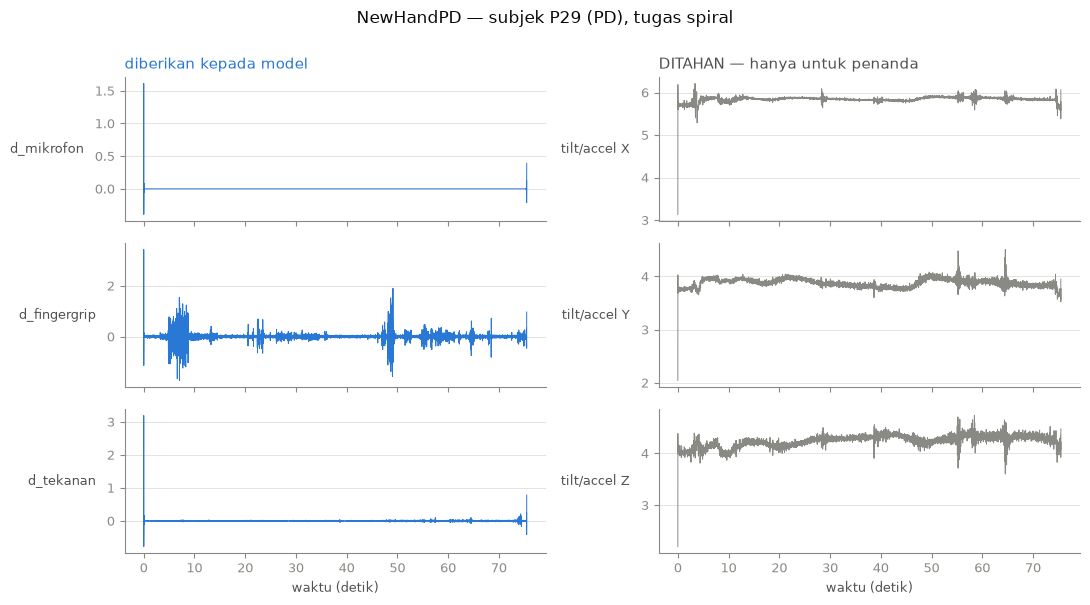

In [7]:
r = max((x for x in nhp["spiral"] if x.kelompok == "PD"), key=lambda x: len(x.kanal))
t = np.arange(len(r.kanal)) / FS
fig, axes = plt.subplots(3, 2, figsize=(11, 6), sharex=True)

for k in range(3):                       # kanal yang DIBERIKAN, sudah jadi beda pertama
    axes[k, 0].plot(t, r.kanal[:, k], lw=0.7, color=WARNA["biru"])
    axes[k, 0].set_ylabel(KANAL_MODEL_BISP[k], rotation=0, ha="right", va="center", labelpad=8)
    rapikan(axes[k, 0])
for k in range(3):                       # kanal yang DITAHAN
    axes[k, 1].plot(t, r.kanal_ditahan[:, k], lw=0.7, color=WARNA["netral"])
    axes[k, 1].set_ylabel(["tilt/accel X", "tilt/accel Y", "tilt/accel Z"][k],
                          rotation=0, ha="right", va="center", labelpad=8)
    rapikan(axes[k, 1])
axes[0, 0].set_title("diberikan kepada model", loc="left", color=WARNA["biru"])
axes[0, 1].set_title("DITAHAN — hanya untuk penanda", loc="left", color=TINTA["sekunder"])
axes[-1, 0].set_xlabel("waktu (detik)"); axes[-1, 1].set_xlabel("waktu (detik)")
fig.suptitle(f"NewHandPD — subjek {r.subjek} ({r.kelompok}), tugas spiral",
             y=1.0, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_kanal_newhandpd.png", dpi=150, bbox_inches="tight")
plt.show()

NewHandPD memuat dua belas tugas. Skenario replikasi memakai empat tugas spiral; delapan sisanya
membuka sumbu geser tugas dengan subjek, perangkat, dan negara terkunci konstan.

In [8]:
ringkasan = []
for k, rek in nhp.items():
    dur = np.array([len(x.kanal) / FS for x in rek])
    ringkasan.append({"Keluarga": k, "Rekaman": len(rek),
                      "Subjek": len({x.subjek for x in rek}),
                      "Durasi median (s)": round(float(np.median(dur)), 1),
                      "Durasi min-maks (s)": f"{dur.min():.1f}-{dur.max():.1f}",
                      "Patch pada P=7": int(np.median(dur * FS // 7))})
display(pd.DataFrame(ringkasan).set_index("Keluarga"))

,Rekaman,Subjek,Durasi median (s),Durasi min-maks (s),Patch pada P=7
Keluarga,,,,,
spiral,264,66,14.4,3.2-75.5,205
meander,264,66,12.8,4.9-45.0,181
dia,132,66,22.0,8.2-51.6,314


## 5. Panjang rekaman, dan apa artinya satu patch

Model tidak melihat sampel satu per satu. Ia melihat **patch** — potongan waktu berdurasi tetap.
Konfigurasi beku memakai patch 7, yaitu **70 milidetik** per patch pada 100 Hz.

Angka itu menentukan resolusi seluruh peta temporal: satu bobot atensi berlaku bagi 70 milidetik,
bukan bagi satu titik waktu.

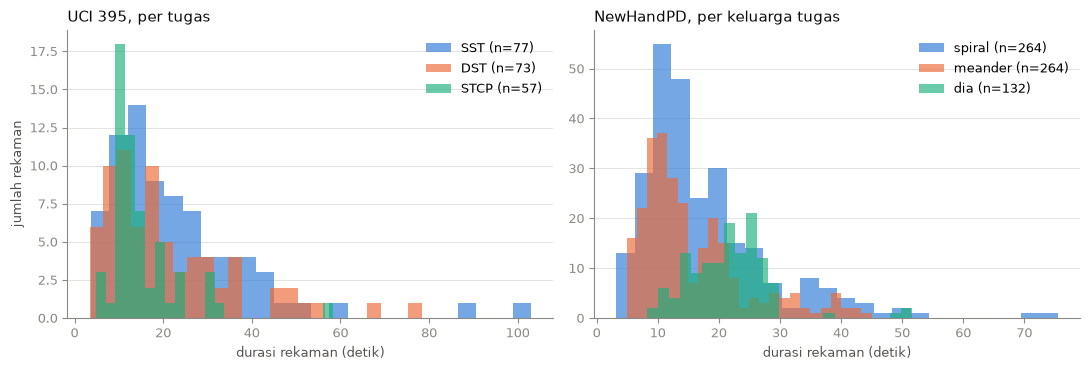

Patch 7 = 70 ms. UCI 395: median 222 patch per rekaman (rentang 48-1472).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

dur_uci = {NAMA_TUGAS[k]: np.array([len(r.kanal) / FS for r in uci if r.tugas == k])
           for k in sorted({r.tugas for r in uci})}
for (nama, d), w in zip(dur_uci.items(), [WARNA["biru"], WARNA["jingga"], WARNA["toska"]]):
    axes[0].hist(d, bins=24, alpha=0.65, label=f"{nama} (n={len(d)})", color=w)
axes[0].set_xlabel("durasi rekaman (detik)"); axes[0].set_ylabel("jumlah rekaman")
axes[0].set_title("UCI 395, per tugas", loc="left"); axes[0].legend(); rapikan(axes[0])

for (nama, rek), w in zip(nhp.items(), [WARNA["biru"], WARNA["jingga"], WARNA["toska"]]):
    d = np.array([len(x.kanal) / FS for x in rek])
    axes[1].hist(d, bins=24, alpha=0.65, label=f"{nama} (n={len(d)})", color=w)
axes[1].set_xlabel("durasi rekaman (detik)")
axes[1].set_title("NewHandPD, per keluarga tugas", loc="left"); axes[1].legend(); rapikan(axes[1])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_durasi.png", dpi=150, bbox_inches="tight")
plt.show()

P = 7
n_patch = np.array([len(r.kanal) // P for r in uci])
print(f"Patch {P} = {P*10} ms. UCI 395: median {int(np.median(n_patch))} patch per rekaman "
      f"(rentang {n_patch.min()}-{n_patch.max()}).")

Satu rekaman diperbesar di bawah ini, dengan batas patch digambar. Inilah kisi yang dipakai
bobot atensi, atribusi Shapley, dan penanda motorik — ketiganya pada kisi yang sama persis, sebab
kalau tidak, ketiganya tidak dapat dibandingkan.

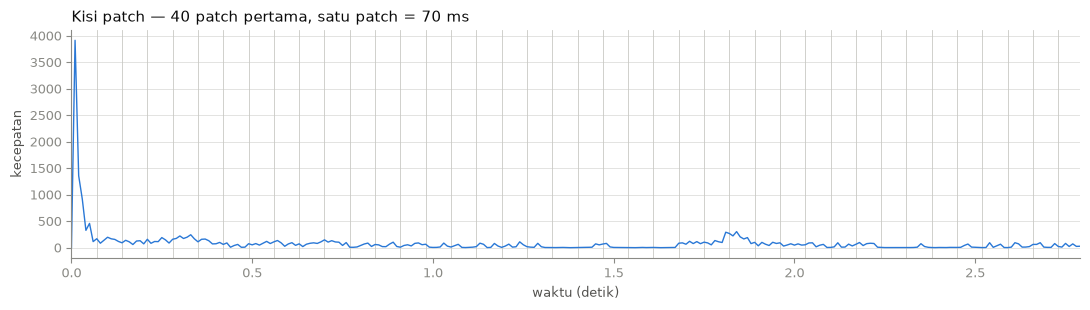

In [10]:
r = satu(uci, 2, "PD")
P, n_tampil = 7, 40
potong = r.kanal[:P * n_tampil, 2]          # kanal kecepatan
t = np.arange(len(potong)) / FS

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(t, potong, lw=1.0, color=WARNA["biru"])
for b in range(n_tampil + 1):
    ax.axvline(b * P / FS, color=WARNA["redup"], lw=0.6, zorder=0)
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("kecepatan")
ax.set_title(f"Kisi patch — {n_tampil} patch pertama, satu patch = {P*10} ms", loc="left")
ax.set_xlim(0, t[-1]); rapikan(ax)
fig.tight_layout()
fig.savefig(GAMBAR / "f14_kisi_patch.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Pita tremor, dan siapa yang lebih tua

**Pita tremor 3,5 sampai 7,5 Hz** dibekukan dari literatur sebelum data hasil dilihat. Kerapatan
spektral daya kanal kecepatan memperlihatkan di mana pita itu berada relatif terhadap gerakan yang
disengaja, yang jauh lebih lambat.

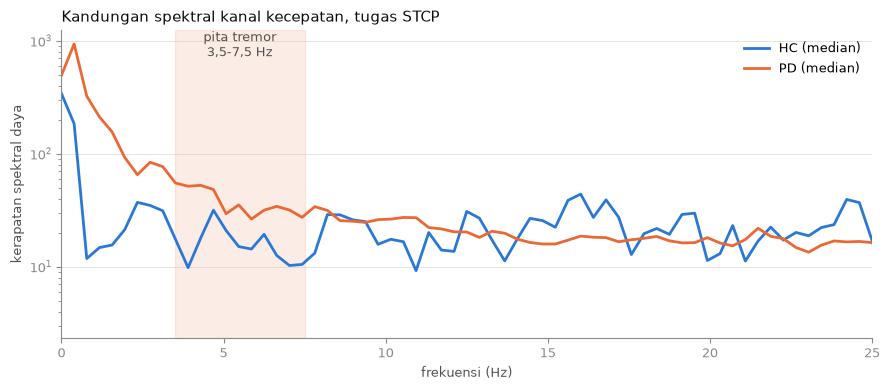

In [11]:
def psd_kelompok(rek, tugas, kel, kanal=2):
    kur = []
    for r in rek:
        if r.tugas != tugas or r.kelompok != kel or len(r.kanal) < 512:
            continue
        f, P_ = welch(r.kanal[:, kanal], fs=FS, nperseg=256)
        kur.append(P_)
    return f, np.median(np.vstack(kur), axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
for kel, w in [("HC", WARNA["biru"]), ("PD", WARNA["jingga"])]:
    f, P_ = psd_kelompok(uci, 2, kel)
    ax.semilogy(f, P_, color=w, label=f"{kel} (median)")
ax.axvspan(*pita_tremor, color=WARNA["jingga"], alpha=0.12, zorder=0)
ax.annotate("pita tremor\n3,5-7,5 Hz", xy=(np.mean(pita_tremor), ax.get_ylim()[1]),
            ha="center", va="top", fontsize=9, color=TINTA["sekunder"])
ax.set_xlim(0, 25); ax.set_xlabel("frekuensi (Hz)"); ax.set_ylabel("kerapatan spektral daya")
ax.set_title("Kandungan spektral kanal kecepatan, tugas STCP", loc="left")
ax.legend(); rapikan(ax)
fig.tight_layout()
fig.savefig(GAMBAR / "f14_spektrum_tremor.png", dpi=150, bbox_inches="tight")
plt.show()

Terakhir, dua sifat komposisi kohort yang harus terlihat sebelum angka mana pun dibaca.

Yang pertama, **arah komposisi kelasnya terbalik** antara kedua basis data. Yang kedua, dan baru
terlihat setelah metadata NewHandPD dibaca: **kelompok penderita jauh lebih tua**. Perancu itu
diaudit tersendiri; di sini ia sekadar ditampilkan.

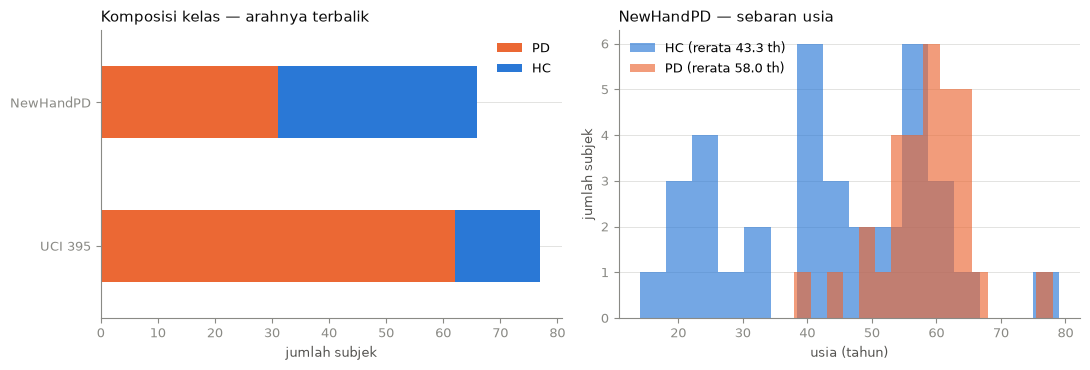

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

komposisi = pd.DataFrame({
    "UCI 395": [len({r.subjek for r in uci if r.kelompok == k}) for k in ["PD", "HC"]],
    "NewHandPD": [len({r.subjek for r in nhp["spiral"] if r.kelompok == k}) for k in ["PD", "HC"]],
}, index=["PD", "HC"])
komposisi.T.plot(kind="barh", stacked=True, ax=axes[0],
                 color=[WARNA["jingga"], WARNA["biru"]])
axes[0].set_xlabel("jumlah subjek")
axes[0].set_title("Komposisi kelas — arahnya terbalik", loc="left")
rapikan(axes[0])

meta = Path("../results/p4_meta_subjek.csv")
if meta.exists():
    m = pd.read_csv(meta)
    m["Age"] = pd.to_numeric(m["Age"], errors="coerce")
    for kel, w in [("HC", WARNA["biru"]), ("PD", WARNA["jingga"])]:
        d = m[m.kelompok == kel].Age.dropna()
        axes[1].hist(d, bins=16, alpha=0.65, color=w, label=f"{kel} (rerata {d.mean():.1f} th)")
    axes[1].set_xlabel("usia (tahun)"); axes[1].set_ylabel("jumlah subjek")
    axes[1].set_title("NewHandPD — sebaran usia", loc="left"); axes[1].legend()
    rapikan(axes[1])
else:
    axes[1].text(.5, .5, "jalankan scripts/analisis_p4_geser_tugas.py --periksa",
                 ha="center", transform=axes[1].transAxes)
fig.tight_layout()
fig.savefig(GAMBAR / "f14_komposisi.png", dpi=150, bbox_inches="tight")
plt.show()

## Ringkas

- Data mentahnya adalah **jejak pena sebagai deret waktu**, bukan citra. Sumbu waktunya nyata dan
  itulah yang dilokalisasi penelitian ini.
- **UCI 395 memuat koordinat, NewHandPD tidak.** Perbedaan itu menentukan bentuk replikasi.
- Model **tidak pernah melihat koordinat** pada kedua kohort. Itulah yang menjaga penanda motorik
  tetap menjadi acuan yang benar-benar independen.
- Satu bobot atensi berlaku bagi **70 milidetik**, bukan bagi satu titik waktu.
- Dua sifat kohort yang harus diingat saat membaca hasil: arah komposisi kelas **terbalik**, dan
  kelompok penderita pada NewHandPD **jauh lebih tua**.

Gambar tersimpan di `figures/f14_*.png`.